# 02 — Deep Learning Paradigms

Deep learning is not a single learning strategy.

Different deep learning paradigms define different ways in which a neural network can learn from data. The learning paradigm determines what information is available during training, what objective the model optimizes, and how the learned representation is used.

In this notebook, we study the major deep learning paradigms:

- Supervised Deep Learning
- Unsupervised Deep Learning
- Self-Supervised Learning
- Semi-Supervised Deep Learning
- Deep Reinforcement Learning
- Generative Deep Learning
- Representation Learning
- Transfer Learning
- Multi-Task Learning

The goal is not only to implement these approaches, but to understand **what they learn, why they work, and when they are useful**.

## 1.1 What is a Deep Learning Paradigm?

A deep learning paradigm describes the way a neural network obtains its learning signal.

At a high level, the learning signal can come from:

1. **Human-provided labels**
2. **The structure of the data itself**
3. **Artificial labels created from the data**
4. **A mixture of labeled and unlabeled data**
5. **Rewards obtained through interaction with an environment**
6. **A generative objective**
7. **Knowledge transferred from another task or dataset**

Therefore, two neural networks can have similar architectures but belong to very different learning paradigms because their training objectives and sources of supervision are different.

## 1.2 General Deep Learning Formulation

A neural network can be represented as a parameterized function:

$$
\hat{y} = f_{\theta}(x)
$$

where:

- $x$ is the input
- $\hat{y}$ is the model output
- $\theta$ represents the learnable parameters

Training consists of finding parameters that optimize an objective:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(\theta)
$$

The important difference between learning paradigms is the definition of the objective $\mathcal{L}$ and the source of the learning signal.

For example:

- Supervised learning uses known target labels.
- Autoencoders learn to reconstruct their inputs.
- Self-supervised learning creates learning targets from the data itself.
- Reinforcement learning learns from rewards.
- Generative models learn to model the data distribution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA version: 12.8
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
x = torch.randn(1000, 1000, device=device)
y = torch.randn(1000, 1000, device=device)

z = x @ y

print("Tensor device:", z.device)
print("Tensor shape:", z.shape)

Tensor device: cuda:0
Tensor shape: torch.Size([1000, 1000])


## 1.3 Taxonomy of Deep Learning Paradigms

We can organize deep learning paradigms according to the source of their learning signal.

| Paradigm | Learning Signal | Typical Objective |
|---|---|---|
| Supervised Learning | Human-provided labels | Prediction error |
| Unsupervised Learning | Data structure | Reconstruction / distribution modeling |
| Self-Supervised Learning | Targets generated from data | Representation learning |
| Semi-Supervised Learning | Labeled + unlabeled data | Supervised + unsupervised objectives |
| Deep Reinforcement Learning | Rewards from environment | Expected return |
| Generative Learning | Data distribution | Generate realistic samples |
| Transfer Learning | Knowledge from another task | Adapt pretrained representation |
| Multi-Task Learning | Multiple related tasks | Joint optimization |

These categories can overlap.

For example, a Variational Autoencoder is an unsupervised generative model, while a pretrained Transformer can be used for supervised, self-supervised, or transfer-learning workflows.

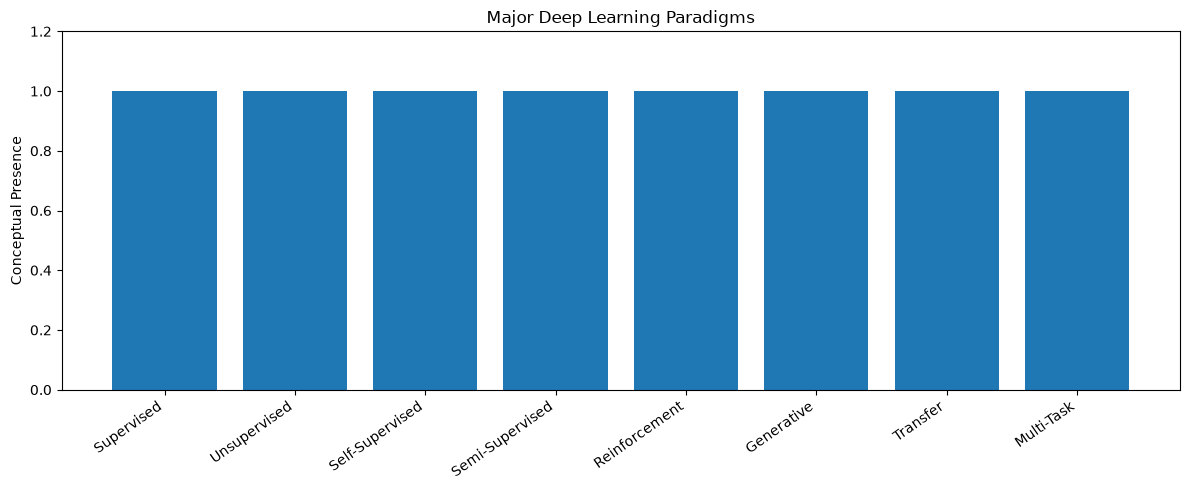

In [4]:
paradigms = [
    "Supervised",
    "Unsupervised",
    "Self-Supervised",
    "Semi-Supervised",
    "Reinforcement",
    "Generative",
    "Transfer",
    "Multi-Task"
]

positions = np.arange(len(paradigms))

plt.figure(figsize=(12, 5))
plt.bar(positions, np.ones(len(paradigms)))

plt.xticks(positions, paradigms, rotation=35, ha="right")
plt.ylabel("Conceptual Presence")
plt.title("Major Deep Learning Paradigms")
plt.ylim(0, 1.2)
plt.tight_layout()
plt.show()

## 1.4 Paradigm vs Architecture

A learning paradigm and a neural network architecture are not the same thing.

### Learning paradigm

Describes **how the model learns**.

Examples:

- supervised learning
- self-supervised learning
- reinforcement learning
- transfer learning

### Architecture

Describes **how the neural network is constructed**.

Examples:

- MLP
- CNN
- RNN
- LSTM
- GRU
- Transformer
- Autoencoder
- U-Net

The same architecture can be used under different paradigms.

For example, a Transformer can be trained using:

- supervised learning
- self-supervised learning
- semi-supervised learning
- transfer learning

Therefore:

$$
\boxed{\text{Learning Paradigm} \neq \text{Neural Network Architecture}}
$$

## 1.5 Notebook Roadmap

We will now study each paradigm progressively.

### Part A — Sources of Supervision

1. Supervised Deep Learning
2. Unsupervised Deep Learning
3. Self-Supervised Learning
4. Semi-Supervised Deep Learning

### Part B — Specialized Learning Paradigms

5. Deep Reinforcement Learning
6. Generative Deep Learning
7. Representation Learning

### Part C — Knowledge Reuse

8. Transfer Learning
9. Multi-Task Learning

Finally, we will compare the paradigms and build an end-to-end demonstration showing how the learning objective changes the behavior of a neural network.

The central question throughout this notebook is:

> **Where does the learning signal come from, and what does the neural network learn from it?**

## 2.1 Supervised Deep Learning

Supervised deep learning is a learning paradigm in which a neural network learns from a dataset containing input examples and corresponding target labels.

The model learns a mapping from an input $x$ to a target $y$:

$$
\hat{y} = f_{\theta}(x)
$$

where:

- $x$ is the input
- $y$ is the true target
- $\hat{y}$ is the model prediction
- $\theta$ represents the learnable parameters of the neural network

The objective of training is to make the prediction $\hat{y}$ as close as possible to the true target $y$.

This is achieved by defining a loss function:

$$
\mathcal{L}(y,\hat{y})
$$

and optimizing the neural network parameters:

$$
\theta^* = \arg\min_{\theta} \mathcal{L}(y,\hat{y})
$$

### Basic supervised learning process

1. Provide an input $x$.
2. The neural network performs a forward pass.
3. The network produces a prediction $\hat{y}$.
4. The prediction is compared with the true target $y$.
5. A loss value is calculated.
6. Backpropagation computes gradients.
7. An optimizer updates the parameters.
8. The process is repeated over many training examples and epochs.

The important idea is:

$$
\boxed{
\text{Input} \rightarrow
\text{Neural Network} \rightarrow
\text{Prediction} \rightarrow
\text{Loss} \rightarrow
\text{Backpropagation} \rightarrow
\text{Parameter Update}
}
$$

Supervised deep learning is commonly used for:

- Image classification
- Object detection
- Image segmentation
- Text classification
- Speech recognition
- Regression
- Time-series prediction
- Medical image analysis

                 Training Data
              ┌─────────────────┐
              │ Input x         │
              │ Target y        │
              └────────┬────────┘
                       │
                       ▼
              ┌─────────────────┐
              │ Neural Network  │
              │   fθ(x)         │
              └────────┬────────┘
                       │
                       ▼
                 Prediction ŷ
                       │
                       ▼
              ┌─────────────────┐
              │  Loss Function  │
              │ L(y, ŷ)         │
              └────────┬────────┘
                       │
                       ▼
               Backpropagation
                       │
                       ▼
              Parameter Update
                       │
                       └──────► Repeat

## 2.2 Supervised Deep Learning Tasks

Supervised deep learning mainly contains two fundamental prediction problems:

1. Classification
2. Regression

### Classification

Classification predicts a discrete class or category.

Examples:

- Cat vs Dog
- Spam vs Not Spam
- Disease vs Healthy
- Digit classification from 0 to 9

For a classification problem, the network typically produces class scores or probabilities.

For $K$ classes, the output can be represented as:

$$
\hat{\mathbf{y}} =
[\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_K]
$$

A softmax function converts logits into class probabilities:

$$
P(y=k|x)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K} e^{z_j}}
$$

The predicted class is:

$$
\hat{y} = \arg\max_k P(y=k|x)
$$

### Regression

Regression predicts a continuous numerical value.

Examples:

- House price prediction
- Temperature prediction
- Demand forecasting
- Age prediction
- Sensor-value prediction

For regression, the output is usually a continuous value:

$$
\hat{y} = f_{\theta}(x)
$$

A common regression loss is Mean Squared Error:

$$
\text{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
$$

### Comparison

| Task | Target | Example | Common Output |
|---|---|---|---|
| Binary Classification | Two classes | Spam detection | Probability/logit |
| Multiclass Classification | Multiple classes | Digit recognition | Class probabilities |
| Regression | Continuous value | House price | Real number |

The neural network architecture and loss function should match the task.

## 2.3 A Simple Supervised Learning Dataset

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)
print("Classes:", np.unique(y_train))

Training samples: (1600, 2)
Test samples: (400, 2)
Classes: [0 1]


## Visualization

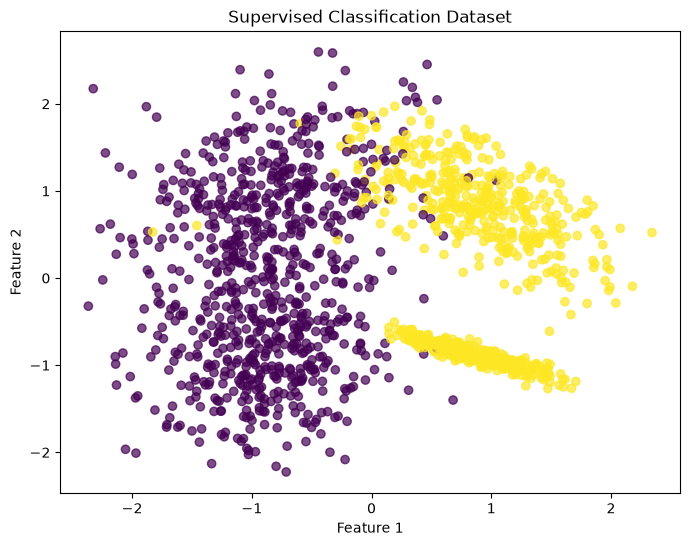

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Supervised Classification Dataset")
plt.show()

## 2.4 Converting Data to PyTorch Tensors

In [7]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32,
    device=device
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
    device=device
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
    device=device
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long,
    device=device
)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("Device:", X_train_tensor.device)

X_train: torch.Size([1600, 2])
y_train: torch.Size([1600])
Device: cuda:0


## 2.5 Building a Supervised Neural Network

We now construct a small multilayer perceptron (MLP) for binary classification.

The network receives two input features and produces two output logits corresponding to the two classes.

Architecture:

$$
2
\rightarrow
16
\rightarrow
16
\rightarrow
2
$$

The hidden layers use the ReLU activation function.

The final layer produces logits rather than probabilities.

For multiclass classification, we can use:

$$
\text{CrossEntropyLoss}
$$

PyTorch's `CrossEntropyLoss` internally combines the appropriate log-softmax operation with negative log-likelihood loss, so an explicit softmax layer should not be added before it.

In [8]:
class ClassificationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.network(x)


model = ClassificationNetwork().to(device)

print(model)

ClassificationNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 2.6 Loss Function and Optimizer

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


### Why Cross-Entropy Loss?

For classification, the model produces logits:

$$
\mathbf{z}
=
[z_1,z_2,\ldots,z_K]
$$

Cross-entropy measures how well these predictions correspond to the correct class.

For a single example:

$$
\mathcal{L}
=
-\log P(y|x)
$$

A correct and confident prediction produces a small loss.

A wrong and confident prediction produces a large loss.

### Why Adam?

Adam is an adaptive optimization algorithm that adjusts parameter updates using estimates of the first and second moments of the gradients.

The optimizer attempts to minimize the training loss by updating:

$$
\theta
\leftarrow
\theta-\eta\nabla_{\theta}\mathcal{L}
$$

where $\eta$ is the learning rate.

## 2.7 Training Loop

In [10]:
epochs = 100

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    predictions = torch.argmax(
        logits,
        dim=1
    )

    accuracy = (
        predictions == y_train_tensor
    ).float().mean().item()

    train_losses.append(loss.item())
    train_accuracies.append(accuracy)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )

Epoch  10/100 | Loss: 0.6577 | Accuracy: 0.8012
Epoch  20/100 | Loss: 0.6248 | Accuracy: 0.9500
Epoch  30/100 | Loss: 0.5881 | Accuracy: 0.9537
Epoch  40/100 | Loss: 0.5470 | Accuracy: 0.9556
Epoch  50/100 | Loss: 0.5012 | Accuracy: 0.9587
Epoch  60/100 | Loss: 0.4509 | Accuracy: 0.9594
Epoch  70/100 | Loss: 0.3982 | Accuracy: 0.9631
Epoch  80/100 | Loss: 0.3462 | Accuracy: 0.9650
Epoch  90/100 | Loss: 0.2981 | Accuracy: 0.9656
Epoch 100/100 | Loss: 0.2565 | Accuracy: 0.9644


## 2.8 Training Curves

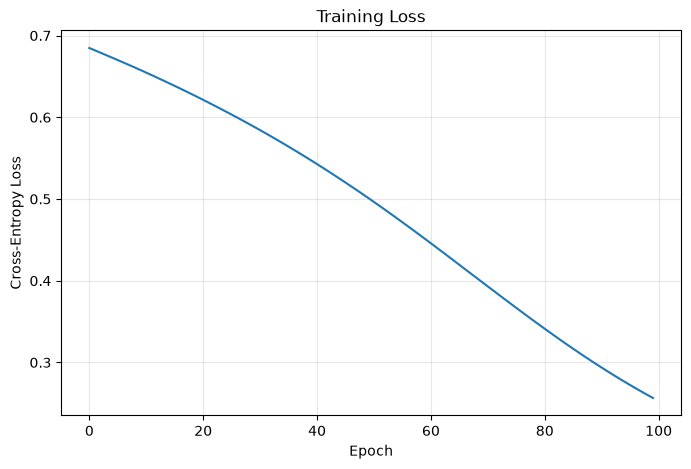

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss")

plt.grid(alpha=0.3)
plt.show()

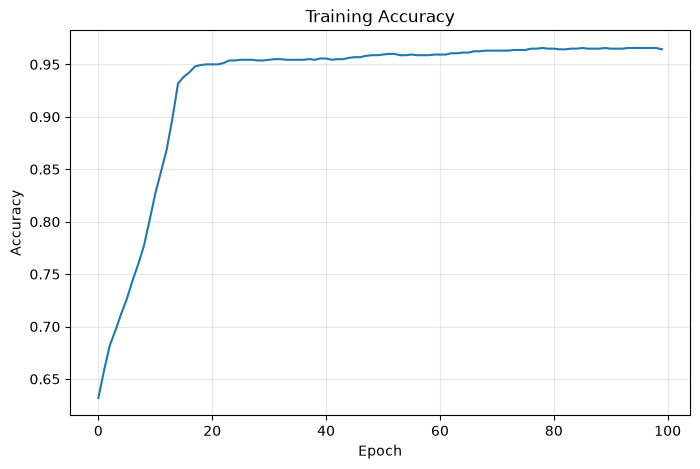

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.grid(alpha=0.3)
plt.show()

## 2.9 Evaluation

In [13]:
model.eval()

with torch.no_grad():

    test_logits = model(X_test_tensor)

    test_predictions = torch.argmax(
        test_logits,
        dim=1
    )

    test_accuracy = (
        test_predictions == y_test_tensor
    ).float().mean().item()

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9750


## 2.9 Evaluation

During evaluation:

- The model is switched to evaluation mode using `model.eval()`.
- Gradient computation is disabled using `torch.no_grad()`.
- Predictions are generated for unseen test data.
- Accuracy is calculated by comparing predictions with the true labels.

The test set estimates how well the learned model generalizes to previously unseen examples.

A high training accuracy alone does not guarantee good generalization.

## 2.10 Decision Boundary

In [14]:
model.eval()

x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_tensor = torch.tensor(
    grid,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    grid_logits = model(grid_tensor)
    grid_predictions = torch.argmax(
        grid_logits,
        dim=1
    )

grid_predictions = grid_predictions.cpu().numpy()

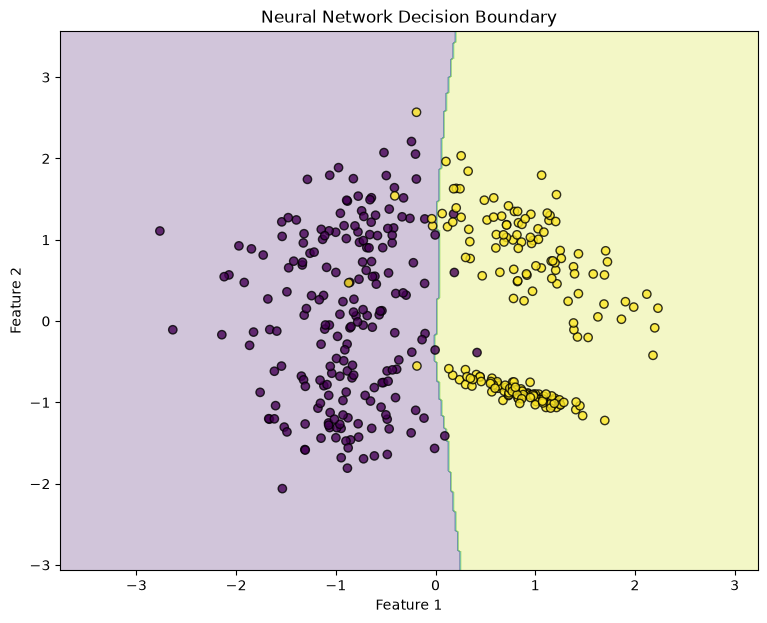

In [15]:
plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    grid_predictions.reshape(xx.shape),
    alpha=0.25
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    edgecolors="black",
    alpha=0.8
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Neural Network Decision Boundary")

plt.show()

This is a particularly useful visualization because it shows what the neural network actually learned rather than only reporting an accuracy number.

## 2.11 Complete Supervised Learning Pipeline

The complete supervised deep learning workflow can be summarized as:

$$
\boxed{
\text{Dataset}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Train/Test Split}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Optimizer}
\rightarrow
\text{Evaluation}
}
$$

The central learning loop is:

$$
x
\rightarrow
f_{\theta}(x)
\rightarrow
\hat{y}
\rightarrow
\mathcal{L}(y,\hat{y})
\rightarrow
\nabla_{\theta}\mathcal{L}
\rightarrow
\theta_{\text{new}}
$$

This process repeats many times until the model learns parameters that provide useful predictions.

### Key idea

Supervised learning requires an explicit target signal.

The neural network learns by minimizing the difference between its predictions and the provided targets.

$$
\boxed{
\text{Supervised Learning}
=
\text{Input}
+
\text{Known Target}
+
\text{Prediction Error}
}
$$

## 2.12 Unsupervised Deep Learning

Unsupervised deep learning learns useful patterns or representations from data **without requiring human-provided target labels**.

Instead of learning:

$$
x \rightarrow y
$$

the model attempts to discover structure within the input data.

Common objectives include:

- Reconstruction
- Representation learning
- Density estimation
- Generative modeling
- Discovering latent structure

One important family of unsupervised deep learning models is the **autoencoder**.

An autoencoder learns to represent an input in a lower-dimensional latent space and then reconstruct the original input.

The basic structure is:

$$
x
\rightarrow
\text{Encoder}
\rightarrow
z
\rightarrow
\text{Decoder}
\rightarrow
\hat{x}
$$

where:

- $x$ is the original input
- $z$ is the learned latent representation
- $\hat{x}$ is the reconstructed input

The training objective is to make:

$$
\hat{x} \approx x
$$

Therefore, the model can learn without an externally provided class label.

## 2.13 Autoencoders

An autoencoder consists of two main components:

### Encoder

The encoder maps the input into a latent representation:

$$
z = f_{\theta}(x)
$$

The latent representation $z$ is usually smaller than the original input.

### Decoder

The decoder reconstructs the input:

$$
\hat{x} = g_{\phi}(z)
$$

Combining both:

$$
\hat{x}
=
g_{\phi}(f_{\theta}(x))
$$

The model is trained by minimizing a reconstruction loss:

$$
\mathcal{L}_{reconstruction}
=
\mathcal{L}(x,\hat{x})
$$

For numerical data, Mean Squared Error is commonly used:

$$
\mathcal{L}_{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{x}_i)^2
$$

The encoder therefore learns a compact representation that preserves information necessary for reconstruction.

### Architecture

$$
\boxed{
\text{Input}
\rightarrow
\text{Encoder}
\rightarrow
\text{Latent Space}
\rightarrow
\text{Decoder}
\rightarrow
\text{Reconstruction}
}
$$

## 2.14 Creating Data for the Autoencoder

In [16]:
from sklearn.datasets import make_blobs

X_unsupervised, _ = make_blobs(
    n_samples=2000,
    centers=3,
    n_features=4,
    cluster_std=1.2,
    random_state=42
)

scaler_ae = StandardScaler()

X_unsupervised = scaler_ae.fit_transform(
    X_unsupervised
)

X_ae = torch.tensor(
    X_unsupervised,
    dtype=torch.float32,
    device=device
)

print("Dataset shape:", X_ae.shape)
print("Tensor device:", X_ae.device)

Dataset shape: torch.Size([2000, 4])
Tensor device: cuda:0


## 2.15 Building an Autoencoder

We will use a small fully connected autoencoder.

The architecture is:

$$
4
\rightarrow
16
\rightarrow
8
\rightarrow
2
\rightarrow
8
\rightarrow
16
\rightarrow
4
$$

The two-dimensional latent space allows us to visualize the learned representation.

In [17]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z)

        return reconstruction


autoencoder = Autoencoder().to(device)

print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=4, bias=True)
  )
)


## 2.16 Reconstruction Loss

In [18]:
ae_criterion = nn.MSELoss()

ae_optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=0.001
)

### Why MSE?

The autoencoder is not predicting a class.

It is trying to reconstruct the original input.

Therefore, the target for the model is the input itself:

$$
\text{Target} = x
$$

and the prediction is:

$$
\text{Prediction} = \hat{x}
$$

The loss becomes:

$$
\mathcal{L}
=
\text{MSE}(x,\hat{x})
$$

This creates an important distinction:

$$
\boxed{
\text{Supervised: target comes from labels}
}
$$

$$
\boxed{
\text{Autoencoder: target comes from the input itself}
}
$$

## 2.17 Training the Autoencoder

In [19]:
ae_epochs = 150

ae_losses = []

for epoch in range(ae_epochs):

    autoencoder.train()

    ae_optimizer.zero_grad()

    reconstruction = autoencoder(X_ae)

    loss = ae_criterion(
        reconstruction,
        X_ae
    )

    loss.backward()

    ae_optimizer.step()

    ae_losses.append(loss.item())

    if (epoch + 1) % 15 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{ae_epochs} | "
            f"Reconstruction Loss: {loss.item():.6f}"
        )

Epoch  15/150 | Reconstruction Loss: 1.009483
Epoch  30/150 | Reconstruction Loss: 0.998652
Epoch  45/150 | Reconstruction Loss: 0.990859
Epoch  60/150 | Reconstruction Loss: 0.979272
Epoch  75/150 | Reconstruction Loss: 0.949906
Epoch  90/150 | Reconstruction Loss: 0.892843
Epoch 105/150 | Reconstruction Loss: 0.782057
Epoch 120/150 | Reconstruction Loss: 0.623483
Epoch 135/150 | Reconstruction Loss: 0.443033
Epoch 150/150 | Reconstruction Loss: 0.279023


## 2.18 Reconstruction Loss Curve

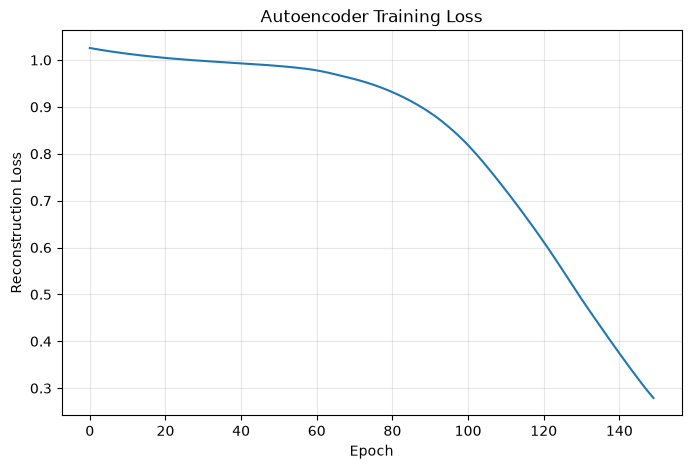

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(ae_losses)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")

plt.grid(alpha=0.3)
plt.show()

## 2.19 Learning a Latent Representation

The encoder compresses the original four-dimensional input into a two-dimensional latent representation.

We can extract this representation:

$$
z = f_{\theta}(x)
$$

The latent space can then be visualized directly.

This demonstrates an important property of deep learning:

> A neural network can learn useful representations even when explicit class labels are not provided.

In [21]:
autoencoder.eval()

with torch.no_grad():
    latent = autoencoder.encoder(X_ae)

latent = latent.cpu().numpy()

print("Original shape:", X_unsupervised.shape)
print("Latent shape:", latent.shape)

Original shape: (2000, 4)
Latent shape: (2000, 2)


## 2.20 Visualizing the Latent Space

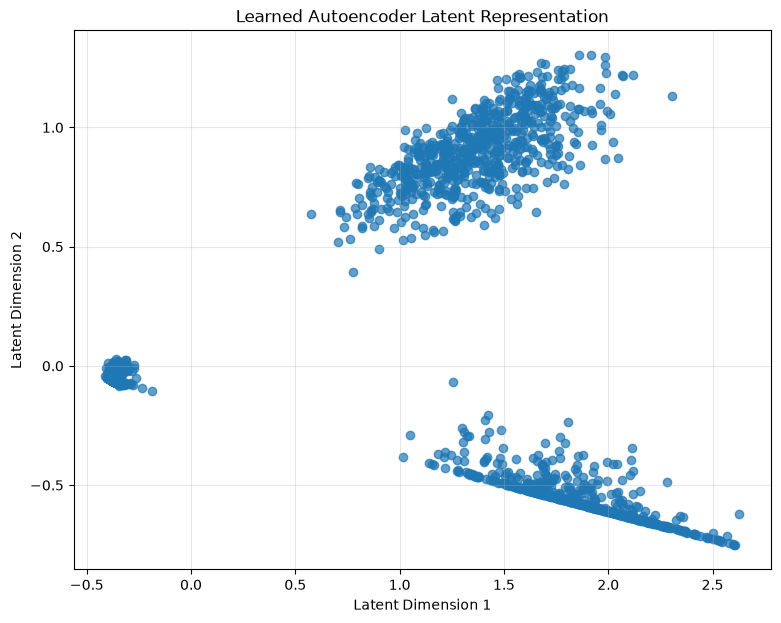

In [22]:
plt.figure(figsize=(9, 7))

plt.scatter(
    latent[:, 0],
    latent[:, 1],
    alpha=0.7
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Learned Autoencoder Latent Representation")

plt.grid(alpha=0.3)
plt.show()

The important point is not merely that the data has been reduced from 4 dimensions to 2.

The neural network learned the transformation automatically through the reconstruction objective.

## 2.21 Original vs Reconstructed Data

In [23]:
autoencoder.eval()

with torch.no_grad():
    reconstructed = autoencoder(X_ae)

reconstructed = reconstructed.cpu().numpy()

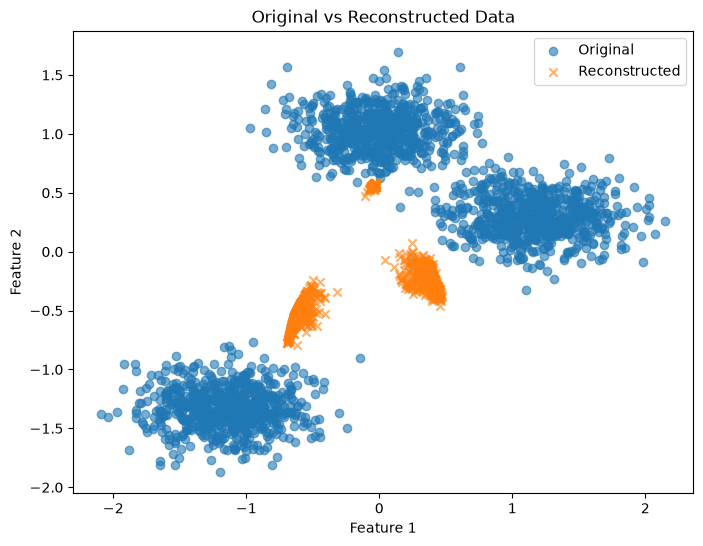

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_unsupervised[:, 0],
    X_unsupervised[:, 1],
    alpha=0.6,
    label="Original"
)

plt.scatter(
    reconstructed[:, 0],
    reconstructed[:, 1],
    alpha=0.6,
    marker="x",
    label="Reconstructed"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original vs Reconstructed Data")
plt.legend()

plt.show()

## 2.22 Supervised vs Unsupervised Deep Learning

The key difference is the source of the learning signal.

| Aspect | Supervised Deep Learning | Unsupervised Deep Learning |
|---|---|---|
| Labels | Required | Not required |
| Learning signal | Human-provided targets | Structure within the data |
| Typical task | Classification / Regression | Representation / Reconstruction |
| Example | Image classification | Autoencoder |
| Target | External label | Often derived from the input |
| Main objective | Prediction | Discover useful structure |

### Core distinction

Supervised learning:

$$
x \rightarrow y
$$

The model learns to predict an externally provided target.

Autoencoder-based unsupervised learning:

$$
x \rightarrow z \rightarrow \hat{x}
$$

The model learns a representation that allows it to reconstruct the input.

Therefore:

$$
\boxed{
\text{Supervised Learning}
\neq
\text{Unsupervised Learning}
}
$$

The difference is primarily the **source of the learning signal and training objective**, not necessarily the neural network architecture.

## 2.23 Important Limitation of Autoencoders

A low reconstruction error does not automatically mean that the learned representation is useful for every downstream task.

An autoencoder is explicitly optimized for reconstruction.

Therefore, the latent representation is encouraged to preserve information useful for reconstructing the input.

Depending on the architecture, bottleneck size, regularization, and dataset, the representation may or may not capture the features that are most useful for another task.

This distinction is important:

$$
\boxed{
\text{Reconstruction Quality}
\neq
\text{Universal Representation Quality}
}
$$

Autoencoders are nevertheless important because they demonstrate how neural networks can learn meaningful representations without manually supplied labels.

## 2.24 Exam Summary — Unsupervised Deep Learning

### Remember

**1. What is unsupervised deep learning?**

Learning useful structure or representations from data without requiring human-provided target labels.

**2. What is an autoencoder?**

A neural network that learns to reconstruct its input through a learned latent representation.

**3. What are the two major components?**

- Encoder
- Decoder

**4. What is the latent representation?**

The compressed representation produced by the encoder.

**5. What is the training objective?**

Minimize reconstruction error:

$$
\mathcal{L}(x,\hat{x})
$$

**6. Why can an autoencoder be trained without labels?**

Because the input itself provides the reconstruction target.

**7. What is the fundamental difference from supervised learning?**

Supervised learning uses externally provided targets, while unsupervised learning derives its learning signal from the structure of the data or the learning objective itself.

### Key pipeline

$$
\boxed{
x
\rightarrow
Encoder
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
\rightarrow
Reconstruction\ Loss
}
$$

## 2.25 Self-Supervised Learning

Self-supervised learning is a deep learning paradigm in which the training targets are created automatically from the data itself.

Unlike supervised learning, no human-provided target labels are required for the primary pretraining objective.

The central idea is:

> Use part of the available data to create a learning signal for another part of the data.

For example:

- A sentence can be modified by masking one of its words.
- An image can be transformed into different views.
- A sequence can be divided into context and future elements.
- An image can be rotated and the model can be trained to predict the rotation.

The model learns by solving an automatically constructed task.

### Core idea

In supervised learning:

$$
x \rightarrow y
$$

where $y$ is an externally provided human label.

In self-supervised learning:

$$
x \rightarrow \text{Automatically Generated Target}
$$

The target is derived from $x$ itself.

Therefore, self-supervised learning can use large amounts of unlabeled data while still providing an explicit training objective.

### Why Self-Supervised Learning is Important

Modern deep learning systems often have access to enormous amounts of unlabeled data but relatively limited labeled data.

Human annotation can be:

- expensive
- time-consuming
- difficult to scale
- domain-specific

Self-supervised learning addresses this problem by extracting training signals directly from the available data.

A common workflow is:

$$
\text{Large Unlabeled Dataset}
\rightarrow
\text{Self-Supervised Pretraining}
\rightarrow
\text{Learned Representation}
\rightarrow
\text{Downstream Task}
$$

The pretrained representation can later be adapted to tasks such as:

- classification
- detection
- segmentation
- text classification
- question answering
- speech recognition
- retrieval

This makes self-supervised learning one of the most important paradigms in modern deep learning.

## 2.26 Pretext Tasks

A pretext task is an automatically constructed task used to train a model without requiring manually supplied labels.

The task itself is not necessarily the final application.

Instead, solving the pretext task encourages the network to learn useful representations.

### Examples

#### 1. Masked Prediction

Part of an input is hidden and the model predicts the missing information.

For example:

$$
\text{The cat [MASK] on the mat}
$$

The model may learn to predict:

$$
\text{sat}
$$

This forces the network to learn relationships between different parts of the input.

#### 2. Contrastive Learning

Different augmented views of the same example are treated as related, while views from different examples are encouraged to be distinguishable.

The model therefore learns representations in which semantically related examples are closer.

#### 3. Image Transformation Prediction

An image is transformed automatically and the model predicts which transformation was applied.

For example:

$$
x \rightarrow T(x) \rightarrow \text{Predict } T
$$

Possible transformations include rotations, crops, or other augmentations.

#### 4. Next-Element Prediction

A model predicts a future element from previous context.

For sequential data:

$$
x_1,x_2,\ldots,x_t
\rightarrow
x_{t+1}
$$

This allows the model to learn useful sequential representations.

## 2.27 Supervised vs Unsupervised vs Self-Supervised Learning

| Paradigm | Target Source | Main Objective |
|---|---|---|
| Supervised | Human-provided labels | Predict target |
| Unsupervised | Data structure / reconstruction objective | Discover structure |
| Self-Supervised | Automatically generated from data | Learn useful representations |

The distinction between supervised and self-supervised learning is particularly important.

In supervised learning:

$$
(x,y)
$$

is supplied by the dataset.

In self-supervised learning:

$$
x \rightarrow (x',y')
$$

where $x'$ and $y'$ are constructed automatically from the original data.

Therefore:

$$
\boxed{
\text{Self-Supervision}
=
\text{Learning from Automatically Generated Targets}
}
$$

## 2.28 Self-Supervised Learning — Practical Example

We will now build a simple self-supervised learning example.

The goal is to demonstrate the central mechanism:

$$
\text{Unlabeled Data}
\rightarrow
\text{Create Target from Data}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Prediction}
\rightarrow
\text{Loss}
$$

We will use a simple **masked-feature prediction task**.

The original data contains several features, but during training one feature will be hidden from the model.

The model must predict the hidden feature using the remaining features.

No external class label is required.

This demonstrates how the data itself can provide the learning signal.

In [25]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, _ = make_regression(
    n_samples=3000,
    n_features=4,
    n_informative=4,
    noise=0.2,
    random_state=42
)

X = X.astype(np.float32)

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test = torch.tensor(X_test, dtype=torch.float32, device=device)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: torch.Size([2400, 4])
Test shape: torch.Size([600, 4])


## 2.29 Creating a Self-Supervised Task

We will hide the fourth feature.

The model receives:

$$
[x_1,x_2,x_3,0]
$$

and must predict:

$$
x_4
$$

The important point is that $x_4$ is not a human-provided label.

It already exists inside the original input.

We simply transform the original data into:

$$
(x_{\text{masked}}, y_{\text{self}})
$$

where:

- $x_{\text{masked}}$ is the corrupted input
- $y_{\text{self}}$ is the hidden part of the original input

This automatically creates the training target.

In [26]:
def create_masked_task(X):
    X_masked = X.clone()

    target = X_masked[:, 3].clone()

    X_masked[:, 3] = 0.0

    return X_masked, target


X_train_masked, y_train_self = create_masked_task(X_train)
X_test_masked, y_test_self = create_masked_task(X_test)

print("Masked input shape:", X_train_masked.shape)
print("Self-supervised target shape:", y_train_self.shape)

Masked input shape: torch.Size([2400, 4])
Self-supervised target shape: torch.Size([2400])


## 2.30 Self-Supervised Neural Network

The network receives the masked feature vector and predicts the missing feature.

Architecture:

$$
4
\rightarrow
32
\rightarrow
16
\rightarrow
1
$$

The final output represents the model's prediction of the hidden feature.

We use Mean Squared Error because the self-supervised target is continuous.

In [27]:
class MaskedFeaturePredictor(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


self_supervised_model = MaskedFeaturePredictor().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    self_supervised_model.parameters(),
    lr=0.001
)

print(self_supervised_model)

MaskedFeaturePredictor(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [28]:
epochs = 100

self_losses = []

for epoch in range(epochs):

    self_supervised_model.train()

    optimizer.zero_grad()

    predictions = self_supervised_model(X_train_masked)

    loss = criterion(
        predictions,
        y_train_self
    )

    loss.backward()

    optimizer.step()

    self_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {loss.item():.4f}"
        )

Epoch [20/100] Loss: 1.0037
Epoch [40/100] Loss: 0.9996
Epoch [60/100] Loss: 0.9982
Epoch [80/100] Loss: 0.9972
Epoch [100/100] Loss: 0.9964


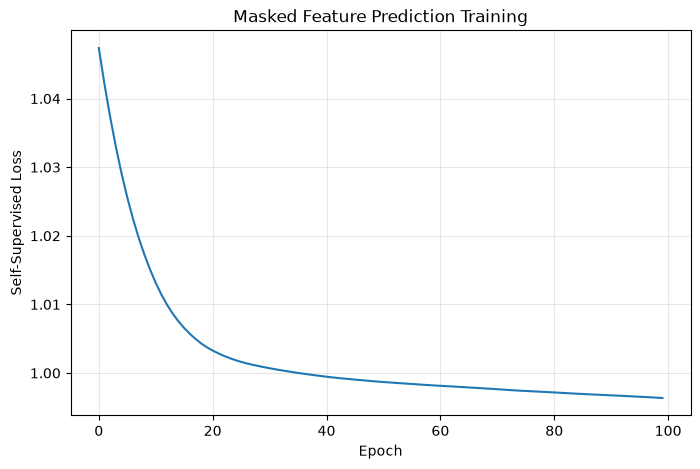

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(self_losses)

plt.xlabel("Epoch")
plt.ylabel("Self-Supervised Loss")
plt.title("Masked Feature Prediction Training")

plt.grid(alpha=0.3)
plt.show()

## 2.31 Evaluating the Self-Supervised Task

We now evaluate whether the model can reconstruct the hidden feature from the remaining features.

The model has never been given a manually created label.

Instead, the original fourth feature itself provided the target.

We evaluate using Mean Squared Error:

$$
MSE =
\frac{1}{N}
\sum_{i=1}^{N}
(y_i-\hat{y}_i)^2
$$

In [30]:
self_supervised_model.eval()

with torch.no_grad():

    test_predictions = self_supervised_model(
        X_test_masked
    )

    test_loss = criterion(
        test_predictions,
        y_test_self
    )

print(f"Test MSE: {test_loss.item():.4f}")

Test MSE: 1.0708


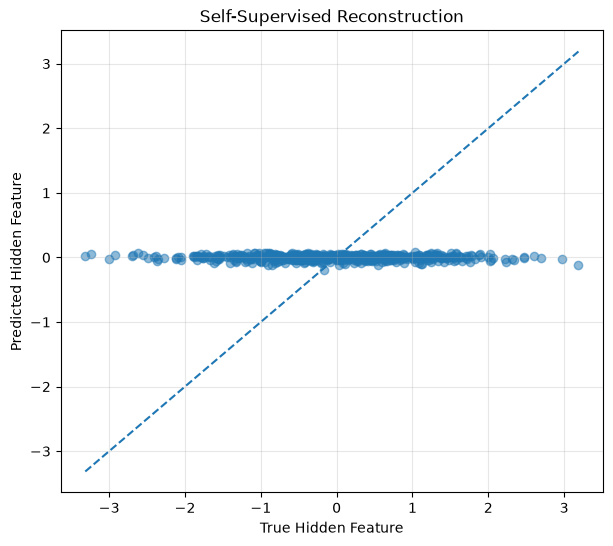

In [31]:
y_true = y_test_self.cpu().numpy()
y_pred = test_predictions.cpu().numpy()

plt.figure(figsize=(7, 6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.5
)

min_value = min(y_true.min(), y_pred.min())
max_value = max(y_true.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Hidden Feature")
plt.ylabel("Predicted Hidden Feature")
plt.title("Self-Supervised Reconstruction")

plt.grid(alpha=0.3)
plt.show()

## 2.32 Understanding What Happened

The important part of this experiment is not the numerical accuracy.

The important part is the source of the target.

We started with completely unlabeled feature vectors:

$$
x
$$

We then automatically created a prediction task:

$$
x
\rightarrow
(x_{\text{masked}},x_{\text{hidden}})
$$

The neural network learned:

$$
x_{\text{masked}}
\rightarrow
\hat{x}_{\text{hidden}}
$$

The original data therefore supplied its own learning signal.

This is the central idea of self-supervised learning.

### Important distinction

The target exists, but it is **not a human annotation**.

That is why self-supervised learning is different from conventional supervised learning.

$$
\boxed{
\text{Self-Supervised Learning}
=
\text{Supervision Generated from the Data}
}
$$

## 2.33 Contrastive Learning

Contrastive learning is an important self-supervised learning approach.

The central idea is to learn representations by comparing examples.

Instead of directly predicting a manually provided label, the model learns:

- which representations should be similar
- which representations should be different

The model is typically given different views or augmentations of data.

Two views generated from the same original example form a **positive pair**.

Views originating from different examples form **negative pairs**.

The objective is to bring positive representations closer together while pushing negative representations farther apart.

Conceptually:

$$
\text{Same Example}
\rightarrow
\text{Similar Representations}
$$

while:

$$
\text{Different Examples}
\rightarrow
\text{Different Representations}
$$

## 2.34 Positive and Negative Pairs

Suppose we have an original example $x$.

Two different augmentations can be created:

$$
x_1 = T_1(x)
$$

and

$$
x_2 = T_2(x)
$$

Although $x_1$ and $x_2$ look different, they originate from the same example.

Therefore, they form a positive pair:

$$
(x_1,x_2)
$$

For another example $x'$:

$$
x_3 = T_3(x')
$$

the pair $(x_1,x_3)$ can be treated as a negative pair.

The representation network should therefore learn:

$$
sim(z_1,z_2) \uparrow
$$

for positive pairs, and

$$
sim(z_1,z_3) \downarrow
$$

for negative pairs.

## 2.35 Representation Learning with an Encoder

A neural network encoder converts an input into a representation:

$$
z = f_{\theta}(x)
$$

For two augmented views:

$$
z_1 = f_{\theta}(T_1(x))
$$

$$
z_2 = f_{\theta}(T_2(x))
$$

The representations are then compared.

A common similarity measure is cosine similarity:

$$
\operatorname{sim}(z_1,z_2)
=
\frac{z_1^Tz_2}
{\|z_1\|\|z_2\|}
$$

Cosine similarity is high when two vectors point in similar directions.

Therefore, contrastive learning can encourage:

$$
\operatorname{sim}(z_1,z_2) \rightarrow 1
$$

for positive pairs.

For negative pairs, the objective encourages lower similarity.

In [32]:
import torch.nn.functional as F

def cosine_similarity(z1, z2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    return torch.sum(z1 * z2, dim=1)

## 2.36 Simple Contrastive Learning Demonstration

We will create synthetic two-dimensional data.

Each original point will generate two slightly different augmented views.

The encoder will transform each view into a learned representation.

The training objective will encourage representations from the same original point to become similar.

This demonstration focuses on the core mechanism rather than reproducing a large-scale modern contrastive-learning framework.

In [33]:
torch.manual_seed(42)
np.random.seed(42)

n_samples = 1000

base_data = torch.randn(
    n_samples,
    2,
    device=device
)

def augment(x, noise_scale=0.15):
    noise = torch.randn_like(x) * noise_scale
    return x + noise

view_1 = augment(base_data)
view_2 = augment(base_data)

print("Original shape:", base_data.shape)
print("View 1 shape:", view_1.shape)
print("View 2 shape:", view_2.shape)

Original shape: torch.Size([1000, 2])
View 1 shape: torch.Size([1000, 2])
View 2 shape: torch.Size([1000, 2])


In [34]:
class ContrastiveEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

    def forward(self, x):
        return self.encoder(x)


contrastive_model = ContrastiveEncoder().to(device)

optimizer = torch.optim.Adam(
    contrastive_model.parameters(),
    lr=0.001
)

## 2.37 Contrastive Objective

For this simple demonstration, we use cosine similarity.

The loss encourages positive-pair similarity to increase.

A simple objective is:

$$
\mathcal{L}
=
1-
\operatorname{sim}(z_1,z_2)
$$

where:

- $z_1$ is the representation of the first augmented view
- $z_2$ is the representation of the second augmented view

Minimizing this loss encourages:

$$
\operatorname{sim}(z_1,z_2) \rightarrow 1
$$

This is a simplified contrastive objective.

Modern methods such as InfoNCE-based approaches generally incorporate negative examples explicitly.

In [35]:
epochs = 200

contrastive_losses = []

for epoch in range(epochs):

    contrastive_model.train()

    optimizer.zero_grad()

    z1 = contrastive_model(view_1)
    z2 = contrastive_model(view_2)

    similarity = cosine_similarity(z1, z2)

    loss = 1 - similarity.mean()

    loss.backward()
    optimizer.step()

    contrastive_losses.append(loss.item())

    if (epoch + 1) % 40 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {loss.item():.4f}"
        )

Epoch [40/200] Loss: 0.0023
Epoch [80/200] Loss: 0.0007
Epoch [120/200] Loss: 0.0003
Epoch [160/200] Loss: 0.0001
Epoch [200/200] Loss: 0.0001


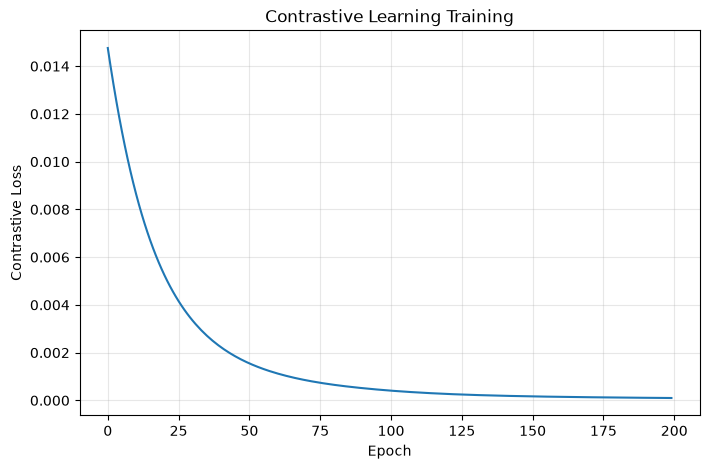

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(contrastive_losses)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Contrastive Learning Training")

plt.grid(alpha=0.3)
plt.show()

In [37]:
contrastive_model.eval()

with torch.no_grad():

    z1 = contrastive_model(view_1)
    z2 = contrastive_model(view_2)

    similarity = cosine_similarity(z1, z2)

print(
    "Average positive-pair similarity:",
    similarity.mean().item()
)

Average positive-pair similarity: 0.9999009370803833


## 2.38 Why Contrastive Learning Works

Contrastive learning does not ask the network to memorize a manually supplied class label.

Instead, it defines relationships between examples.

The model is encouraged to learn representations satisfying:

$$
x_i \sim x_j
\Rightarrow
z_i \sim z_j
$$

and:

$$
x_i \not\sim x_j
\Rightarrow
z_i \not\sim z_j
$$

The resulting representation can contain useful semantic information.

This representation can later be transferred to downstream tasks such as classification or retrieval.

The general pipeline is:

$$
\text{Raw Data}
\rightarrow
\text{Augmentations}
\rightarrow
\text{Encoder}
\rightarrow
\text{Representations}
\rightarrow
\text{Contrastive Objective}
$$

## 2.39 Important Contrastive Learning Concepts

### Positive Pair

Two augmented views that originate from the same underlying example.

### Negative Pair

Examples considered different according to the contrastive learning objective.

### Encoder

The neural network that converts an input into a representation.

### Embedding

The vector representation produced by the encoder.

### Similarity Function

A function used to measure how similar two representations are.

A common choice is cosine similarity.

### Temperature

Many modern contrastive objectives use a temperature parameter to control the sharpness of similarity-based comparisons.

A smaller temperature makes the distinction between highly similar and less similar examples sharper.

### Key idea

$$
\boxed{
\text{Learn representations by comparing examples}
}
$$

## 2.40 InfoNCE Loss

The previous contrastive-learning demonstration focused on making two augmented views of the same sample similar.

However, a complete contrastive learning objective must also distinguish between:

- **Positive pairs** — two views representing the same underlying sample.
- **Negative pairs** — views representing different samples.

A widely used objective for this purpose is the **InfoNCE loss**.

InfoNCE stands for **Information Noise-Contrastive Estimation**.

The main idea is:

> Make the representation of the positive example similar to the anchor while making representations of negative examples dissimilar.

For an anchor representation $z_i$, positive representation $z_j$, and a set of negative representations, the InfoNCE loss can be written as:

$$
\mathcal{L}_i =
-\log
\frac{
\exp(\operatorname{sim}(z_i,z_j)/\tau)
}{
\sum_{k}
\exp(\operatorname{sim}(z_i,z_k)/\tau)
}
$$

where:

- $z_i$ = anchor representation
- $z_j$ = positive representation
- $z_k$ = candidate representations
- $\operatorname{sim}(\cdot,\cdot)$ = similarity function
- $\tau$ = temperature parameter

A common similarity function is cosine similarity:

$$
\operatorname{sim}(z_i,z_j)
=
\frac{z_i^\top z_j}
{\|z_i\|\|z_j\|}
$$

The temperature controls how strongly the model focuses on differences between similarities.

A smaller $\tau$ produces a sharper probability distribution, while a larger $\tau$ produces a softer distribution.

## 2.41 Why InfoNCE Needs Negative Samples

Suppose we have an anchor representation $z_i$.

We want:

$$
\operatorname{sim}(z_i,z_i^+) \uparrow
$$

for the positive representation $z_i^+$.

At the same time, we want:

$$
\operatorname{sim}(z_i,z_k^-) \downarrow
$$

for negative representations $z_k^-$.

Therefore, contrastive learning does not simply maximize similarity.

It solves a **relative discrimination problem**:

$$
\boxed{
\text{Positive similarity}
>
\text{Negative similarity}
}
$$

This is the key difference between the simplified similarity-learning example above and a standard contrastive-learning objective such as InfoNCE.

In modern contrastive learning, other samples in the same mini-batch can often provide the negative examples.

## 2.42 Batch-Based Contrastive Learning

A convenient way to implement contrastive learning is to use a mini-batch.

Suppose a batch contains $N$ original samples.

For every sample, we create two augmented views.

Therefore, the batch contains:

$$
2N
$$

representations.

For example:

$$
x_1 \rightarrow (x_1^{(1)}, x_1^{(2)})
$$

$$
x_2 \rightarrow (x_2^{(1)}, x_2^{(2)})
$$

and so on.

For the first view of $x_1$:

- the second view of $x_1$ is the positive example
- views belonging to other samples are negative examples

This allows a single mini-batch to provide many positive and negative comparisons.

## 2.43 Creating a Contrastive Dataset

In [38]:
# Create a simple synthetic dataset

torch.manual_seed(42)
np.random.seed(42)

n_samples = 300

base_data = torch.randn(n_samples, 2, device=device)

# Create two augmented views
view_1 = base_data + 0.15 * torch.randn_like(base_data)
view_2 = base_data + 0.15 * torch.randn_like(base_data)

print("View 1 shape:", view_1.shape)
print("View 2 shape:", view_2.shape)

View 1 shape: torch.Size([300, 2])
View 2 shape: torch.Size([300, 2])


## 2.44 Visualizing the Two Views

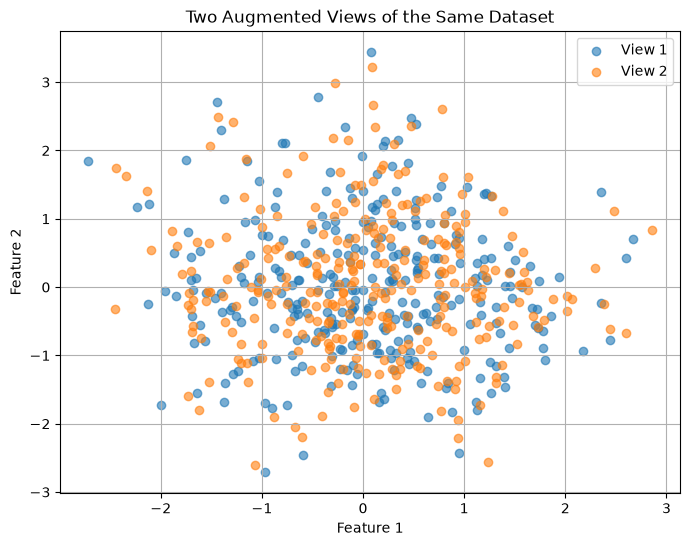

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    view_1[:, 0].cpu(),
    view_1[:, 1].cpu(),
    alpha=0.6,
    label="View 1"
)

plt.scatter(
    view_2[:, 0].cpu(),
    view_2[:, 1].cpu(),
    alpha=0.6,
    label="View 2"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two Augmented Views of the Same Dataset")
plt.legend()
plt.grid(True)
plt.show()

## 2.45 Encoder for Contrastive Learning

The encoder converts an input sample into a representation.

$$
z = f_\theta(x)
$$

where:

- $x$ = input
- $f_\theta$ = neural-network encoder
- $z$ = learned representation

For this demonstration, we use a small multilayer perceptron.

In [40]:
class ContrastiveEncoder(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, embedding_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )

    def forward(self, x):
        z = self.network(x)

        # Normalize representations for cosine similarity
        z = F.normalize(z, dim=1)

        return z


contrastive_encoder = ContrastiveEncoder().to(device)

print(contrastive_encoder)

ContrastiveEncoder(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
  )
)


## 2.46 Computing the Similarity Matrix

Instead of comparing representations one pair at a time, we can calculate the similarity between every pair in a batch.

Let:

$$
Z =
\begin{bmatrix}
z_1 \\
z_2 \\
\vdots \\
z_N
\end{bmatrix}
$$

After normalization, the cosine-similarity matrix can be calculated as:

$$
S = ZZ^\top
$$

Each element:

$$
S_{ij}
$$

represents the similarity between representations $z_i$ and $z_j$.

Therefore:

- diagonal elements represent self-similarity
- large values indicate similar representations
- small values indicate dissimilar representations

In [41]:
with torch.no_grad():
    z1 = contrastive_encoder(view_1[:32])
    z2 = contrastive_encoder(view_2[:32])

similarity_matrix = z1 @ z2.T

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: torch.Size([32, 32])


## 2.47 Implementing InfoNCE Loss

We can implement a batch-based InfoNCE loss using the similarity matrix.

For each representation in the first view:

- the representation at the same index in the second view is the positive
- all other representations in the second view act as negatives

Therefore, the correct class for each row is simply its corresponding index.

The temperature parameter $\tau$ scales the similarities:

$$
S' = \frac{S}{\tau}
$$

The cross-entropy loss can then be applied to these scaled similarities.

This provides a convenient implementation of InfoNCE.

In [42]:
def info_nce_loss(z1, z2, temperature=0.5):
    # Normalize representations
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Pairwise cosine similarities
    similarity = torch.matmul(z1, z2.T)

    # Temperature scaling
    logits = similarity / temperature

    # Matching index is the positive example
    labels = torch.arange(z1.size(0), device=z1.device)

    loss = F.cross_entropy(logits, labels)

    return loss

## 2.48 Testing the InfoNCE Loss

In [43]:
with torch.no_grad():
    z1 = contrastive_encoder(view_1[:64])
    z2 = contrastive_encoder(view_2[:64])

loss = info_nce_loss(z1, z2)

print("Initial InfoNCE loss:", loss.item())

Initial InfoNCE loss: 3.3635807037353516


## 2.49 Training with InfoNCE

Now we train the encoder directly using the InfoNCE objective.

The training process is:

$$
x^{(1)}
\rightarrow
Encoder
\rightarrow
z^{(1)}
$$

and

$$
x^{(2)}
\rightarrow
Encoder
\rightarrow
z^{(2)}
$$

Then:

$$
z^{(1)},z^{(2)}
\rightarrow
InfoNCE
\rightarrow
Loss
$$

The optimizer updates the encoder parameters so that corresponding views become more similar while non-corresponding views become relatively less similar.

In [44]:
contrastive_encoder = ContrastiveEncoder().to(device)

optimizer = torch.optim.Adam(
    contrastive_encoder.parameters(),
    lr=1e-3
)

epochs = 300
batch_size = 64

loss_history = []

for epoch in range(epochs):

    permutation = torch.randperm(
        n_samples,
        device=device
    )

    epoch_loss = 0.0

    for start in range(0, n_samples, batch_size):

        indices = permutation[start:start + batch_size]

        batch_view_1 = view_1[indices]
        batch_view_2 = view_2[indices]

        z1 = contrastive_encoder(batch_view_1)
        z2 = contrastive_encoder(batch_view_2)

        loss = info_nce_loss(
            z1,
            z2,
            temperature=0.5
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= ((n_samples + batch_size - 1) // batch_size)

    loss_history.append(epoch_loss)

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch [50/300] Loss: 2.6310
Epoch [100/300] Loss: 2.5833
Epoch [150/300] Loss: 2.5793
Epoch [200/300] Loss: 2.5586
Epoch [250/300] Loss: 2.5636
Epoch [300/300] Loss: 2.5462


## 2.50 InfoNCE Training Curve

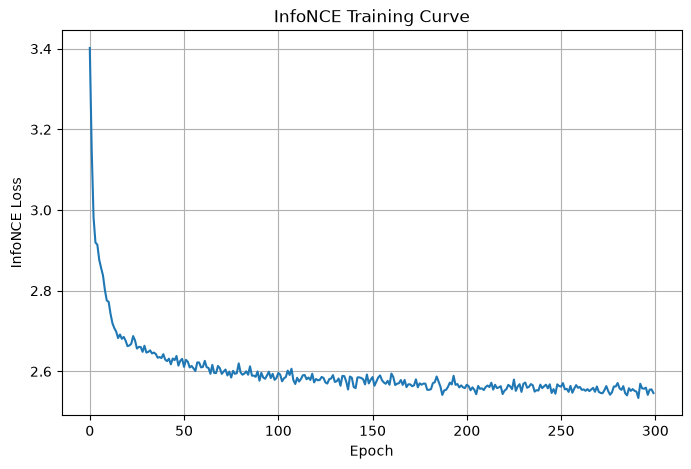

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
plt.title("InfoNCE Training Curve")
plt.grid(True)

plt.show()

## 2.51 Evaluating Positive and Negative Similarity

A useful way to understand contrastive learning is to compare:

1. Similarity between positive pairs.
2. Similarity between negative pairs.

After training, the positive-pair similarity should generally be higher than the similarity between randomly selected negative pairs.

This provides an intuitive interpretation of what the encoder has learned.

In [46]:
contrastive_encoder.eval()

with torch.no_grad():

    z1 = contrastive_encoder(view_1)
    z2 = contrastive_encoder(view_2)

    similarity_matrix = z1 @ z2.T

    positive_similarity = similarity_matrix.diag().mean().item()

    n = similarity_matrix.size(0)

    mask = ~torch.eye(
        n,
        dtype=torch.bool,
        device=device
    )

    negative_similarity = similarity_matrix[mask].mean().item()

print(f"Average positive similarity: {positive_similarity:.4f}")
print(f"Average negative similarity: {negative_similarity:.4f}")

Average positive similarity: 0.9235
Average negative similarity: 0.0015


## 2.52 Visualizing the Similarity Matrix

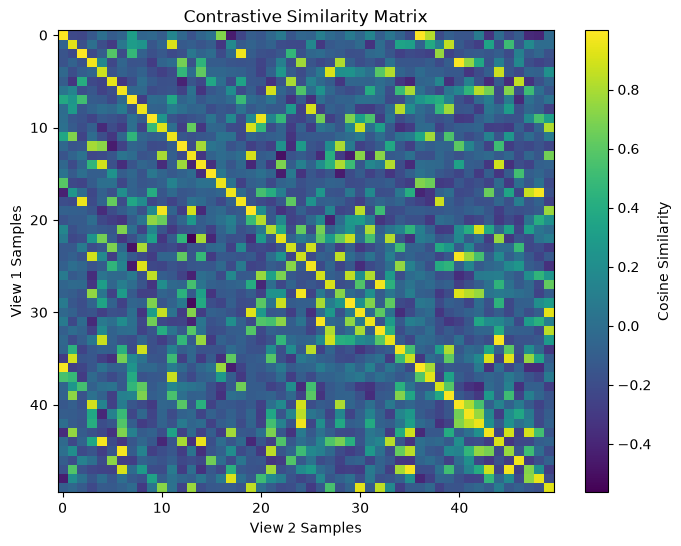

In [47]:
plt.figure(figsize=(8, 6))

plt.imshow(
    similarity_matrix[:50, :50].cpu().numpy(),
    aspect="auto"
)

plt.colorbar(label="Cosine Similarity")

plt.xlabel("View 2 Samples")
plt.ylabel("View 1 Samples")
plt.title("Contrastive Similarity Matrix")

plt.show()

The diagonal corresponds to positive pairs.

The off-diagonal entries correspond to negative comparisons.

## 2.53 Understanding InfoNCE

InfoNCE transforms contrastive learning into a classification-like problem.

For each anchor representation:

$$
z_i
$$

the model must identify the correct positive representation among several candidates.

Therefore:

$$
\boxed{
\text{Anchor}
\rightarrow
\text{Choose the correct positive}
}
$$

The candidates contain:

- one positive representation
- multiple negative representations

The model learns representations where the positive pair receives a higher similarity score.

Conceptually:

$$
\boxed{
\text{Positive similarity}
\uparrow
\qquad
\text{Negative similarity}
\downarrow
}
$$

This makes InfoNCE one of the fundamental objectives used in modern contrastive representation learning.

## 2.54 Temperature Parameter

The temperature parameter $\tau$ controls the sharpness of the similarity distribution.

The scaled similarity is:

$$
s_{ij}' =
\frac{s_{ij}}{\tau}
$$

where:

$$
\tau > 0
$$

A smaller temperature makes differences in similarity more important.

A larger temperature produces a softer distribution.

Therefore, temperature is an important hyperparameter in contrastive learning.

Common contrastive-learning systems often tune this parameter experimentally rather than treating it as a fixed universal value.

## 2.55 Contrastive Learning Summary

### Core idea

Learn representations by comparing examples.

### Positive pair

Two views representing the same underlying sample.

### Negative pair

Views representing different samples.

### Encoder

Maps the input into a representation:

$$
z = f_\theta(x)
$$

### Similarity

A common choice is cosine similarity:

$$
\operatorname{sim}(z_i,z_j)
=
\frac{z_i^\top z_j}
{\|z_i\|\|z_j\|}
$$

### InfoNCE

Encourages the positive representation to receive a higher similarity score than negative representations.

$$
\mathcal{L}_i =
-\log
\frac{
\exp(\operatorname{sim}(z_i,z_i^+)/\tau)
}{
\sum_k
\exp(\operatorname{sim}(z_i,z_k)/\tau)
}
$$

### Important concepts

- Positive pairs
- Negative pairs
- Data augmentation
- Representation encoder
- Similarity function
- Temperature
- Batch negatives
- InfoNCE loss

### Key pipeline

$$
\boxed{
x
\rightarrow
\text{Augmentations}
\rightarrow
\text{Encoder}
\rightarrow
z
\rightarrow
\text{Similarity}
\rightarrow
\text{InfoNCE}
\rightarrow
\text{Representation Learning}
}
$$

## 2.56 Semi-Supervised Deep Learning

Semi-supervised deep learning combines:

- A small amount of labeled data
- A large amount of unlabeled data

The central idea is that obtaining labeled data can be expensive, while collecting unlabeled data is often much easier.

Suppose we have:

$$
\mathcal{D}_L =
\{(x_i,y_i)\}_{i=1}^{N_L}
$$

as the labeled dataset, and:

$$
\mathcal{D}_U =
\{x_j\}_{j=1}^{N_U}
$$

as the unlabeled dataset.

Usually:

$$
N_U \gg N_L
$$

The model learns from both sources.

A simplified objective is:

$$
\mathcal{L}
=
\mathcal{L}_{supervised}
+
\lambda
\mathcal{L}_{unsupervised}
$$

where:

- $\mathcal{L}_{supervised}$ measures error on labeled examples.
- $\mathcal{L}_{unsupervised}$ provides a learning signal from unlabeled examples.
- $\lambda$ controls the contribution of the unsupervised objective.

Therefore:

$$
\boxed{
\text{Semi-Supervised Learning}
=
\text{Labeled Data}
+
\text{Unlabeled Data}
}
$$

## 2.57 Why Semi-Supervised Learning?

Consider an image-classification problem.

Suppose we have:

- 1,000 labeled images
- 50,000 unlabeled images

Training only on the 1,000 labeled images wastes potentially useful information contained in the remaining 50,000 images.

Semi-supervised learning attempts to exploit both datasets.

The basic intuition is:

$$
\boxed{
\text{Few Labels}
+
\text{Many Unlabeled Samples}
\rightarrow
\text{Better Representation}
}
$$

This is particularly useful when:

- Labeling requires human experts.
- Labeling is expensive.
- Unlabeled data is abundant.
- The dataset contains meaningful structure that can be learned without labels.

## 2.58 Labeled and Unlabeled Data

In [48]:
# Create a synthetic classification dataset

torch.manual_seed(42)
np.random.seed(42)

n_total = 1000

X = torch.randn(n_total, 2, device=device)

y = (
    (X[:, 0] ** 2 + X[:, 1] ** 2 > 1.0)
    .long()
)

print("Total samples:", len(X))
print("Class 0:", (y == 0).sum().item())
print("Class 1:", (y == 1).sum().item())

Total samples: 1000
Class 0: 371
Class 1: 629


Now simulate a realistic semi-supervised setting where only a small portion is labeled.

In [49]:
# Select a small labeled subset

n_labeled = 100

labeled_indices = torch.randperm(
    n_total,
    device=device
)[:n_labeled]

unlabeled_mask = torch.ones(
    n_total,
    dtype=torch.bool,
    device=device
)

unlabeled_mask[labeled_indices] = False

unlabeled_indices = torch.where(
    unlabeled_mask
)[0]

X_labeled = X[labeled_indices]
y_labeled = y[labeled_indices]

X_unlabeled = X[unlabeled_indices]

print("Labeled samples:", len(X_labeled))
print("Unlabeled samples:", len(X_unlabeled))

Labeled samples: 100
Unlabeled samples: 900


## 2.59 Visualizing the Semi-Supervised Dataset

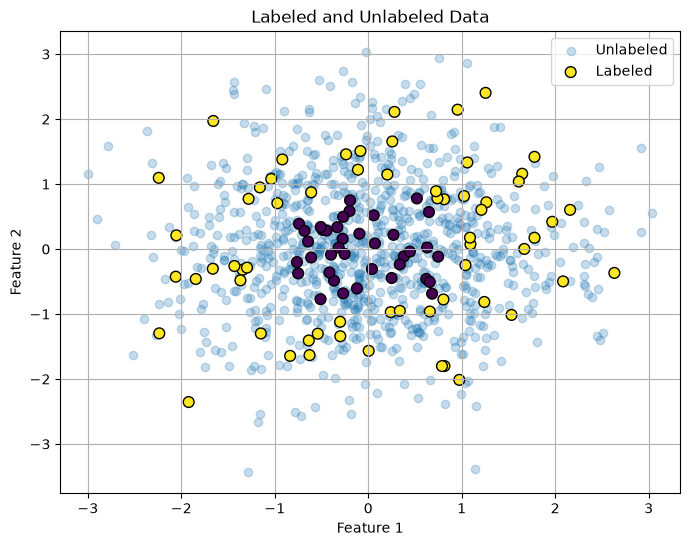

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_unlabeled[:, 0].cpu(),
    X_unlabeled[:, 1].cpu(),
    alpha=0.25,
    label="Unlabeled"
)

plt.scatter(
    X_labeled[:, 0].cpu(),
    X_labeled[:, 1].cpu(),
    c=y_labeled.cpu(),
    edgecolors="black",
    s=60,
    label="Labeled"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Labeled and Unlabeled Data")
plt.legend()
plt.grid(True)

plt.show()

The visualization should make the central idea clear:

Most samples have no labels.
Only a small subset provides explicit supervision.

## 2.60 Basic Semi-Supervised Strategy

A simple semi-supervised approach is to train the model using:

1. Supervised loss on labeled data.
2. A consistency-based loss on unlabeled data.

For labeled samples:

$$
\mathcal{L}_{sup}
=
CE(f_\theta(x_L),y_L)
$$

For unlabeled samples, we can create two different augmentations:

$$
x_U^{(1)}
$$

and

$$
x_U^{(2)}
$$

The model should produce consistent predictions:

$$
f_\theta(x_U^{(1)})
\approx
f_\theta(x_U^{(2)})
$$

A consistency loss can therefore be defined as:

$$
\mathcal{L}_{cons}
=
D
\left(
p^{(1)},p^{(2)}
\right)
$$

where $D$ measures the difference between the two predictions.

The combined objective becomes:

$$
\boxed{
\mathcal{L}
=
\mathcal{L}_{sup}
+
\lambda\mathcal{L}_{cons}
}
$$

## 2.61 Building the Semi-Supervised Model

In [51]:
class SemiSupervisedNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=2):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)


model_ssl = SemiSupervisedNetwork().to(device)

print(model_ssl)

SemiSupervisedNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 2.62 Supervised Loss

For the labeled examples, we use the standard classification cross-entropy loss.

$$
\mathcal{L}_{sup}
=
-\frac{1}{N_L}
\sum_{i=1}^{N_L}
\log p_\theta(y_i|x_i)
$$

This is the familiar supervised learning component.

The important difference is that only a small portion of the available data contributes directly to this loss.

In [52]:
criterion = nn.CrossEntropyLoss()

logits_labeled = model_ssl(X_labeled)

supervised_loss = criterion(
    logits_labeled,
    y_labeled
)

print("Supervised loss:", supervised_loss.item())

Supervised loss: 0.7004920840263367


## 2.63 Consistency Loss

For unlabeled data, we do not know the correct target $y$.

Therefore, ordinary supervised cross-entropy cannot be directly calculated.

Instead, we can ask the model to produce similar predictions for two perturbed versions of the same input.

For example:

$$
x
\rightarrow
x^{(1)}
$$

and:

$$
x
\rightarrow
x^{(2)}
$$

The model produces:

$$
p^{(1)} = f_\theta(x^{(1)})
$$

and:

$$
p^{(2)} = f_\theta(x^{(2)})
$$

We encourage:

$$
p^{(1)} \approx p^{(2)}
$$

This is called **consistency regularization**.

## 2.64 Creating Two Views of Unlabeled Data

In [53]:
# Create two noisy views of the same unlabeled samples

noise_scale = 0.10

X_unlabeled_view_1 = (
    X_unlabeled
    + noise_scale * torch.randn_like(X_unlabeled)
)

X_unlabeled_view_2 = (
    X_unlabeled
    + noise_scale * torch.randn_like(X_unlabeled)
)

print(
    "View 1 shape:",
    X_unlabeled_view_1.shape
)

print(
    "View 2 shape:",
    X_unlabeled_view_2.shape
)

View 1 shape: torch.Size([900, 2])
View 2 shape: torch.Size([900, 2])


## 2.65 Computing Consistency Loss

In [54]:
def consistency_loss(model, x1, x2):
    logits_1 = model(x1)
    logits_2 = model(x2)

    probabilities_1 = F.softmax(logits_1, dim=1)
    probabilities_2 = F.softmax(logits_2, dim=1)

    return F.mse_loss(
        probabilities_1,
        probabilities_2
    )


cons_loss = consistency_loss(
    model_ssl,
    X_unlabeled_view_1,
    X_unlabeled_view_2
)

print("Consistency loss:", cons_loss.item())

Consistency loss: 3.3632779377512634e-05


## 2.66 Combined Semi-Supervised Objective

The total objective combines both learning signals:

$$
\mathcal{L}_{total}
=
\mathcal{L}_{sup}
+
\lambda
\mathcal{L}_{cons}
$$

The hyperparameter $\lambda$ determines how strongly the unlabeled data influences training.

For example:

$$
\lambda = 0.5
$$

means that the consistency objective contributes half as strongly as its raw loss value.

The correct value of $\lambda$ depends on the dataset and training strategy.

In [55]:
lambda_consistency = 0.5

total_loss = (
    supervised_loss
    + lambda_consistency * cons_loss
)

print("Total semi-supervised loss:", total_loss.item())

Total semi-supervised loss: 0.7005088925361633


## 2.67 Training the Semi-Supervised Model

In [56]:
optimizer = torch.optim.Adam(
    model_ssl.parameters(),
    lr=1e-3
)

epochs = 300

supervised_history = []
consistency_history = []
total_history = []

for epoch in range(epochs):

    model_ssl.train()

    # Supervised component
    logits_labeled = model_ssl(X_labeled)

    supervised_loss = criterion(
        logits_labeled,
        y_labeled
    )

    # Unlabeled component
    X_u1 = (
        X_unlabeled
        + noise_scale * torch.randn_like(X_unlabeled)
    )

    X_u2 = (
        X_unlabeled
        + noise_scale * torch.randn_like(X_unlabeled)
    )

    consistency = consistency_loss(
        model_ssl,
        X_u1,
        X_u2
    )

    # Combined objective
    total_loss = (
        supervised_loss
        + lambda_consistency * consistency
    )

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    supervised_history.append(
        supervised_loss.item()
    )

    consistency_history.append(
        consistency.item()
    )

    total_history.append(
        total_loss.item()
    )

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Supervised: {supervised_loss.item():.4f} "
            f"Consistency: {consistency.item():.4f} "
            f"Total: {total_loss.item():.4f}"
        )

Epoch [50/300] Supervised: 0.3565 Consistency: 0.0019 Total: 0.3575
Epoch [100/300] Supervised: 0.1271 Consistency: 0.0115 Total: 0.1329
Epoch [150/300] Supervised: 0.0524 Consistency: 0.0193 Total: 0.0620
Epoch [200/300] Supervised: 0.0282 Consistency: 0.0232 Total: 0.0398
Epoch [250/300] Supervised: 0.0180 Consistency: 0.0246 Total: 0.0303
Epoch [300/300] Supervised: 0.0127 Consistency: 0.0288 Total: 0.0271


## 2.68 Semi-Supervised Training Curves

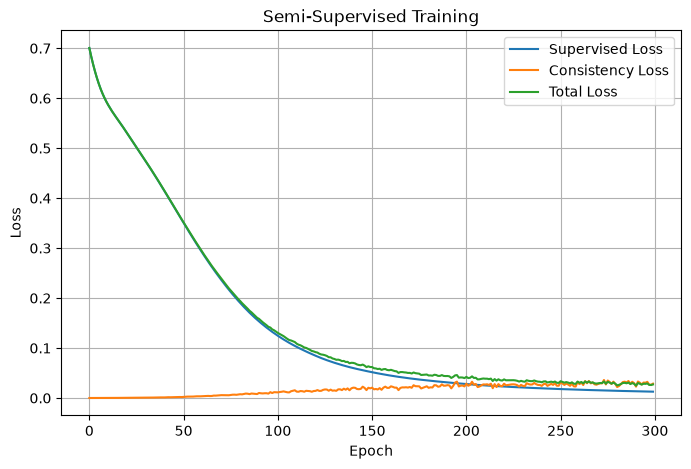

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    supervised_history,
    label="Supervised Loss"
)

plt.plot(
    consistency_history,
    label="Consistency Loss"
)

plt.plot(
    total_history,
    label="Total Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Semi-Supervised Training")
plt.legend()
plt.grid(True)

plt.show()

## 2.69 Evaluating the Model

Although unlabeled data is used during training, evaluation requires labeled data.

We can use the complete synthetic dataset because its true labels are available for this controlled experiment.

Accuracy is:

$$
Accuracy
=
\frac{\text{Correct Predictions}}
{\text{Total Predictions}}
$$

In [58]:
model_ssl.eval()

with torch.no_grad():

    logits = model_ssl(X)

    predictions = torch.argmax(
        logits,
        dim=1
    )

    accuracy = (
        predictions == y
    ).float().mean().item()

print(f"Semi-supervised accuracy: {accuracy:.4f}")

Semi-supervised accuracy: 0.9590


## 2.70 Semi-Supervised Decision Boundary

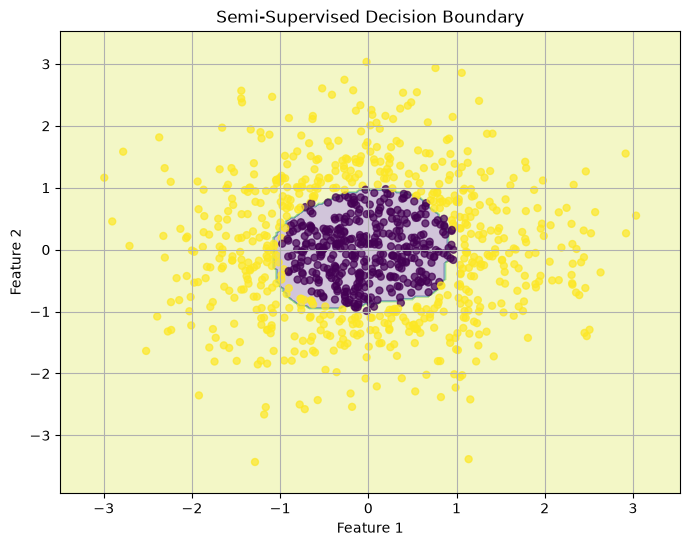

In [59]:
model_ssl.eval()

x_min = X[:, 0].min().item() - 0.5
x_max = X[:, 0].max().item() + 0.5

y_min = X[:, 1].min().item() - 0.5
y_max = X[:, 1].max().item() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()],
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    grid_logits = model_ssl(grid)

    grid_predictions = torch.argmax(
        grid_logits,
        dim=1
    )

Z = grid_predictions.cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

plt.scatter(
    X[:, 0].cpu(),
    X[:, 1].cpu(),
    c=y.cpu(),
    s=25,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Semi-Supervised Decision Boundary")
plt.grid(True)

plt.show()

## 2.71 Understanding the Learning Process

The semi-supervised model receives two different types of learning signals.

### Labeled data

The labeled samples tell the model:

> "This input belongs to this class."

Therefore:

$$
(x_L,y_L)
\rightarrow
\mathcal{L}_{sup}
$$

### Unlabeled data

The unlabeled samples do not provide explicit class labels.

Instead, consistency regularization tells the model:

> "Different reasonable views of the same input should produce similar predictions."

Therefore:

$$
x_U^{(1)},x_U^{(2)}
\rightarrow
\mathcal{L}_{cons}
$$

The two signals are combined:

$$
\boxed{
\mathcal{L}_{total}
=
\mathcal{L}_{sup}
+
\lambda\mathcal{L}_{cons}
}
$$

This allows the model to use information from both labeled and unlabeled examples.

## 2.72 Semi-Supervised Learning vs Other Paradigms

| Paradigm | Labeled Data | Unlabeled Data | Main Learning Signal |
|---|---:|---:|---|
| Supervised | Required | Optional | Ground-truth labels |
| Unsupervised | Not required | Required | Data structure |
| Self-Supervised | Not manually required | Required | Automatically generated targets |
| Semi-Supervised | Small amount | Large amount | Labels + unlabeled-data objective |

The key distinction is the **source and amount of supervision**.

$$
\boxed{
\text{Supervised}
\rightarrow
\text{Labels}
}
$$

$$
\boxed{
\text{Unsupervised}
\rightarrow
\text{No external labels}
}
$$

$$
\boxed{
\text{Self-Supervised}
\rightarrow
\text{Targets derived from data}
}
$$

$$
\boxed{
\text{Semi-Supervised}
\rightarrow
\text{Few labels + many unlabeled samples}
}
$$

## 2.73 Important Semi-Supervised Learning Methods

Several important approaches are used in semi-supervised deep learning.

### 1. Pseudo-Labeling

The model generates predictions for unlabeled samples.

High-confidence predictions can be treated as temporary labels.

$$
x_U
\rightarrow
f_\theta(x_U)
\rightarrow
\hat{y}_U
$$

The pseudo-label is then used as additional training supervision.

### 2. Consistency Regularization

The model is encouraged to produce similar predictions for different perturbations of the same sample.

$$
f_\theta(x^{(1)})
\approx
f_\theta(x^{(2)})
$$

### 3. Teacher-Student Learning

A teacher model generates targets for unlabeled data, while a student model learns from them.

### 4. Hybrid Objectives

Modern methods can combine:

- Supervised learning
- Pseudo-labeling
- Consistency regularization
- Representation learning
- Data augmentation

## 2.74 Exam Summary — Semi-Supervised Deep Learning

### Definition

Semi-supervised deep learning uses a small labeled dataset together with a large unlabeled dataset.

### Mathematical setup

$$
\mathcal{D}_L =
\{(x_i,y_i)\}_{i=1}^{N_L}
$$

$$
\mathcal{D}_U =
\{x_j\}_{j=1}^{N_U}
$$

Usually:

$$
N_U \gg N_L
$$

### Main objective

A common conceptual formulation is:

$$
\mathcal{L}
=
\mathcal{L}_{supervised}
+
\lambda
\mathcal{L}_{unsupervised}
$$

### Why use it?

Because labeled data can be expensive while unlabeled data is often abundant.

### Important techniques

- Pseudo-labeling
- Consistency regularization
- Teacher-student learning
- Data augmentation
- Hybrid supervised and unsupervised objectives

### Key idea

$$
\boxed{
\text{Few Labeled Samples}
+
\text{Many Unlabeled Samples}
\rightarrow
\text{Semi-Supervised Learning}
}
$$

### Exam distinction

Do not confuse semi-supervised learning with self-supervised learning.

**Semi-supervised learning** explicitly uses some human-provided labels.

**Self-supervised learning** generates its learning targets from the data itself without requiring manually supplied labels for the pretext objective.

## 2.75 Deep Reinforcement Learning

Deep Reinforcement Learning (DRL) combines:

- Reinforcement Learning
- Deep Neural Networks

In reinforcement learning, an **agent** interacts with an **environment**.

At each time step, the agent:

1. Observes the current state.
2. Selects an action.
3. Receives a reward.
4. Moves to a new state.

The interaction can be represented as:

$$
\boxed{
State
\rightarrow
Action
\rightarrow
Reward
\rightarrow
Next\ State
}
$$

Unlike supervised learning, the agent is not given the correct action for every state.

Instead, it must learn which actions lead to better long-term outcomes.

Deep learning is used to approximate important reinforcement-learning functions using neural networks.

For example:

$$
Q_\theta(s,a)
$$

can represent a neural network that estimates the expected value of taking action $a$ in state $s$.

Therefore:

$$
\boxed{
\text{Deep Reinforcement Learning}
=
\text{Reinforcement Learning}
+
\text{Deep Neural Networks}
}
$$

## 2.76 Agent and Environment

The two central components are:

### Agent

The learner that chooses actions.

Examples:

- Robot
- Game-playing system
- Autonomous vehicle
- Trading agent
- Recommendation system

### Environment

The external system with which the agent interacts.

Examples:

- Game
- Physical world
- Simulator
- Robotic environment

The interaction is:

$$
S_t
\rightarrow
A_t
\rightarrow
R_{t+1}
\rightarrow
S_{t+1}
$$

where:

- $S_t$ = state at time $t$
- $A_t$ = action selected at time $t$
- $R_{t+1}$ = reward received
- $S_{t+1}$ = next state

The agent repeatedly performs this interaction and improves its decision-making policy.

## 2.77 Reinforcement Learning Terminology

### State

The current situation of the environment.

$$
S_t
$$

### Action

A decision made by the agent.

$$
A_t
$$

### Reward

A numerical signal indicating how desirable the outcome was.

$$
R_{t+1}
$$

### Policy

A strategy that determines which action to take.

$$
\pi(a|s)
$$

The policy can be deterministic:

$$
a = \pi(s)
$$

or stochastic:

$$
\pi(a|s)
=
P(A=a|S=s)
$$

### Episode

A complete sequence of interactions from an initial state until a terminal state.

### Terminal State

A state where the episode ends.

Examples:

- Winning a game
- Losing a game
- Reaching a destination
- Robot completing a task

## 2.78 The Reinforcement Learning Loop

In [60]:
# Conceptual reinforcement-learning interaction

state = "Start"

print("Current state:", state)

action = "Move Right"

print("Agent action:", action)

reward = 1

print("Reward:", reward)

next_state = "Goal"

print("Next state:", next_state)

Current state: Start
Agent action: Move Right
Reward: 1
Next state: Goal


## 2.79 Markov Decision Process

Many reinforcement-learning problems are modeled as a **Markov Decision Process (MDP)**.

An MDP can be represented as:

$$
\mathcal{M}
=
(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

where:

- $\mathcal{S}$ = set of states
- $\mathcal{A}$ = set of actions
- $P$ = transition dynamics
- $R$ = reward function
- $\gamma$ = discount factor

The transition probability is:

$$
P(s'|s,a)
$$

which represents the probability of reaching state $s'$ after taking action $a$ in state $s$.

The reward can be represented as:

$$
R(s,a,s')
$$

The discount factor satisfies:

$$
0 \leq \gamma < 1
$$

and determines how strongly future rewards influence the current decision.

## 2.80 Return

The agent usually does not optimize only the immediate reward.

Instead, it attempts to maximize the **expected cumulative future reward**, called the return.

The discounted return at time $t$ is:

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2 R_{t+3}
+
\cdots
$$

More compactly:

$$
G_t
=
\sum_{k=0}^{\infty}
\gamma^k R_{t+k+1}
$$

where $\gamma$ controls the importance of future rewards.

If:

$$
\gamma \approx 0
$$

the agent focuses primarily on immediate rewards.

If:

$$
\gamma \approx 1
$$

future rewards become much more important.

This distinction is fundamental to reinforcement learning because an action that produces a poor immediate reward can still be optimal if it leads to better future outcomes.

## 2.81 Value Function

The value function estimates how desirable a state is.

The state-value function is:

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t|S_t=s]
$$

It represents the expected return when starting from state $s$ and following policy $\pi$.

A high value means the state is expected to lead to good future rewards.

A low value means the state is expected to lead to poor future rewards.

## 2.82 Action-Value Function

The action-value function, or **Q-function**, evaluates both the state and the selected action.

It is defined as:

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi
\left[
G_t
\mid
S_t=s,A_t=a
\right]
$$

It answers:

> How good is it to take action $a$ when the agent is in state $s$?

The optimal Q-function is:

$$
Q^*(s,a)
=
\max_\pi Q^\pi(s,a)
$$

A greedy policy can then select:

$$
a^*
=
\arg\max_a Q^*(s,a)
$$

This idea is the foundation of value-based deep reinforcement-learning methods such as Deep Q-Networks.

## 2.83 Bellman Equation

The Bellman equation expresses the recursive structure of the value function.

For the optimal action-value function:

$$
Q^*(s,a)
=
\mathbb{E}
\left[
R_{t+1}
+
\gamma
\max_{a'}
Q^*(s',a')
\mid
s,a
\right]
$$

The important idea is:

$$
\boxed{
\text{Current Value}
=
\text{Immediate Reward}
+
\text{Discounted Future Value}
}
$$

This recursive relationship is extremely important in reinforcement learning.

Deep reinforcement learning methods often use neural networks to approximate these value functions.

## 2.84 Deep Q-Network (DQN)

A Deep Q-Network uses a neural network to approximate the Q-function.

Instead of storing a table:

$$
Q(s,a)
$$

we learn a parameterized function:

$$
Q_\theta(s,a)
$$

where $\theta$ represents the neural-network parameters.

For a state $s$, the neural network produces one Q-value for each possible action.

For example:

$$
Network(s)
\rightarrow
[
Q(s,a_1),
Q(s,a_2),
Q(s,a_3)
]
$$

The agent can select the action with the largest predicted Q-value:

$$
a^*
=
\arg\max_a Q_\theta(s,a)
$$

This allows deep neural networks to handle environments with very large or continuous state representations where a traditional Q-table would be impractical.

## 2.85 A Simple Deep Q-Network

In [61]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, state):
        return self.network(state)


state_dim = 4
action_dim = 2

dqn = DQN(
    state_dim=state_dim,
    action_dim=action_dim
).to(device)

print(dqn)

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 2.86 Predicting Q-Values

In [62]:
sample_state = torch.randn(
    1,
    state_dim,
    device=device
)

with torch.no_grad():

    q_values = dqn(sample_state)

print("State shape:", sample_state.shape)
print("Q-values:", q_values)
print("Selected action:", torch.argmax(q_values, dim=1).item())

State shape: torch.Size([1, 4])
Q-values: tensor([[0.2615, 0.2922]], device='cuda:0')
Selected action: 1


The network produces one Q-value for each available action.

## 2.87 Temporal-Difference Target

DQN learns using a temporal-difference target.

For a transition:

$$
(s,a,r,s')
$$

the target is:

$$
y
=
r
+
\gamma
\max_{a'}
Q_{\theta}(s',a')
$$

for a non-terminal transition.

If the next state is terminal:

$$
y=r
$$

The neural network is trained so that:

$$
Q_\theta(s,a)
\approx
y
$$

A common loss is:

$$
\mathcal{L}
=
\left(
Q_\theta(s,a)-y
\right)^2
$$

In practical DQN implementations, additional techniques such as a target network and experience replay are used to improve stability.

## 2.88 Computing a DQN Loss

In [63]:
# Example transition

state = torch.randn(
    1,
    state_dim,
    device=device
)

next_state = torch.randn(
    1,
    state_dim,
    device=device
)

action = torch.tensor(
    [0],
    device=device
)

reward = torch.tensor(
    [1.0],
    device=device
)

done = torch.tensor(
    [False],
    device=device
)

gamma = 0.99

q_values = dqn(state)

current_q = q_values.gather(
    1,
    action.unsqueeze(1)
).squeeze(1)

with torch.no_grad():

    next_q_values = dqn(next_state)

    max_next_q = next_q_values.max(
        dim=1
    ).values

    target_q = reward + (
        gamma
        * max_next_q
        * (~done)
    )

loss = F.mse_loss(
    current_q,
    target_q
)

print("Current Q-value:", current_q.item())
print("Target Q-value:", target_q.item())
print("DQN loss:", loss.item())

Current Q-value: 0.05234811455011368
Target Q-value: 1.1437265872955322
DQN loss: 1.191106915473938


## 2.89 Exploration vs Exploitation

A reinforcement-learning agent faces a fundamental problem.

Should it:

### Exploit

Choose the action that currently appears to be the best?

or:

### Explore

Try a different action to discover whether it might produce a better result?

This is called the **exploration-exploitation trade-off**.

A common strategy is **epsilon-greedy action selection**.

With probability $\epsilon$:

$$
a
\sim
\text{Random Actions}
$$

With probability $1-\epsilon$:

$$
a
=
\arg\max_a Q(s,a)
$$

Therefore:

$$
\boxed{
\epsilon\text{-greedy}
=
\text{Exploration}
+
\text{Exploitation}
}
$$

## 2.90 Epsilon-Greedy Action Selection

In [64]:
import random


def epsilon_greedy_action(
    model,
    state,
    epsilon,
    action_dim
):
    if random.random() < epsilon:
        return random.randrange(action_dim)

    with torch.no_grad():

        q_values = model(state)

        return torch.argmax(
            q_values,
            dim=1
        ).item()


epsilon = 0.1

action = epsilon_greedy_action(
    dqn,
    sample_state,
    epsilon,
    action_dim
)

print("Selected action:", action)

Selected action: 1


## 2.91 Experience Replay

Deep reinforcement learning can suffer from highly correlated consecutive experiences.

DQN addresses this using an **experience replay buffer**.

The agent stores transitions:

$$
(s,a,r,s',done)
$$

in a memory buffer.

During training, random mini-batches are sampled from this buffer.

The process is:

$$
\boxed{
Interaction
\rightarrow
Store Experience
\rightarrow
Sample Random Batch
\rightarrow
Train Network
}
$$

Experience replay provides several benefits:

- Reduces correlation between consecutive samples.
- Reuses previously collected experiences.
- Improves training efficiency.
- Helps stabilize neural-network training.

## 2.92 Simple Replay Buffer

In [65]:
from collections import deque
import random


class ReplayBuffer:

    def __init__(self, capacity=10000):
        self.buffer = deque(
            maxlen=capacity
        )

    def push(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):
        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(self, batch_size):
        return random.sample(
            self.buffer,
            batch_size
        )

    def __len__(self):
        return len(self.buffer)


replay_buffer = ReplayBuffer(
    capacity=1000
)

print("Replay buffer created.")

Replay buffer created.


## 2.93 Target Network

Another important DQN technique is the **target network**.

If the same network is used to:

1. Predict the current Q-value.
2. Generate the target Q-value.

then the target itself changes whenever the network parameters change.

This can make training unstable.

DQN therefore maintains two networks:

### Online network

$$
Q_\theta
$$

Used for learning.

### Target network

$$
Q_{\theta^-}
$$

Used to calculate the target.

The target becomes:

$$
y
=
r
+
\gamma
\max_{a'}
Q_{\theta^-}(s',a')
$$

The target network is periodically updated from the online network.

This reduces harmful feedback loops and improves training stability.

## 2.94 Creating Online and Target Networks

In [66]:
online_network = DQN(
    state_dim,
    action_dim
).to(device)

target_network = DQN(
    state_dim,
    action_dim
).to(device)

target_network.load_state_dict(
    online_network.state_dict()
)

target_network.eval()

print("Online and target networks initialized.")

Online and target networks initialized.


## 2.95 Deep Reinforcement Learning Pipeline

A simplified DQN training pipeline is:

$$
\boxed{
State
\rightarrow
DQN
\rightarrow
Action
\rightarrow
Environment
\rightarrow
Reward,\ Next\ State
}
$$

The transition is stored:

$$
(s,a,r,s',done)
$$

Then:

$$
Replay\ Buffer
\rightarrow
Mini\ Batch
\rightarrow
TD\ Target
\rightarrow
Loss
\rightarrow
Backpropagation
$$

The major components are:

1. Environment
2. Agent
3. State
4. Action
5. Reward
6. Policy
7. Q-function
8. Replay buffer
9. Target network
10. Neural-network optimizer

## 2.96 Reinforcement Learning vs Supervised Learning

| Property | Supervised Learning | Reinforcement Learning |
|---|---|---|
| Training signal | Ground-truth label | Reward |
| Data source | Dataset | Environment interaction |
| Correct action provided? | Usually yes | No |
| Feedback | Usually immediate | Can be delayed |
| Main objective | Prediction accuracy | Expected cumulative reward |
| Decision sequence | Usually independent samples | Sequential decisions |
| Exploration | Usually not required | Fundamental |
| Environment interaction | Not required | Central |

The fundamental difference is:

$$
\boxed{
\text{Supervised Learning}
\rightarrow
\text{Learn from labels}
}
$$

while:

$$
\boxed{
\text{Reinforcement Learning}
\rightarrow
\text{Learn from consequences}
}
$$

## 2.97 Exam Summary — Deep Reinforcement Learning

### Definition

Deep Reinforcement Learning combines reinforcement learning with deep neural networks.

### Core interaction

$$
S_t
\rightarrow
A_t
\rightarrow
R_{t+1}
\rightarrow
S_{t+1}
$$

### MDP

$$
\mathcal{M}
=
(\mathcal{S},\mathcal{A},P,R,\gamma)
$$

### Return

$$
G_t
=
\sum_{k=0}^{\infty}
\gamma^kR_{t+k+1}
$$

### Value function

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t|S_t=s]
$$

### Q-function

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi[G_t|S_t=s,A_t=a]
$$

### Optimal action

$$
a^*
=
\arg\max_a Q^*(s,a)
$$

### DQN

DQN approximates the Q-function using a neural network:

$$
Q_\theta(s,a)
$$

### Important DQN techniques

- Experience replay
- Target network
- Epsilon-greedy exploration
- Temporal-difference learning

### Key idea

$$
\boxed{
\text{Interact}
\rightarrow
\text{Receive Reward}
\rightarrow
\text{Learn}
\rightarrow
\text{Improve Actions}
}
$$

### Most important exam distinction

Supervised learning learns from explicit target labels.

Reinforcement learning learns from reward signals produced by interaction with an environment.

## 2.98 Policy-Based Deep Reinforcement Learning

The previous sections introduced **value-based reinforcement learning**, where the agent learns a value function such as:

$$
Q_\theta(s,a)
$$

and selects actions using:

$$
a^*
=
\arg\max_a Q_\theta(s,a)
$$

A different approach is **policy-based reinforcement learning**.

Instead of learning which action has the highest value and then deriving the action from that value, the model directly learns a policy.

The policy is represented by a neural network:

$$
\pi_\theta(a|s)
$$

which gives the probability of selecting action $a$ given state $s$.

Therefore:

$$
\boxed{
\text{Value-Based}
\rightarrow
\text{Learn } Q(s,a)
}
$$

while:

$$
\boxed{
\text{Policy-Based}
\rightarrow
\text{Learn } \pi(a|s)
}
$$

The objective is to find parameters $\theta$ that maximize the expected return:

$$
J(\theta)
=
\mathbb{E}_{\pi_\theta}
[G_t]
$$

## 2.99 Policy Network

A policy network is a neural network that receives a state and produces an action distribution.

For a discrete action space:

$$
s
\rightarrow
\text{Neural Network}
\rightarrow
\text{Action Probabilities}
$$

For example, if there are three possible actions:

$$
\pi_\theta(a|s)
=
[
0.10,\ 0.70,\ 0.20
]
$$

then:

- Action 0 has probability $0.10$
- Action 1 has probability $0.70$
- Action 2 has probability $0.20$

The probabilities must satisfy:

$$
\sum_a \pi_\theta(a|s)=1
$$

A softmax layer is commonly used to convert the network outputs into probabilities.


## 2.99 Building a Policy Network

In [67]:
class PolicyNetwork(nn.Module):

    def __init__(
        self,
        state_dim,
        action_dim,
        hidden_dim=64
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):

        logits = self.network(state)

        return logits


policy = PolicyNetwork(
    state_dim=4,
    action_dim=2
).to(device)

print(policy)

PolicyNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


## 2.100 Converting Logits to Action Probabilities

In [68]:
sample_state = torch.randn(
    1,
    4,
    device=device
)

logits = policy(sample_state)

action_probabilities = F.softmax(
    logits,
    dim=1
)

print("Logits:")
print(logits)

print("\nAction probabilities:")
print(action_probabilities)

print(
    "\nProbability sum:",
    action_probabilities.sum(dim=1).item()
)

Logits:
tensor([[0.0578, 0.0115]], device='cuda:0', grad_fn=<AddmmBackward0>)

Action probabilities:
tensor([[0.5116, 0.4884]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

Probability sum: 1.0


## 2.101 Sampling an Action from the Policy

A policy does not necessarily have to choose the action with the highest probability.

Instead, it can **sample** an action from the learned probability distribution.

If:

$$
\pi_\theta(a|s)
=
[0.2,\ 0.5,\ 0.3]
$$

the agent can sample an action according to these probabilities.

This naturally introduces exploration.

The action is sampled according to:

$$
A_t
\sim
\pi_\theta(\cdot|S_t)
$$

This is different from simply selecting:

$$
\arg\max_a \pi_\theta(a|s)
$$

which always chooses the most probable action.

In [69]:
distribution = torch.distributions.Categorical(
    probs=action_probabilities
)

action = distribution.sample()

log_probability = distribution.log_prob(
    action
)

print("Action:", action.item())
print("Log probability:", log_probability.item())

Action: 1
Log probability: -0.7165826559066772


## 2.102 Why Use Log Probabilities?

Policy-gradient methods work with the logarithm of the probability of the selected action.

For an action $a$:

$$
\log \pi_\theta(a|s)
$$

The logarithm has a useful mathematical property:

$$
\log
\prod_t
\pi_\theta(a_t|s_t)
=
\sum_t
\log
\pi_\theta(a_t|s_t)
$$

Therefore, the probability of an entire trajectory can be converted from a product into a sum.

This makes optimization mathematically and computationally convenient.

## 2.103 Policy Gradient

Policy-gradient methods directly optimize the policy parameters.

The objective is:

$$
J(\theta)
=
\mathbb{E}_{\pi_\theta}[G_t]
$$

We want to maximize:

$$
J(\theta)
$$

Therefore, we need its gradient:

$$
\nabla_\theta J(\theta)
$$

A fundamental policy-gradient result is:

$$
\nabla_\theta J(\theta)
=
\mathbb{E}
\left[
\nabla_\theta
\log\pi_\theta(A_t|S_t)
G_t
\right]
$$

The intuition is:

- If an action produces a high return, increase its probability.
- If an action produces a poor return, decrease its probability.

Therefore:

$$
\boxed{
\text{Good Action}
\rightarrow
\text{Increase Probability}
}
$$

and:

$$
\boxed{
\text{Poor Action}
\rightarrow
\text{Decrease Probability}
}
$$

## 2.104 REINFORCE Algorithm

**REINFORCE** is a fundamental Monte Carlo policy-gradient algorithm.

The algorithm follows these steps:

1. Initialize policy parameters $\theta$.
2. Generate an episode using the current policy.
3. Store states, actions, and rewards.
4. Calculate the return for each time step.
5. Compute the policy-gradient objective.
6. Update the policy parameters.
7. Repeat.

The policy loss can be written as:

$$
\mathcal{L}_{policy}
=
-\sum_t
\log\pi_\theta(A_t|S_t)G_t
$$

The negative sign is used because deep-learning optimizers generally minimize a loss, while reinforcement learning wants to maximize expected return.

Thus:

$$
\boxed{
\text{Maximize Return}
\equiv
\text{Minimize Negative Policy Objective}
}
$$

## 2.105 Computing Discounted Returns

In [70]:
def compute_returns(
    rewards,
    gamma=0.99
):
    returns = []

    G = 0.0

    for reward in reversed(rewards):

        G = reward + gamma * G

        returns.insert(0, G)

    return torch.tensor(
        returns,
        dtype=torch.float32,
        device=device
    )


rewards = [1.0, 0.0, 2.0, 1.0]

returns = compute_returns(
    rewards,
    gamma=0.99
)

print("Rewards:", rewards)
print("Returns:", returns)

Rewards: [1.0, 0.0, 2.0, 1.0]
Returns: tensor([3.9305, 2.9601, 2.9900, 1.0000], device='cuda:0')


## 2.106 REINFORCE Policy Loss

In [71]:
# Example log probabilities
log_probs = torch.tensor(
    [-0.5, -0.8, -0.3, -0.7],
    dtype=torch.float32,
    device=device
)

returns = compute_returns(
    rewards,
    gamma=0.99
)

policy_loss = -(
    log_probs * returns
).sum()

print("Policy loss:", policy_loss.item())

Policy loss: 5.930329322814941


## 2.107 Why REINFORCE Works

Consider two actions.

Suppose an action produces a high return:

$$
G_t \gg 0
$$

Its contribution is:

$$
-\log\pi_\theta(A_t|S_t)G_t
$$

Gradient descent therefore encourages the probability of that successful action to increase.

If an action produces a poor return, its contribution is smaller or negative relative to better actions.

Over many episodes, the policy gradually learns which actions tend to produce higher returns.

The learning signal therefore comes from the consequences of the actions rather than from manually provided action labels.

## 2.108 A Simple Policy-Gradient Demonstration

In [72]:
policy = PolicyNetwork(
    state_dim=4,
    action_dim=2
).to(device)

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3
)

# Simulated episode
states = torch.randn(
    10,
    4,
    device=device
)

rewards = [
    1.0,
    0.0,
    0.0,
    1.0,
    2.0,
    0.0,
    1.0,
    0.0,
    2.0,
    1.0
]

log_probs = []

for state in states:

    logits = policy(
        state.unsqueeze(0)
    )

    probabilities = F.softmax(
        logits,
        dim=1
    )

    distribution = torch.distributions.Categorical(
        probabilities
    )

    action = distribution.sample()

    log_prob = distribution.log_prob(
        action
    )

    log_probs.append(log_prob)

log_probs = torch.cat(log_probs)

returns = compute_returns(
    rewards,
    gamma=0.99
)

# Normalize returns for training stability
returns = (
    returns - returns.mean()
) / (
    returns.std() + 1e-8
)

loss = -(
    log_probs * returns
).sum()

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Policy-gradient loss:", loss.item())

Policy-gradient loss: 0.156904935836792


## 2.109 Advantages of Policy-Based Methods

Policy-based reinforcement learning has several important advantages.

### 1. Direct policy optimization

The model directly learns:

$$
\pi_\theta(a|s)
$$

rather than indirectly deriving a policy from a value function.

### 2. Natural stochastic policies

The policy can represent:

$$
P(A=a|S=s)
$$

which is useful when multiple actions may be desirable.

### 3. Continuous action spaces

Policy-gradient methods can naturally be extended to continuous action spaces.

This is important for applications such as:

- Robotics
- Autonomous control
- Continuous physical systems

### 4. Flexible policy representation

A neural network can learn complex mappings between states and actions.

## 2.110 Limitations of REINFORCE

REINFORCE is conceptually simple, but it has important limitations.

### High variance

Returns can vary significantly between episodes.

Therefore, the estimated gradient can have high variance.

### Poor sample efficiency

REINFORCE usually needs complete episodes before calculating the return.

### Delayed learning signal

An action taken early in an episode may only receive useful feedback after many subsequent actions.

### Instability

High-variance gradient estimates can make optimization difficult.

These limitations motivate more advanced methods such as:

- Actor-Critic algorithms
- Advantage Actor-Critic
- PPO
- TRPO
- SAC

## 2.111 Value-Based vs Policy-Based Deep Reinforcement Learning

| Property | Value-Based | Policy-Based |
|---|---|---|
| Main object learned | $Q(s,a)$ or $V(s)$ | $\pi(a|s)$ |
| Action selection | Derived from values | Directly produced by policy |
| Typical example | DQN | REINFORCE |
| Stochastic policy | Less direct | Natural |
| Continuous actions | More difficult for vanilla DQN | Natural extension |
| Main challenge | Value estimation | High-variance gradients |

Conceptually:

$$
\boxed{
\text{DQN}
\rightarrow
Q(s,a)
\rightarrow
\text{Policy}
}
$$

while:

$$
\boxed{
\text{REINFORCE}
\rightarrow
\pi(a|s)
}
$$

## 2.112 Exam Summary — Policy-Based Deep Reinforcement Learning

### Policy

$$
\pi_\theta(a|s)
$$

represents the probability of selecting action $a$ given state $s$.

### Objective

$$
J(\theta)
=
\mathbb{E}_{\pi_\theta}[G_t]
$$

The goal is to maximize expected return.

### Policy gradient

$$
\nabla_\theta J(\theta)
=
\mathbb{E}
\left[
\nabla_\theta
\log\pi_\theta(A_t|S_t)
G_t
\right]
$$

### REINFORCE loss

$$
\mathcal{L}_{policy}
=
-\sum_t
\log\pi_\theta(A_t|S_t)G_t
$$

### Core intuition

$$
\boxed{
\text{High Return}
\rightarrow
\text{Increase Probability of Actions}
}
$$

### Advantages

- Direct policy optimization
- Natural stochastic policies
- Suitable for continuous-action extensions
- Flexible neural-network policies

### Limitations

- High variance
- Poor sample efficiency
- Delayed rewards
- Training instability

### Important algorithms

- REINFORCE
- Actor-Critic
- Advantage Actor-Critic
- PPO
- TRPO
- SAC

# 2.113 Actor-Critic Deep Reinforcement Learning

Actor-Critic methods combine the main ideas of **value-based** and **policy-based** reinforcement learning.

The two components are:

* **Actor** — learns which action to take.
* **Critic** — evaluates how good the current state or action is.

The Actor learns a policy:

$$
\pi_\theta(a|s)
$$

The Critic learns a value function:

$$
V_\phi(s)
$$

where:

* $\theta$ represents the Actor parameters.
* $\phi$ represents the Critic parameters.
* $s$ is the current state.
* $a$ is the selected action.

The Actor answers:

> "What action should I take?"

The Critic answers:

> "How good is this state?"

### Why Actor-Critic?

REINFORCE directly learns a policy using complete episode returns. This makes it conceptually simple but can produce high-variance updates.

Value-based methods such as DQN provide value estimates but do not directly represent a policy.

Actor-Critic combines both:

$$
\boxed{\text{Actor} + \text{Critic}}
$$

The Critic provides a learning signal that helps the Actor make more stable updates.

### Basic architecture

```text
                  State
                    |
                    v
             +--------------+
             | Neural Network|
             +--------------+
                /        \
               /          \
              v            v
        +---------+    +---------+
        |  Actor  |    | Critic  |
        +---------+    +---------+
             |              |
             v              v
      Action probabilities  Value
        π(a|s)              V(s)
```

The Actor produces action probabilities, while the Critic estimates the value of the current state.

### Core idea

At each time step:

1. Observe state $s_t$.
2. Actor produces $\pi_\theta(a_t|s_t)$.
3. Sample action $a_t$.
4. Environment returns reward $r_t$ and next state $s_{t+1}$.
5. Critic estimates $V_\phi(s_t)$ and $V_\phi(s_{t+1})$.
6. Compute a TD error or advantage estimate.
7. Update the Actor.
8. Update the Critic.

The central learning signal is often the **temporal-difference error**:

$$
\delta_t =
r_t +
\gamma V_\phi(s_{t+1})
-
V_\phi(s_t)
$$

For a non-terminal transition, this measures how much better or worse the observed outcome was compared with the Critic's previous expectation.

If:

$$
\delta_t > 0
$$

the outcome was better than expected.

If:

$$
\delta_t < 0
$$

the outcome was worse than expected.

The Actor can therefore increase the probability of actions that produced positive learning signals and decrease the probability of actions associated with negative signals.

### Actor loss

A common Actor objective is:

$$
L_{\text{actor}}
=
-\log \pi_\theta(a_t|s_t) A_t
$$

where $A_t$ is an advantage estimate.

A simple choice is:

$$
A_t \approx \delta_t
$$

Therefore:

$$
L_{\text{actor}}
=
-\log \pi_\theta(a_t|s_t)\delta_t
$$

### Critic loss

The Critic learns to predict the target value:

$$
y_t =
r_t +
\gamma V_\phi(s_{t+1})
$$

and minimizes:

$$
L_{\text{critic}}
=
\left(
V_\phi(s_t)-y_t
\right)^2
$$

Thus:

$$
\boxed{
L =
L_{\text{actor}}
+
L_{\text{critic}}
}
$$

with the Actor and Critic learning different aspects of the reinforcement-learning problem.

### Actor-Critic vs REINFORCE

| Method       | Policy             | Value Function  | Learning Signal      |
| ------------ | ------------------ | --------------- | -------------------- |
| REINFORCE    | Directly learned   | Not required    | Monte Carlo return   |
| DQN          | Indirectly derived | Q-function      | TD target            |
| Actor-Critic | Directly learned   | Explicit Critic | TD error / advantage |

### Why Actor-Critic is important

Actor-Critic methods are an important foundation for modern deep reinforcement learning.

They provide a bridge between:

* policy-gradient methods,
* value estimation,
* temporal-difference learning,
* advantage estimation,
* and modern algorithms such as A2C, A3C, and PPO.

The fundamental idea is simple:

$$
\boxed{
\text{Actor chooses}
\quad+\quad
\text{Critic evaluates}
}
$$


## Simple Actor-Critic Network

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()

        # Shared feature extractor
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU()
        )

        # Actor head
        self.actor = nn.Linear(hidden_dim, action_dim)

        # Critic head
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        features = self.shared(state)

        action_logits = self.actor(features)
        value = self.critic(features)

        return action_logits, value

## Test the Network

In [74]:
state_dim = 4
action_dim = 2

actor_critic = ActorCritic(
    state_dim=state_dim,
    action_dim=action_dim
).to(device)

state = torch.randn(1, state_dim).to(device)

logits, value = actor_critic(state)

action_probabilities = F.softmax(logits, dim=-1)

print("State shape:", state.shape)
print("Action logits:", logits)
print("Action probabilities:", action_probabilities)
print("State value:", value)

State shape: torch.Size([1, 4])
Action logits: tensor([[ 0.6436, -0.1719]], device='cuda:0', grad_fn=<AddmmBackward0>)
Action probabilities: tensor([[0.6933, 0.3067]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
State value: tensor([[0.0905]], device='cuda:0', grad_fn=<AddmmBackward0>)


## Sample an Action

In [75]:
distribution = torch.distributions.Categorical(
    probs=action_probabilities
)

action = distribution.sample()
log_prob = distribution.log_prob(action)

print("Selected action:", action.item())
print("Log probability:", log_prob.item())

Selected action: 0
Log probability: -0.36632513999938965


# 2.114 Actor-Critic Learning Signal

The most important idea in Actor-Critic learning is that the Critic provides a learning signal to the Actor.

Suppose the agent observes:

$$
s_t
$$

takes action:

$$
a_t
$$

and receives reward:

$$
r_t
$$

The Critic estimates:

$$
V(s_t)
$$

and after the transition estimates:

$$
V(s_{t+1})
$$

The temporal-difference error is:

$$
\delta_t =
r_t +
\gamma V(s_{t+1})
-
V(s_t)
$$

This can also be interpreted as a one-step estimate of the advantage:

$$
A_t \approx \delta_t
$$

### Example

Suppose:

$$
r_t = 1
$$

$$
\gamma = 0.9
$$

$$
V(s_t) = 0.5
$$

$$
V(s_{t+1}) = 0.8
$$

Then:

$$
\delta_t =
1 + 0.9(0.8) - 0.5
$$

$$
\delta_t = 1.22
$$

The positive TD error means that the observed outcome was substantially better than the Critic expected.

The Actor should therefore increase the probability of the selected action.

If the TD error were negative, the Actor would receive a signal indicating that the selected action performed worse than expected.

### Actor-Critic learning loop

```text
State s_t
   |
   v
Actor
   |
   v
Action a_t
   |
   v
Environment
   |
   +------> Reward r_t
   |
   v
Next State s_(t+1)
   |
   v
Critic
   |
   v
TD Error / Advantage
   |
   +------------+
   |            |
   v            v
Actor Update  Critic Update
```

This is the key mechanism that makes Actor-Critic different from basic REINFORCE.


## Computing TD Error

In [76]:
reward = torch.tensor([1.0], device=device)
gamma = 0.99

next_state = torch.randn(1, state_dim).to(device)

_, current_value = actor_critic(state)
_, next_value = actor_critic(next_state)

td_target = reward + gamma * next_value.detach()

td_error = td_target - current_value

print("Current value:", current_value.item())
print("Next value:", next_value.item())
print("TD target:", td_target.item())
print("TD error:", td_error.item())

Current value: 0.09050369262695312
Next value: 0.29242458939552307
TD target: 1.28950035572052
TD error: 1.198996663093567


## Actor and Critic Losses

In [77]:
advantage = td_error.detach()

actor_loss = -log_prob * advantage

critic_loss = F.mse_loss(
    current_value,
    td_target
)

total_loss = actor_loss + critic_loss

print("Actor loss:", actor_loss.item())
print("Critic loss:", critic_loss.item())
print("Total loss:", total_loss.item())

Actor loss: 0.43922263383865356
Critic loss: 1.4375929832458496
Total loss: 1.8768155574798584


# 2.115 Advantage Function

The **Advantage Function** measures how much better or worse a particular action is compared with the expected value of the current state.

The value function is:

$$
V^\pi(s)
=
\mathbb{E}_\pi
\left[
\sum_{k=0}^{\infty}
\gamma^k r_{t+k}
\mid s_t=s
\right]
$$

The action-value function is:

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi
\left[
\sum_{k=0}^{\infty}
\gamma^k r_{t+k}
\mid s_t=s,a_t=a
\right]
$$

The advantage function is defined as:

$$
\boxed{
A^\pi(s,a)
=
Q^\pi(s,a)-V^\pi(s)
}
$$

### Interpretation

The advantage tells us:

> How much better is action $a$ than the average expected outcome from state $s$?

There are three important cases.

**Positive advantage**

$$
A(s,a)>0
$$

The action performed better than expected.

The Actor should generally increase its probability.

**Negative advantage**

$$
A(s,a)<0
$$

The action performed worse than expected.

The Actor should generally decrease its probability.

**Zero advantage**

$$
A(s,a)=0
$$

The action performed approximately as expected.

### Why Advantage is useful

A policy-gradient update based only on the return can have high variance.

Instead of asking:

> "Was the return large?"

we ask:

> "Was this action better or worse than what I normally expect from this state?"

This gives the Actor a more informative learning signal.

### Advantage in Actor-Critic

A common Actor loss is:

$$
L_{\text{actor}}
=
-\log \pi_\theta(a_t|s_t)A_t
$$

The Critic estimates the value function, while the Actor uses the advantage to determine the direction of its policy update.

### TD-error approximation

Computing the exact $Q(s,a)$ can be expensive.

A one-step TD error provides a practical approximation:

$$
A_t
\approx
\delta_t
$$

where:

$$
\delta_t
=
r_t+
\gamma V(s_{t+1})
-
V(s_t)
$$

Therefore, Actor-Critic can use:

$$
L_{\text{actor}}
=
-\log \pi_\theta(a_t|s_t)\delta_t
$$

This is one of the central ideas behind Actor-Critic algorithms.


## Advantage from TD Error

In [78]:
reward = torch.tensor([1.0], device=device)
gamma = 0.99

current_value = torch.tensor([0.5], device=device)
next_value = torch.tensor([0.8], device=device)

td_target = reward + gamma * next_value

advantage = td_target - current_value

print("TD Target:", td_target.item())
print("Advantage estimate:", advantage.item())

TD Target: 1.7920000553131104
Advantage estimate: 1.2920000553131104


# 2.116 Generalized Advantage Estimation (GAE)

A one-step TD error is useful, but it can still be noisy.

A more powerful approach is **Generalized Advantage Estimation (GAE)**.

GAE combines TD errors across multiple time steps to obtain a more stable estimate of the advantage.

For each time step:

$$
\delta_t
=
r_t+
\gamma V(s_{t+1})
-
V(s_t)
$$

GAE computes:

$$
\boxed{
\hat A_t^{GAE(\gamma,\lambda)}
=
\sum_{l=0}^{\infty}
(\gamma\lambda)^l
\delta_{t+l}
}
$$

where:

* $\gamma$ = discount factor.
* $\lambda$ = GAE parameter.
* $\delta_t$ = TD error.

### Role of $\lambda$

The parameter $\lambda$ controls how many future TD errors contribute to the current advantage estimate.

When:

$$
\lambda \approx 0
$$

GAE behaves more like a one-step TD estimate.

When:

$$
\lambda \approx 1
$$

more future information is incorporated.

Therefore, $\lambda$ provides a trade-off between:

* bias,
* variance,
* short-term estimates,
* long-term estimates.

### Why GAE matters

GAE is especially important in modern policy-optimization algorithms.

It provides relatively low-variance advantage estimates while still incorporating information from multiple future steps.

The conceptual pipeline is:

```text
Rewards
   |
   v
TD Errors
   |
   v
GAE
   |
   v
Advantage Estimates
   |
   v
Actor Update
```

### Important exam point

Do not confuse these three quantities:

$$
V(s)
$$

is the expected value of a state.

$$
Q(s,a)
$$

is the expected value of taking a particular action in a state.

$$
A(s,a)
$$

measures how much better or worse an action is compared with the state value.

The relationship is:

$$
\boxed{
A(s,a)=Q(s,a)-V(s)
}
$$


## Simple GAE Calculation

In [79]:
def compute_gae(rewards, values, gamma=0.99, lam=0.95):
    advantages = []

    gae = 0.0

    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_value = 0.0
        else:
            next_value = values[t + 1]

        delta = (
            rewards[t]
            + gamma * next_value
            - values[t]
        )

        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)

    return torch.tensor(advantages, dtype=torch.float32)

## Test GAE

In [80]:
rewards = [1.0, 0.5, 2.0, 1.0]

values = [0.8, 0.7, 1.2, 0.9]

advantages = compute_gae(
    rewards,
    values,
    gamma=0.99,
    lam=0.95
)

print("Advantages:")
print(advantages)

Advantages:
tensor([3.4012, 2.6668, 1.7851, 0.1000])


## Visualize Advantage Estimates

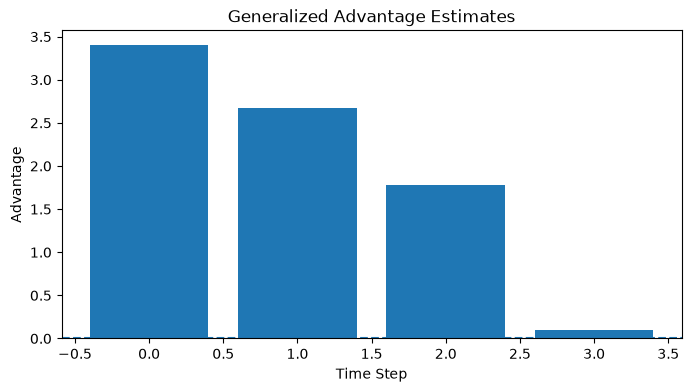

In [81]:
plt.figure(figsize=(8, 4))

plt.bar(
    range(len(advantages)),
    advantages.numpy()
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time Step")
plt.ylabel("Advantage")
plt.title("Generalized Advantage Estimates")
plt.show()

```
Actor
  ↓
Chooses action

Critic
  ↓
Estimates value

TD Error
  ↓
Measures prediction error

Advantage / GAE
  ↓
Provides learning signal

Actor + Critic
  ↓
Improved policy and value estimates

# 2.117 Advantage Actor-Critic (A2C)

**Advantage Actor-Critic (A2C)** is a synchronous Actor-Critic algorithm.

It combines:

* a policy network (**Actor**),
* a value network (**Critic**),
* advantage estimation,
* and temporal-difference learning.

The Actor learns:

$$
\pi_\theta(a|s)
$$

The Critic learns:

$$
V_\phi(s)
$$

The Actor chooses actions, while the Critic evaluates the quality of the states and actions encountered.

---

## A2C Architecture

```text
                    State
                      |
                      v
              +---------------+
              | Shared Network |
              +---------------+
                  /         \
                 /           \
                v             v
           +---------+   +---------+
           |  Actor  |   | Critic  |
           +---------+   +---------+
                |             |
                v             v
         Action probabilities  V(s)
                |
                v
             Action
                |
                v
          Environment
                |
          Reward + Next State
                |
                v
        Advantage Estimation
                |
          +-----+-----+
          |           |
          v           v
       Actor Loss  Critic Loss
```

---

## Actor Objective

The Actor tries to increase the probability of actions with positive advantage and decrease the probability of actions with negative advantage.

The policy-gradient objective can be written as:

$$
L_{\text{actor}}
=
-\mathbb{E}
\left[
\log \pi_\theta(a_t|s_t)
A_t
\right]
$$

where $A_t$ is the estimated advantage.

A common approximation is:

$$
A_t
=
r_t+
\gamma V_\phi(s_{t+1})
-
V_\phi(s_t)
$$

---

## Critic Objective

The Critic predicts the value of the current state.

The one-step target is:

$$
y_t
=
r_t+
\gamma V_\phi(s_{t+1})
$$

The Critic minimizes:

$$
L_{\text{critic}}
=
\left(
V_\phi(s_t)-y_t
\right)^2
$$

---

## Combined Objective

The total training objective can be represented as:

$$
L_{\text{total}}
=
L_{\text{actor}}
+
c_vL_{\text{critic}}
$$

where $c_v$ controls the contribution of the Critic loss.

In practical implementations, an entropy term is often added to encourage exploration:

$$
L_{\text{total}}
=
L_{\text{actor}}
+
c_vL_{\text{critic}}
-
c_eH(\pi)
$$

where $H(\pi)$ is policy entropy.

---

## Why Entropy?

Without sufficient exploration, an Actor may become too confident in a particular action too early.

Policy entropy is:

$$
H(\pi)
=
-\sum_a
\pi(a|s)
\log \pi(a|s)
$$

Higher entropy means the policy is more uncertain and therefore explores more.

The entropy term encourages the policy to avoid becoming prematurely deterministic.

---

## A2C Learning Process

At each interaction:

1. Observe state $s_t$.
2. Actor generates action probabilities.
3. Sample action $a_t$.
4. Execute the action.
5. Receive reward $r_t$.
6. Observe next state $s_{t+1}$.
7. Critic estimates $V(s_t)$ and $V(s_{t+1})$.
8. Compute the TD error.
9. Use the TD error as an advantage estimate.
10. Update Actor and Critic.

The central idea is:

$$
\boxed{
\text{Actor learns from the Critic's advantage estimate}
}
$$


## A2C Loss Calculation

In [82]:
def compute_a2c_losses(
    log_prob,
    entropy,
    reward,
    value,
    next_value,
    gamma=0.99,
    value_coef=0.5,
    entropy_coef=0.01
):
    # TD target
    td_target = reward + gamma * next_value.detach()

    # Advantage
    advantage = td_target - value

    # Actor loss
    actor_loss = -log_prob * advantage.detach()

    # Critic loss
    critic_loss = F.mse_loss(value, td_target)

    # Entropy encourages exploration
    total_loss = (
        actor_loss
        + value_coef * critic_loss
        - entropy_coef * entropy
    )

    return total_loss, actor_loss, critic_loss, advantage

## Run One A2C Update

In [83]:
optimizer = torch.optim.Adam(
    actor_critic.parameters(),
    lr=1e-3
)

state = torch.randn(1, state_dim).to(device)
next_state = torch.randn(1, state_dim).to(device)

reward = torch.tensor([1.0], device=device)

logits, value = actor_critic(state)

probs = F.softmax(logits, dim=-1)

distribution = torch.distributions.Categorical(probs=probs)

action = distribution.sample()

log_prob = distribution.log_prob(action)

entropy = distribution.entropy()

with torch.no_grad():
    _, next_value = actor_critic(next_state)

total_loss, actor_loss, critic_loss, advantage = compute_a2c_losses(
    log_prob=log_prob,
    entropy=entropy,
    reward=reward,
    value=value.squeeze(-1),
    next_value=next_value.squeeze(-1),
    gamma=0.99
)

optimizer.zero_grad()
total_loss.backward()
optimizer.step()

print("Action:", action.item())
print("Advantage:", advantage.item())
print("Actor Loss:", actor_loss.item())
print("Critic Loss:", critic_loss.item())
print("Total Loss:", total_loss.item())

Action: 0
Advantage: 0.5554580688476562
Actor Loss: 0.31429004669189453
Critic Loss: 0.3085336685180664
Total Loss: 0.4617178738117218


# 2.118 A2C vs A3C

Two important Actor-Critic algorithms are:

* **A2C — Advantage Actor-Critic**
* **A3C — Asynchronous Advantage Actor-Critic**

Both use Actor-Critic learning and advantage estimates, but their training organization differs.

## A3C

A3C uses multiple workers that interact with separate copies of the environment.

Conceptually:

```text
                Global Network
                 /    |    \
                /     |     \
               v      v      v
          Worker 1 Worker 2 Worker 3
             |        |        |
             v        v        v
          Env 1     Env 2     Env 3
             |        |        |
             +--------+--------+
                      |
                      v
             Global Parameters
```

The workers explore different trajectories and asynchronously contribute updates.

The key idea is to use multiple environment interactions to improve exploration and reduce correlations between consecutive experiences.

## A2C

A2C can be viewed as a synchronous version of this general idea.

Multiple environments collect experience:

```text
Environment 1 ─┐
Environment 2 ─┤
Environment 3 ─┼──> Batch of trajectories
Environment 4 ─┤
Environment 5 ─┘
                     |
                     v
              Advantage Estimates
                     |
                     v
              Synchronous Update
```

The environments collect data, then the model is updated together.

## Main Difference

| Feature             | A2C               | A3C                      |
| ------------------- | ----------------- | ------------------------ |
| Update style        | Synchronous       | Asynchronous             |
| Multiple workers    | Yes               | Yes                      |
| Gradient updates    | Coordinated       | Independent/asynchronous |
| Implementation      | Generally simpler | More complex             |
| Parallel experience | Yes               | Yes                      |

### Exam point

Remember:

$$
\boxed{
A2C = \text{Synchronous Actor-Critic}
}
$$

$$
\boxed{
A3C = \text{Asynchronous Actor-Critic}
}
$$

Both use an Actor, a Critic, and advantage-based learning.


# 2.119 Actor-Critic Summary

Actor-Critic methods combine policy optimization with value estimation.

### Actor

The Actor represents the policy:

$$
\pi_\theta(a|s)
$$

It determines which actions the agent should take.

### Critic

The Critic estimates:

$$
V_\phi(s)
$$

It evaluates the current state.

### TD Error

The Critic can produce:

$$
\delta_t
=
r_t+
\gamma V(s_{t+1})
-
V(s_t)
$$

### Advantage

The TD error can provide an advantage estimate:

$$
A_t\approx\delta_t
$$

More advanced implementations can use GAE:

$$
\hat A_t
=
\sum_{l=0}^{\infty}
(\gamma\lambda)^l\delta_{t+l}
$$

### Actor Loss

$$
L_{\text{actor}}
=
-\log\pi_\theta(a_t|s_t)A_t
$$

### Critic Loss

$$
L_{\text{critic}}
=
\left(V_\phi(s_t)-y_t\right)^2
$$

### Overall Concept

```text
                 Actor
                   |
                   v
              Select Action
                   |
                   v
              Environment
                   |
             Reward + State
                   |
                   v
                 Critic
                   |
                   v
          Advantage / TD Error
                   |
          +--------+--------+
          |                 |
          v                 v
     Update Actor       Update Critic
```

### Key Advantages

Actor-Critic methods:

* directly learn a policy,
* use value estimation,
* generally have lower variance than basic REINFORCE,
* support efficient multi-step learning,
* provide the foundation for several modern deep RL algorithms.

### Important Algorithms

The Actor-Critic family includes:

* A2C
* A3C
* PPO
* SAC
* DDPG
* TD3

These algorithms differ in how they represent policies, estimate values, handle exploration, and constrain policy updates.

The most important conceptual progression is:

$$
\boxed{
\text{REINFORCE}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{A2C/A3C}
\rightarrow
\text{PPO}
}
$$

For deep reinforcement learning, understanding this progression is more important than memorizing algorithm names.


# 2.120 Proximal Policy Optimization (PPO)

**Proximal Policy Optimization (PPO)** is a policy-gradient reinforcement-learning algorithm based on the Actor-Critic framework.

The central problem PPO addresses is:

> How can we improve the policy without allowing a single update to change the policy too much?

Large policy updates can make reinforcement-learning training unstable.

PPO therefore constrains the policy update so that the new policy remains reasonably close to the old policy.

---

## Why PPO?

Suppose the current policy is:

$$
\pi_{\theta_{\text{old}}}(a|s)
$$

After an update, we obtain:

$$
\pi_\theta(a|s)
$$

If the new policy becomes very different from the old policy, previously useful behavior can suddenly disappear.

Therefore, PPO tries to keep:

$$
\pi_\theta(a|s)
\approx
\pi_{\theta_{\text{old}}}(a|s)
$$

while still improving the policy.

---

## Probability Ratio

PPO introduces the probability ratio:

$$
r_t(\theta)
=
\frac{
\pi_\theta(a_t|s_t)
}{
\pi_{\theta_{\text{old}}}(a_t|s_t)
}
$$

Interpretation:

* $r_t(\theta)=1$: new and old policies assign the same probability.
* $r_t(\theta)>1$: new policy assigns higher probability.
* $r_t(\theta)<1$: new policy assigns lower probability.

For example:

$$
r_t(\theta)=1.2
$$

means the new policy gives the selected action approximately 20% more probability than the old policy.

---

## The PPO Clipped Objective

The key PPO objective is:

$$
L^{CLIP}(\theta)
=
\mathbb{E}_t
\left[
\min
\left(
r_t(\theta)\hat A_t,
\operatorname{clip}
\left(
r_t(\theta),
1-\epsilon,
1+\epsilon
\right)
\hat A_t
\right)
\right]
$$

where:

* $r_t(\theta)$ = policy probability ratio.
* $\hat A_t$ = estimated advantage.
* $\epsilon$ = clipping parameter.

A common value for $\epsilon$ is around:

$$
\epsilon=0.2
$$

---

## What Does Clipping Do?

Suppose:

$$
\epsilon=0.2
$$

Then the ratio is restricted to the interval:

$$
[0.8,1.2]
$$

Conceptually:

```text id="j9h1n0"
        Policy Ratio

   0.8        1.0        1.2
----|----------|----------|----
    |          |          |
 lower       old        upper
 clip       policy       clip
```

The objective prevents the policy update from receiving unlimited benefit from moving too far away from the old policy.

---

## Why the Minimum?

PPO uses:

$$
\min(r_t\hat A_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)\hat A_t)
$$

This creates a conservative objective.

If an update would improve the objective by changing the policy too aggressively, clipping prevents that excessive improvement from being used.

Therefore:

$$
\boxed{
\text{PPO improves the policy while limiting destructive policy updates}
}
$$

---

## Positive Advantage

Suppose:

$$
\hat A_t>0
$$

The selected action was better than expected.

The Actor should increase its probability.

However, PPO prevents this probability from increasing without limit.

With:

$$
\epsilon=0.2
$$

a ratio larger than approximately $1.2$ is clipped.

---

## Negative Advantage

Suppose:

$$
\hat A_t<0
$$

The selected action performed worse than expected.

The Actor should decrease its probability.

PPO prevents this decrease from becoming excessively large.

The lower clipping boundary is:

$$
1-\epsilon
$$

For $\epsilon=0.2$:

$$
1-\epsilon=0.8
$$

---

## PPO Architecture

PPO commonly uses an Actor-Critic architecture:

```text id="l8g8y4"
                    State
                      |
                      v
               Shared / Separate
                Neural Networks
                  /       \
                 /         \
                v           v
             Actor        Critic
                |            |
                v            v
          Action Policy     V(s)
                |
                v
           Environment
                |
          Reward + State
                |
                v
         Advantage / GAE
                |
                v
        PPO Clipped Update
```

The Critic provides value estimates and advantage estimates.

The Actor is updated using the PPO objective.

---

## PPO Loss Components

A practical PPO implementation usually contains several components.

### Actor / Policy Loss

$$
L_{\text{policy}}
=
-
\mathbb{E}
\left[
\min
\left(
r_t\hat A_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)
\hat A_t
\right)
\right]
$$

The negative sign appears because deep-learning frameworks normally minimize losses.

### Critic Loss

The Critic learns the value function:

$$
L_{\text{value}}
=
\mathbb{E}
\left[
(V_\phi(s_t)-V_t^{target})^2
\right]
$$

### Entropy Bonus

PPO can also include an entropy term:

$$
L_{\text{entropy}}
=
-\mathbb{E}[H(\pi)]
$$

Entropy encourages exploration.

### Total Loss

A simplified implementation is:

$$
L_{\text{total}}
=
L_{\text{policy}}
+
c_vL_{\text{value}}
+
c_eL_{\text{entropy}}
$$

where the coefficients control the contribution of each component.

---

## PPO Training Pipeline

```text id="6p4w7q"
1. Run current policy
       |
       v
2. Collect trajectories
       |
       v
3. Compute rewards
       |
       v
4. Estimate values
       |
       v
5. Compute advantages / GAE
       |
       v
6. Store old log probabilities
       |
       v
7. Optimize PPO objective
       |
       v
8. Repeat for multiple epochs
       |
       v
9. Collect new trajectories
```

The important idea is that PPO reuses collected trajectories for several optimization epochs while controlling how far the policy moves.


## PPO Clipped Objective

In [84]:
def ppo_clipped_objective(
    new_log_probs,
    old_log_probs,
    advantages,
    clip_epsilon=0.2
):
    # Convert log-probability difference
    # into probability ratio
    ratios = torch.exp(
        new_log_probs - old_log_probs
    )

    # Unclipped objective
    objective_1 = ratios * advantages

    # Clipped ratio
    clipped_ratios = torch.clamp(
        ratios,
        1.0 - clip_epsilon,
        1.0 + clip_epsilon
    )

    # Clipped objective
    objective_2 = clipped_ratios * advantages

    # PPO maximizes the objective,
    # so we minimize its negative
    policy_loss = -torch.min(
        objective_1,
        objective_2
    ).mean()

    return policy_loss, ratios

## Simple PPO Example

In [85]:
old_log_probs = torch.tensor(
    [-0.70, -0.80, -0.50, -1.00],
    device=device
)

new_log_probs = torch.tensor(
    [-0.55, -0.90, -0.45, -1.30],
    device=device
)

advantages = torch.tensor(
    [1.0, -1.0, 0.5, -0.8],
    device=device
)

policy_loss, ratios = ppo_clipped_objective(
    new_log_probs,
    old_log_probs,
    advantages,
    clip_epsilon=0.2
)

print("Probability ratios:")
print(ratios)

print("\nPPO policy loss:")
print(policy_loss.item())

Probability ratios:
tensor([1.1618, 0.9048, 1.0513, 0.7408], device='cuda:0')

PPO policy loss:
-0.035658061504364014


## Visualize PPO Clipping

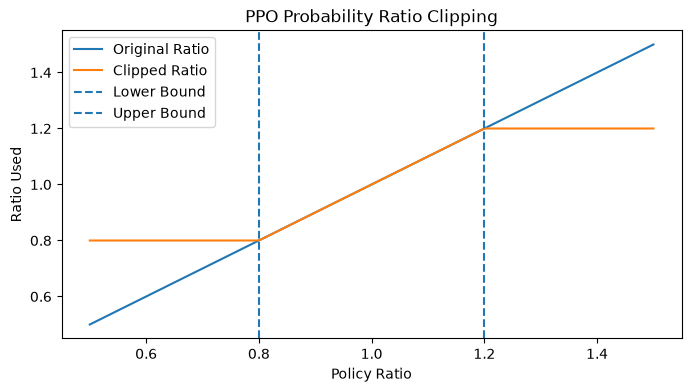

In [86]:
ratios = torch.linspace(
    0.5,
    1.5,
    200,
    device=device
).cpu()

epsilon = 0.2

clipped_ratios = torch.clamp(
    ratios,
    1 - epsilon,
    1 + epsilon
)

plt.figure(figsize=(8, 4))

plt.plot(
    ratios.numpy(),
    ratios.numpy(),
    label="Original Ratio"
)

plt.plot(
    ratios.numpy(),
    clipped_ratios.numpy(),
    label="Clipped Ratio"
)

plt.axvline(
    1 - epsilon,
    linestyle="--",
    label="Lower Bound"
)

plt.axvline(
    1 + epsilon,
    linestyle="--",
    label="Upper Bound"
)

plt.xlabel("Policy Ratio")
plt.ylabel("Ratio Used")
plt.title("PPO Probability Ratio Clipping")
plt.legend()
plt.show()

# 2.121 PPO vs REINFORCE and Actor-Critic

PPO builds upon ideas introduced earlier in deep reinforcement learning.

| Feature              | REINFORCE            | Actor-Critic                 | PPO            |
| -------------------- | -------------------- | ---------------------------- | -------------- |
| Policy-based         | Yes                  | Yes                          | Yes            |
| Critic               | No                   | Yes                          | Yes            |
| Advantage            | Usually return-based | Yes                          | Yes            |
| TD learning          | No                   | Yes                          | Yes            |
| Policy constraint    | No                   | Usually no explicit clipping | Yes            |
| Policy stability     | Lower                | Better                       | Strong         |
| Modern practical use | Limited              | Important foundation         | Very important |

The conceptual progression is:

$$
\boxed{
\text{REINFORCE}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{Advantage Estimation}
\rightarrow
\text{PPO}
}
$$

### Why PPO is so important

PPO is important because it combines several useful ideas:

* policy gradients,
* Actor-Critic learning,
* advantage estimation,
* entropy-based exploration,
* multiple optimization epochs,
* and conservative policy updates.

Its central principle can be remembered as:

$$
\boxed{
\text{Improve the policy, but don't change it too much at once.}
}
$$

### Exam definition

**Proximal Policy Optimization (PPO)** is a policy-gradient Actor-Critic algorithm that constrains policy updates using a clipped probability-ratio objective, improving training stability while allowing efficient policy optimization.

### Key formula

The formula to remember for an exam is:

$$
L^{CLIP}(\theta)
=
\mathbb{E}_t
\left[
\min
\left(
r_t(\theta)\hat A_t,
\operatorname{clip}
\left(
r_t(\theta),
1-\epsilon,
1+\epsilon
\right)
\hat A_t
\right)
\right]
$$

with:

$$
r_t(\theta)
=
\frac{
\pi_\theta(a_t|s_t)
}{
\pi_{\theta_{\text{old}}}(a_t|s_t)
}
$$

PPO therefore prevents excessively large policy updates while still allowing the policy to improve.


# 2.122 PPO Training with a Real Environment

## CartPole Environment

CartPole is a classic reinforcement-learning environment.

The agent controls a cart that can move:

* left,
* right.

The objective is to keep the pole upright for as long as possible.

```text id="5d5m9n"
                 Pole
                  |
                  |
                  |
                  |
             ____|____
            |         |
            |   Cart  |
            |_________|
        <----------------->
             Track
```

At every time step, the agent:

1. observes the state,
2. selects an action,
3. receives a reward,
4. observes the next state.

---

## CartPole State

The environment provides four state variables:

$$
s =
[
x,\dot{x},\theta,\dot{\theta}
]
$$

where:

* $x$ = cart position,
* $\dot{x}$ = cart velocity,
* $\theta$ = pole angle,
* $\dot{\theta}$ = pole angular velocity.

Therefore:

$$
\text{state dimension}=4
$$

There are two discrete actions:

$$
a\in\{0,1\}
$$

corresponding to movement in the two available directions.

---

## PPO Agent

Our PPO agent contains two outputs:

### Actor

The Actor produces action logits:

$$
z=f_\theta(s)
$$

These logits are converted into probabilities:

$$
\pi_\theta(a|s)
=
\operatorname{softmax}(z)
$$

### Critic

The Critic estimates:

$$
V_\phi(s)
$$

The complete network therefore produces:

$$
(\text{policy logits},V(s))
$$

---

## PPO Training

For each trajectory we collect:

* states,
* actions,
* rewards,
* old log probabilities,
* value estimates.

We then compute:

1. returns,
2. advantages,
3. PPO policy loss,
4. value loss,
5. entropy bonus.

The model is updated using these losses.

---

## Important Practical Point

A complete PPO implementation is substantially more complicated than the earlier one-step demonstration.

A real implementation must correctly handle:

* episode termination,
* bootstrapping,
* advantage estimation,
* batching,
* old policy probabilities,
* multiple optimization epochs,
* policy clipping,
* value-function training,
* entropy regularization.

This is exactly where the mathematical concepts from the previous sections become useful.


## Imports

In [87]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## Create Environment

In [88]:
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("State dimension:", state_dim)
print("Action dimension:", action_dim)
print("State space:", env.observation_space)
print("Action space:", env.action_space)

State dimension: 4
Action dimension: 2
State space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## PPO Actor-Critic Network

In [89]:
class PPOActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )

        self.actor = nn.Linear(hidden_dim, action_dim)
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        features = self.shared(state)

        logits = self.actor(features)
        value = self.critic(features)

        return logits, value

## Initialize PPO Agent

In [90]:
ppo_agent = PPOActorCritic(
    state_dim=state_dim,
    action_dim=action_dim
).to(device)

optimizer = torch.optim.Adam(
    ppo_agent.parameters(),
    lr=3e-4
)

print(ppo_agent)

PPOActorCritic(
  (shared): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
  )
  (actor): Linear(in_features=64, out_features=2, bias=True)
  (critic): Linear(in_features=64, out_features=1, bias=True)
)


## Action Selection

In [91]:
def select_action(model, state):
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    logits, value = model(state_tensor)

    distribution = torch.distributions.Categorical(
        logits=logits
    )

    action = distribution.sample()

    log_prob = distribution.log_prob(action)
    entropy = distribution.entropy()

    return (
        action.item(),
        log_prob.squeeze(0),
        value.squeeze(0).squeeze(-1),
        entropy.squeeze(0)
    )

## Test Action Selection

In [92]:
state, info = env.reset(seed=42)

action, log_prob, value, entropy = select_action(
    ppo_agent,
    state
)

print("State:", state)
print("Action:", action)
print("Log probability:", log_prob.item())
print("Value estimate:", value.item())
print("Entropy:", entropy.item())

State: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Action: 1
Log probability: -0.6615258455276489
Value estimate: -0.02522221952676773
Entropy: 0.6926311254501343


# 2.123 Collecting PPO Rollouts

PPO learns from trajectories collected by the current policy.

A trajectory looks like:

$$
s_0
\rightarrow
a_0
\rightarrow
r_0
\rightarrow
s_1
\rightarrow
a_1
\rightarrow
r_1
\rightarrow
\cdots
$$

For every transition we store:

* state,
* action,
* reward,
* log probability under the old policy,
* estimated value.

The old log probability is important because PPO compares the new policy with the policy that generated the data.

The ratio is:

$$
r_t(\theta)
=
\exp
\left(
\log\pi_\theta(a_t|s_t)
-
\log\pi_{\theta_{\text{old}}}(a_t|s_t)
\right)
$$

This is numerically convenient because we work with log probabilities rather than directly multiplying probabilities.

---

## Rollout Buffer

```text id="2m3q9r"
State
  |
Action
  |
Reward
  |
Old Log Probability
  |
Value
  |
  v
Rollout Buffer
  |
  v
Advantages + Returns
  |
  v
PPO Optimization
```

The rollout buffer contains the information required to perform the PPO update.


## Collect One Rollout

In [93]:
def collect_rollout(model, env, rollout_steps=1024):
    states = []
    actions = []
    rewards = []
    log_probs = []
    values = []
    dones = []

    state, _ = env.reset()

    for _ in range(rollout_steps):
        action, log_prob, value, _ = select_action(
            model,
            state
        )

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob.item())
        values.append(value.item())
        dones.append(done)

        state = next_state

        if done:
            state, _ = env.reset()

    return {
        "states": np.array(states, dtype=np.float32),
        "actions": np.array(actions, dtype=np.int64),
        "rewards": np.array(rewards, dtype=np.float32),
        "log_probs": np.array(log_probs, dtype=np.float32),
        "values": np.array(values, dtype=np.float32),
        "dones": np.array(dones, dtype=np.float32)
    }

## Collect Data

In [94]:
rollout = collect_rollout(
    ppo_agent,
    env,
    rollout_steps=512
)

for key, value in rollout.items():
    print(f"{key}: shape={value.shape}")

states: shape=(512, 4)
actions: shape=(512,)
rewards: shape=(512,)
log_probs: shape=(512,)
values: shape=(512,)
dones: shape=(512,)


# 2.124 PPO Returns and Advantages

After collecting a rollout, PPO needs an estimate of:

* the return,
* the advantage.

The advantage tells the Actor whether an action performed better or worse than expected.

We use GAE:

$$
\hat A_t
=
\delta_t
+
\gamma\lambda\delta_{t+1}
+
(\gamma\lambda)^2\delta_{t+2}
+\cdots
$$

where:

$$
\delta_t
=
r_t+
\gamma V(s_{t+1})
-
V(s_t)
$$

The estimated return can then be obtained from:

$$
\hat R_t
=
\hat A_t+V(s_t)
$$

Before optimization, advantages are commonly normalized:

$$
\hat A_t
\leftarrow
\frac{
\hat A_t-\mu_A
}{
\sigma_A+\epsilon
}
$$

Normalization can make optimization more stable.


## GAE for PPO

In [95]:
def compute_gae_and_returns(
    rewards,
    values,
    dones,
    last_value,
    gamma=0.99,
    lam=0.95
):
    advantages = np.zeros_like(rewards)

    gae = 0.0

    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_value = last_value
        else:
            next_value = values[t + 1]

        non_terminal = 1.0 - dones[t]

        delta = (
            rewards[t]
            + gamma * next_value * non_terminal
            - values[t]
        )

        gae = (
            delta
            + gamma * lam * non_terminal * gae
        )

        advantages[t] = gae

    returns = advantages + values

    return advantages, returns

# 2.125 PPO Optimization Step

The PPO optimization step uses the collected rollout.

First, we recompute the policy probabilities using the current network.

Then:

$$
r_t(\theta)
=
\frac{
\pi_\theta(a_t|s_t)
}{
\pi_{\theta_{\text{old}}}(a_t|s_t)
}
$$

The clipped objective is:

$$
L^{CLIP}
=
\mathbb{E}
\left[
\min
\left(
r_t\hat A_t,
\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)\hat A_t
\right)
\right]
$$

The Critic is trained using the target returns.

The total loss also includes an entropy term to encourage exploration.

This gives the complete PPO update mechanism.


## PPO Update

In [96]:
def ppo_update(
    model,
    optimizer,
    rollout,
    advantages,
    returns,
    clip_epsilon=0.2,
    value_coef=0.5,
    entropy_coef=0.01,
    epochs=4
):
    states = torch.tensor(
        rollout["states"],
        dtype=torch.float32,
        device=device
    )

    actions = torch.tensor(
        rollout["actions"],
        dtype=torch.long,
        device=device
    )

    old_log_probs = torch.tensor(
        rollout["log_probs"],
        dtype=torch.float32,
        device=device
    )

    advantages = torch.tensor(
        advantages,
        dtype=torch.float32,
        device=device
    )

    returns = torch.tensor(
        returns,
        dtype=torch.float32,
        device=device
    )

    # Normalize advantages
    advantages = (
        advantages - advantages.mean()
    ) / (advantages.std() + 1e-8)

    for _ in range(epochs):

        logits, values = model(states)

        distribution = torch.distributions.Categorical(
            logits=logits
        )

        new_log_probs = distribution.log_prob(actions)

        entropy = distribution.entropy().mean()

        values = values.squeeze(-1)

        ratios = torch.exp(
            new_log_probs - old_log_probs
        )

        unclipped = (
            ratios * advantages
        )

        clipped = (
            torch.clamp(
                ratios,
                1.0 - clip_epsilon,
                1.0 + clip_epsilon
            )
            * advantages
        )

        policy_loss = -torch.min(
            unclipped,
            clipped
        ).mean()

        value_loss = F.mse_loss(
            values,
            returns
        )

        total_loss = (
            policy_loss
            + value_coef * value_loss
            - entropy_coef * entropy
        )

        optimizer.zero_grad()
        total_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=0.5
        )

        optimizer.step()

    return (
        policy_loss.item(),
        value_loss.item(),
        entropy.item()
    )

# 2.126 Complete PPO Training Loop

The complete PPO training cycle is:

```text id="5d8x3v"
          Current Policy
                |
                v
         Collect Rollout
                |
                v
       Compute GAE / Returns
                |
                v
       Normalize Advantages
                |
                v
        PPO Optimization
                |
                v
        Updated Policy
                |
                +----------+
                           |
                           v
                    Collect New Data
```

We repeat this process for many iterations.

The objective is to increase the average episode reward.

Because reinforcement learning can be noisy, the reward curve may fluctuate considerably rather than improving smoothly.


## Training

In [97]:
num_iterations = 100
rollout_steps = 512

reward_history = []

for iteration in range(num_iterations):

    rollout = collect_rollout(
        ppo_agent,
        env,
        rollout_steps=rollout_steps
    )

    # Bootstrap from the final state
    last_state = rollout["states"][-1]

    last_state_tensor = torch.tensor(
        last_state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        _, last_value = ppo_agent(last_state_tensor)

    last_value = last_value.item()

    advantages, returns = compute_gae_and_returns(
        rollout["rewards"],
        rollout["values"],
        rollout["dones"],
        last_value,
        gamma=0.99,
        lam=0.95
    )

    policy_loss, value_loss, entropy = ppo_update(
        ppo_agent,
        optimizer,
        rollout,
        advantages,
        returns
    )

    average_reward = rollout["rewards"].sum()

    reward_history.append(
        average_reward
    )

    if (iteration + 1) % 10 == 0:
        print(
            f"Iteration {iteration + 1:3d} | "
            f"Reward: {average_reward:7.2f} | "
            f"Policy Loss: {policy_loss:8.4f} | "
            f"Value Loss: {value_loss:8.4f}"
        )

Iteration  10 | Reward:  512.00 | Policy Loss:  -0.0004 | Value Loss:  77.7694
Iteration  20 | Reward:  512.00 | Policy Loss:  -0.0000 | Value Loss:  96.6845
Iteration  30 | Reward:  512.00 | Policy Loss:   0.0004 | Value Loss:  69.6784
Iteration  40 | Reward:  512.00 | Policy Loss:  -0.0001 | Value Loss:  51.0117
Iteration  50 | Reward:  512.00 | Policy Loss:   0.0010 | Value Loss:  64.2828
Iteration  60 | Reward:  512.00 | Policy Loss:   0.0001 | Value Loss:  55.7439
Iteration  70 | Reward:  512.00 | Policy Loss:  -0.0001 | Value Loss:  54.9502
Iteration  80 | Reward:  512.00 | Policy Loss:   0.0005 | Value Loss:  36.4878
Iteration  90 | Reward:  512.00 | Policy Loss:  -0.0003 | Value Loss:  50.4264
Iteration 100 | Reward:  512.00 | Policy Loss:   0.0007 | Value Loss:  58.1808


## Training Curve

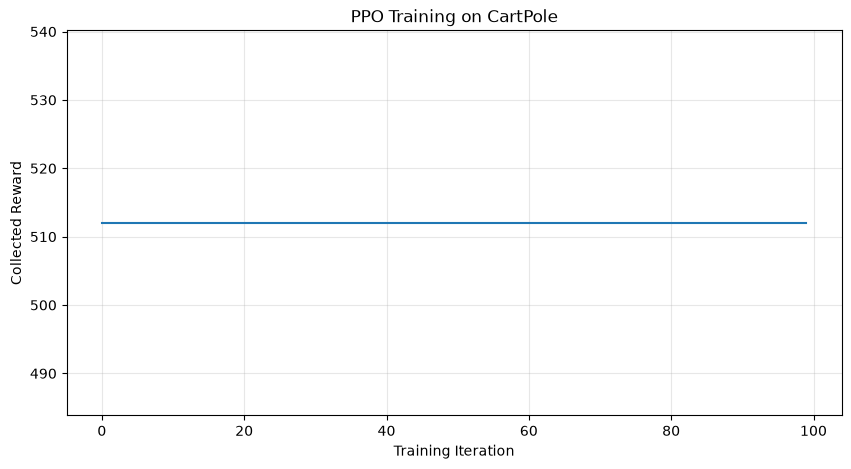

In [98]:
plt.figure(figsize=(10, 5))

plt.plot(reward_history)

plt.xlabel("Training Iteration")
plt.ylabel("Collected Reward")
plt.title("PPO Training on CartPole")

plt.grid(True, alpha=0.3)
plt.show()

The exact reward curve can vary between runs because reinforcement learning is stochastic. The important thing is to observe whether the agent's performance generally improves.

# 2.127 Evaluating the Trained PPO Agent

Training performance and evaluation performance should be separated.

During training, the PPO agent samples actions from its policy:

$$
a_t\sim\pi_\theta(a|s_t)
$$

This introduces exploration.

During evaluation, we can select the action with the highest probability:

$$
a_t
=
\arg\max_a \pi_\theta(a|s_t)
$$

This gives us a more deterministic evaluation.

---

## Evaluation Procedure

For each evaluation episode:

1. Reset the environment.
2. Observe the state.
3. Pass the state through the trained Actor.
4. Compute action probabilities.
5. Select the most probable action.
6. Execute the action.
7. Continue until the episode terminates.
8. Record the total reward.

The episode return is:

$$
G_0
=
\sum_{t=0}^{T-1}
\gamma^t r_t
$$

For CartPole, the raw episode reward is also useful because it directly measures how many time steps the pole remained balanced.

---

## Why Evaluate Multiple Episodes?

A single episode is not enough to judge a reinforcement-learning agent.

Because the environment and policy can be stochastic, performance may vary.

Therefore, evaluate over several episodes and calculate:

$$
\text{Mean Reward}
=
\frac{1}{N}
\sum_{i=1}^{N}R_i
$$

We can also calculate the standard deviation:

$$
\sigma_R
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
(R_i-\bar R)^2
}
$$

A good evaluation should therefore report both average performance and variability.


## Deterministic Evaluation

In [99]:
def evaluate_ppo(
    model,
    env_name="CartPole-v1",
    num_episodes=10
):
    eval_env = gym.make(env_name)

    episode_rewards = []

    model.eval()

    for episode in range(num_episodes):

        state, _ = eval_env.reset()
        done = False
        total_reward = 0

        while not done:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            with torch.no_grad():
                logits, _ = model(state_tensor)

            action = torch.argmax(
                logits,
                dim=-1
            ).item()

            state, reward, terminated, truncated, _ = (
                eval_env.step(action)
            )

            done = terminated or truncated

            total_reward += reward

        episode_rewards.append(total_reward)

    eval_env.close()
    model.train()

    return episode_rewards

## Evaluate

In [100]:
evaluation_rewards = evaluate_ppo(
    ppo_agent,
    num_episodes=10
)

print("Episode rewards:")
print(evaluation_rewards)

print("\nMean reward:",
      np.mean(evaluation_rewards))

print("Standard deviation:",
      np.std(evaluation_rewards))

Episode rewards:
[10.0, 12.0, 12.0, 10.0, 11.0, 11.0, 11.0, 10.0, 10.0, 9.0]

Mean reward: 10.6
Standard deviation: 0.9165151389911681


## Visualize Evaluation Performance

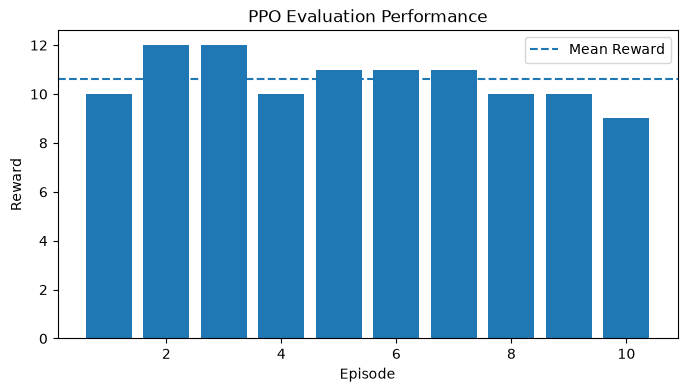

In [101]:
plt.figure(figsize=(8, 4))

plt.bar(
    range(1, len(evaluation_rewards) + 1),
    evaluation_rewards
)

plt.axhline(
    np.mean(evaluation_rewards),
    linestyle="--",
    label="Mean Reward"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("PPO Evaluation Performance")
plt.legend()
plt.show()

# 2.128 PPO Hyperparameters

PPO performance depends strongly on its hyperparameters.

Important parameters include:

| Hyperparameter      | Meaning                                  |
| ------------------- | ---------------------------------------- |
| Learning rate       | Controls neural-network update size      |
| $\gamma$            | Discount factor                          |
| $\lambda$           | GAE parameter                            |
| $\epsilon$          | PPO clipping range                       |
| Batch size          | Number of samples per optimization batch |
| Epochs              | Number of optimization passes            |
| Entropy coefficient | Controls exploration                     |
| Value coefficient   | Controls Critic contribution             |

### Learning Rate

The learning rate controls the magnitude of parameter updates.

A very large learning rate can make training unstable.

A very small learning rate can make learning extremely slow.

---

### Discount Factor

The discount factor determines the importance of future rewards:

$$
G_t
=
r_t+
\gamma r_{t+1}
+
\gamma^2r_{t+2}
+\cdots
$$

A value close to $1$ gives greater importance to future rewards.

---

### GAE Parameter

The GAE parameter $\lambda$ controls the trade-off between bias and variance in advantage estimation.

$$
\hat A_t^{GAE}
=
\sum_{l=0}^{\infty}
(\gamma\lambda)^l\delta_{t+l}
$$

---

### PPO Clip Range

The clipping parameter controls how far the new policy can move relative to the old policy.

$$
1-\epsilon
\leq
r_t
\leq
1+\epsilon
$$

A commonly used starting point is:

$$
\epsilon=0.2
$$

---

### Entropy Coefficient

The entropy coefficient determines how strongly exploration is encouraged.

Higher entropy contribution:

$$
\Rightarrow
\text{more exploration}
$$

Lower entropy contribution:

$$
\Rightarrow
\text{more exploitation}
$$

---

## Important Practical Principle

Do not treat hyperparameters as independent knobs.

Changing one parameter can affect the behavior of the entire learning system.

For example:

$$
\lambda
\rightarrow
\text{Advantage Estimates}
\rightarrow
\text{Actor Updates}
\rightarrow
\text{Policy}
\rightarrow
\text{Collected Data}
$$

Therefore, PPO tuning should be performed systematically rather than by randomly changing values.


# 2.129 PPO Advantages and Limitations

## Advantages of PPO

### 1. Stable Policy Updates

The clipping mechanism limits excessively large policy changes.

### 2. Efficient Data Usage

Collected trajectories can be reused for multiple optimization epochs.

### 3. Actor-Critic Structure

PPO combines:

$$
\text{Policy Learning}
+
\text{Value Learning}
$$

### 4. Advantage Estimation

PPO commonly uses GAE to obtain useful advantage estimates.

### 5. Simple Conceptual Structure

Although a complete implementation contains many details, the central PPO idea is relatively easy to understand:

$$
\boxed{
\text{Improve the policy without changing it too aggressively}
}
$$

---

## Limitations

PPO is not perfect.

### 1. On-Policy Learning

PPO generally learns from data generated by the current policy.

Old experience cannot be reused indefinitely like an off-policy algorithm such as DQN.

### 2. Computational Cost

Repeatedly collecting trajectories and optimizing neural networks can require substantial computation.

### 3. Hyperparameter Sensitivity

Performance can depend on:

* learning rate,
* clipping parameter,
* GAE parameters,
* rollout length,
* batch size,
* optimization epochs,
* entropy coefficient.

### 4. Reward Design

PPO cannot solve a poorly designed reward function automatically.

If the reward does not represent the desired behavior, the agent may learn undesirable strategies.

---

## PPO in the Deep RL Landscape

```text id="v4a2jp"
                    Deep RL
                      |
          +-----------+-----------+
          |                       |
      Value-Based              Policy-Based
          |                       |
         DQN                 REINFORCE
                                  |
                            Actor-Critic
                                  |
                       +----------+----------+
                       |                     |
                      A2C                  PPO
```

PPO is therefore not an isolated algorithm.

It builds on several concepts already studied:

$$
\boxed{
\text{Policy Gradient}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{Advantage}
\rightarrow
\text{GAE}
\rightarrow
\text{PPO}
}
$$


# 2.130 Deep Reinforcement Learning — Final Comparison

We have now covered the major foundations of Deep Reinforcement Learning.

| Method       | Main Idea                        | Neural Output |          |
| ------------ | -------------------------------- | ------------- | -------- |
| DQN          | Learn action values              | $Q(s,a)$      |          |
| REINFORCE    | Direct policy optimization       | $\pi(a        | s)$      |
| Actor-Critic | Policy + value estimation        | $\pi(a        | s),V(s)$ |
| A2C          | Synchronous Actor-Critic         | $\pi(a        | s),V(s)$ |
| A3C          | Asynchronous Actor-Critic        | $\pi(a        | s),V(s)$ |
| PPO          | Conservative policy optimization | $\pi(a        | s),V(s)$ |

### Value-Based Learning

DQN learns:

$$
Q(s,a)
$$

and chooses:

$$
a^*
=
\arg\max_a Q(s,a)
$$

### Policy-Based Learning

REINFORCE directly learns:

$$
\pi_\theta(a|s)
$$

and updates the policy using returns.

### Actor-Critic

Actor-Critic combines:

$$
\pi_\theta(a|s)
$$

with:

$$
V_\phi(s)
$$

The Critic provides an advantage-like learning signal.

### PPO

PPO adds a constraint on policy updates using:

$$
r_t(\theta)
=
\frac{
\pi_\theta(a_t|s_t)
}{
\pi_{\theta_{\text{old}}}(a_t|s_t)
}
$$

and the clipped objective:

$$
L^{CLIP}
=
\mathbb{E}
\left[
\min
\left(
r_t\hat A_t,
\operatorname{clip}
(r_t,1-\epsilon,1+\epsilon)
\hat A_t
\right)
\right]
$$

---

## What You Should Be Able to Explain in an Exam

You should be able to explain:

1. Agent and environment.
2. State, action, reward, and policy.
3. Markov Decision Process.
4. Return and discount factor.
5. Value function.
6. Action-value function.
7. Bellman equation.
8. DQN.
9. Experience replay.
10. Target networks.
11. Exploration vs exploitation.
12. Policy gradients.
13. REINFORCE.
14. Actor-Critic.
15. Advantage function.
16. TD error.
17. GAE.
18. A2C.
19. A3C.
20. PPO.
21. PPO probability ratio.
22. PPO clipping.
23. Entropy-based exploration.
24. Advantages and limitations of PPO.

### Most Important Conceptual Chain

$$
\boxed{
\text{RL}
\rightarrow
\text{Value-Based}
\rightarrow
\text{Policy-Based}
\rightarrow
\text{Actor-Critic}
\rightarrow
\text{Advantage}
\rightarrow
\text{GAE}
\rightarrow
\text{PPO}
}
$$

This progression is important because each method addresses limitations of earlier approaches.

---

## Final Deep RL Mental Model

```text id="x8t1qe"
                    Environment
                         |
                         v
                       State
                         |
              +----------+----------+
              |                     |
              v                     v
            Actor                 Critic
              |                     |
              v                     v
           Action                Value V(s)
              |
              v
         Environment
              |
              v
           Reward
              |
              v
       TD Error / Advantage
              |
        +-----+-----+
        |           |
        v           v
      Actor       Critic
      Update      Update
        |
        v
       PPO
        |
        v
   Stable Policy
```

### Final exam statement

**Deep Reinforcement Learning uses neural networks to learn policies, value functions, or both from interaction with an environment. DQN represents the value-based approach, while REINFORCE represents policy-gradient learning. Actor-Critic methods combine policy and value estimation, and PPO improves policy optimization by restricting excessively large policy updates through a clipped objective.**

With this, the **core Deep Reinforcement Learning portion is complete**.






# 3.1 Generative Deep Learning

**Generative Deep Learning** is the area of deep learning concerned with learning the underlying structure of data so that a model can generate new samples that resemble the training data.

Traditional predictive models usually answer questions such as:

> "Which class does this input belong to?"

Generative models instead learn to answer:

> "What could a new sample from this data distribution look like?"

---

## Generative vs Discriminative Learning

Suppose we have images of cats and dogs.

A discriminative model learns a relationship such as:

$$
P(y|x)
$$

where:

* $x$ = image,
* $y$ = class label.

It attempts to distinguish between classes.

A generative model attempts to learn the data distribution itself:

$$
P(x)
$$

or, depending on the model, the joint distribution:

$$
P(x,y)
$$

The distinction can be summarized as:

$$
\boxed{
\text{Discriminative Model}
\rightarrow
\text{Predict}
}
$$

$$
\boxed{
\text{Generative Model}
\rightarrow
\text{Generate}
}
$$

---

## What Does "Generate" Mean?

A trained generative model should be able to produce a new sample:

$$
x_{\text{new}}
$$

that is similar to samples from the training distribution.

For example:

```text
Training Images
      |
      v
+-------------+
| Generative  |
|    Model    |
+-------------+
      |
      v
New Generated Image
```

The generated image does not need to be an exact copy of a training example.

The goal is to learn the underlying structure of the data and generate plausible new samples.

---

## Learning a Data Distribution

Suppose the training data comes from an unknown distribution:

$$
p_{\text{data}}(x)
$$

A generative model attempts to learn a model distribution:

$$
p_\theta(x)
$$

The goal is for:

$$
p_\theta(x)
\approx
p_{\text{data}}(x)
$$

Once the model has learned this distribution, we can sample from it:

$$
x\sim p_\theta(x)
$$

This produces new synthetic data.

---

## Example

Suppose the training dataset contains handwritten digits.

```text
Training Data

  0   1   2   3
  4   5   6   7
  8   9
```

A generative model learns patterns such as:

* strokes,
* curves,
* shapes,
* spatial relationships,
* writing styles.

After training, it can generate a new digit:

```text
Training Distribution
          |
          v
   Generative Model
          |
          v
   Newly Generated
       Digit
```

The generated digit may not exist in the original dataset.

---

## Major Families of Generative Deep Learning

Several important approaches have been developed.

### 1. Autoencoder-Based Models

Autoencoders learn an encoding and decoding process:

$$
x
\rightarrow
z
\rightarrow
\hat{x}
$$

Variational Autoencoders extend this idea into a probabilistic generative model.

$$
\boxed{\text{VAE}}
$$

---

### 2. Generative Adversarial Networks

GANs use two neural networks:

* Generator
* Discriminator

The Generator creates synthetic samples while the Discriminator attempts to distinguish real samples from generated samples.

$$
\boxed{\text{GAN}}
$$

---

### 3. Autoregressive Models

Autoregressive models generate data sequentially.

For a sequence:

$$
x_1,x_2,\ldots,x_T
$$

the joint probability can be decomposed as:

$$
p(x_1,\ldots,x_T)
=
\prod_{t=1}^{T}
p(x_t|x_1,\ldots,x_{t-1})
$$

This idea is fundamental to many sequence-generation systems.

---

### 4. Diffusion Models

Diffusion models learn to generate data by reversing a gradual noising process.

Conceptually:

```text
Clean Data
    |
    v
Add Noise
    |
    v
More Noise
    |
    v
Pure Noise
```

The generative model learns the reverse process:

```text
Pure Noise
    |
    v
Remove Noise
    |
    v
Less Noise
    |
    v
Generated Data
```

Diffusion models have become an important family of modern generative models.

---

## Generative Modeling Perspective

A useful way to organize the major approaches is:

```text
             Generative Deep Learning
                       |
       +---------------+---------------+
       |               |               |
       v               v               v
      VAE             GAN       Autoregressive
       |               |               |
       v               v               v
 Latent-variable   Adversarial       Sequential
    modeling         learning        generation
                       |
                       |
                       v
                 Diffusion Models
```

These approaches use different mathematical mechanisms, but they share the same broad objective:

$$
\boxed{
\text{Learn the structure of data and generate new samples}
}
$$

---

## Generative Models and Latent Variables

Many generative models introduce a latent variable:

$$
z
$$

The latent variable represents a compact hidden representation from which data can be generated.

A common generative process is:

$$
z
\rightarrow
G_\theta(z)
\rightarrow
x
$$

where:

* $z$ = latent representation,
* $G_\theta$ = neural network generator,
* $x$ = generated sample.

For example:

```text
Random Latent Vector
          |
          v
     Neural Network
          |
          v
    Generated Image
```

This is a fundamental idea behind many generative architectures.

---

## Why Generative Deep Learning Matters

Generative models have applications in:

* image generation,
* text generation,
* audio generation,
* video generation,
* data augmentation,
* image reconstruction,
* representation learning,
* synthetic-data generation,
* scientific modeling,
* creative applications.

The important conceptual shift is:

$$
\boxed{
\text{Predicting existing data}
\rightarrow
\text{Modeling data distributions}
\rightarrow
\text{Generating new data}
}
$$

---

## Exam Definition

**Generative Deep Learning** is a branch of deep learning that learns the underlying distribution or structure of data and uses the learned model to generate new samples that resemble the original data distribution.

### Key terms

Remember these:

$$
p_{\text{data}}(x)
$$

= real data distribution.

$$
p_\theta(x)
$$

= learned model distribution.

$$
z
$$

= latent variable.

$$
x_{\text{generated}}
$$

= generated sample.

The central objective is:

$$
p_\theta(x)
\approx
p_{\text{data}}(x)
$$


## Simple Generative Example

In [102]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated training distribution
np.random.seed(42)

training_data = np.random.normal(
    loc=2.0,
    scale=1.0,
    size=1000
)

# Estimate simple distribution parameters
mean = training_data.mean()
std = training_data.std()

# Generate new samples
generated_data = np.random.normal(
    loc=mean,
    scale=std,
    size=1000
)

print("Training mean:", mean)
print("Training std:", std)
print("Generated mean:", generated_data.mean())
print("Generated std:", generated_data.std())

Training mean: 2.0193320558223253
Training std: 0.9787262077473542
Generated mean: 2.0886613376762835
Generated std: 0.9757465005643848


## Visualize Real vs Generated Distribution

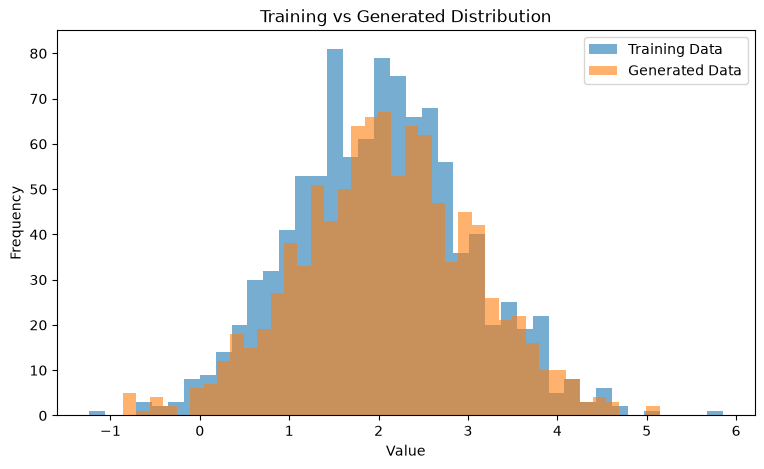

In [103]:
plt.figure(figsize=(9, 5))

plt.hist(
    training_data,
    bins=40,
    alpha=0.6,
    label="Training Data"
)

plt.hist(
    generated_data,
    bins=40,
    alpha=0.6,
    label="Generated Data"
)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Training vs Generated Distribution")
plt.legend()
plt.show()

# 3.2 Generative Modeling Concepts

Before studying individual architectures, three concepts are essential.

## 1. Data Distribution

The real training data comes from:

$$
p_{\text{data}}(x)
$$

The model attempts to learn an approximation:

$$
p_\theta(x)
$$

---

## 2. Sampling

After learning the distribution, the model can generate samples:

$$
x\sim p_\theta(x)
$$

Sampling is the process of obtaining a new example from the learned generative model.

---

## 3. Latent Space

A latent space is a lower-dimensional representation used by many generative models.

A generative process may look like:

$$
z
\rightarrow
G_\theta(z)
\rightarrow
x
$$

where:

$$
z\sim p(z)
$$

For example, $z$ may be sampled from a standard normal distribution:

$$
z\sim\mathcal{N}(0,I)
$$

The generator transforms this random latent vector into a structured sample.

---

## Latent Space Intuition

Imagine a two-dimensional latent space:

```text
             Latent Space

          z₂
          ^
          |
       •  |       •
          |
    •     |           •
          |
----------+---------------> z₁
          |
       •  |    •
          |
```

Different regions of the latent space can correspond to different characteristics of generated data.

A well-structured latent space can allow meaningful changes in generated samples as $z$ changes.

---

## Generative Modeling Pipeline

```text
       Random Noise / Latent Variable
                    |
                    v
             Generative Model
                    |
                    v
             Generated Sample
                    |
                    v
        Compare with Data Distribution
                    |
                    v
              Update Model
                    |
                    +------> Repeat
```

The exact training procedure differs substantially between VAEs, GANs, autoregressive models, and diffusion models.

Therefore, we should study each family separately rather than treating all generative models as the same.


# 3.3 Autoencoders

An **Autoencoder** is a neural network that learns to represent input data in a compact latent representation and then reconstruct the original input from that representation.

The basic structure is:

$$
x
\rightarrow
\text{Encoder}
\rightarrow
z
\rightarrow
\text{Decoder}
\rightarrow
\hat{x}
$$

where:

* $x$ = original input,
* $z$ = latent representation,
* $\hat{x}$ = reconstructed input.

The main objective is:

$$
\boxed{
\hat{x}\approx x
}
$$

Unlike a normal supervised classifier, an autoencoder does not require class labels.

The input itself acts as the target.

---

## Autoencoder Architecture

```text
                 Input
                   |
                   v
            +-------------+
            |   Encoder   |
            +-------------+
                   |
                   v
             Latent Vector
                   z
                   |
                   v
            +-------------+
            |   Decoder   |
            +-------------+
                   |
                   v
            Reconstruction
                  x̂
```

The network therefore has two major components:

### Encoder

The Encoder transforms the input into a lower-dimensional representation:

$$
z=f_\theta(x)
$$

### Decoder

The Decoder reconstructs the input:

$$
\hat{x}=g_\phi(z)
$$

Combining them:

$$
\hat{x}
=
g_\phi(f_\theta(x))
$$

---

## Why Use a Latent Representation?

Suppose an input image contains thousands of pixels.

Instead of directly working with every pixel, the Encoder can learn a compact representation:

$$
x\in\mathbb{R}^{784}
$$

might be transformed into:

$$
z\in\mathbb{R}^{32}
$$

The latent representation can capture important structure in the original data.

```text
784-dimensional image
          |
          v
       Encoder
          |
          v
32-dimensional latent vector
          |
          v
       Decoder
          |
          v
784-dimensional reconstruction
```

This is called **dimensionality reduction through representation learning**.

---

## Reconstruction Loss

The Autoencoder learns by comparing the original input with its reconstruction.

A common loss for continuous data is Mean Squared Error:

$$
L_{\text{reconstruction}}
=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{x}_i)^2
$$

The network tries to minimize this reconstruction error.

For binary-valued or normalized image data, Binary Cross-Entropy can also be appropriate:

$$
L_{\text{BCE}}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
x_i\log(\hat{x}_i)
+
(1-x_i)\log(1-\hat{x}_i)
\right]
$$

The appropriate reconstruction loss depends on the data and decoder output distribution.

---

## Autoencoder Training

Training is conceptually simple:

```text
Input x
   |
   v
Encoder
   |
   v
Latent z
   |
   v
Decoder
   |
   v
Reconstruction x̂
   |
   v
Compare x and x̂
   |
   v
Reconstruction Loss
   |
   v
Backpropagation
   |
   v
Update Encoder + Decoder
```

The Encoder and Decoder are trained together.

---

## Important Point

An Autoencoder is **not automatically a generative model in the strong sense**.

It can reconstruct inputs and learn representations, but ordinary autoencoders do not necessarily provide a well-structured latent probability distribution from which we can reliably sample realistic new data.

This limitation motivates the **Variational Autoencoder (VAE)**.

The progression is:

$$
\boxed{
\text{Autoencoder}
\rightarrow
\text{Variational Autoencoder}
}
$$

A VAE introduces a probabilistic latent representation that makes generation possible in a more principled way.


In [104]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## Simple Autoencoder

In [105]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        reconstruction = self.decode(z)

        return reconstruction

## Test the Autoencoder

In [106]:
input_dim = 784
latent_dim = 32

autoencoder = Autoencoder(
    input_dim=input_dim,
    latent_dim=latent_dim
).to(device)

x = torch.rand(
    8,
    input_dim,
    device=device
)

reconstruction = autoencoder(x)

print("Input shape:", x.shape)
print("Reconstruction shape:", reconstruction.shape)

with torch.no_grad():
    latent = autoencoder.encode(x)

print("Latent representation shape:", latent.shape)

Input shape: torch.Size([8, 784])
Reconstruction shape: torch.Size([8, 784])
Latent representation shape: torch.Size([8, 32])


## Reconstruction Loss

In [107]:
criterion = nn.MSELoss()

loss = criterion(
    reconstruction,
    x
)

print("Reconstruction loss:", loss.item())

Reconstruction loss: 0.08476782590150833


# 3.4 Autoencoder Training on MNIST

We will now train an Autoencoder on the MNIST handwritten-digit dataset.

MNIST contains grayscale images of handwritten digits.

Each image has:

$$
28\times28=784
$$

pixels.

For our fully connected Autoencoder, each image will be flattened:

$$
28\times28
\rightarrow
784
$$

The Autoencoder will compress the 784-dimensional input into a much smaller latent vector and reconstruct the image.

The learning objective is:

$$
x
\rightarrow
z
\rightarrow
\hat{x}
$$

with:

$$
L=
\operatorname{MSE}(x,\hat{x})
$$

This demonstrates **unsupervised representation learning** because no digit labels are required for the reconstruction objective.


## Load MNIST

In [108]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


## Train the Autoencoder

In [109]:
autoencoder = Autoencoder(
    input_dim=784,
    latent_dim=32
).to(device)

optimizer = torch.optim.Adam(
    autoencoder.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

num_epochs = 5

train_losses = []

for epoch in range(num_epochs):

    autoencoder.train()

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        images_flat = images.view(
            images.size(0),
            -1
        )

        reconstructed = autoencoder(
            images_flat
        )

        loss = criterion(
            reconstructed,
            images_flat
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss / len(train_loader)
    )

    train_losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"| Loss: {epoch_loss:.6f}"
    )

Epoch 1/5 | Loss: 0.047434
Epoch 2/5 | Loss: 0.020826
Epoch 3/5 | Loss: 0.015613
Epoch 4/5 | Loss: 0.013104
Epoch 5/5 | Loss: 0.011640


## Plot Training Loss

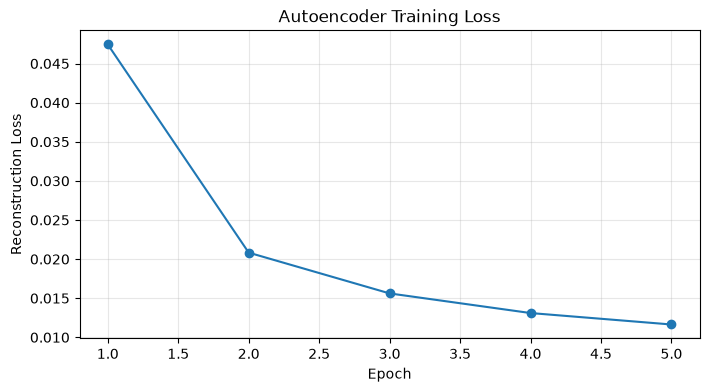

In [110]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

## Visualize Reconstructions

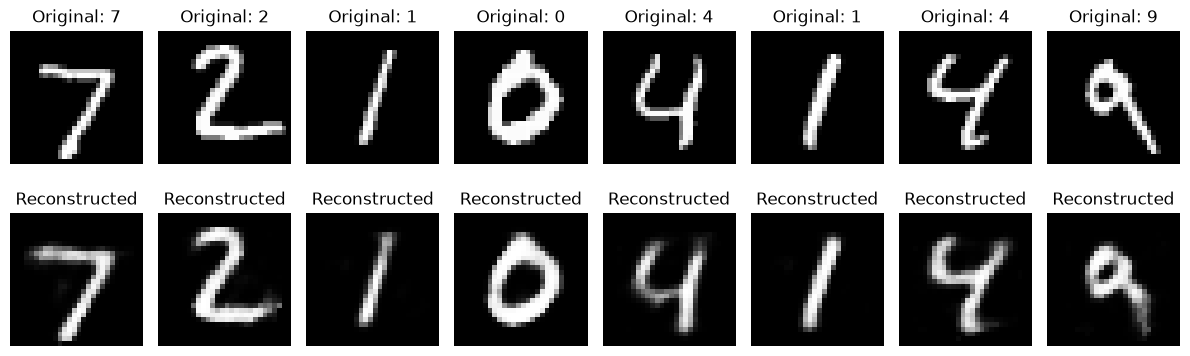

In [111]:
autoencoder.eval()

images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    flat_images = images.view(
        images.size(0),
        -1
    )

    reconstructed = autoencoder(
        flat_images
    )

reconstructed_images = reconstructed.view(
    -1,
    1,
    28,
    28
)

fig, axes = plt.subplots(
    2,
    8,
    figsize=(12, 4)
)

for i in range(8):

    axes[0, i].imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )

    axes[0, i].set_title(
        f"Original: {labels[i].item()}"
    )

    axes[0, i].axis("off")

    axes[1, i].imshow(
        reconstructed_images[i].cpu().squeeze(),
        cmap="gray"
    )

    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# 3.5 Understanding the Autoencoder Latent Space

The latent representation is the most important part of the Autoencoder from a representation-learning perspective.

For an input:

$$
x
$$

the Encoder produces:

$$
z=f_\theta(x)
$$

For example:

$$
x\in\mathbb{R}^{784}
$$

can become:

$$
z\in\mathbb{R}^{32}
$$

The Decoder then reconstructs:

$$
\hat{x}=g_\phi(z)
$$

The network therefore learns a compressed representation that preserves information useful for reconstruction.

---

## Latent Space Visualization

Our latent representation has 32 dimensions, which cannot be directly plotted in a two-dimensional graph.

We can use a dimensionality-reduction technique such as PCA only for visualization:

$$
z_{32D}
\rightarrow
z_{2D}
$$

This does **not** mean that the actual Autoencoder latent space is two-dimensional.

It is only a visualization of the learned 32-dimensional representations.

---

## Important Interpretation

A good latent representation should capture useful structure.

For handwritten digits, different latent regions may correspond to different visual characteristics such as:

* digit shape,
* stroke structure,
* thickness,
* writing style.

However, an ordinary Autoencoder does not guarantee a smooth or well-organized latent space.

This becomes an important distinction when we move to Variational Autoencoders.

### Autoencoder

$$
x\rightarrow z\rightarrow\hat{x}
$$

### Variational Autoencoder

$$
x\rightarrow q_\phi(z|x)\rightarrow z\rightarrow p_\theta(x|z)
$$

The VAE explicitly models uncertainty in the latent representation.

That probabilistic structure is what makes the VAE a much more principled generative model.


# 3.6 Variational Autoencoder (VAE): Probabilistic Latent Variables

A Variational Autoencoder (VAE) is a probabilistic generative deep learning model.

Unlike a standard Autoencoder, which maps an input to one fixed latent vector, a VAE maps an input to a probability distribution in latent space.

The basic architecture is:

$$
x \rightarrow Encoder \rightarrow (\mu, \log\sigma^2)
\rightarrow z
\rightarrow Decoder \rightarrow \hat{x}
$$

where:

- $x$ = input data
- $\mu$ = mean of the latent distribution
- $\sigma^2$ = latent variance
- $z$ = sampled latent vector
- $\hat{x}$ = reconstructed input

The encoder approximates the posterior distribution:

$$
q_\phi(z|x)
$$

The decoder models the probability of the input given the latent variable:

$$
p_\theta(x|z)
$$

The VAE also assumes a prior distribution over latent variables:

$$
p(z)=\mathcal{N}(0,I)
$$

Therefore, a VAE learns:

1. How to encode data into a probability distribution.
2. How to sample latent vectors.
3. How to reconstruct data from latent vectors.
4. A smooth and structured latent space.
5. How to generate new data.

## Why Do We Need a VAE?

A standard Autoencoder learns:

$$
x \rightarrow z \rightarrow \hat{x}
$$

The latent vector $z$ is deterministic.

However, this creates a problem for generation.

Suppose an Autoencoder has learned latent representations for handwritten digits.

The latent space may contain regions corresponding to valid digits and other regions that do not correspond to meaningful images.

Therefore, randomly choosing:

$$
z \sim \mathcal{N}(0,I)
$$

and passing it through an ordinary Autoencoder decoder does not necessarily produce a meaningful image.

A VAE solves this by explicitly regularizing the latent space.

It encourages the latent representations to follow a known probability distribution, usually:

$$
p(z)=\mathcal{N}(0,I)
$$

This makes the latent space smoother and easier to sample from.

The main idea is:

$$
\boxed{\text{Learn a structured latent distribution instead of isolated latent points}}
$$

## 3.6.1 VAE Encoder

A standard Autoencoder produces one latent vector.

A VAE encoder instead produces two vectors:

$$
\mu = Encoder_\mu(x)
$$

and

$$
\log\sigma^2 = Encoder_{\log\sigma^2}(x)
$$

These parameters define a Gaussian distribution:

$$
q_\phi(z|x)
=
\mathcal{N}(\mu,\sigma^2)
$$

The encoder therefore does not directly output $z$.

It outputs the parameters needed to construct the distribution from which $z$ will be sampled.

We use $\log\sigma^2$ instead of $\sigma^2$ directly because it is numerically more convenient and does not require the network to explicitly enforce positivity.

In [112]:
class VAEEncoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.encoder(x)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        return mu, logvar

## 3.6.2 Reparameterization Trick

We want to sample:

$$
z \sim \mathcal{N}(\mu,\sigma^2)
$$

A naive sampling operation would make gradient-based optimization difficult.

The VAE therefore uses the reparameterization trick.

First calculate:

$$
\sigma = \exp\left(\frac{1}{2}\log\sigma^2\right)
$$

Then sample:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

Finally:

$$
\boxed{
z = \mu + \sigma \odot \epsilon
}
$$

where $\odot$ represents element-wise multiplication.

This separates the random component from the learnable parameters.

The neural network can therefore receive gradients through $\mu$ and $\sigma$.

This is one of the most important ideas behind the VAE.

### Intuition

Instead of asking the network to directly produce a random $z$, we write:

$$
z = \text{learned mean} + \text{learned scale} \times \text{random noise}
$$

The randomness comes from $\epsilon$, while the encoder still remains differentiable with respect to its parameters.

In [113]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(std)
    
    z = mu + epsilon * std
    
    return z

In [114]:
# Small demonstration of the reparameterization trick

mu = torch.tensor([[0.0, 1.0]])
logvar = torch.tensor([[0.0, -0.6931]])

z = reparameterize(mu, logvar)

print("Mean:")
print(mu)

print("\nLog variance:")
print(logvar)

print("\nSampled latent vector:")
print(z)

Mean:
tensor([[0., 1.]])

Log variance:
tensor([[ 0.0000, -0.6931]])

Sampled latent vector:
tensor([[0.3803, 1.5132]])


## 3.6.3 Complete VAE Architecture

The complete VAE consists of:

$$
x
\rightarrow
Encoder
\rightarrow
(\mu,\log\sigma^2)
\rightarrow
Reparameterization
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

The encoder learns:

$$
q_\phi(z|x)
$$

The prior is:

$$
p(z)=\mathcal{N}(0,I)
$$

The decoder learns:

$$
p_\theta(x|z)
$$

For MNIST, we use a 2-dimensional latent space.

This is especially useful for visualization because each image can be represented as a point:

$$
z=(z_1,z_2)
$$

in a two-dimensional latent space.

In [115]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=2):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        
        return mu + epsilon * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        
        z = self.reparameterize(mu, logvar)
        
        reconstruction = self.decode(z)
        
        return reconstruction, mu, logvar

In [116]:
vae = VAE(
    input_dim=784,
    hidden_dim=256,
    latent_dim=2
).to(device)

print(vae)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


## 3.6.4 VAE Loss Function

The VAE loss contains two important components:

$$
\boxed{
L_{VAE}
=
L_{reconstruction}
+
L_{KL}
}
$$

### 1. Reconstruction Loss

The decoder should reconstruct the original input:

$$
x \approx \hat{x}
$$

For MNIST with pixel values in $[0,1]$, Binary Cross-Entropy is commonly used:

$$
L_{reconstruction}
=
-\sum_i
\left[
x_i\log(\hat{x}_i)
+
(1-x_i)\log(1-\hat{x}_i)
\right]
$$

### 2. KL Divergence

The latent distribution should remain close to the standard normal prior:

$$
p(z)=\mathcal{N}(0,I)
$$

Therefore we minimize:

$$
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
$$

For a diagonal Gaussian, this becomes:

$$
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1+\log\sigma_j^2-\mu_j^2-\sigma_j^2
\right)
$$

The KL term prevents the encoder from placing latent representations arbitrarily far apart.

Therefore:

$$
\boxed{
\text{Reconstruction loss}
\rightarrow
\text{preserve information}
}
$$

and

$$
\boxed{
\text{KL loss}
\rightarrow
\text{regularize latent space}
}
$$

In [117]:
import torch.nn.functional as F

def vae_loss(reconstruction, x, mu, logvar):
    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        x,
        reduction="sum"
    )
    
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    total_loss = reconstruction_loss + kl_loss
    
    return total_loss, reconstruction_loss, kl_loss

## Train the VAE

In [118]:
vae = VAE(
    input_dim=784,
    hidden_dim=256,
    latent_dim=2
).to(device)

optimizer = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

num_epochs = 10

vae_total_losses = []
vae_reconstruction_losses = []
vae_kl_losses = []

for epoch in range(num_epochs):
    vae.train()
    
    total_loss = 0.0
    total_reconstruction = 0.0
    total_kl = 0.0
    
    for images, _ in train_loader:
        images = images.to(device)
        images_flat = images.view(images.size(0), -1)
        
        reconstruction, mu, logvar = vae(images_flat)
        
        loss, reconstruction_loss, kl_loss = vae_loss(
            reconstruction,
            images_flat,
            mu,
            logvar
        )
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_reconstruction += reconstruction_loss.item()
        total_kl += kl_loss.item()
    
    avg_loss = total_loss / len(train_loader.dataset)
    avg_reconstruction = total_reconstruction / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)
    
    vae_total_losses.append(avg_loss)
    vae_reconstruction_losses.append(avg_reconstruction)
    vae_kl_losses.append(avg_kl)
    
    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Total: {avg_loss:.4f} | "
        f"Reconstruction: {avg_reconstruction:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

Epoch 01/10 | Total: 196.1064 | Reconstruction: 189.7126 | KL: 6.3938
Epoch 02/10 | Total: 172.0586 | Reconstruction: 166.8039 | KL: 5.2547
Epoch 03/10 | Total: 166.5534 | Reconstruction: 161.2167 | KL: 5.3366
Epoch 04/10 | Total: 163.7257 | Reconstruction: 158.3179 | KL: 5.4079
Epoch 05/10 | Total: 161.9669 | Reconstruction: 156.5107 | KL: 5.4562
Epoch 06/10 | Total: 160.6191 | Reconstruction: 155.1232 | KL: 5.4959
Epoch 07/10 | Total: 159.5738 | Reconstruction: 154.0345 | KL: 5.5393
Epoch 08/10 | Total: 158.7262 | Reconstruction: 153.1394 | KL: 5.5868
Epoch 09/10 | Total: 157.8893 | Reconstruction: 152.2773 | KL: 5.6119
Epoch 10/10 | Total: 157.1781 | Reconstruction: 151.5340 | KL: 5.6441


## Visualize VAE Training

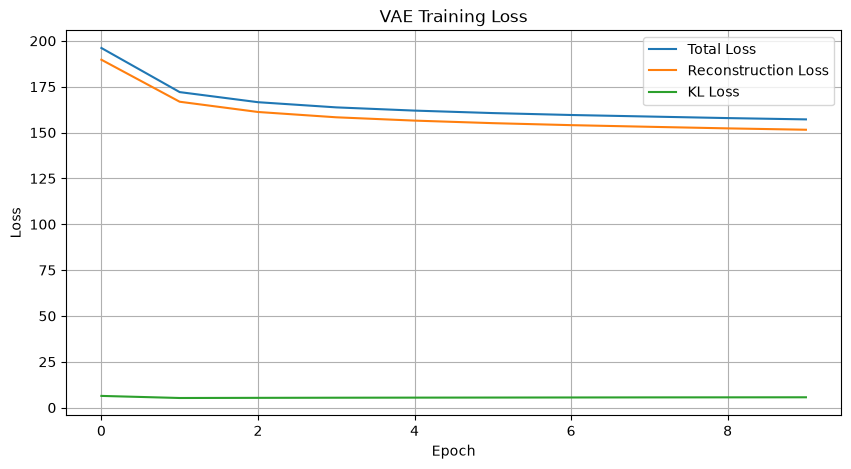

In [119]:
plt.figure(figsize=(10, 5))

plt.plot(vae_total_losses, label="Total Loss")
plt.plot(vae_reconstruction_losses, label="Reconstruction Loss")
plt.plot(vae_kl_losses, label="KL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Interpreting the Curves

The total VAE loss is composed of:

$$
L_{total}=L_{reconstruction}+L_{KL}
$$

Usually:

- Reconstruction loss decreases as the decoder learns to reconstruct images.
- KL loss controls the organization of the latent space.
- Total loss should generally decrease during training.

The two components should not be interpreted independently.

A very low reconstruction loss with a poorly regularized latent space would not necessarily give a useful generative model.

The strength of the VAE comes from balancing both objectives.

## VAE Reconstruction

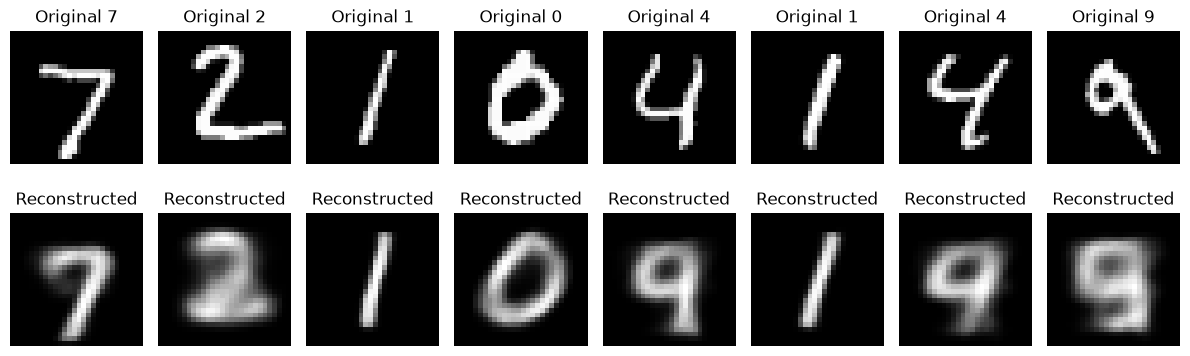

In [120]:
vae.eval()

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images.to(device)
    
    images_flat = images.view(images.size(0), -1)
    
    reconstruction, mu, logvar = vae(images_flat)

    reconstruction_images = reconstruction.view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(12, 4))

for i in range(8):
    axes[0, i].imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original {labels[i].item()}")

    axes[1, i].imshow(
        reconstruction_images[i].cpu().squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")
    axes[1, i].set_title("Reconstructed")

plt.tight_layout()
plt.show()

## 3.6.8 Visualizing the Latent Space

Because our VAE uses:

$$
z\in\mathbb{R}^2
$$

we can directly visualize the latent representations.

We use the encoder mean $\mu$ as a stable representation of each image.

For every test image:

$$
x \rightarrow Encoder \rightarrow \mu
$$

The two coordinates of $\mu$ become:

- horizontal axis = $z_1$
- vertical axis = $z_2$

We color each point according to its digit label.

A well-structured latent space should show meaningful organization.

Similar digits should tend to occupy nearby regions.

In [121]:
vae.eval()

latent_points = []
latent_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        images_flat = images.view(images.size(0), -1)
        
        mu, logvar = vae.encode(images_flat)
        
        latent_points.append(mu.cpu())
        latent_labels.append(labels)

latent_points = torch.cat(latent_points)
latent_labels = torch.cat(latent_labels)

print("Latent shape:", latent_points.shape)

Latent shape: torch.Size([10000, 2])


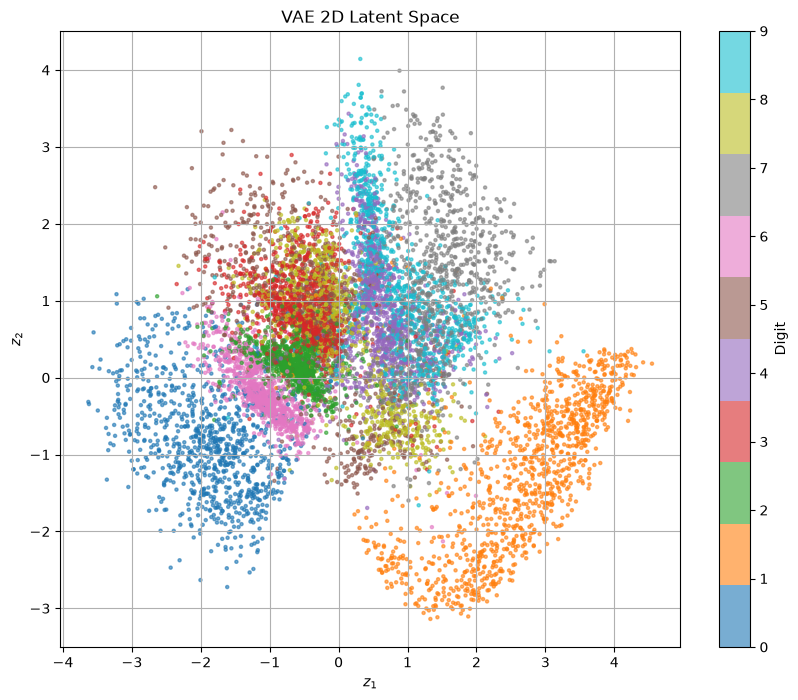

In [122]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("VAE 2D Latent Space")
plt.colorbar(scatter, label="Digit")
plt.grid(True)
plt.show()

## 3.6.9 Generate New Images from the VAE

This is the key generative capability of the VAE.

During generation, we do not need an input image.

Instead, sample directly from the prior:

$$
z\sim\mathcal{N}(0,I)
$$

Then pass the latent vector through the decoder:

$$
z\rightarrow Decoder\rightarrow x_{generated}
$$

Therefore:

$$
\boxed{
z\sim\mathcal{N}(0,I)
\rightarrow
Decoder
\rightarrow
Generated\ Image
}
$$

This is why the KL divergence term is important.

It encourages the learned latent space to resemble the standard normal distribution, making random sampling meaningful.

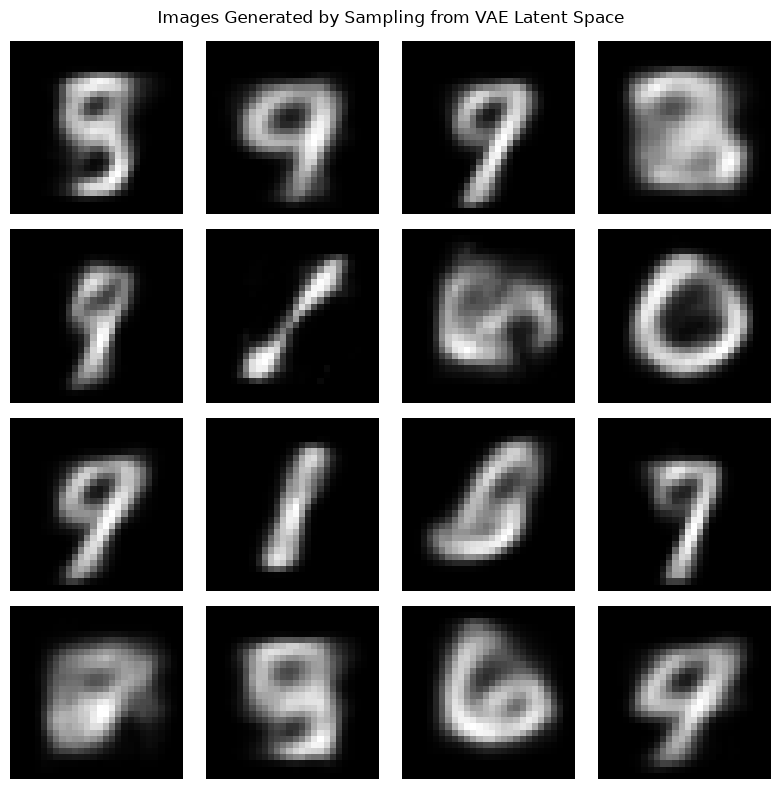

In [123]:
vae.eval()

num_samples = 16

with torch.no_grad():
    z = torch.randn(num_samples, 2).to(device)
    generated_images = vae.decode(z)
    generated_images = generated_images.view(
        num_samples, 1, 28, 28
    )

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        generated_images[i].cpu().squeeze(),
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("Images Generated by Sampling from VAE Latent Space")
plt.tight_layout()
plt.show()

## 3.6.10 Sampling Across the Latent Space

Because the VAE learns a structured latent space, we can systematically move through the latent coordinates.

For example:

$$
z=(z_1,z_2)
$$

can be varied across a grid.

Each point in this grid is passed through the decoder.

This allows us to observe how generated images change as we move through latent space.

Smooth changes between neighboring latent points demonstrate the continuous nature of the learned representation.

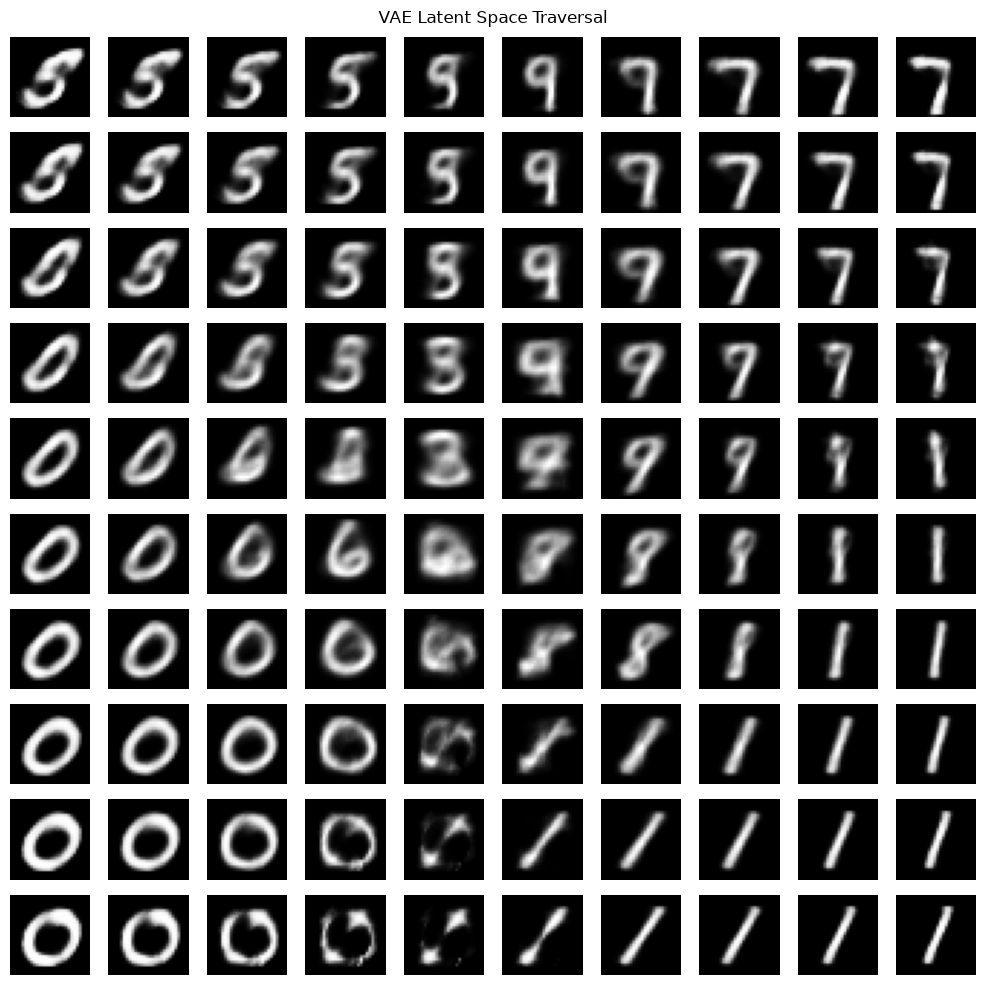

In [124]:
vae.eval()

grid_size = 10

z1_values = torch.linspace(-3, 3, grid_size)
z2_values = torch.linspace(-3, 3, grid_size)

latent_grid = []

for z2 in reversed(z2_values):
    for z1 in z1_values:
        latent_grid.append([z1.item(), z2.item()])

latent_grid = torch.tensor(
    latent_grid,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    generated = vae.decode(latent_grid)
    generated = generated.view(
        grid_size * grid_size,
        28,
        28
    )

fig, axes = plt.subplots(
    grid_size,
    grid_size,
    figsize=(10, 10)
)

for i, ax in enumerate(axes.flat):
    ax.imshow(
        generated[i].cpu(),
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("VAE Latent Space Traversal")
plt.tight_layout()
plt.show()

# 3.6.11 Understanding the Complete VAE

The complete VAE process is:

### Step 1 — Encode

The input image is passed through the encoder.

$$
x\rightarrow Encoder
$$

The encoder produces:

$$
\mu,\log\sigma^2
$$

### Step 2 — Construct the distribution

These parameters define:

$$
q_\phi(z|x)
=
\mathcal{N}(\mu,\sigma^2)
$$

### Step 3 — Sample

Using the reparameterization trick:

$$
z=\mu+\sigma\odot\epsilon
$$

where:

$$
\epsilon\sim\mathcal{N}(0,I)
$$

### Step 4 — Decode

The latent vector is passed through the decoder:

$$
z\rightarrow Decoder\rightarrow\hat{x}
$$

### Step 5 — Reconstruction objective

The reconstructed image should resemble the original:

$$
x\approx\hat{x}
$$

### Step 6 — KL regularization

The learned latent distribution should remain close to:

$$
\mathcal{N}(0,I)
$$

### Step 7 — Generation

After training, we can discard the encoder and sample:

$$
z\sim\mathcal{N}(0,I)
$$

Then:

$$
z\rightarrow Decoder\rightarrow x_{new}
$$

Therefore, the VAE is both:

$$
\boxed{\text{Representation Learner}}
$$

and

$$
\boxed{\text{Generative Model}}
$$

## 3.6.12 Standard Autoencoder vs VAE

| Property | Autoencoder | VAE |
|---|---|---|
| Encoder output | Fixed latent vector | Mean and variance |
| Latent representation | Deterministic | Probabilistic |
| Latent space regularization | No explicit prior | KL divergence |
| Sampling | Not naturally defined | Directly supported |
| Generation | Weak / indirect | Core capability |
| Reconstruction | Yes | Yes |
| Smooth latent space | Not guaranteed | Encouraged |
| Generative model | Not necessarily | Yes |
| Reparameterization | No | Yes |
| Prior distribution | Usually absent | $N(0,I)$ |

The most important distinction is:

$$
\boxed{
AE:\ x\rightarrow z
}
$$

whereas:

$$
\boxed{
VAE:\ x\rightarrow q_\phi(z|x)
}
$$

The VAE learns a probability distribution rather than simply memorizing a latent point.

# 3.6.13 Exam Summary — Variational Autoencoder

### Definition

A Variational Autoencoder is a probabilistic generative neural network that learns a structured latent distribution and generates new samples by decoding latent variables.

### Architecture

$$
x
\rightarrow
Encoder
\rightarrow
(\mu,\log\sigma^2)
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

### Encoder

The encoder learns:

$$
q_\phi(z|x)
=
\mathcal{N}(\mu,\sigma^2)
$$

### Reparameterization Trick

$$
\sigma=\exp\left(\frac{1}{2}\log\sigma^2\right)
$$

$$
\boxed{
z=\mu+\sigma\odot\epsilon
}
$$

where:

$$
\epsilon\sim\mathcal{N}(0,I)
$$

### VAE Loss

$$
\boxed{
L_{VAE}
=
L_{reconstruction}
+
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
}
$$

with:

$$
p(z)=\mathcal{N}(0,I)
$$

### KL Divergence

$$
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1+\log\sigma_j^2-\mu_j^2-\sigma_j^2
\right)
$$

### Generation

Sample:

$$
z\sim\mathcal{N}(0,I)
$$

Then:

$$
z\rightarrow Decoder\rightarrow x_{new}
$$

### Key Advantages

- Smooth latent space
- Probabilistic representation
- Direct generation
- Meaningful latent interpolation
- Unsupervised representation learning

### Key Limitation

VAEs often produce blurrier samples than GANs because reconstruction-based likelihood objectives can favor averaging.

### Most Important Exam Point

The VAE combines:

$$
\boxed{
\text{Reconstruction}
+
\text{Latent-space regularization}
}
$$

The reconstruction term preserves information, while the KL term makes the latent space structured and sampleable.

# 3.7 Generative Adversarial Networks (GANs)

Generative Adversarial Networks (GANs) are generative deep learning models introduced by Ian Goodfellow and colleagues in 2014.

A GAN consists of two neural networks:

1. **Generator**
2. **Discriminator**

These two networks compete against each other during training.

The generator tries to create realistic samples.

The discriminator tries to distinguish real samples from generated samples.

The basic architecture is:

$$
z
\rightarrow
Generator
\rightarrow
x_{fake}
$$

and

$$
x_{real},x_{fake}
\rightarrow
Discriminator
\rightarrow
Probability
$$

The generator attempts to fool the discriminator, while the discriminator attempts to correctly identify real and fake samples.

This adversarial process can gradually improve the quality of generated samples.

## 3.7.1 Generator

The Generator creates synthetic data from a random latent vector.

We first sample:

$$
z\sim p(z)
$$

Usually:

$$
z\sim\mathcal{N}(0,I)
$$

The generator transforms this latent vector:

$$
G(z)=x_{fake}
$$

Therefore:

$$
\boxed{
z\rightarrow G\rightarrow x_{fake}
}
$$

The generator does not directly receive real images.

Its goal is to learn how to transform random latent vectors into samples that resemble the real training distribution.

For image generation:

$$
z
\rightarrow
Generator
\rightarrow
Generated\ Image
$$

In [125]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, output_dim=784):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.network(z)

## 3.7.2 Discriminator

The Discriminator is a binary classifier.

It receives either:

- a real sample
- a generated sample

and outputs the probability that the sample is real.

Mathematically:

$$
D(x)\in[0,1]
$$

where:

- $D(x)\approx1$ means the discriminator believes $x$ is real.
- $D(x)\approx0$ means the discriminator believes $x$ is fake.

The discriminator therefore learns:

$$
\boxed{
x\rightarrow D\rightarrow P(real)
}
$$

During training, it receives both real and generated examples.

In [126]:
class Discriminator(nn.Module):
    def __init__(self, input_dim=784):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

## 3.7.3 Complete GAN Architecture

The complete GAN consists of two networks:

$$
z
\rightarrow
G
\rightarrow
x_{fake}
\rightarrow
D
\rightarrow
P(real)
$$

At the same time:

$$
x_{real}
\rightarrow
D
\rightarrow
P(real)
$$

The training process is adversarial.

### Generator

The Generator wants:

$$
D(G(z))\rightarrow1
$$

because it wants the discriminator to believe that generated samples are real.

### Discriminator

The Discriminator wants:

$$
D(x_{real})\rightarrow1
$$

and:

$$
D(G(z))\rightarrow0
$$

Therefore:

$$
\boxed{
G\rightarrow\text{generate realistic samples}
}
$$

while:

$$
\boxed{
D\rightarrow\text{distinguish real from fake}
}
$$

## 3.7.4 GAN Objective

The original GAN formulation uses a minimax objective:

$$
\boxed{
\min_G\max_D V(D,G)
}
$$

where:

$$
V(D,G)
=
\mathbb{E}_{x\sim p_{data}}
[\log D(x)]
+
\mathbb{E}_{z\sim p(z)}
[\log(1-D(G(z)))]
$$

The discriminator maximizes this objective.

It wants:

$$
D(x)\rightarrow1
$$

for real samples and:

$$
D(G(z))\rightarrow0
$$

for generated samples.

The generator minimizes the objective.

Its goal is to produce samples that the discriminator classifies as real.

### Important intuition

The two networks have opposing objectives:

$$
\boxed{
D:\ \text{detect fake samples}
}
$$

$$
\boxed{
G:\ \text{create samples that look real}
}
$$

This competition gives GANs their name:

**Generative Adversarial Network**

## 3.7.5 Binary Cross-Entropy Loss

In a practical implementation, Binary Cross-Entropy (BCE) can be used.

For the discriminator:

$$
L_D
=
L_{real}
+
L_{fake}
$$

where:

$$
L_{real}
=
BCE(D(x_{real}),1)
$$

and:

$$
L_{fake}
=
BCE(D(G(z)),0)
$$

Therefore:

$$
\boxed{
L_D
=
BCE(D(x_{real}),1)
+
BCE(D(G(z)),0)
}
$$

For the generator, we want:

$$
D(G(z))\rightarrow1
$$

Therefore:

$$
\boxed{
L_G
=
BCE(D(G(z)),1)
}
$$

Notice the important difference:

The discriminator labels generated samples as **0**.

The generator treats its generated samples as desired **1** targets because it wants to fool the discriminator.

##  Initialize the GAN

In [127]:
latent_dim = 100

generator = Generator(
    latent_dim=latent_dim,
    output_dim=784
).to(device)

discriminator = Discriminator(
    input_dim=784
).to(device)

criterion_gan = nn.BCELoss()

optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    discriminator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

print("Generator:")
print(generator)

print("\nDiscriminator:")
print(discriminator)

Generator:
Generator(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Discriminator:
Discriminator(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 3.7.7 GAN Training Step

GAN training alternates between two optimization steps.

### Step 1 — Train the Discriminator

First sample real images:

$$
x_{real}\sim p_{data}(x)
$$

Then generate fake images:

$$
x_{fake}=G(z)
$$

The discriminator is trained to distinguish them:

$$
D(x_{real})\rightarrow1
$$

$$
D(x_{fake})\rightarrow0
$$

### Step 2 — Train the Generator

Generate a new batch:

$$
x_{fake}=G(z)
$$

Pass it through the discriminator.

The generator is trained so that:

$$
D(x_{fake})\rightarrow1
$$

Thus, one GAN iteration contains:

$$
\boxed{
\text{Update Discriminator}
\rightarrow
\text{Update Generator}
}
$$

In [128]:
def train_gan_step(real_images):
    batch_size = real_images.size(0)
    
    real_images = real_images.view(batch_size, -1).to(device)
    
    # Labels
    real_labels = torch.ones(batch_size, 1, device=device)
    fake_labels = torch.zeros(batch_size, 1, device=device)
    
    # ==========================================
    # 1. Train Discriminator
    # ==========================================
    
    optimizer_D.zero_grad()
    
    # Real images
    real_output = discriminator(real_images)
    loss_real = criterion_gan(real_output, real_labels)
    
    # Fake images
    z = torch.randn(batch_size, latent_dim, device=device)
    fake_images = generator(z)
    
    fake_output = discriminator(fake_images.detach())
    loss_fake = criterion_gan(fake_output, fake_labels)
    
    loss_D = loss_real + loss_fake
    
    loss_D.backward()
    optimizer_D.step()
    
    # ==========================================
    # 2. Train Generator
    # ==========================================
    
    optimizer_G.zero_grad()
    
    z = torch.randn(batch_size, latent_dim, device=device)
    generated_images = generator(z)
    
    discriminator_output = discriminator(generated_images)
    
    loss_G = criterion_gan(
        discriminator_output,
        real_labels
    )
    
    loss_G.backward()
    optimizer_G.step()
    
    return loss_D.item(), loss_G.item()

## 3.7.8 Why `detach()` Is Used

When training the discriminator, we generate fake images:

$$
x_{fake}=G(z)
$$

We want to update the discriminator without updating the generator during this step.

Therefore:

```python
fake_images.detach()

is used.

This prevents gradients from propagating through the generator during the discriminator update.

Conceptually:

$$ \boxed{ \text{Discriminator step} \Rightarrow \text{update D only} } $$

Then during the generator step, we do not use detach() because gradients must flow:

$$ D(G(z)) \rightarrow G $$

so that the generator can learn how to fool the discriminator.

## Train the GAN on MNIST

In [129]:
num_epochs = 20

gan_generator_losses = []
gan_discriminator_losses = []

for epoch in range(num_epochs):
    generator.train()
    discriminator.train()
    
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    
    for images, _ in train_loader:
        loss_D, loss_G = train_gan_step(images)
        
        epoch_d_loss += loss_D
        epoch_g_loss += loss_G
    
    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)
    
    gan_discriminator_losses.append(avg_d_loss)
    gan_generator_losses.append(avg_g_loss)
    
    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

Epoch 01/20 | D Loss: 0.3669 | G Loss: 3.3441
Epoch 02/20 | D Loss: 0.0621 | G Loss: 5.9910
Epoch 03/20 | D Loss: 0.0412 | G Loss: 7.1999
Epoch 04/20 | D Loss: 0.0403 | G Loss: 8.1503
Epoch 05/20 | D Loss: 0.0539 | G Loss: 7.1580
Epoch 06/20 | D Loss: 0.0237 | G Loss: 26.5914
Epoch 07/20 | D Loss: 0.0000 | G Loss: 38.0903
Epoch 08/20 | D Loss: 0.0000 | G Loss: 37.8589
Epoch 09/20 | D Loss: 0.0000 | G Loss: 37.6233
Epoch 10/20 | D Loss: 0.0000 | G Loss: 37.3395
Epoch 11/20 | D Loss: 0.1153 | G Loss: 32.7011
Epoch 12/20 | D Loss: 0.0746 | G Loss: 8.9901
Epoch 13/20 | D Loss: 0.0515 | G Loss: 7.6019
Epoch 14/20 | D Loss: 0.0425 | G Loss: 20.0796
Epoch 15/20 | D Loss: 0.0346 | G Loss: 8.2538
Epoch 16/20 | D Loss: 0.0597 | G Loss: 8.1839
Epoch 17/20 | D Loss: 0.0408 | G Loss: 6.9672
Epoch 18/20 | D Loss: 0.0276 | G Loss: 7.7950
Epoch 19/20 | D Loss: 0.0195 | G Loss: 8.5388
Epoch 20/20 | D Loss: 0.0042 | G Loss: 8.9072


## Visualize GAN Training

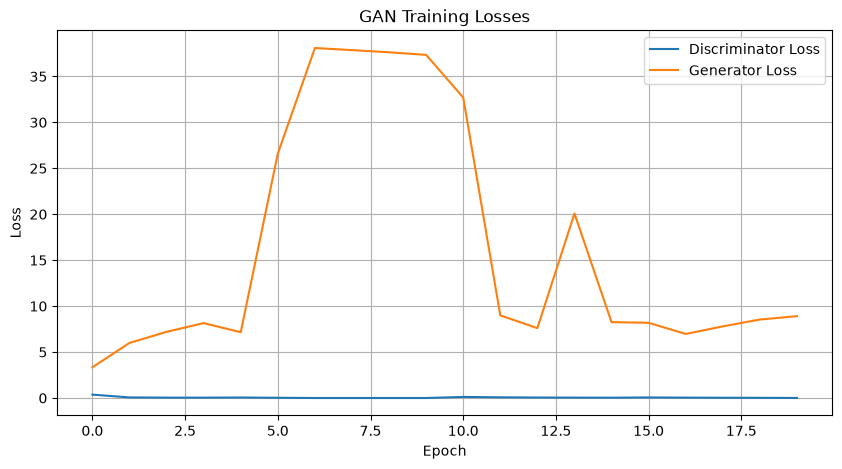

In [130]:
plt.figure(figsize=(10, 5))

plt.plot(
    gan_discriminator_losses,
    label="Discriminator Loss"
)

plt.plot(
    gan_generator_losses,
    label="Generator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

### Important GAN Training Observation

GAN losses should not be interpreted like ordinary supervised-learning loss curves.

We do not necessarily expect both losses to continuously decrease.

The generator and discriminator are competing.

A changing balance between the two losses is normal.

GAN training can therefore be unstable.

Possible problems include:

- Mode collapse
- Oscillating losses
- Vanishing gradients
- Discriminator overpowering the generator
- Generator overpowering the discriminator

## Generate Images with the Trained GAN

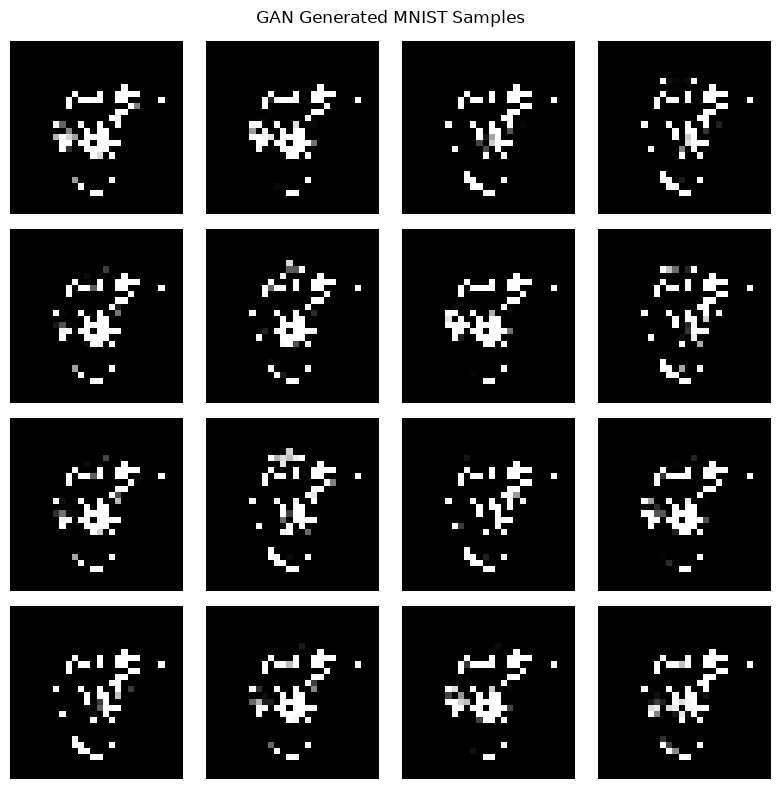

In [131]:
generator.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim, device=device)
    generated_images = generator(z)
    
    generated_images = generated_images.view(
        16, 1, 28, 28
    )

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        generated_images[i].cpu().squeeze(),
        cmap="gray"
    )
    ax.axis("off")

plt.suptitle("GAN Generated MNIST Samples")
plt.tight_layout()
plt.show()

## 3.7.12 Generator vs Discriminator

| Component | Generator | Discriminator |
|---|---|---|
| Input | Random latent vector $z$ | Real or fake sample |
| Output | Generated sample | Probability of being real |
| Goal | Fool discriminator | Detect fake samples |
| Learns | Data generation | Real/fake discrimination |
| Training target | $D(G(z))\rightarrow1$ | Real $\rightarrow1$, Fake $\rightarrow0$ |
| Network type | Generative network | Binary classifier |

The relationship is adversarial:

$$
\boxed{
G\leftrightarrow D
}
$$

The Generator becomes better because the Discriminator becomes better.

The Discriminator becomes better because the Generator produces increasingly realistic samples.

## 3.7.13 Mode Collapse

One important GAN failure mode is **mode collapse**.

Suppose the training dataset contains many different types of images.

The generator may discover that producing a small variety of samples is enough to fool the discriminator.

Instead of learning the full data distribution:

$$
p_{data}(x)
$$

the generator may produce only a limited subset of it.

For example, a GAN trained on MNIST might generate mostly:

$$
\text{digit 1}
$$

while rarely producing other digits.

This means the generator has failed to capture the diversity of the data distribution.

This problem is called:

$$
\boxed{\text{Mode Collapse}}
$$

### Intuition

The goal should be:

$$
z_1,z_2,z_3,\ldots
\rightarrow
\text{diverse realistic samples}
$$

but under mode collapse:

$$
z_1,z_2,z_3,\ldots
\rightarrow
\text{very similar samples}
$$

## 3.7.14 GAN Advantages and Limitations

### Advantages

- Can generate highly realistic samples.
- Does not require explicit likelihood calculation.
- Can learn complex data distributions.
- Produces sharp images compared with many basic VAEs.
- Useful for image synthesis and data generation.

### Limitations

- Training can be unstable.
- Mode collapse can occur.
- Generator and discriminator require careful balancing.
- GANs can be sensitive to hyperparameters.
- Evaluating generated samples is difficult.
- Training may oscillate instead of converging smoothly.

Therefore:

$$
\boxed{
\text{GANs can produce excellent samples but are difficult to train}
}
$$

## 3.7.15 VAE vs GAN

| Property | VAE | GAN |
|---|---|---|
| Main idea | Probabilistic latent-variable model | Adversarial training |
| Encoder | Yes | Usually no |
| Decoder / Generator | Decoder | Generator |
| Discriminator | No | Yes |
| Latent space | Explicitly structured | Implicitly learned |
| Reconstruction | Yes | No direct reconstruction objective |
| Training stability | Generally easier | Often difficult |
| Sample quality | Often smoother / blurrier | Often sharper |
| Generation | Yes | Yes |
| Main challenge | Reconstruction-quality trade-off | Training instability / mode collapse |

The conceptual difference is:

### VAE

$$
\boxed{
\text{Encode}
\rightarrow
\text{Sample latent variable}
\rightarrow
\text{Decode}
}
$$

### GAN

$$
\boxed{
\text{Generate}
\leftrightarrow
\text{Discriminate}
}
$$

# 3.7.16 Exam Summary — Generative Adversarial Networks

### Definition

A GAN is a generative deep learning model consisting of two competing neural networks:

1. Generator
2. Discriminator

### Generator

The Generator maps a latent vector to a synthetic sample:

$$
z\rightarrow G(z)
$$

### Discriminator

The Discriminator estimates whether a sample is real:

$$
D(x)\in[0,1]
$$

### Training

The discriminator learns:

$$
D(x_{real})\rightarrow1
$$

and:

$$
D(G(z))\rightarrow0
$$

The generator learns:

$$
D(G(z))\rightarrow1
$$

### Original GAN Objective

$$
\boxed{
\min_G\max_D
\left[
\mathbb{E}_{x\sim p_{data}}
[\log D(x)]
+
\mathbb{E}_{z\sim p(z)}
[\log(1-D(G(z)))]
\right]
}
$$

### Generator Loss

In the practical non-saturating formulation:

$$
\boxed{
L_G=BCE(D(G(z)),1)
}
$$

### Discriminator Loss

$$
\boxed{
L_D=
BCE(D(x_{real}),1)
+
BCE(D(G(z)),0)
}
$$

### Main Failure Mode

$$
\boxed{\text{Mode Collapse}}
$$

where the generator produces insufficiently diverse samples.

### Key Exam Difference

VAE:

$$
\text{Probabilistic latent representation}
+
\text{reconstruction}
$$

GAN:

$$
\text{Generator}
+
\text{adversarial discriminator}
$$

### Core GAN Idea

$$
\boxed{
\text{Generator tries to fool the Discriminator}
}
$$

while:

$$
\boxed{
\text{Discriminator tries to detect generated samples}
}
$$

# 3.8 GAN Architectures and Improvements

The original GAN introduced the powerful idea of adversarial training:

$$
Generator \leftrightarrow Discriminator
$$

However, basic GANs can be difficult to train.

Common problems include:

- Training instability
- Mode collapse
- Poor image quality
- Difficulty balancing Generator and Discriminator
- Vanishing gradients
- Sensitivity to architecture and hyperparameters

Researchers developed several GAN variants to address these problems.

Important GAN architectures include:

1. DCGAN — Deep Convolutional GAN
2. Conditional GAN — cGAN
3. Wasserstein GAN — WGAN

These variants improve GANs in different ways.

The main progression is:

$$
GAN
\rightarrow
DCGAN
\rightarrow
Conditional\ GAN
\rightarrow
WGAN
$$

## 3.8.1 DCGAN — Deep Convolutional GAN

A basic GAN can use fully connected layers.

For images, however, fully connected layers do not naturally exploit the spatial structure of images.

DCGAN introduces convolutional neural networks into the GAN architecture.

DCGAN stands for:

$$
\boxed{\text{Deep Convolutional Generative Adversarial Network}}
$$

The Generator uses convolutional-transpose operations to progressively transform a latent vector into an image.

The Discriminator uses convolutional layers to transform an image into a real/fake prediction.

The architecture becomes:

$$
z
\rightarrow
Dense
\rightarrow
Reshape
\rightarrow
ConvTranspose
\rightarrow
ConvTranspose
\rightarrow
Image
$$

and:

$$
Image
\rightarrow
Conv
\rightarrow
Conv
\rightarrow
Dense
\rightarrow
Real/Fake
$$

This is much more appropriate for image generation.

## 3.8.2 DCGAN Generator

Instead of generating all 784 pixels using a fully connected network, the DCGAN Generator gradually increases spatial resolution.

For example:

$$
100
\rightarrow
7\times7\times128
\rightarrow
14\times14\times64
\rightarrow
28\times28\times1
$$

The Generator uses:

$$
ConvTranspose2d
$$

to perform learned upsampling.

The idea is:

$$
\boxed{
\text{Latent vector}
\rightarrow
\text{Low-resolution feature maps}
\rightarrow
\text{High-resolution image}
}
$$

In [132]:
class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True)
        )
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(
                64, 1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.network(z)
        x = x.view(-1, 128, 7, 7)
        return self.deconv(x)

## 3.8.3 DCGAN Discriminator

The DCGAN Discriminator uses convolutional layers to extract spatial features from images.

The image size changes approximately as:

$$
28\times28\times1
\rightarrow
14\times14\times64
\rightarrow
7\times7\times128
\rightarrow
1
$$

The final output represents whether the image is real or generated.

Therefore:

$$
\boxed{
Image
\rightarrow
Convolutional\ Features
\rightarrow
Real/Fake
}
$$

In [133]:
class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Conv2d(
                1, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.network(x)
        return self.classifier(features)

## 3.8.4 DCGAN Important Design Principles

DCGAN introduced several important architectural practices.

### 1. Convolutional networks

Use convolutional layers rather than fully connected layers for image processing.

### 2. Strided convolutions

The Discriminator uses strided convolution to reduce spatial resolution.

### 3. Transposed convolutions

The Generator uses transposed convolution to increase spatial resolution.

### 4. Batch normalization

Batch normalization is commonly used to stabilize training.

### 5. ReLU in the Generator

The Generator commonly uses ReLU activations internally.

### 6. LeakyReLU in the Discriminator

The Discriminator commonly uses LeakyReLU.

### 7. Tanh output

The Generator commonly uses:

$$
tanh
$$

at its output.

Therefore image pixels are typically scaled to:

$$
[-1,1]
$$

This requires corresponding preprocessing of the real images.

## 3.8.5 Conditional GAN

A standard GAN generates samples without explicitly specifying what type of sample should be produced.

A Conditional GAN (cGAN) introduces additional information called a condition.

For example, when generating MNIST digits, we can specify:

$$
y=3
$$

and ask the Generator to produce a digit 3.

The Generator now receives:

$$
(z,y)
\rightarrow
G
\rightarrow
x_{fake}
$$

The Discriminator also receives the condition:

$$
(x,y)
\rightarrow
D
\rightarrow
P(real)
$$

Therefore:

$$
\boxed{
\text{GAN} + \text{condition}
=
\text{Conditional GAN}
}
$$

The condition could represent:

- Class label
- Text description
- Attribute
- Category
- Other side information

## 3.8.6 Conditional GAN Architecture

For MNIST:

$$
z\in\mathbb{R}^{100}
$$

and:

$$
y\in\{0,1,\ldots,9\}
$$

The Generator receives both:

$$
G(z,y)
$$

and produces:

$$
x_{fake}=G(z,y)
$$

The Discriminator evaluates:

$$
D(x,y)
$$

Therefore the Discriminator does not simply ask:

> Is this image real?

It effectively asks:

> Is this image a real example of the specified class?

For example:

$$
(z,\text{digit }7)
\rightarrow
Generator
\rightarrow
\text{generated 7}
$$

## Conditional GAN Implementation Idea

In [134]:
class ConditionalGenerator(nn.Module):
    def __init__(
        self,
        latent_dim=100,
        num_classes=10,
        output_dim=784
    ):
        super().__init__()
        
        self.label_embedding = nn.Embedding(
            num_classes,
            latent_dim
        )
        
        self.network = nn.Sequential(
            nn.Linear(latent_dim * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim),
            nn.Sigmoid()
        )

    def forward(self, z, labels):
        label_vector = self.label_embedding(labels)
        
        combined = torch.cat(
            [z, label_vector],
            dim=1
        )
        
        return self.network(combined)

The label is converted into a learnable embedding.

The Generator therefore receives information about both:

$$
\boxed{
\text{randomness}
+
\text{desired class}
}
$$

This gives us controlled generation.

## 3.8.8 Why Conditional GANs Are Useful

A standard GAN answers:

$$
z\rightarrow x
$$

A Conditional GAN answers:

$$
(z,y)\rightarrow x
$$

This gives us control over generation.

For example:

$$
(z,\text{cat})
\rightarrow
\text{cat image}
$$

$$
(z,\text{dog})
\rightarrow
\text{dog image}
$$

Applications include:

- Class-controlled image generation
- Image-to-image translation
- Attribute-controlled generation
- Text-conditioned generation
- Domain-specific synthesis

The fundamental advantage is:

$$
\boxed{
\text{Controlled generation}
}
$$

## 3.8.9 Wasserstein GAN

A major problem with traditional GANs is unstable training.

The discriminator can become too strong.

When this happens, the Generator may receive poor gradients.

Wasserstein GAN (WGAN) was introduced to improve the training behavior of GANs.

Instead of using the traditional discriminator interpretation:

$$
D(x)=P(real)
$$

WGAN uses a **critic**.

The critic produces a real-valued score:

$$
C(x)\in\mathbb{R}
$$

rather than a probability.

The critic attempts to assign higher scores to real samples and lower scores to generated samples.

Therefore:

$$
\boxed{
\text{Discriminator}
\rightarrow
\text{Critic}
}
$$

The critic is not interpreted as a binary classifier.

## 3.8.10 Wasserstein Distance

WGAN is based on the Wasserstein distance, also called the Earth Mover's distance.

Conceptually, it measures how much "work" is required to transform one probability distribution into another.

The Generator attempts to make:

$$
p_g(x)
$$

closer to:

$$
p_{data}(x)
$$

using the Wasserstein distance.

The WGAN objective can be expressed conceptually as:

$$
\min_G \max_C
\mathbb{E}_{x\sim p_{data}}[C(x)]
-
\mathbb{E}_{z\sim p(z)}[C(G(z))]
$$

The critic wants:

$$
C(x_{real})
>
C(x_{fake})
$$

while the Generator attempts to make the two distributions closer.

The resulting objective often provides more useful gradients during training.

## 3.8.11 WGAN Critic

The WGAN critic does not use a sigmoid output.

Traditional GAN:

$$
D(x)\in[0,1]
$$

WGAN:

$$
C(x)\in\mathbb{R}
$$

Therefore, the final layer is linear.

This is an important implementation difference.

The critic estimates a scalar score rather than a probability.

In [135]:
class WGANCritic(nn.Module):
    def __init__(self, input_dim=784):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.network(x)

## 3.8.12 GAN Family Comparison

| Model | Main Improvement | Key Idea |
|---|---|---|
| GAN | Adversarial generation | Generator vs Discriminator |
| DCGAN | Better image architecture | Convolutional networks |
| cGAN | Controlled generation | Conditioning information |
| WGAN | Better training objective | Wasserstein distance |
| WGAN-GP | Better constraint enforcement | Gradient penalty |

### Basic GAN

$$
z\rightarrow G\rightarrow x_{fake}
$$

### DCGAN

$$
z\rightarrow ConvTranspose\rightarrow Image
$$

### cGAN

$$
(z,y)\rightarrow G\rightarrow x_{fake}
$$

### WGAN

$$
G\leftrightarrow Critic
$$

with a Wasserstein-based objective.

## 3.8.13 GAN Training Problems and Solutions

### Problem 1 — Mode Collapse

The Generator produces limited varieties of samples.

Possible approaches include:

- WGAN
- Minibatch-based techniques
- Better architectures
- Regularization

---

### Problem 2 — Vanishing Gradients

A very strong Discriminator can provide weak gradients to the Generator.

Possible approaches include:

- Non-saturating Generator loss
- WGAN objectives
- Improved discriminator/generator balance

---

### Problem 3 — Training Instability

GAN losses may oscillate instead of smoothly converging.

Possible approaches include:

- Careful learning rates
- Architecture improvements
- Batch normalization
- WGAN / WGAN-GP
- Appropriate optimizer settings

---

### Problem 4 — Lack of Control

A standard GAN does not explicitly specify which class should be generated.

Solution:

$$
\boxed{\text{Conditional GAN}}
$$

---

### Problem 5 — Poor Image Modeling

Fully connected networks do not exploit image spatial structure efficiently.

Solution:

$$
\boxed{\text{DCGAN}}
$$

## 3.8.14 Practical GAN Sample Comparison

The following experiment helps us understand the difference between a basic GAN and convolutional GAN.

The basic GAN uses:

$$
Linear\ Layers
$$

while DCGAN uses:

$$
Convolution
+
Transposed\ Convolution
$$

For image generation, convolutional architectures are generally much more appropriate because they exploit local spatial structure.

The experiment should compare:

1. Generated sample quality
2. Sample diversity
3. Training stability
4. Visual artifacts

Do not judge a GAN only by its numerical loss.

Generated samples must also be visually inspected.

# 3.8.15 Exam Summary — GAN Architectures and Improvements

## DCGAN

DCGAN applies convolutional architectures to GANs.

Generator:

$$
z
\rightarrow
ConvTranspose
\rightarrow
Image
$$

Discriminator:

$$
Image
\rightarrow
Conv
\rightarrow
Real/Fake
$$

Important ideas:

- Convolutional layers
- Transposed convolution
- Batch normalization
- ReLU in Generator
- LeakyReLU in Discriminator
- Tanh Generator output

---

## Conditional GAN

A Conditional GAN introduces additional information:

$$
(z,y)\rightarrow G(z,y)
$$

and:

$$
D(x,y)
$$

This allows controlled generation.

---

## WGAN

WGAN replaces the traditional discriminator with a critic.

Traditional GAN:

$$
D(x)\in[0,1]
$$

WGAN:

$$
C(x)\in\mathbb{R}
$$

The critic uses a Wasserstein-based objective to provide more useful training signals.

---

## Important Comparison

$$
\boxed{
DCGAN
\rightarrow
\text{better image architecture}
}
$$

$$
\boxed{
cGAN
\rightarrow
\text{controlled generation}
}
$$

$$
\boxed{
WGAN
\rightarrow
\text{improved training objective}
}
$$

### Most Important Exam Questions

1. What is a DCGAN?
2. Why are convolutional layers useful in GANs?
3. Explain Conditional GAN.
4. How does conditioning control generation?
5. What is WGAN?
6. Difference between discriminator and WGAN critic.
7. What is mode collapse?
8. Why can GAN training become unstable?
9. Compare GAN, DCGAN, cGAN, and WGAN.

# 3.9 Autoregressive Generative Models

Autoregressive models generate data by decomposing the joint probability distribution into a sequence of conditional probabilities.

The central idea is:

$$
p(x)
=
\prod_{i=1}^{n}
p(x_i|x_1,x_2,\ldots,x_{i-1})
$$

Instead of generating the complete sample at once, the model generates one component at a time.

For an image, the components can be pixels.

Therefore, an image can be generated pixel-by-pixel:

$$
x_1
\rightarrow
x_2
\rightarrow
x_3
\rightarrow
\cdots
\rightarrow
x_n
$$

Each new value depends on previously generated values.

The fundamental idea is:

$$
\boxed{
\text{Generate the next value conditioned on previous values}
}
$$

## 3.9.1 Why Autoregressive Modeling Works

Consider a simple sequence:

$$
x_1,x_2,x_3,x_4
$$

Its joint probability can be decomposed using the chain rule:

$$
p(x_1,x_2,x_3,x_4)
$$

$$
=
p(x_1)
p(x_2|x_1)
p(x_3|x_1,x_2)
p(x_4|x_1,x_2,x_3)
$$

This allows a neural network to learn each conditional distribution.

For image generation, flatten the image into a sequence:

$$
x=(x_1,x_2,\ldots,x_n)
$$

Then:

$$
\boxed{
p(x)
=
\prod_{i=1}^{n}
p(x_i|x_{<i})
}
$$

where $x_{<i}$ represents all elements before $x_i$.

This formulation gives us an explicit probability model for the data.

## 3.9.2 Autoregressive Image Generation

For a grayscale image, pixels can be generated sequentially.

Suppose an image contains four pixels:

$$
x_1,x_2,x_3,x_4
$$

The model learns:

$$
p(x_1)
$$

then:

$$
p(x_2|x_1)
$$

then:

$$
p(x_3|x_1,x_2)
$$

and finally:

$$
p(x_4|x_1,x_2,x_3)
$$

Generation therefore proceeds as:

$$
x_1
\rightarrow
x_2
\rightarrow
x_3
\rightarrow
x_4
$$

This approach allows the model to capture dependencies between pixels.

For example, the value of a pixel can depend on neighboring or previously generated pixels.

## 3.9.3 PixelCNN

PixelCNN is an autoregressive generative model designed for images.

Instead of generating all pixels independently, PixelCNN models:

$$
p(x_i|x_{<i})
$$

for every pixel.

A masked convolution is used to ensure that the network cannot see future pixels.

For example, when predicting:

$$
x_i
$$

the network can access:

$$
x_1,x_2,\ldots,x_{i-1}
$$

but not:

$$
x_{i+1},x_{i+2},\ldots
$$

Therefore:

$$
\boxed{
\text{Masked convolution}
\rightarrow
\text{prevents information leakage from future pixels}
}
$$

## 3.9.4 Masked Convolution

Ordinary convolution can access pixels in all directions.

That is a problem for autoregressive generation because the model must not use future pixels when predicting the current pixel.

A mask is therefore applied to the convolution kernel.

Conceptually:

$$
\boxed{
\text{Current pixel}
\leftarrow
\text{previous pixels only}
}
$$

The mask ensures that future information is removed.

For example, if pixels are generated from left to right and top to bottom, the prediction for the current pixel cannot depend on pixels that occur later in that ordering.

This preserves the autoregressive factorization:

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

## 3.9.5 Simple Autoregressive Sequence Model

Consider a sequence of binary values.

The model receives previous values and predicts the probability of the next value.

For example:

$$
[1,0,1]
\rightarrow
P(x_4=1)
$$

The model learns:

$$
P(x_t|x_1,\ldots,x_{t-1})
$$

This is the same fundamental idea used by more advanced autoregressive models.

In [136]:
class SimpleAutoregressiveModel(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.network(x)

## 3.9.6 Teacher Forcing

During training, autoregressive models can use the true previous values rather than their own generated values.

This technique is called **teacher forcing**.

Suppose the true sequence is:

$$
x_1,x_2,x_3,x_4
$$

During training:

$$
x_1
\rightarrow
\text{predict }x_2
$$

then the true $x_2$ is supplied:

$$
x_1,x_2
\rightarrow
\text{predict }x_3
$$

and so on.

Therefore training can be more stable and efficient.

However, during generation, the model does not have access to future ground-truth values.

It must use its own previous predictions:

$$
\hat{x}_1
\rightarrow
\hat{x}_2
\rightarrow
\hat{x}_3
\rightarrow
\cdots
$$

This difference between training and generation is important.

## 3.9.7 Maximum Likelihood Training

A major advantage of autoregressive models is that they can directly optimize likelihood.

The model learns:

$$
p_\theta(x)
$$

and attempts to maximize:

$$
\log p_\theta(x)
$$

Using the autoregressive decomposition:

$$
\log p_\theta(x)
=
\sum_i
\log p_\theta(x_i|x_{<i})
$$

Therefore the negative log-likelihood objective is:

$$
\boxed{
L
=
-\sum_i
\log p_\theta(x_i|x_{<i})
}
$$

This is closely related to cross-entropy when predicting discrete values.

Unlike GANs, autoregressive models provide an explicit likelihood for the modeled data.

## 3.9.8 Pixel-by-Pixel Generation Concept

For a $28\times28$ MNIST image:

$$
28\times28=784
$$

pixels are present.

An autoregressive model can conceptually generate:

$$
x_1
\rightarrow
x_2
\rightarrow
\cdots
\rightarrow
x_{784}
$$

At each step:

$$
x_i
\sim
p_\theta(x_i|x_1,\ldots,x_{i-1})
$$

The process is therefore sequential.

This provides a powerful probability model but creates an important computational disadvantage:

$$
\boxed{
\text{Generation is slow because pixels are generated sequentially}
}
$$

## 3.9.9 Autoregressive Models vs VAE vs GAN

| Property | VAE | GAN | Autoregressive |
|---|---|---|---|
| Main idea | Latent-variable modeling | Adversarial training | Sequential factorization |
| Explicit likelihood | Variational lower bound | No | Yes |
| Encoder | Yes | Usually no | Not necessarily |
| Discriminator | No | Yes | No |
| Sampling | Fast | Fast | Sequential |
| Sample quality | Often smooth | Often sharp | Can be very high |
| Training | Generally stable | Often unstable | Generally likelihood-based |
| Generation speed | Fast | Fast | Slow |
| Latent space | Explicit | Implicit | Not necessarily central |

The three approaches represent different ways of modeling a data distribution.

### VAE

$$
x\rightarrow z\rightarrow x
$$

### GAN

$$
G\leftrightarrow D
$$

### Autoregressive

$$
x_1\rightarrow x_2\rightarrow\cdots\rightarrow x_n
$$

## 3.9.10 Advantages and Limitations of Autoregressive Models

### Advantages

1. Explicit probability distribution.
2. Direct maximum-likelihood training.
3. Stable objective compared with adversarial training.
4. Can model complex dependencies.
5. Strong theoretical foundation.
6. Useful for sequences and images.

### Limitations

1. Generation is sequential.
2. Sampling can be slow.
3. Long sequences can be computationally expensive.
4. The ordering of elements matters.
5. Modeling high-dimensional images pixel-by-pixel can be inefficient.

Therefore:

$$
\boxed{
\text{Autoregressive models provide strong likelihood modeling}
}
$$

but:

$$
\boxed{
\text{sequential generation can be slow}
}
$$

## 3.9.11 Important Autoregressive Models

Several important generative models follow the autoregressive principle.

### PixelCNN

Designed for image generation using masked convolutions.

$$
\text{Image}
\rightarrow
\text{Masked Conv}
\rightarrow
\text{Pixel probabilities}
$$

### PixelRNN

Uses recurrent neural networks to model pixel dependencies.

### WaveNet

Uses autoregressive modeling for raw audio generation.

### Language Models

Modern language models are autoregressive models.

For a token sequence:

$$
x_1,x_2,\ldots,x_T
$$

the model learns:

$$
p(x_t|x_1,\ldots,x_{t-1})
$$

Therefore, autoregressive modeling is not limited to images.

It can model:

- Text
- Audio
- Images
- Time series
- Other sequential data

## 3.9.12 The Connection to Language Models

Autoregressive language modeling follows exactly the same mathematical principle.

Suppose the sentence contains tokens:

$$
x_1,x_2,\ldots,x_T
$$

The model learns:

$$
p(x)
=
\prod_{t=1}^{T}
p(x_t|x_1,\ldots,x_{t-1})
$$

For example:

$$
\text{The}
\rightarrow
\text{cat}
\rightarrow
\text{is}
\rightarrow
\text{sleeping}
$$

At each step, the model predicts the next token based on the previous context.

This is the same fundamental autoregressive idea used for pixel generation.

The difference is the type of data being generated.

### Image

$$
\text{Previous pixels}
\rightarrow
\text{Next pixel}
$$

### Text

$$
\text{Previous tokens}
\rightarrow
\text{Next token}
$$

# 3.9.13 Exam Summary — Autoregressive Generative Models

### Definition

An autoregressive generative model decomposes a joint probability distribution into a product of conditional probabilities.

$$
\boxed{
p(x)
=
\prod_i
p(x_i|x_{<i})
}
$$

### Generation

Elements are generated sequentially:

$$
x_1
\rightarrow
x_2
\rightarrow
\cdots
\rightarrow
x_n
$$

### Maximum Likelihood

The model maximizes:

$$
\log p_\theta(x)
$$

which becomes:

$$
\log p_\theta(x)
=
\sum_i
\log p_\theta(x_i|x_{<i})
$$

The training loss is:

$$
\boxed{
L
=
-\sum_i
\log p_\theta(x_i|x_{<i})
}
$$

### PixelCNN

PixelCNN uses masked convolutions to prevent the model from accessing future pixels.

$$
\boxed{
\text{Masked convolution}
\rightarrow
\text{Autoregressive image generation}
}
$$

### Teacher Forcing

During training, true previous values can be supplied to the model.

During generation, the model must use its own previous predictions.

### Main Advantage

Explicit likelihood modeling.

### Main Limitation

Sequential generation is slow.

### Key Exam Difference

VAE:

$$
\text{Latent-variable probability model}
$$

GAN:

$$
\text{Adversarial probability matching}
$$

Autoregressive model:

$$
\text{Sequential conditional probability modeling}
$$

### Important Examples

- PixelCNN
- PixelRNN
- WaveNet
- Autoregressive language models

# 3.10 Diffusion Models

Diffusion models are powerful generative deep learning models that learn to generate data by reversing a gradual noising process.

The main idea is:

1. Start with a real data sample.
2. Gradually add Gaussian noise to it.
3. Eventually obtain almost pure noise.
4. Train a neural network to predict and remove the added noise.
5. Start from random noise and repeatedly denoise it to generate a new sample.

The overall process is:

$$
x_0
\rightarrow
x_1
\rightarrow
x_2
\rightarrow
\cdots
\rightarrow
x_T
$$

Forward process:

$$
\text{Data} \rightarrow \text{Noise}
$$

Reverse process:

$$
\text{Noise} \rightarrow \text{Generated Data}
$$

Diffusion models are the foundation of many modern generative systems.

## 3.10.1 Diffusion Model Architecture

A diffusion model consists of two conceptual processes:

### Forward Diffusion

Noise is gradually added to a real sample.

$$
x_0 \rightarrow x_1 \rightarrow \cdots \rightarrow x_T
$$

### Reverse Diffusion

A neural network learns to gradually remove the noise.

$$
x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0
$$

The forward process is predefined.

The reverse process is learned by a neural network.

The important idea is:

> The model does not directly learn to generate an image from nothing. It learns how to progressively remove noise.

## 3.10.2 Forward Diffusion Process

At every timestep, a small amount of Gaussian noise is added to the current sample.

The forward transition is defined as:

$$
q(x_t|x_{t-1})
=
\mathcal{N}
\left(
\sqrt{1-\beta_t}x_{t-1},
\beta_t I
\right)
$$

where:

- $x_{t-1}$ is the previous sample.
- $x_t$ is the current noisy sample.
- $\beta_t$ controls the amount of noise.
- $I$ is the identity matrix.
- $q$ represents the forward diffusion distribution.

Define:

$$
\alpha_t = 1-\beta_t
$$

Then the process can be written as:

$$
x_t
=
\sqrt{\alpha_t}x_{t-1}
+
\sqrt{1-\alpha_t}\epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

Therefore, every timestep preserves part of the original signal while adding Gaussian noise.

In [137]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## 3.10.3 Device Configuration

We will use the GPU when CUDA is available.

This is particularly useful when training the diffusion model.

In [138]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3.10.4 Noise Schedule

The amount of noise added at each timestep is controlled by $\beta_t$.

The sequence

$$
\beta_1,\beta_2,\ldots,\beta_T
$$

is called the **noise schedule**.

For this practical implementation, we use a simple linear schedule.

We define:

$$
\alpha_t = 1-\beta_t
$$

and

$$
\bar{\alpha}_t
=
\prod_{s=1}^{t}\alpha_s
$$

The cumulative quantity $\bar{\alpha}_t$ determines how much of the original sample remains after multiple diffusion steps.

In [139]:
T = 100

betas = torch.linspace(
    1e-4,
    0.02,
    T,
    device=device
)

alphas = 1.0 - betas

alpha_bars = torch.cumprod(
    alphas,
    dim=0
)

print("Number of timesteps:", T)
print("First beta:", betas[0].item())
print("Last beta:", betas[-1].item())

Number of timesteps: 100
First beta: 9.999999747378752e-05
Last beta: 0.019999999552965164


## 3.10.5 Visualizing the Noise Schedule

The noise level should gradually increase as the timestep increases.

We can visualize $\beta_t$ and $\bar{\alpha}_t$.

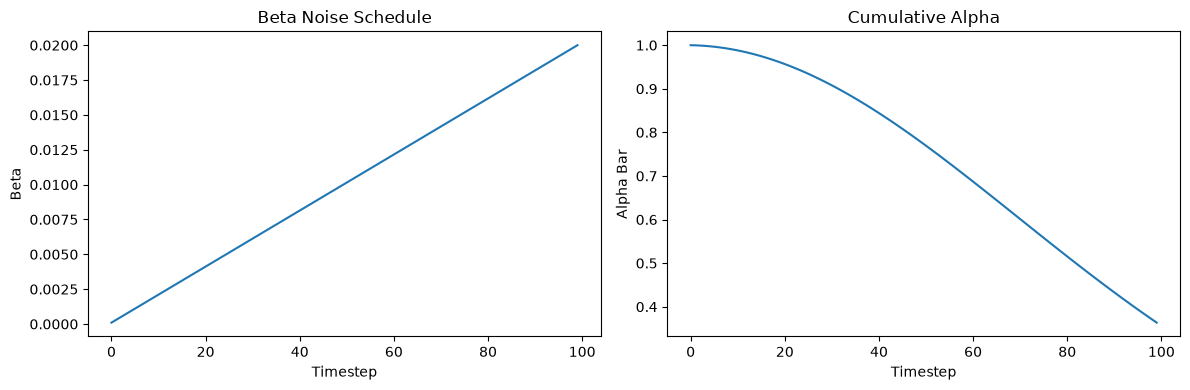

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    betas.detach().cpu().numpy()
)

axes[0].set_title("Beta Noise Schedule")
axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("Beta")

axes[1].plot(
    alpha_bars.detach().cpu().numpy()
)

axes[1].set_title("Cumulative Alpha")
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Alpha Bar")

plt.tight_layout()
plt.show()

## 3.10.6 Direct Sampling of a Noisy Sample

A very important property of diffusion models is that we do not need to simulate every intermediate timestep to obtain $x_t$.

Using:

$$
\bar{\alpha}_t
=
\prod_{s=1}^{t}\alpha_s
$$

we can directly obtain:

$$
q(x_t|x_0)
=
\mathcal{N}
\left(
\sqrt{\bar{\alpha}_t}x_0,
(1-\bar{\alpha}_t)I
\right)
$$

Therefore:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

This equation is one of the most important equations in DDPMs.

In [141]:
def add_noise(x0, t):
    """
    Directly generate x_t from x_0.
    """

    noise = torch.randn_like(x0)

    alpha_bar_t = alpha_bars[t]

    alpha_bar_t = alpha_bar_t.view(
        -1, 1
    )

    noisy_x = (
        torch.sqrt(alpha_bar_t) * x0
        +
        torch.sqrt(1 - alpha_bar_t) * noise
    )

    return noisy_x, noise

## 3.10.7 Load MNIST for Diffusion

For the diffusion model, we normalize MNIST images to the range:

$$
[-1,1]
$$

This is convenient because the generated samples will also be represented in approximately the same range.

In [142]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

diffusion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

diffusion_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=diffusion_transform
)

diffusion_train_loader = DataLoader(
    diffusion_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training samples:", len(diffusion_train_dataset))

Training samples: 60000


## 3.10.8 Visualize Original MNIST Images

Before adding noise, we first inspect the original samples.

Because the images are normalized to $[-1,1]$, we convert them back to $[0,1]$ for visualization.

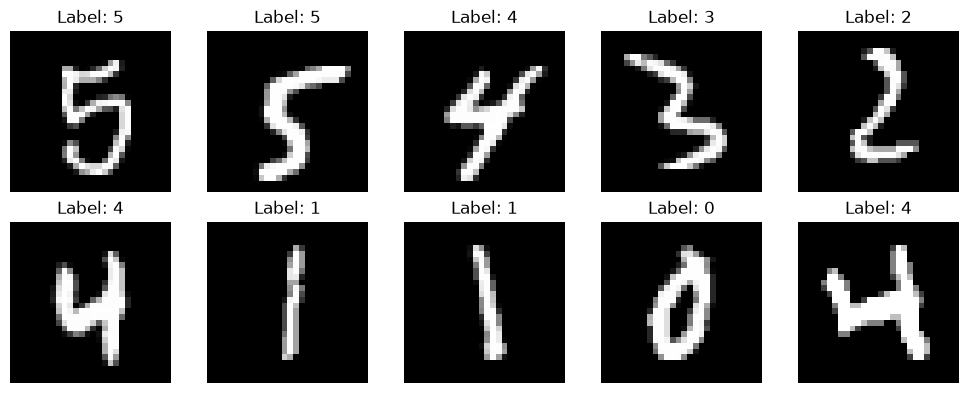

In [143]:
images, labels = next(iter(diffusion_train_loader))

fig, axes = plt.subplots(
    2, 5,
    figsize=(10, 4)
)

for i, ax in enumerate(axes.flat):
    image = images[i].squeeze()

    image = (image + 1) / 2

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.10.9 Visualizing the Forward Diffusion Process

Now we gradually add noise to one MNIST image.

At small timesteps, the image should remain recognizable.

At larger timesteps, the image becomes increasingly noisy.

Eventually, the original structure disappears and the sample approaches Gaussian noise.

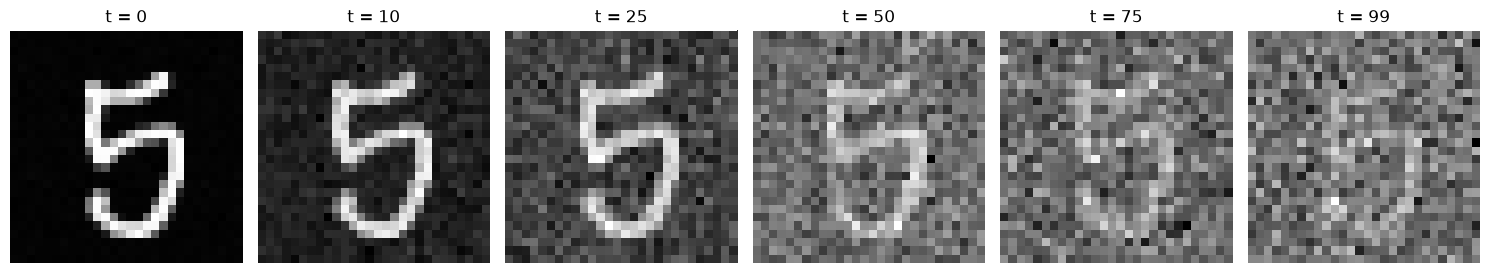

In [144]:
x0 = images[0:1].to(device)

x0 = x0.view(
    x0.size(0),
    -1
)

timesteps_to_show = [
    0,
    10,
    25,
    50,
    75,
    99
]

fig, axes = plt.subplots(
    1,
    len(timesteps_to_show),
    figsize=(15, 3)
)

for ax, timestep in zip(
    axes,
    timesteps_to_show
):

    t = torch.tensor(
        [timestep],
        device=device
    )

    noisy_image, _ = add_noise(
        x0,
        t
    )

    noisy_image = noisy_image.view(
        28,
        28
    )

    noisy_image = (
        noisy_image
        .detach()
        .cpu()
    )

    noisy_image = (
        noisy_image + 1
    ) / 2

    ax.imshow(
        noisy_image,
        cmap="gray"
    )

    ax.set_title(
        f"t = {timestep}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.10.10 Understanding the Forward Process

The forward process can be summarized as:

$$
x_0
\rightarrow
x_{10}
\rightarrow
x_{25}
\rightarrow
x_{50}
\rightarrow
x_{75}
\rightarrow
x_{99}
$$

The image gradually loses information.

At the final timestep:

$$
x_T \approx \mathcal{N}(0,I)
$$

Therefore, the diffusion process transforms the original data distribution into approximately Gaussian noise.

The forward process is **not learned**.

It is completely determined by the chosen noise schedule.

## 3.10.11 Reverse Diffusion Process

The goal of the generative model is to reverse the forward process.

The reverse transition is represented as:

$$
p_\theta(x_{t-1}|x_t)
$$

The neural network learns how to estimate the noise contained in $x_t$.

Conceptually:

$$
x_t
\rightarrow
\text{Denoising Network}
\rightarrow
x_{t-1}
$$

Repeatedly applying this process gives:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_1
\rightarrow
x_0
$$

During generation, we begin with random Gaussian noise and progressively denoise it.

## 3.10.12 What Does the Neural Network Predict?

A common DDPM approach is to train the neural network to predict the noise that was added to the original sample.

The network is written as:

$$
\epsilon_\theta(x_t,t)
$$

It receives:

- the noisy sample $x_t$
- the timestep $t$

and predicts:

$$
\hat{\epsilon}
=
\epsilon_\theta(x_t,t)
$$

During training, we already know the true noise $\epsilon$ because we generated it ourselves.

Therefore, the learning problem becomes:

$$
\epsilon_\theta(x_t,t)
\approx
\epsilon
$$

## 3.10.13 DDPM Training Objective

The simplified diffusion training objective is:

$$
\mathcal{L}_{simple}
=
\mathbb{E}_{t,x_0,\epsilon}
\left[
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|^2
\right]
$$

In practice, this is simply an MSE loss:

$$
\mathcal{L}
=
MSE
\left(
\epsilon,
\epsilon_\theta(x_t,t)
\right)
$$

Therefore, the model learns to predict the noise that was added to the image.

This is the central training idea of a DDPM.

## 3.10.14 Why Does the Model Need the Timestep?

The same noisy image can have very different meanings depending on the timestep.

For example:

- $t=5$ → very little noise
- $t=50$ → significant noise
- $t=99$ → almost pure noise

Therefore, the neural network needs information about the current noise level.

We provide this information using a **timestep embedding**.

## 3.10.15 Sinusoidal Timestep Embedding

We encode the timestep using sinusoidal functions.

For embedding dimension $d$:

$$
PE(t,2i)
=
\sin
\left(
\frac{t}
{10000^{2i/d}}
\right)
$$

and:

$$
PE(t,2i+1)
=
\cos
\left(
\frac{t}
{10000^{2i/d}}
\right)
$$

The resulting vector provides the network with information about the current timestep.

In [145]:
class TimeEmbedding(nn.Module):

    def __init__(self, embedding_dim):
        super().__init__()

        self.embedding_dim = embedding_dim

    def forward(self, t):

        half_dim = self.embedding_dim // 2

        exponent = (
            -torch.log(
                torch.tensor(
                    10000.0,
                    device=t.device
                )
            )
            / (half_dim - 1)
        )

        frequencies = torch.exp(
            torch.arange(
                half_dim,
                device=t.device
            ) * exponent
        )

        angles = (
            t.float().unsqueeze(1)
            * frequencies.unsqueeze(0)
        )

        embedding = torch.cat(
            [
                torch.sin(angles),
                torch.cos(angles)
            ],
            dim=1
        )

        return embedding

## 3.10.16 Lightweight Diffusion Network

For learning purposes, we will build a small MLP-based diffusion model.

The input consists of:

- flattened MNIST image: $784$ values
- timestep embedding: $64$ values

Therefore, the network receives:

$$
784 + 64 = 848
$$

input features.

The network predicts:

$$
784
$$

noise values, one for each image pixel.

In [146]:
class DiffusionMLP(nn.Module):

    def __init__(
        self,
        input_dim=784,
        time_dim=64,
        hidden_dim=512
    ):
        super().__init__()

        self.time_embedding = TimeEmbedding(
            time_dim
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_dim + time_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                input_dim
            )
        )

    def forward(self, x, t):

        time_emb = self.time_embedding(t)

        x = torch.cat(
            [
                x,
                time_emb
            ],
            dim=1
        )

        return self.network(x)

## 3.10.17 Create the Diffusion Model

We now initialize the model and optimizer.

In [147]:
diffusion_model = DiffusionMLP().to(device)

optimizer = torch.optim.Adam(
    diffusion_model.parameters(),
    lr=1e-3
)

print(diffusion_model)

DiffusionMLP(
  (time_embedding): TimeEmbedding()
  (network): Sequential(
    (0): Linear(in_features=848, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
  )
)


## 3.10.18 Diffusion Training Step

For each training batch:

1. Take a clean image $x_0$.
2. Randomly choose a timestep $t$.
3. Generate Gaussian noise $\epsilon$.
4. Construct $x_t$.
5. Give $x_t$ and $t$ to the neural network.
6. Predict the noise.
7. Compare predicted noise with the true noise.
8. Backpropagate the MSE loss.

The complete training relationship is:

$$
x_0
+
\epsilon
+
t
\rightarrow
x_t
\rightarrow
\epsilon_\theta(x_t,t)
$$

Then:

$$
\mathcal{L}
=
MSE
\left(
\epsilon,
\epsilon_\theta(x_t,t)
\right)
$$

In [148]:
def diffusion_training_step(
    model,
    x0,
    optimizer
):

    batch_size = x0.size(0)

    x0 = x0.view(
        batch_size,
        -1
    )

    t = torch.randint(
        0,
        T,
        (batch_size,),
        device=device
    )

    noisy_x, noise = add_noise(
        x0,
        t
    )

    predicted_noise = model(
        noisy_x,
        t
    )

    loss = F.mse_loss(
        predicted_noise,
        noise
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    return loss.item()

## 3.10.19 Train the Diffusion Model

We use a small number of epochs so that the notebook remains practical on a laptop GPU.

The model is learning one fundamental task:

> Given a noisy image and its timestep, predict the noise that corrupted the image.

In [149]:
num_epochs = 5

diffusion_losses = []

for epoch in range(num_epochs):

    diffusion_model.train()

    running_loss = 0.0

    for images, _ in diffusion_train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        loss = diffusion_training_step(
            diffusion_model,
            images,
            optimizer
        )

        running_loss += loss

    epoch_loss = (
        running_loss
        / len(diffusion_train_loader)
    )

    diffusion_losses.append(
        epoch_loss
    )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.9410


KeyboardInterrupt: 

## 3.10.20 Diffusion Training Loss

We visualize the MSE loss during training.

A decreasing loss indicates that the model is becoming better at predicting the noise added to the images.

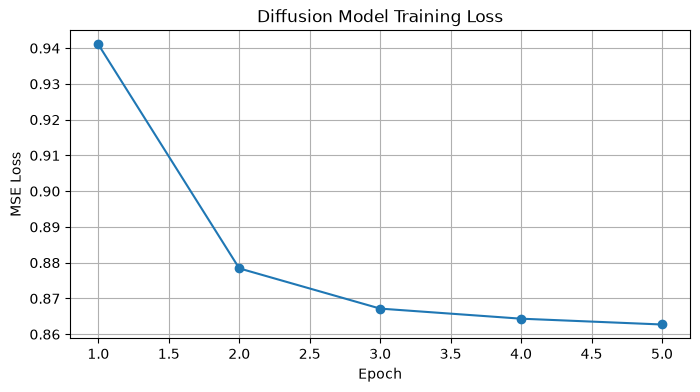

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, num_epochs + 1),
    diffusion_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Diffusion Model Training Loss")

plt.grid(True)
plt.show()

## 3.10.21 Testing Noise Prediction

Before implementing the complete reverse sampling process, we can check whether the model has learned to predict noise.

We:

1. Select an MNIST image.
2. Add noise at a selected timestep.
3. Ask the model to predict that noise.
4. Compare the actual and predicted noise.

In [ ]:
diffusion_model.eval()

images, _ = next(iter(diffusion_train_loader))

x0 = images[:1].to(device)

x0 = x0.view(
    1,
    -1
)

t = torch.tensor(
    [50],
    device=device
)

noisy_x, true_noise = add_noise(
    x0,
    t
)

with torch.no_grad():

    predicted_noise = diffusion_model(
        noisy_x,
        t
    )

print(
    "True noise shape:",
    true_noise.shape
)

print(
    "Predicted noise shape:",
    predicted_noise.shape
)

True noise shape: torch.Size([1, 784])
Predicted noise shape: torch.Size([1, 784])


## 3.10.22 Visualizing Actual vs Predicted Noise

The model does not directly predict a clean image.

Instead, it predicts the noise contained in the noisy image.

Therefore, we visualize:

- original image
- noisy image
- actual noise
- predicted noise

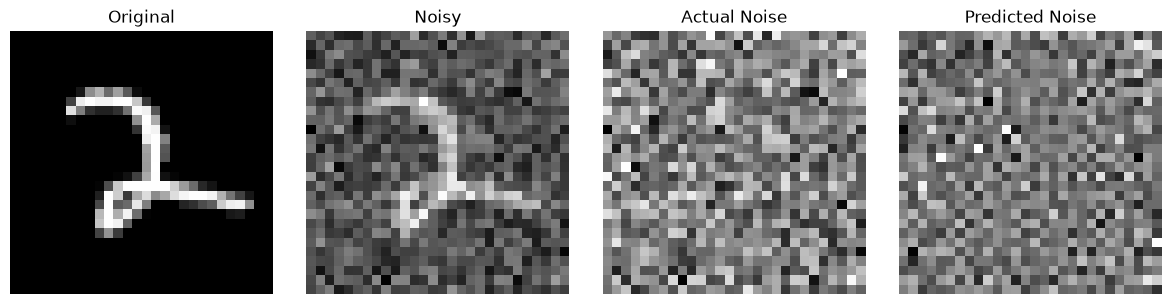

In [ ]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 3)
)

original = x0.view(28, 28)
noisy = noisy_x.view(28, 28)
actual = true_noise.view(28, 28)
predicted = predicted_noise.view(28, 28)

axes[0].imshow(
    ((original.detach().cpu()) + 1) / 2,
    cmap="gray"
)

axes[0].set_title("Original")

axes[1].imshow(
    ((noisy.detach().cpu()) + 1) / 2,
    cmap="gray"
)

axes[1].set_title("Noisy")

axes[2].imshow(
    actual.detach().cpu(),
    cmap="gray"
)

axes[2].set_title("Actual Noise")

axes[3].imshow(
    predicted.detach().cpu(),
    cmap="gray"
)

axes[3].set_title("Predicted Noise")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.10.23 Reverse Diffusion Equation

Once the network predicts the noise, we can use that prediction to estimate the previous state.

For the common DDPM parameterization, the reverse mean can be written as:

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}
{\sqrt{1-\bar{\alpha}_t}}
\epsilon_\theta(x_t,t)
\right)
$$

The reverse process is then:

$$
p_\theta(x_{t-1}|x_t)
=
\mathcal{N}
\left(
\mu_\theta(x_t,t),
\sigma_t^2 I
\right)
$$

Thus, the predicted noise is used to estimate a less noisy sample.

## 3.10.24 Reverse Sampling

Generation starts from random Gaussian noise:

$$
x_T \sim \mathcal{N}(0,I)
$$

Then we repeatedly apply the learned reverse process:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
x_{T-2}
\rightarrow
\cdots
\rightarrow
x_0
$$

The final $x_0$ is the generated image.

This is the key difference between training and generation:

### Training

$$
x_0 \rightarrow x_t
$$

and learn to predict the noise.

### Generation

$$
x_T \rightarrow x_0
$$

using the learned noise predictor.

In [ ]:
@torch.no_grad()
def sample_diffusion(
    model,
    num_samples=16
):

    model.eval()

    x = torch.randn(
        num_samples,
        784,
        device=device
    )

    for timestep in reversed(
        range(T)
    ):

        t = torch.full(
            (num_samples,),
            timestep,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            t
        )

        beta_t = betas[timestep]
        alpha_t = alphas[timestep]
        alpha_bar_t = alpha_bars[timestep]

        mean = (
            1 / torch.sqrt(alpha_t)
        ) * (
            x
            -
            (
                beta_t
                / torch.sqrt(
                    1 - alpha_bar_t
                )
            )
            * predicted_noise
        )

        if timestep > 0:

            noise = torch.randn_like(x)

            x = (
                mean
                +
                torch.sqrt(beta_t)
                * noise
            )

        else:

            x = mean

    return x

## 3.10.25 Generate New MNIST Images

We now start from random Gaussian noise and perform the reverse diffusion process.

The model should gradually transform the random noise into digit-like structures.

In [ ]:
generated_images = sample_diffusion(
    diffusion_model,
    num_samples=16
)

generated_images = generated_images.view(
    -1,
    28,
    28
)

generated_images = (
    generated_images + 1
) / 2

generated_images = (
    generated_images
    .clamp(0, 1)
    .cpu()
)

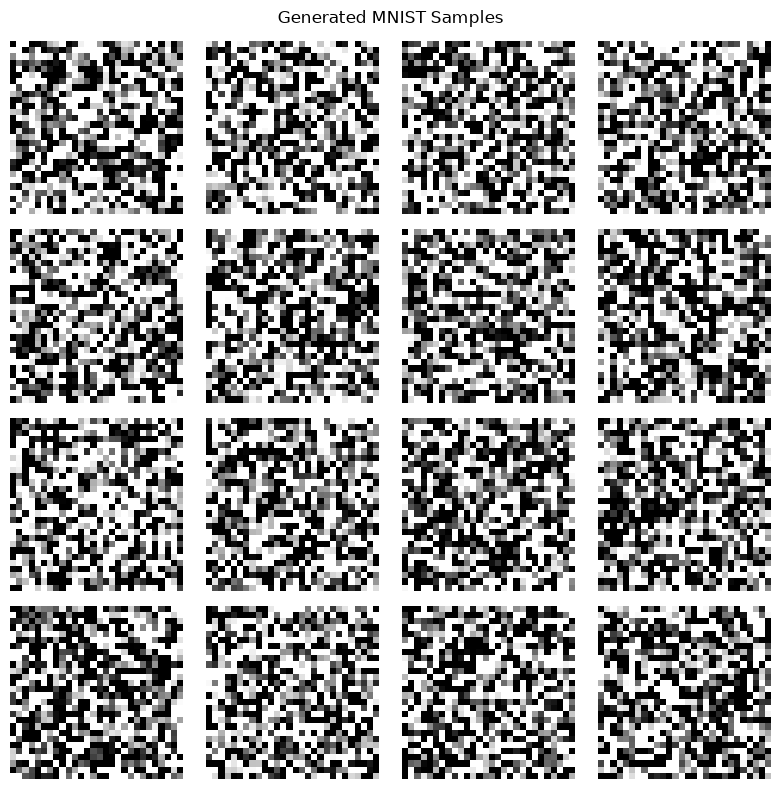

In [ ]:
fig, axes = plt.subplots(
    4,
    4,
    figsize=(8, 8)
)

for i, ax in enumerate(
    axes.flat
):

    ax.imshow(
        generated_images[i],
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle(
    "Generated MNIST Samples"
)

plt.tight_layout()
plt.show()

## 3.10.26 Understanding the Complete Diffusion Pipeline

The complete diffusion learning process is:

### Training

$$
x_0
\rightarrow
x_t
$$

by adding known Gaussian noise.

Then:

$$
(x_t,t)
\rightarrow
\epsilon_\theta(x_t,t)
$$

The predicted noise is compared with the actual noise:

$$
\mathcal{L}
=
\left\|
\epsilon
-
\epsilon_\theta(x_t,t)
\right\|^2
$$

### Generation

Start with:

$$
x_T \sim \mathcal{N}(0,I)
$$

Then repeatedly denoise:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

The resulting $x_0$ is the generated sample.

## 3.10.27 Diffusion Models vs VAE vs GAN vs Autoregressive Models

| Model | Main Idea | Generation Process | Major Strength |
|---|---|---|---|
| VAE | Learn probabilistic latent representation | Sample latent variable → decode | Smooth latent space |
| GAN | Generator competes with discriminator | Latent vector → generator | Sharp samples |
| Autoregressive | Factorize probability | Generate elements sequentially | Exact likelihood |
| Diffusion | Learn to reverse noise process | Noise → iterative denoising | High-quality generation |

Diffusion models usually require many denoising steps during generation, while GANs can generate a sample in a single forward pass.

Autoregressive models generate sequentially, whereas diffusion models generate through iterative denoising.

## 3.10.28 Advantages of Diffusion Models

### 1. High-Quality Generation

Diffusion models can produce high-quality generated samples.

### 2. Stable Training

Compared with traditional GAN training, diffusion training is generally easier to formulate as a supervised noise-prediction problem.

### 3. Flexible Conditioning

Diffusion models can be conditioned on additional information such as:

- class labels
- text
- images
- semantic information

### 4. Strong Representation of Complex Distributions

The iterative denoising process allows the model to represent complicated data distributions.

### 5. Simple Training Objective

The basic DDPM objective can be expressed using MSE:

$$
\mathcal{L}
=
\mathbb{E}
\left[
\|\epsilon-\epsilon_\theta(x_t,t)\|^2
\right]
$$

## 3.10.29 Limitations of Diffusion Models

### 1. Slow Generation

Generation can require many denoising steps.

### 2. Computational Cost

Large diffusion models can require substantial GPU memory and computational resources.

### 3. Training Cost

High-quality diffusion models often require large datasets and long training times.

### 4. Sampling Complexity

The reverse process involves repeatedly applying the neural network.

### 5. Noise Schedule Matters

The choice of $\beta_t$ and the number of timesteps can significantly affect training and generation.

## 3.10.30 Important Diffusion Model Terminology

| Term | Meaning |
|---|---|
| Forward Process | Gradually adds noise |
| Reverse Process | Gradually removes noise |
| $\beta_t$ | Noise variance at timestep $t$ |
| $\alpha_t$ | $1-\beta_t$ |
| $\bar{\alpha}_t$ | Product of $\alpha$ values up to timestep $t$ |
| $x_0$ | Original clean sample |
| $x_t$ | Noisy sample at timestep $t$ |
| $x_T$ | Final approximately Gaussian-noise sample |
| $\epsilon$ | Actual Gaussian noise |
| $\epsilon_\theta$ | Neural network's predicted noise |
| DDPM | Denoising Diffusion Probabilistic Model |
| Noise Schedule | Sequence controlling the noise level |
| Timestep Embedding | Representation of the current diffusion timestep |

## 3.10.31 Key Equations for Exams

### Forward transition

$$
q(x_t|x_{t-1})
=
\mathcal{N}
\left(
\sqrt{1-\beta_t}x_{t-1},
\beta_t I
\right)
$$

### Alpha

$$
\alpha_t = 1-\beta_t
$$

### Cumulative alpha

$$
\bar{\alpha}_t
=
\prod_{s=1}^{t}\alpha_s
$$

### Direct noisy sample

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

where:

$$
\epsilon\sim\mathcal{N}(0,I)
$$

### Noise prediction

$$
\epsilon_\theta(x_t,t)
$$

### DDPM simplified objective

$$
\mathcal{L}_{simple}
=
\mathbb{E}
\left[
\|\epsilon-\epsilon_\theta(x_t,t)\|^2
\right]
$$

### Reverse mean

$$
\mu_\theta(x_t,t)
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t
-
\frac{\beta_t}
{\sqrt{1-\bar{\alpha}_t}}
\epsilon_\theta(x_t,t)
\right)
$$

## 3.10.32 Exam Summary — Diffusion Models

A diffusion model learns to generate data by reversing a gradual noise-adding process.

The forward process gradually transforms:

$$
x_0 \rightarrow x_T
$$

where $x_T$ is approximately Gaussian noise.

The forward process uses a noise schedule $\beta_t$.

The cumulative noise relationship is:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

A neural network receives the noisy sample and timestep:

$$
\epsilon_\theta(x_t,t)
$$

and predicts the noise.

The model is trained using:

$$
\mathcal{L}
=
\mathbb{E}
\left[
\|\epsilon-\epsilon_\theta(x_t,t)\|^2
\right]
$$

During generation, the model starts from:

$$
x_T\sim\mathcal{N}(0,I)
$$

and repeatedly removes predicted noise:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

The final $x_0$ is the generated sample.

### Most Important Concept

> Diffusion models learn to reverse a gradual noising process by predicting the noise present at each timestep.

# 3.11 Conditional Generative Models

Conditional Generative Models extend generative models by allowing us to control the type of sample that is generated.

An unconditional generative model learns:

$$
p(x)
$$

A conditional generative model learns:

$$
p(x|c)
$$

where:

- $x$ = generated sample
- $c$ = conditioning information

The conditioning information can be:

- class labels
- text
- another image
- attributes
- semantic information
- other useful context

For example, instead of asking a model to generate any MNIST digit, we can specify:

$$
c = 7
$$

and ask it to generate a digit belonging to class 7.

## 3.11.1 Unconditional vs Conditional Generation

### Unconditional Generation

The model generates a sample without receiving additional information.

$$
z \rightarrow G(z) \rightarrow x
$$

For example:

$$
z \rightarrow \text{random MNIST digit}
$$

The model decides which digit to generate.

### Conditional Generation

The model receives both a latent variable and a condition.

$$
(z,c) \rightarrow G(z,c) \rightarrow x
$$

For example:

$$
(z,7) \rightarrow G(z,7) \rightarrow \text{digit 7}
$$

Therefore, conditional generation gives us greater control over the generated output.

## 3.11.2 Conditional Probability

The mathematical foundation is conditional probability.

Instead of modeling:

$$
p(x)
$$

we model:

$$
p(x|c)
$$

For example:

$$
p(\text{image}|\text{class}=7)
$$

means:

> Probability of an image given that the required class is 7.

The model therefore learns a different conditional distribution for different conditions.

## 3.11.3 Why Conditional Generation Is Useful

Suppose an unconditional MNIST generator produces:

$$
0,\;3,\;7,\;1,\;8,\ldots
$$

We have little control over which digit appears.

With conditional generation, we can specify:

$$
c=3
$$

and generate:

$$
3,\;3,\;3,\;3,\ldots
$$

while allowing the model to produce different styles of the same class.

This gives us:

- controllability
- class-specific generation
- attribute control
- targeted synthesis
- guided generation

## 3.11.4 Conditional GAN

A Conditional GAN (cGAN) extends the standard GAN by providing the condition to both the Generator and the Discriminator.

The Generator receives:

$$
G(z,c)
$$

The Discriminator receives:

$$
D(x,c)
$$

The complete architecture is:

$$
(z,c)
\rightarrow
G
\rightarrow
\text{Generated Sample}
$$

and:

$$
(x,c)
\rightarrow
D
\rightarrow
\text{Real/Fake}
$$

The condition helps the Generator produce samples corresponding to the requested class.

## 3.11.5 Conditional GAN Objective

The standard GAN objective is extended by including the condition:

$$
\min_G \max_D
V(D,G)
=
\mathbb{E}_{x,c\sim p_{data}}
[\log D(x,c)]
+
\mathbb{E}_{z,c}
[
\log(1-D(G(z,c),c))
]
$$

The Discriminator must determine whether a sample is real or fake while also considering whether it matches the supplied condition.

Therefore, a generated image of digit 7 paired with condition 3 should ideally be recognized as inconsistent with the condition.

## 3.11.6 Conditional GAN Architecture for MNIST

For MNIST:

- latent vector $z$ → random variation
- class label $c$ → desired digit
- Generator → generated image
- Discriminator → evaluates image and class condition

The Generator learns:

$$
G(z,c)
$$

The Discriminator learns:

$$
D(x,c)
$$

We will represent the class label using an embedding layer.

In [ ]:
class ConditionalGenerator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=10,
        embedding_dim=10
    ):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.network = nn.Sequential(
            nn.Linear(
                latent_dim + embedding_dim,
                256
            ),
            nn.ReLU(),

            nn.Linear(
                256,
                512
            ),
            nn.ReLU(),

            nn.Linear(
                512,
                784
            ),
            nn.Tanh()
        )

    def forward(self, z, labels):

        label_embedding = self.label_embedding(
            labels
        )

        x = torch.cat(
            [z, label_embedding],
            dim=1
        )

        return self.network(x)

## 3.11.7 Conditional Discriminator

The Discriminator also receives the class label.

It must evaluate:

$$
D(x,c)
$$

rather than only:

$$
D(x)
$$

This allows the Discriminator to learn whether the image matches the requested class.

In [ ]:
class ConditionalDiscriminator(nn.Module):

    def __init__(
        self,
        input_dim=784,
        num_classes=10,
        embedding_dim=10
    ):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_dim + embedding_dim,
                512
            ),
            nn.LeakyReLU(0.2),

            nn.Linear(
                512,
                256
            ),
            nn.LeakyReLU(0.2),

            nn.Linear(
                256,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, x, labels):

        label_embedding = self.label_embedding(
            labels
        )

        x = torch.cat(
            [x, label_embedding],
            dim=1
        )

        return self.network(x)

## 3.11.8 Create the Conditional GAN

We now initialize the Generator and Discriminator.

Both networks receive information about the desired digit.

In [ ]:
cgan_generator = ConditionalGenerator().to(device)

cgan_discriminator = ConditionalDiscriminator().to(device)

criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(
    cgan_generator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

d_optimizer = torch.optim.Adam(
    cgan_discriminator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

print("Conditional Generator:")
print(cgan_generator)

print("\nConditional Discriminator:")
print(cgan_discriminator)

Conditional Generator:
ConditionalGenerator(
  (label_embedding): Embedding(10, 10)
  (network): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Conditional Discriminator:
ConditionalDiscriminator(
  (label_embedding): Embedding(10, 10)
  (network): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## 3.11.9 Conditional GAN Training

For every training iteration, we perform two optimization steps.

### Discriminator

The Discriminator should classify:

$$
D(x_{real},c) \rightarrow 1
$$

and:

$$
D(G(z,c),c) \rightarrow 0
$$

Its loss is:

$$
\mathcal{L}_D
=
BCE(D(x_{real},c),1)
+
BCE(D(G(z,c),c),0)
$$

### Generator

The Generator wants:

$$
D(G(z,c),c) \rightarrow 1
$$

Therefore:

$$
\mathcal{L}_G
=
BCE(D(G(z,c),c),1)
$$

In [ ]:
def train_cgan_step(
    real_images,
    real_labels
):

    batch_size = real_images.size(0)

    real_images = real_images.view(
        batch_size,
        -1
    ).to(device)

    real_labels = real_labels.to(device)

    real_targets = torch.ones(
        batch_size,
        1,
        device=device
    )

    fake_targets = torch.zeros(
        batch_size,
        1,
        device=device
    )

    # -------------------------
    # Train Discriminator
    # -------------------------

    z = torch.randn(
        batch_size,
        100,
        device=device
    )

    fake_labels = torch.randint(
        0,
        10,
        (batch_size,),
        device=device
    )

    fake_images = cgan_generator(
        z,
        fake_labels
    )

    real_output = cgan_discriminator(
        real_images,
        real_labels
    )

    fake_output = cgan_discriminator(
        fake_images.detach(),
        fake_labels
    )

    d_loss_real = criterion(
        real_output,
        real_targets
    )

    d_loss_fake = criterion(
        fake_output,
        fake_targets
    )

    d_loss = (
        d_loss_real
        +
        d_loss_fake
    )

    d_optimizer.zero_grad()

    d_loss.backward()

    d_optimizer.step()

    # -------------------------
    # Train Generator
    # -------------------------

    z = torch.randn(
        batch_size,
        100,
        device=device
    )

    requested_labels = torch.randint(
        0,
        10,
        (batch_size,),
        device=device
    )

    generated_images = cgan_generator(
        z,
        requested_labels
    )

    discriminator_output = cgan_discriminator(
        generated_images,
        requested_labels
    )

    g_loss = criterion(
        discriminator_output,
        real_targets
    )

    g_optimizer.zero_grad()

    g_loss.backward()

    g_optimizer.step()

    return (
        d_loss.item(),
        g_loss.item()
    )

## 3.11.10 Train the Conditional GAN

We train the model on MNIST.

The objective is not only to generate realistic digits.

The Generator must learn:

$$
G(z,c)
\approx
\text{realistic sample belonging to class }c
$$

For example:

$$
G(z,2) \rightarrow \text{digit 2}
$$

$$
G(z,8) \rightarrow \text{digit 8}
$$

In [ ]:
cgan_losses_g = []
cgan_losses_d = []

cgan_epochs = 5

for epoch in range(cgan_epochs):

    epoch_d_loss = 0.0
    epoch_g_loss = 0.0

    for images, labels in diffusion_train_loader:

        d_loss, g_loss = train_cgan_step(
            images,
            labels
        )

        epoch_d_loss += d_loss
        epoch_g_loss += g_loss

    epoch_d_loss /= len(
        diffusion_train_loader
    )

    epoch_g_loss /= len(
        diffusion_train_loader
    )

    cgan_losses_d.append(
        epoch_d_loss
    )

    cgan_losses_g.append(
        epoch_g_loss
    )

    print(
        f"Epoch [{epoch + 1}/{cgan_epochs}] "
        f"D Loss: {epoch_d_loss:.4f} | "
        f"G Loss: {epoch_g_loss:.4f}"
    )

Epoch [1/5] D Loss: 0.7778 | G Loss: 2.0398
Epoch [2/5] D Loss: 0.3377 | G Loss: 3.8599
Epoch [3/5] D Loss: 0.3323 | G Loss: 4.0215
Epoch [4/5] D Loss: 0.2521 | G Loss: 4.2132
Epoch [5/5] D Loss: 0.2949 | G Loss: 4.3521


## 3.11.11 Visualizing Conditional Generation

Now we explicitly request every digit from 0 to 9.

We keep the conditions fixed:

$$
0,1,2,\ldots,9
$$

while using random latent vectors.

This demonstrates the main advantage of conditional generation:

> We control the semantic class of the generated sample.

In [ ]:
cgan_generator.eval()

requested_labels = torch.arange(
    10,
    device=device
)

z = torch.randn(
    10,
    100,
    device=device
)

with torch.no_grad():

    generated_digits = cgan_generator(
        z,
        requested_labels
    )

generated_digits = generated_digits.view(
    -1,
    28,
    28
)

generated_digits = (
    generated_digits + 1
) / 2

generated_digits = generated_digits.clamp(
    0,
    1
).cpu()

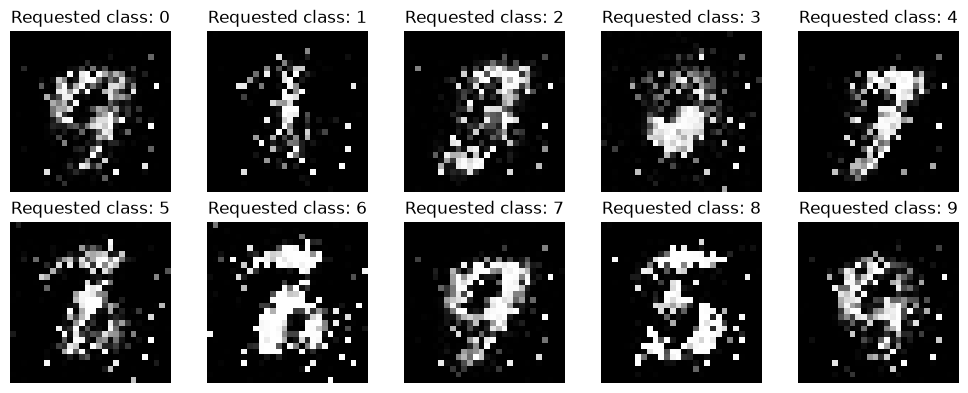

In [ ]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 4)
)

for i, ax in enumerate(
    axes.flat
):

    ax.imshow(
        generated_digits[i],
        cmap="gray"
    )

    ax.set_title(
        f"Requested class: {i}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.11.12 Conditional VAE

Conditional generation is not limited to GANs.

A VAE can also be conditioned on additional information.

A Conditional VAE is commonly written as:

$$
q_\phi(z|x,c)
$$

for the encoder and:

$$
p_\theta(x|z,c)
$$

for the decoder.

The condition $c$ is supplied to both parts of the model.

The generation process becomes:

$$
(z,c)
\rightarrow
Decoder
\rightarrow
x
$$

For MNIST:

$$
(z,7)
\rightarrow
Decoder
\rightarrow
\text{digit 7}
$$

This gives us controlled generation while retaining the probabilistic latent-space properties of the VAE.

## 3.11.13 Conditional Diffusion Models

Diffusion models can also be conditioned.

Instead of predicting:

$$
\epsilon_\theta(x_t,t)
$$

we can predict:

$$
\epsilon_\theta(x_t,t,c)
$$

where $c$ is the condition.

For class-conditional image generation:

$$
(x_t,t,\text{class})
\rightarrow
\epsilon_\theta
$$

The condition tells the model what kind of image should be produced.

For example:

$$
(x_t,t,7)
\rightarrow
\epsilon_\theta(x_t,t,7)
$$

The denoising process can therefore be guided toward generating a digit 7.

The same principle can be extended to much more complex conditions such as text or another image.

## 3.11.14 Class Conditioning vs Unconditional Generation

| Property | Unconditional | Conditional |
|---|---|---|
| Distribution | $p(x)$ | $p(x|c)$ |
| Control | Low | High |
| Input condition | No | Yes |
| Class-specific generation | Limited | Yes |
| Attribute control | Limited | Possible |
| Example | Any MNIST digit | Requested MNIST digit |

Conditional models are particularly useful when we need control over the generated output rather than simply realistic samples.

## 3.11.15 Important Applications

Conditional generative models are useful for:

- class-controlled image generation
- text-to-image generation
- image-to-image translation
- style-controlled generation
- data augmentation
- synthetic data generation
- image editing
- personalized generation
- controlled scientific data generation

The general principle is:

$$
\text{Randomness}
+
\text{Condition}
\rightarrow
\text{Controlled Generation}
$$

## 3.11.16 Exam Summary — Conditional Generative Models

A conditional generative model learns a conditional distribution:

$$
p(x|c)
$$

instead of only:

$$
p(x)
$$

The condition $c$ can represent class labels, text, attributes, images, or other information.

In a Conditional GAN:

$$
G(z,c)
$$

generates a sample based on the condition, while:

$$
D(x,c)
$$

evaluates whether the sample is both realistic and consistent with the condition.

The Generator objective is:

$$
\mathcal{L}_G
=
BCE(D(G(z,c),c),1)
$$

The Discriminator objective is:

$$
\mathcal{L}_D
=
BCE(D(x,c),1)
+
BCE(D(G(z,c),c),0)
$$

Conditional VAEs use:

$$
q_\phi(z|x,c)
$$

and:

$$
p_\theta(x|z,c)
$$

Conditional diffusion models use:

$$
\epsilon_\theta(x_t,t,c)
$$

The most important idea is:

> Conditional generative models learn to generate samples according to specified information, giving us control over the generated output.

# 3.12 Modern Generative Deep Learning

Generative Deep Learning has evolved from relatively simple models such as Autoencoders and GANs into highly controllable and scalable architectures.

The major generative approaches studied so far are:

1. Autoencoders
2. Variational Autoencoders (VAEs)
3. Generative Adversarial Networks (GANs)
4. Autoregressive Models
5. Diffusion Models
6. Conditional Generative Models

Modern generative systems often combine these ideas with:

- deep neural networks
- attention mechanisms
- Transformer architectures
- conditioning
- latent representations
- guidance mechanisms
- large-scale datasets

The goal is no longer only to generate realistic samples.

Modern generative models aim to provide:

$$
\text{Quality}
+
\text{Diversity}
+
\text{Controllability}
+
\text{Scalability}
$$

## 3.12.1 From Traditional Generative Models to Modern Generative AI

The development of generative deep learning can be viewed as a progression.

### Autoencoders

Learn to reconstruct:

$$
x \rightarrow z \rightarrow \hat{x}
$$

### VAEs

Learn a probabilistic latent representation:

$$
x \rightarrow q_\phi(z|x) \rightarrow p_\theta(x|z)
$$

### GANs

Learn generation through adversarial competition:

$$
G(z) \leftrightarrow D(x)
$$

### Autoregressive Models

Factorize the data distribution:

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

### Diffusion Models

Learn to reverse a gradual noising process:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

Modern generative AI builds upon these fundamental ideas while introducing stronger architectures and conditioning mechanisms.

## 3.12.2 Latent Diffusion

Standard diffusion models operate directly in the data space.

For an image:

$$
x \in \mathbb{R}^{H\times W\times C}
$$

This can be computationally expensive.

Latent diffusion instead first converts the image into a lower-dimensional latent representation:

$$
x
\rightarrow
z
$$

Diffusion is then performed in latent space:

$$
z_0
\rightarrow
z_1
\rightarrow
\cdots
\rightarrow
z_T
$$

Finally, a decoder converts the generated latent representation back into an image:

$$
z
\rightarrow
\hat{x}
$$

Therefore:

$$
x
\rightarrow
Encoder
\rightarrow
z
\rightarrow
Diffusion
\rightarrow
z'
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

The main advantage is reduced computational cost.

Instead of performing diffusion on high-dimensional images, we perform it on a smaller latent representation.

## 3.12.3 Why Latent Diffusion Is Efficient

Suppose an image has:

$$
512 \times 512 \times 3
$$

values.

The diffusion model would need to process a large high-dimensional representation.

If an encoder compresses the image into a much smaller latent space, diffusion operates on:

$$
z \in \mathbb{R}^{h\times w\times c}
$$

where:

$$
h < H
$$

and:

$$
w < W
$$

This significantly reduces the computational requirements.

The decoder then reconstructs the image from the generated latent representation.

This gives the general strategy:

> Compress first, perform generative modeling in latent space, then decode.

## 3.12.4 Attention in Generative Models

Attention allows a neural network to determine which parts of the input are important when generating an output.

The basic scaled dot-product attention mechanism is:

$$
Attention(Q,K,V)
=
softmax
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$

where:

- $Q$ = queries
- $K$ = keys
- $V$ = values
- $d_k$ = dimension of the key vectors

Attention is useful because different parts of the data can interact with each other.

For images, this can help model relationships between distant image regions.

For text, attention allows the model to relate different words or tokens.

Modern generative architectures frequently use attention to improve contextual modeling.

## 3.12.5 Transformers and Generative Modeling

Transformers use self-attention to model relationships between elements of a sequence.

For autoregressive generation, the model predicts the next element:

$$
p(x_i|x_1,\ldots,x_{i-1})
$$

For example, in language generation:

$$
\text{"Deep learning is"}
\rightarrow
\text{"powerful"}
$$

The model repeatedly predicts the next token.

The overall probability is:

$$
p(x)
=
\prod_{i=1}^{n}
p(x_i|x_1,\ldots,x_{i-1})
$$

This makes Transformers particularly important for modern autoregressive generative models.

## 3.12.6 Conditioning in Modern Generative Models

Modern generative models often use conditioning information.

The general objective becomes:

$$
p(x|c)
$$

where $c$ can represent:

- text
- class labels
- another image
- an attribute
- a semantic representation

For example:

$$
\text{text}
\rightarrow
\text{conditioning representation}
\rightarrow
\text{generative model}
\rightarrow
\text{image}
$$

This allows generation to be controlled by the user.

Therefore, modern generative AI is not simply:

$$
\text{noise} \rightarrow \text{sample}
$$

but often:

$$
\text{condition} + \text{noise}
\rightarrow
\text{controlled sample}
$$

## 3.12.7 Classifier-Free Guidance

Diffusion models can use conditioning to guide generation.

Suppose the model predicts noise using:

$$
\epsilon_\theta(x_t,t,c)
$$

where $c$ is the condition.

We can also obtain an unconditional prediction:

$$
\epsilon_\theta(x_t,t,\varnothing)
$$

A commonly used guidance formulation is:

$$
\epsilon_{guided}
=
\epsilon_{uncond}
+
s
\left(
\epsilon_{cond}
-
\epsilon_{uncond}
\right)
$$

where $s$ is the guidance scale.

A larger guidance scale generally pushes the generation more strongly toward the requested condition, although excessive guidance can reduce diversity or introduce artifacts.

The important concept is:

> Guidance modifies the denoising direction so that generated samples better follow the desired condition.

## 3.12.8 Text-to-Image Generation

One important application of conditional generative modeling is text-to-image generation.

The conceptual pipeline is:

$$
\text{Text}
\rightarrow
\text{Text Encoder}
\rightarrow
\text{Condition}
$$

and:

$$
\text{Noise}
+
\text{Condition}
\rightarrow
\text{Diffusion Model}
\rightarrow
\text{Image}
$$

The text encoder converts the input text into a representation that can be used to condition the generative model.

For example:

$$
\text{"A cat sitting on a chair"}
$$

is converted into a learned representation that guides the image-generation process.

## 3.12.9 Image-to-Image Generation

Generative models can also transform one image into another.

The general idea is:

$$
x_{source}
+
c
\rightarrow
x_{generated}
$$

Examples include:

- image restoration
- image editing
- style transformation
- super-resolution
- semantic image transformation

Instead of generating completely unrelated data, the model uses an existing image as part of the generation process.

## 3.12.10 Generative Model Sampling

Training and sampling are different processes.

### Training

The model learns parameters:

$$
\theta
$$

by minimizing an objective:

$$
\theta^*
=
\arg\min_\theta
\mathcal{L}(\theta)
$$

### Sampling

After training, the learned model is used to produce new samples.

For example, a diffusion model starts with:

$$
x_T\sim\mathcal{N}(0,I)
$$

and repeatedly applies the learned reverse process.

Sampling therefore uses the learned probability distribution rather than the original training examples directly.

## 3.12.11 Temperature in Generative Sampling

Some generative models allow a temperature parameter to control randomness.

Conceptually:

- lower temperature → more deterministic generation
- higher temperature → more randomness

For a categorical probability distribution, temperature can modify logits:

$$
p_i
=
\frac{
\exp(z_i/T)
}{
\sum_j \exp(z_j/T)
}
$$

where $T$ is the temperature.

When:

$$
T < 1
$$

the distribution becomes sharper.

When:

$$
T > 1
$$

the distribution becomes flatter.

Temperature is particularly important in autoregressive generation.

## 3.12.12 Quality vs Diversity

A good generative model should produce:

### High Quality

Generated samples should look realistic.

### High Diversity

Generated samples should not all look identical.

These objectives can conflict.

For example, a model that generates only one highly realistic digit may have high sample quality but poor diversity.

Therefore, generative models should ideally learn:

$$
\text{Realism}
+
\text{Diversity}
$$

This is one reason why mode collapse is a serious problem in GANs.

Diffusion models and other modern generative approaches are designed to model complex distributions while maintaining high-quality and diverse generation.

## 3.12.13 Evaluating Generative Models

Evaluating generative models is more difficult than evaluating ordinary classifiers.

A classifier can often be evaluated using:

- accuracy
- precision
- recall
- F1-score

For generative models, we care about:

- sample quality
- diversity
- distribution similarity
- realism
- conditioning accuracy

Common evaluation approaches include:

### Inception Score

Measures aspects of sample quality and diversity.

### Fréchet Inception Distance

Compares feature distributions between real and generated samples.

### Reconstruction Error

Useful for models such as autoencoders and VAEs.

### Negative Log-Likelihood

Useful for probabilistic models where likelihood is tractable.

No single metric completely describes generative quality.

## 3.12.14 Practical Generative Deep Learning Pipeline

A general generative deep learning project can follow this pipeline:

$$
\text{Dataset}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Model}
\rightarrow
\text{Training}
\rightarrow
\text{Sampling}
\rightarrow
\text{Evaluation}
$$

For conditional generation:

$$
\text{Dataset}
+
\text{Condition}
\rightarrow
\text{Conditional Model}
\rightarrow
\text{Controlled Samples}
$$

Important practical considerations include:

1. Data normalization
2. Model architecture
3. Loss function
4. Optimizer
5. Learning rate
6. Batch size
7. Number of training steps
8. Sampling strategy
9. Evaluation metrics
10. Visualization of generated samples

## 3.12.15 Comparison of Major Generative Architectures

| Model | Core Idea | Training Objective | Sampling |
|---|---|---|---|
| Autoencoder | Reconstruction | Reconstruction loss | Decode latent representation |
| VAE | Probabilistic latent space | Reconstruction + KL | Sample latent variable |
| GAN | Adversarial learning | Generator + Discriminator losses | Usually one forward pass |
| Autoregressive | Probability factorization | Maximum likelihood | Sequential |
| Diffusion | Iterative denoising | Noise prediction | Iterative denoising |
| Conditional Model | Controlled generation | Depends on base model | Condition-guided |
| Latent Diffusion | Diffusion in compressed space | Denoising objective | Latent denoising + decoding |

Each architecture makes a different trade-off between:

$$
\text{Quality}
,\quad
\text{Diversity}
,\quad
\text{Speed}
,\quad
\text{Control}
,\quad
\text{Computational Cost}
$$

## 3.12.16 Generative Deep Learning: Conceptual Map

The major concepts can be organized as follows:

### Reconstruction-Based

$$
x
\rightarrow
z
\rightarrow
\hat{x}
$$

**Autoencoder**

### Probabilistic Latent Modeling

$$
x
\rightarrow
q_\phi(z|x)
\rightarrow
p_\theta(x|z)
$$

**VAE**

### Adversarial Modeling

$$
G(z)
\leftrightarrow
D(x)
$$

**GAN**

### Sequential Probability Modeling

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

**Autoregressive Model**

### Iterative Denoising

$$
x_T
\rightarrow
\cdots
\rightarrow
x_0
$$

**Diffusion Model**

### Controlled Generation

$$
(z,c)
\rightarrow
x
$$

or:

$$
(x_t,t,c)
\rightarrow
\epsilon_\theta
$$

**Conditional Generative Model**

## 3.12.17 Exam Summary — Modern Generative Deep Learning

Modern generative deep learning focuses on learning complex data distributions and generating new samples with high quality, diversity, and controllability.

Important concepts include:

- latent diffusion
- attention
- Transformers
- conditioning
- classifier-free guidance
- text-to-image generation
- image-to-image generation
- sampling
- generative model evaluation

Latent diffusion performs the diffusion process in a compressed latent space:

$$
x
\rightarrow
z
\rightarrow
\text{Diffusion}
\rightarrow
z'
\rightarrow
x'
$$

Conditional generation models:

$$
p(x|c)
$$

rather than only:

$$
p(x)
$$

Modern generative systems often combine:

$$
\text{Representation}
+
\text{Conditioning}
+
\text{Generative Modeling}
+
\text{Sampling}
$$

The key objective is to generate realistic and diverse data while providing useful control over the generation process.

## 3.12.18 Key Takeaways

1. Generative models learn data distributions.

2. VAEs use probabilistic latent representations.

3. GANs use adversarial training.

4. Autoregressive models factorize probability distributions.

5. Diffusion models learn to reverse a noising process.

6. Conditional models provide control over generated samples.

7. Latent diffusion performs generation in a compressed representation.

8. Attention allows models to capture relationships between different parts of the input.

9. Transformers are highly important for modern autoregressive generation.

10. Modern generative AI combines generation with conditioning, representation learning, and powerful neural architectures.

# 3.13 Generative Model Comparison

We have now studied the major families of generative deep learning models:

- Autoencoders
- Variational Autoencoders (VAEs)
- Generative Adversarial Networks (GANs)
- Autoregressive Models
- Diffusion Models
- Conditional Generative Models
- Latent Diffusion Models

Although all of these models perform generative modeling, they learn the data distribution in fundamentally different ways.

This section compares their:

- architecture
- training objective
- generation process
- advantages
- limitations
- computational requirements
- controllability
- sample quality

## 3.13.1 What Does Every Generative Model Try to Learn?

Suppose our dataset contains samples:

$$
x_1,x_2,\ldots,x_n
$$

These samples are assumed to come from an unknown data distribution:

$$
p_{data}(x)
$$

The goal of generative modeling is to learn a model distribution:

$$
p_\theta(x)
$$

such that:

$$
p_\theta(x)
\approx
p_{data}(x)
$$

Once this distribution has been learned, we can generate new samples:

$$
x_{new}\sim p_\theta(x)
$$

Different generative architectures solve this problem in different ways.

## 3.13.2 Autoencoder

An Autoencoder learns a compressed representation and reconstructs the input.

The architecture is:

$$
x
\rightarrow
Encoder
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

The objective is to minimize reconstruction error.

For example:

$$
\mathcal{L}_{AE}
=
\|x-\hat{x}\|^2
$$

The latent representation $z$ captures important information about the input.

However, a standard Autoencoder is primarily a reconstruction model.

Its latent space is not necessarily organized so that arbitrary points can be sampled to produce realistic new data.

Therefore:

> Autoencoders are excellent for representation learning and reconstruction, but ordinary Autoencoders are not necessarily strong generative models.

## 3.13.3 Variational Autoencoder

A VAE introduces a probabilistic latent space.

The encoder produces parameters of a distribution:

$$
q_\phi(z|x)
$$

and the decoder models:

$$
p_\theta(x|z)
$$

The objective contains two important components:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{reconstruction}
+
\mathcal{L}_{KL}
$$

The reconstruction term ensures that the generated output resembles the input.

The KL-divergence term encourages the latent distribution to remain close to a prior distribution such as:

$$
p(z)=\mathcal{N}(0,I)
$$

This makes sampling from the latent space meaningful.

## 3.13.4 Generative Adversarial Network

A GAN consists of two neural networks:

### Generator

$$
G(z)
\rightarrow
x_{fake}
$$

### Discriminator

$$
D(x)
\rightarrow
P(real)
$$

The Generator tries to produce realistic samples.

The Discriminator tries to distinguish real samples from generated samples.

The two networks compete during training.

The Generator objective can be written as:

$$
\mathcal{L}_G
=
BCE(D(G(z)),1)
$$

The Discriminator objective is:

$$
\mathcal{L}_D
=
BCE(D(x_{real}),1)
+
BCE(D(G(z)),0)
$$

GANs can produce very sharp and realistic samples, but training can be unstable.

## 3.13.5 Autoregressive Models

Autoregressive models factorize the probability distribution.

For a sequence:

$$
x=(x_1,x_2,\ldots,x_n)
$$

the joint probability is:

$$
p(x)
=
\prod_{i=1}^{n}
p(x_i|x_1,\ldots,x_{i-1})
$$

Each element is generated conditioned on previously generated elements.

For images, this can mean generating pixels sequentially.

For language:

$$
x_1
\rightarrow
x_2
\rightarrow
x_3
\rightarrow
\cdots
$$

where each token depends on previous tokens.

Autoregressive models provide a direct probabilistic formulation, but sequential generation can be slow.

## 3.13.6 Diffusion Models

Diffusion models learn to reverse a gradual noising process.

The forward process is:

$$
x_0
\rightarrow
x_1
\rightarrow
\cdots
\rightarrow
x_T
$$

where:

$$
x_T\approx\mathcal{N}(0,I)
$$

The model learns the reverse process:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

A common training objective is noise prediction:

$$
\mathcal{L}_{simple}
=
\mathbb{E}
\left[
\|\epsilon-\epsilon_\theta(x_t,t)\|^2
\right]
$$

Diffusion models are capable of producing high-quality and diverse samples, but generation can require many denoising steps.

## 3.13.7 Conditional Generative Models

Conditional models generate samples according to additional information.

Instead of:

$$
p(x)
$$

we model:

$$
p(x|c)
$$

where $c$ is a condition.

Examples include:

- class labels
- text
- attributes
- another image

For example:

$$
(z,c)
\rightarrow
G(z,c)
\rightarrow
x
$$

Conditional generation provides explicit control over the generated output.

## 3.13.8 Side-by-Side Comparison

| Model | Main Principle | Training | Sampling | Quality | Control |
|---|---|---|---|---|---|
| Autoencoder | Reconstruction | Reconstruction loss | Decode latent | Moderate | Low |
| VAE | Probabilistic latent space | Reconstruction + KL | Sample latent | Good | Moderate |
| GAN | Adversarial competition | Generator + Discriminator | Fast | High | Moderate |
| Autoregressive | Probability factorization | Maximum likelihood | Sequential | High | High |
| Diffusion | Iterative denoising | Noise prediction | Iterative | Very high | High |
| Conditional Model | Conditioned generation | Depends on base model | Condition-guided | Depends on model | Very high |

There is no single generative architecture that is best for every problem.

## 3.13.9 Comparison of Training Stability

Training difficulty differs significantly between architectures.

### Autoencoder

Generally straightforward because it directly minimizes reconstruction loss.

### VAE

Usually stable because training is formulated as optimization of a differentiable objective.

### GAN

Can be difficult because two networks compete against each other.

Possible problems include:

- mode collapse
- unstable training
- discriminator overpowering the Generator
- sensitivity to hyperparameters

### Autoregressive Model

Generally straightforward maximum-likelihood optimization, although large models can be computationally expensive.

### Diffusion Model

Training can be formulated as a supervised noise-prediction problem, making optimization relatively stable.

Therefore, conceptually:

$$
\text{GAN}
\rightarrow
\text{more difficult optimization}
$$

while:

$$
\text{Diffusion}
\rightarrow
\text{noise prediction objective}
$$

## 3.13.10 Comparison of Generation Speed

Generation speed is an important practical consideration.

### GAN

Usually:

$$
z
\rightarrow
G(z)
\rightarrow
x
$$

This can require only one Generator forward pass.

Therefore, GAN sampling can be very fast.

### Autoregressive Model

Generation is sequential:

$$
x_1
\rightarrow
x_2
\rightarrow
\cdots
\rightarrow
x_n
$$

Therefore, generating long sequences can be slow.

### Diffusion

Generation requires multiple denoising steps:

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

Therefore, traditional diffusion sampling can also be computationally expensive.

This creates an important trade-off:

$$
\text{Generation Quality}
\quad\text{vs}\quad
\text{Generation Speed}
$$

## 3.13.11 Comparison of Latent Spaces

Latent representations differ across models.

### Autoencoder

Learns:

$$
z=f_\theta(x)
$$

The latent space is optimized primarily for reconstruction.

### VAE

Learns a structured probabilistic latent space:

$$
q_\phi(z|x)
$$

The KL term encourages the latent distribution to resemble a known prior.

### GAN

The Generator maps a latent vector to the data space:

$$
z\rightarrow G(z)
$$

The latent space can contain meaningful variations, although its structure is not explicitly constrained in the same way as a VAE.

### Diffusion

Traditional diffusion models do not require a conventional low-dimensional latent space.

Latent diffusion instead performs diffusion in a learned compressed representation.

## 3.13.12 Mode Collapse

Mode collapse is particularly associated with GAN training.

Suppose the real dataset contains:

$$
A,B,C,D,E
$$

A Generator might learn to produce mostly:

$$
C,C,C,C,C
$$

The generated samples may look realistic, but the Generator fails to represent the diversity of the real distribution.

Therefore:

$$
\text{Good Quality}
\not\Rightarrow
\text{Good Diversity}
$$

A good generative model should capture multiple modes of the data distribution.

## 3.13.13 Reconstruction vs Generation

This distinction is extremely important.

### Reconstruction

The model receives an existing sample:

$$
x
\rightarrow
Model
\rightarrow
\hat{x}
$$

The goal is to reproduce the input.

### Generation

The model produces a new sample:

$$
randomness
\rightarrow
Model
\rightarrow
x_{new}
$$

A model can reconstruct training examples very well without being an excellent generative model.

This is why a standard Autoencoder and a VAE should not be treated as identical.

## 3.13.14 Likelihood and Explicit Probability Modeling

Some generative models provide an explicit probability formulation.

Autoregressive models directly factorize:

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

and can therefore compute likelihood using the factorization.

VAEs optimize a lower bound related to data likelihood.

GANs do not directly provide a tractable likelihood for generated samples.

Diffusion models have a probabilistic formulation, although the commonly used simplified training objective focuses on noise prediction.

This distinction is important when comparing generative modeling approaches.

## 3.13.15 Computational Requirements

| Model | Training Cost | Sampling Cost |
|---|---|---|
| Autoencoder | Low | Low |
| VAE | Moderate | Low |
| GAN | Moderate–High | Very Low |
| Autoregressive | High for large models | High |
| Diffusion | High | High |
| Latent Diffusion | High | Lower than full-resolution diffusion |

For large-scale generative AI, computational efficiency is an important research problem.

Techniques such as:

- latent representations
- better samplers
- fewer diffusion steps
- model compression
- efficient attention

can reduce computational requirements.

## 3.13.16 Choosing the Right Generative Model

The appropriate architecture depends on the application.

### Need reconstruction?

Consider:

$$
\boxed{\text{Autoencoder}}
$$

### Need a structured probabilistic latent space?

Consider:

$$
\boxed{\text{VAE}}
$$

### Need very fast generation?

Consider:

$$
\boxed{\text{GAN}}
$$

### Need explicit sequential probability modeling?

Consider:

$$
\boxed{\text{Autoregressive Model}}
$$

### Need high-quality image generation?

Consider:

$$
\boxed{\text{Diffusion Model}}
$$

### Need controllable generation?

Consider:

$$
\boxed{\text{Conditional Generative Model}}
$$

In real applications, these choices can overlap and hybrid architectures can be used.

## 3.13.17 Generative Deep Learning Decision Map

The following conceptual decision process is useful:

$$
\text{What is the goal?}
$$

If the goal is reconstruction:

$$
\rightarrow
\text{Autoencoder}
$$

If the goal is probabilistic latent generation:

$$
\rightarrow
\text{VAE}
$$

If the goal is adversarial image generation:

$$
\rightarrow
\text{GAN}
$$

If the goal is sequential generation:

$$
\rightarrow
\text{Autoregressive Model}
$$

If the goal is iterative high-quality generation:

$$
\rightarrow
\text{Diffusion}
$$

If the goal is controlled generation:

$$
\rightarrow
\text{Conditional Model}
$$

## 3.13.18 Practical Comparison on MNIST

We have implemented several generative approaches on MNIST in this notebook:

- Autoencoder
- VAE
- GAN
- Conditional GAN
- Diffusion Model

A simple qualitative comparison can be visualized by displaying generated samples from the different models.

The purpose is not to claim that one model is universally superior.

Instead, the goal is to understand how different architectures behave on the same dataset.

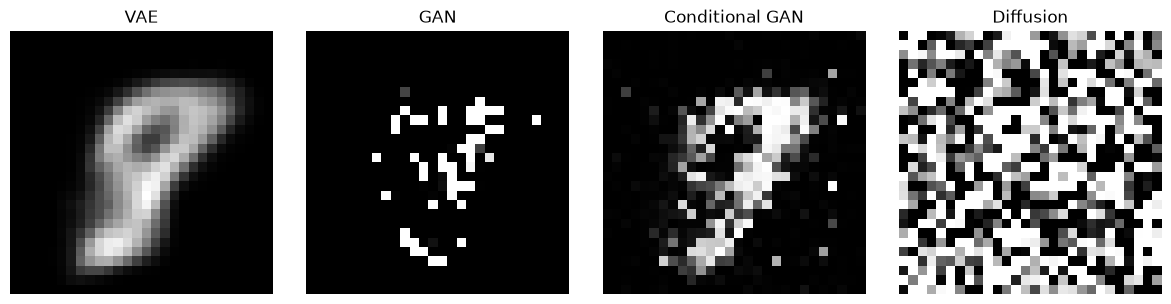

In [ ]:
# This cell assumes that the previously trained models
# are still available in the notebook.

fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 3)
)

# VAE
vae.eval()

with torch.no_grad():
    z = torch.randn(
        1,
        2,
        device=device
    )

    vae_sample = vae.decode(z)

vae_sample = vae_sample.view(28, 28).cpu()

axes[0].imshow(
    vae_sample,
    cmap="gray"
)

axes[0].set_title("VAE")

# GAN
generator.eval()

with torch.no_grad():
    z = torch.randn(
        1,
        100,
        device=device
    )

    gan_sample = generator(z)

gan_sample = gan_sample.view(28, 28).cpu()

axes[1].imshow(
    gan_sample,
    cmap="gray"
)

axes[1].set_title("GAN")

# Conditional GAN
cgan_generator.eval()

with torch.no_grad():
    z = torch.randn(
        1,
        100,
        device=device
    )

    label = torch.tensor(
        [7],
        device=device
    )

    cgan_sample = cgan_generator(
        z,
        label
    )

cgan_sample = cgan_sample.view(28, 28)

cgan_sample = (
    cgan_sample + 1
) / 2

axes[2].imshow(
    cgan_sample.cpu(),
    cmap="gray"
)

axes[2].set_title("Conditional GAN")

# Diffusion
diffusion_sample = generated_images[0]

axes[3].imshow(
    diffusion_sample,
    cmap="gray"
)

axes[3].set_title("Diffusion")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3.13.19 Important Practical Note

The visual comparison above is qualitative.

The models were trained with different objectives and training procedures.

Therefore, a single generated image should not be used to scientifically determine which architecture is better.

A proper evaluation requires:

- multiple generated samples
- appropriate evaluation metrics
- diversity analysis
- distribution comparison
- consistent experimental conditions

Generative modeling is more difficult to evaluate than ordinary supervised classification.

## 3.13.20 Final Comparison Table

| Property | AE | VAE | GAN | Autoregressive | Diffusion |
|---|---:|---:|---:|---:|---:|
| Reconstruction | Excellent | Excellent | No | No | No |
| Probabilistic Latent Space | No | Yes | Not explicit | No | Not necessarily |
| Training Stability | High | High | Lower | High | High |
| Sample Quality | Moderate | Good | High | High | Very High |
| Diversity | Good | Good | Can suffer from collapse | High | High |
| Sampling Speed | Fast | Fast | Very Fast | Slow | Slow |
| Explicit Likelihood | No | Approximate | No | Yes | Probabilistic formulation |
| Conditioning | Possible | Possible | Possible | Possible | Very Strong |
| Computational Cost | Low | Moderate | Moderate–High | High | High |

## 3.13.21 Exam Questions to Practice

### Question 1

What is the main difference between an Autoencoder and a VAE?

### Question 2

Explain how a GAN generates new samples.

### Question 3

What is mode collapse?

### Question 4

Explain the autoregressive factorization:

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

### Question 5

Explain the forward and reverse processes of a diffusion model.

### Question 6

Why are diffusion models computationally expensive during sampling?

### Question 7

What is conditional generation?

### Question 8

Compare VAE, GAN, autoregressive models, and diffusion models.

### Question 9

What is latent diffusion?

### Question 10

Why is diversity important when evaluating generative models?

## 3.13.22 Exam Summary — Generative Model Comparison

The major generative architectures solve the same broad problem in different ways.

### Autoencoder

$$
x\rightarrow z\rightarrow\hat{x}
$$

Focus:

**reconstruction and representation learning**

### VAE

$$
x\rightarrow q_\phi(z|x)\rightarrow p_\theta(x|z)
$$

Focus:

**probabilistic latent representation**

### GAN

$$
G(z)\leftrightarrow D(x)
$$

Focus:

**adversarial generation**

### Autoregressive Model

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

Focus:

**sequential probability modeling**

### Diffusion

$$
x_T\rightarrow\cdots\rightarrow x_0
$$

Focus:

**iterative denoising**

### Conditional Generation

$$
p(x|c)
$$

Focus:

**controlled generation**

The most important exam comparison is:

$$
\boxed{
\text{AE}
\rightarrow
\text{Reconstruction}
}
$$

$$
\boxed{
\text{VAE}
\rightarrow
\text{Probabilistic Latent Space}
}
$$

$$
\boxed{
\text{GAN}
\rightarrow
\text{Adversarial Learning}
}
$$

$$
\boxed{
\text{Autoregressive}
\rightarrow
\text{Sequential Probability}
}
$$

$$
\boxed{
\text{Diffusion}
\rightarrow
\text{Iterative Denoising}
}
$$

$$
\boxed{
\text{Conditional}
\rightarrow
\text{Controlled Generation}
}

# 3.14 Generative Deep Learning — Final Review & End-to-End Project

Generative Deep Learning focuses on learning the underlying structure or probability distribution of data and using the learned model to generate new samples.

Throughout this section, we studied:

1. Autoencoders
2. Variational Autoencoders
3. Generative Adversarial Networks
4. DCGAN
5. Conditional GAN
6. WGAN
7. Autoregressive Models
8. Diffusion Models
9. Conditional Generative Models
10. Latent Diffusion
11. Modern Generative Deep Learning Concepts

The fundamental objective is:

$$
p_\theta(x)
\approx
p_{data}(x)
$$

After learning this distribution, the model can generate new samples.

## 3.14.1 Complete Generative Deep Learning Map

Generative Deep Learning can be organized into several major approaches.

### Reconstruction-Based

$$
x
\rightarrow
z
\rightarrow
\hat{x}
$$

**Autoencoder**

### Probabilistic Latent Modeling

$$
x
\rightarrow
q_\phi(z|x)
\rightarrow
p_\theta(x|z)
$$

**VAE**

### Adversarial Learning

$$
G(z)
\leftrightarrow
D(x)
$$

**GAN**

### Sequential Probability Modeling

$$
p(x)
=
\prod_i
p(x_i|x_{<i})
$$

**Autoregressive Model**

### Iterative Denoising

$$
x_T
\rightarrow
x_{T-1}
\rightarrow
\cdots
\rightarrow
x_0
$$

**Diffusion Model**

### Controlled Generation

$$
p(x|c)
$$

**Conditional Generative Model**

## 3.14.2 Autoencoder — Final Review

An Autoencoder consists of an Encoder and Decoder.

$$
x
\rightarrow
Encoder
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

The reconstruction objective is:

$$
\mathcal{L}_{AE}
=
\|x-\hat{x}\|^2
$$

The main applications are:

- dimensionality reduction
- representation learning
- reconstruction
- denoising
- feature extraction

A standard Autoencoder does not explicitly force its latent space to follow a known probability distribution.

## 3.14.3 VAE — Final Review

A Variational Autoencoder models a probabilistic latent space.

The encoder estimates:

$$
q_\phi(z|x)
$$

The decoder models:

$$
p_\theta(x|z)
$$

The VAE objective is:

$$
\mathcal{L}_{VAE}
=
\mathcal{L}_{reconstruction}
+
\mathcal{L}_{KL}
$$

The KL divergence encourages:

$$
q_\phi(z|x)
\approx
\mathcal{N}(0,I)
$$

The reparameterization trick allows sampling while maintaining differentiability:

$$
z
=
\mu
+
\sigma\odot\epsilon
$$

where:

$$
\epsilon\sim\mathcal{N}(0,I)
$$

## 3.14.4 GAN — Final Review

A GAN contains:

### Generator

$$
z
\rightarrow
G(z)
\rightarrow
x_{fake}
$$

### Discriminator

$$
x
\rightarrow
D(x)
\rightarrow
P(real)
$$

The Generator attempts to fool the Discriminator.

The Discriminator attempts to distinguish real and generated samples.

The practical Generator objective is:

$$
\mathcal{L}_G
=
BCE(D(G(z)),1)
$$

GANs can generate sharp samples but can suffer from:

- mode collapse
- training instability
- sensitivity to hyperparameters

## 3.14.5 Autoregressive Models — Final Review

Autoregressive models factorize the probability distribution:

$$
p(x)
=
\prod_{i=1}^{n}
p(x_i|x_1,\ldots,x_{i-1})
$$

Each element is generated based on previously generated elements.

For an image:

$$
x_1
\rightarrow
x_2
\rightarrow
\cdots
\rightarrow
x_n
$$

For language:

$$
token_1
\rightarrow
token_2
\rightarrow
\cdots
\rightarrow
token_n
$$

Training commonly uses maximum likelihood:

$$
\mathcal{L}
=
-\sum_i
\log p_\theta(x_i|x_{<i})
$$

The main limitation is sequential sampling.

## 3.14.6 Diffusion Models — Final Review

Diffusion models consist of a forward noising process and a learned reverse denoising process.

Forward process:

$$
x_0
\rightarrow
x_1
\rightarrow
\cdots
\rightarrow
x_T
$$

where:

$$
x_T\approx\mathcal{N}(0,I)
$$

A direct formulation is:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

The neural network predicts:

$$
\epsilon_\theta(x_t,t)
$$

The simplified training objective is:

$$
\mathcal{L}
=
\mathbb{E}
\left[
\|\epsilon-\epsilon_\theta(x_t,t)\|^2
\right]
$$

Generation starts with Gaussian noise and repeatedly applies the reverse process.

## 3.14.7 Conditional Generation — Final Review

Conditional generation models:

$$
p(x|c)
$$

rather than only:

$$
p(x)
$$

The condition $c$ can represent:

- class
- text
- attributes
- image
- semantic information

For a Conditional GAN:

$$
G(z,c)
$$

and:

$$
D(x,c)
$$

For conditional diffusion:

$$
\epsilon_\theta(x_t,t,c)
$$

The main advantage is controllability.

## 3.14.8 End-to-End Generative Deep Learning Project

We now construct a small end-to-end experiment.

### Objective

Train a Conditional GAN on MNIST and generate one sample for each digit class.

The complete workflow is:

$$
Dataset
\rightarrow
Preprocessing
\rightarrow
Conditional Generator
\rightarrow
Conditional Discriminator
\rightarrow
Training
\rightarrow
Sampling
\rightarrow
Evaluation
$$

The model should learn:

$$
(z,c)
\rightarrow
G(z,c)
\rightarrow
\text{digit corresponding to }c
$$

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## 3.14.9 Dataset Preparation

We normalize MNIST images to:

$$
[-1,1]
$$

because the Generator uses a final `Tanh` activation.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

mnist_loader = DataLoader(
    mnist_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

print("Dataset size:", len(mnist_dataset))

Dataset size: 60000


## 3.14.10 Conditional Generator

The Generator receives:

- random latent vector $z$
- class label $c$

and generates an image:

$$
G(z,c)
$$

The class label is converted into an embedding before being combined with the latent vector.

In [ ]:
class FinalConditionalGenerator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=10,
        embedding_dim=10
    ):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.network = nn.Sequential(
            nn.Linear(
                latent_dim + embedding_dim,
                256
            ),
            nn.ReLU(),

            nn.Linear(
                256,
                512
            ),
            nn.ReLU(),

            nn.Linear(
                512,
                784
            ),
            nn.Tanh()
        )

    def forward(self, z, labels):

        label = self.label_embedding(labels)

        x = torch.cat(
            [z, label],
            dim=1
        )

        return self.network(x)

## 3.14.11 Conditional Discriminator

The Discriminator receives:

$$
(x,c)
$$

and determines whether the image is:

- real and consistent with the label
- fake and generated by the Generator

In [ ]:
class FinalConditionalDiscriminator(nn.Module):

    def __init__(
        self,
        input_dim=784,
        num_classes=10,
        embedding_dim=10
    ):
        super().__init__()

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_dim + embedding_dim,
                512
            ),
            nn.LeakyReLU(0.2),

            nn.Linear(
                512,
                256
            ),
            nn.LeakyReLU(0.2),

            nn.Linear(
                256,
                1
            ),
            nn.Sigmoid()
        )

    def forward(self, x, labels):

        label = self.label_embedding(labels)

        x = torch.cat(
            [x, label],
            dim=1
        )

        return self.network(x)

## 3.14.12 Initialize the Models

We initialize:

- Generator
- Discriminator
- loss function
- optimizers

In [ ]:
final_generator = FinalConditionalGenerator().to(device)

final_discriminator = FinalConditionalDiscriminator().to(device)

criterion = nn.BCELoss()

generator_optimizer = torch.optim.Adam(
    final_generator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

discriminator_optimizer = torch.optim.Adam(
    final_discriminator.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

print("Models initialized.")

Models initialized.


## 3.14.13 Training the Conditional GAN

For the Discriminator:

$$
\mathcal{L}_D
=
\mathcal{L}_{real}
+
\mathcal{L}_{fake}
$$

For the Generator:

$$
\mathcal{L}_G
=
BCE(D(G(z,c),c),1)
$$

The Generator learns to produce samples that the Discriminator considers real and consistent with the requested class.

In [ ]:
def train_final_cgan_step(
    real_images,
    real_labels
):

    batch_size = real_images.size(0)

    real_images = real_images.view(
        batch_size,
        -1
    ).to(device)

    real_labels = real_labels.to(device)

    real_targets = torch.ones(
        batch_size,
        1,
        device=device
    )

    fake_targets = torch.zeros(
        batch_size,
        1,
        device=device
    )

    # -------------------------
    # Discriminator
    # -------------------------

    z = torch.randn(
        batch_size,
        100,
        device=device
    )

    fake_labels = torch.randint(
        0,
        10,
        (batch_size,),
        device=device
    )

    fake_images = final_generator(
        z,
        fake_labels
    )

    real_predictions = final_discriminator(
        real_images,
        real_labels
    )

    fake_predictions = final_discriminator(
        fake_images.detach(),
        fake_labels
    )

    discriminator_loss = (
        criterion(
            real_predictions,
            real_targets
        )
        +
        criterion(
            fake_predictions,
            fake_targets
        )
    )

    discriminator_optimizer.zero_grad()

    discriminator_loss.backward()

    discriminator_optimizer.step()

    # -------------------------
    # Generator
    # -------------------------

    z = torch.randn(
        batch_size,
        100,
        device=device
    )

    requested_labels = torch.randint(
        0,
        10,
        (batch_size,),
        device=device
    )

    generated_images = final_generator(
        z,
        requested_labels
    )

    predictions = final_discriminator(
        generated_images,
        requested_labels
    )

    generator_loss = criterion(
        predictions,
        real_targets
    )

    generator_optimizer.zero_grad()

    generator_loss.backward()

    generator_optimizer.step()

    return (
        discriminator_loss.item(),
        generator_loss.item()
    )

## 3.14.14 Train the End-to-End Model

For a practical notebook demonstration, a small number of epochs is sufficient to understand the complete workflow.

For better generated quality, the model can be trained longer.

In [ ]:
final_epochs = 5

final_g_losses = []
final_d_losses = []

for epoch in range(final_epochs):

    total_g_loss = 0.0
    total_d_loss = 0.0

    for images, labels in mnist_loader:

        d_loss, g_loss = train_final_cgan_step(
            images,
            labels
        )

        total_d_loss += d_loss
        total_g_loss += g_loss

    avg_d_loss = (
        total_d_loss
        / len(mnist_loader)
    )

    avg_g_loss = (
        total_g_loss
        / len(mnist_loader)
    )

    final_d_losses.append(
        avg_d_loss
    )

    final_g_losses.append(
        avg_g_loss
    )

    print(
        f"Epoch [{epoch + 1}/{final_epochs}] "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

Epoch [1/5] D Loss: 0.8676 | G Loss: 1.8351
Epoch [2/5] D Loss: 0.3814 | G Loss: 3.6802
Epoch [3/5] D Loss: 0.3870 | G Loss: 3.9252
Epoch [4/5] D Loss: 0.3742 | G Loss: 3.5699
Epoch [5/5] D Loss: 0.3572 | G Loss: 3.9733


## 3.14.15 Visualize Training Losses

The Generator and Discriminator have different objectives.

Therefore, their losses do not necessarily decrease smoothly like ordinary supervised learning loss.

GAN loss curves should be interpreted together with generated samples.

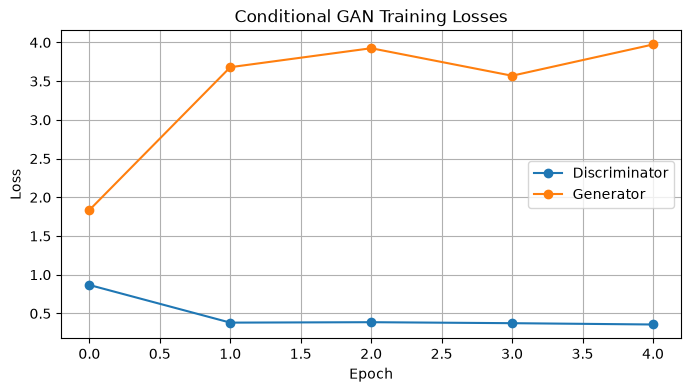

In [ ]:
plt.figure(figsize=(8, 4))

plt.plot(
    final_d_losses,
    marker="o",
    label="Discriminator"
)

plt.plot(
    final_g_losses,
    marker="o",
    label="Generator"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conditional GAN Training Losses")

plt.legend()
plt.grid(True)
plt.show()

## 3.14.16 Generate One Sample for Each Class

We now explicitly request:

$$
0,1,2,\ldots,9
$$

The latent vectors provide randomness while the labels provide semantic control.

Therefore:

$$
(z,0)\rightarrow G(z,0)
$$

should generate a zero, while:

$$
(z,7)\rightarrow G(z,7)
$$

should generate a seven.

In [ ]:
final_generator.eval()

labels = torch.arange(
    10,
    device=device
)

z = torch.randn(
    10,
    100,
    device=device
)

with torch.no_grad():

    samples = final_generator(
        z,
        labels
    )

samples = samples.view(
    10,
    28,
    28
)

samples = (
    samples + 1
) / 2

samples = samples.clamp(
    0,
    1
).cpu()

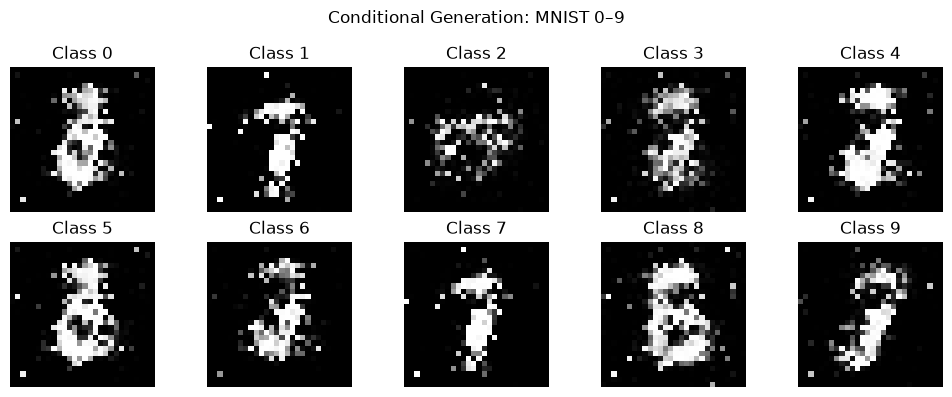

In [ ]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 4)
)

for i, ax in enumerate(
    axes.flat
):

    ax.imshow(
        samples[i],
        cmap="gray"
    )

    ax.set_title(
        f"Class {i}"
    )

    ax.axis("off")

plt.suptitle(
    "Conditional Generation: MNIST 0–9"
)

plt.tight_layout()
plt.show()

## 3.14.17 What Did We Build?

The complete system was:

$$
\boxed{
(z,c)
\rightarrow
G(z,c)
\rightarrow
x_{fake}
}
$$

The Discriminator evaluates:

$$
\boxed{
(x,c)
\rightarrow
D(x,c)
}
$$

Training teaches the Generator to produce samples that are:

1. realistic
2. consistent with the requested condition

This is a complete generative deep learning pipeline.

We performed:

$$
Dataset
\rightarrow
Preprocessing
\rightarrow
Model
\rightarrow
Training
\rightarrow
Sampling
\rightarrow
Visualization
$$

## 3.14.18 Final Generative Deep Learning Comparison

| Model | Core Idea | Main Strength | Main Limitation |
|---|---|---|---|
| Autoencoder | Reconstruction | Representation learning | Weak unconstrained generation |
| VAE | Probabilistic latent space | Smooth latent space | Samples can be blurry |
| GAN | Adversarial learning | Sharp samples | Training instability |
| DCGAN | Convolutional GAN | Better image generation | Still GAN limitations |
| cGAN | Conditional GAN | Controlled generation | Requires conditions |
| WGAN | Wasserstein objective | Improved training behavior | More complex training |
| Autoregressive | Probability factorization | Explicit likelihood | Slow sequential sampling |
| Diffusion | Iterative denoising | High-quality and diverse samples | Slow sampling |
| Latent Diffusion | Diffusion in latent space | Computational efficiency | Requires latent representation |

## 3.14.19 Most Important Exam Concepts

### Autoencoder

$$
x\rightarrow z\rightarrow\hat{x}
$$

### VAE

$$
q_\phi(z|x)
$$

with:

$$
\mathcal{L}
=
\mathcal{L}_{reconstruction}
+
\mathcal{L}_{KL}
$$

### GAN

$$
G(z)\leftrightarrow D(x)
$$

### Autoregressive

$$
p(x)
=
\prod_i p(x_i|x_{<i})
$$

### Diffusion

$$
x_0\rightarrow x_T
$$

followed by:

$$
x_T\rightarrow x_0
$$

### Conditional Generation

$$
p(x|c)
$$

### Latent Diffusion

$$
x
\rightarrow
z
\rightarrow
Diffusion
\rightarrow
z'
\rightarrow
x'
$$

## 3.14.20 Final Exam Questions

1. What is Generative Deep Learning?

2. Explain the difference between generative and discriminative models.

3. Explain the architecture of an Autoencoder.

4. Why is a VAE different from a standard Autoencoder?

5. Explain the reparameterization trick.

6. Explain the architecture and objective of a GAN.

7. What is mode collapse?

8. Explain DCGAN.

9. What is a Conditional GAN?

10. Explain WGAN and its motivation.

11. Explain autoregressive probability factorization.

12. What is teacher forcing?

13. Explain the forward diffusion process.

14. Explain the reverse diffusion process.

15. Derive the direct sampling equation:

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

16. What does a diffusion model predict?

17. Explain the DDPM loss.

18. What is latent diffusion?

19. What is conditional generation?

20. Compare VAE, GAN, autoregressive models, and diffusion models.

21. Explain the trade-off between sample quality, diversity, sampling speed, and computational cost.

## 3.14.21 Generative Deep Learning — Final Summary

Generative Deep Learning learns models capable of producing new data.

The fundamental goal is:

$$
p_\theta(x)
\approx
p_{data}(x)
$$

Different architectures approach this problem differently.

### Autoencoder

Learns reconstruction.

### VAE

Learns a probabilistic latent space.

### GAN

Uses adversarial competition.

### Autoregressive Model

Factorizes the probability distribution.

### Diffusion Model

Learns to reverse a noise process.

### Conditional Model

Provides control over generation.

Modern generative deep learning combines these ideas with:

- latent representations
- attention
- Transformers
- conditioning
- efficient sampling
- guidance
- large-scale neural networks

The most important conceptual distinction is:

$$
\boxed{
\text{Different architectures learn the data distribution in different ways.}
}
$$

A strong Deep Learning student should understand not only how to implement these models, but also:

- why they work
- what objective they optimize
- how they generate samples
- their advantages
- their limitations
- when to choose one architecture over another

# Generative Deep Learning — COMPLETE

We have completed the Generative Deep Learning portion of the notebook.

Covered:

- Autoencoders
- Variational Autoencoders
- GANs
- DCGAN
- Conditional GAN
- WGAN
- Autoregressive Models
- Diffusion Models
- Conditional Generative Models
- Latent Diffusion
- Modern Generative AI concepts
- Model comparison
- End-to-end generative project



# 4.1 Representation Learning

Representation Learning is the process of automatically learning useful features or representations of data from raw input.

Instead of manually designing features, a deep learning model learns a transformation:

$$
z = f_\theta(x)
$$

where:

- $x$ = original input
- $f_\theta$ = neural network with learnable parameters $\theta$
- $z$ = learned representation

The representation $z$ should capture important information about the input while making the data easier to use for downstream tasks.

For example, for an image:

$$
\text{Raw Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Textures}
\rightarrow
\text{Shapes}
\rightarrow
\text{Objects}
$$

A deep neural network can learn these representations automatically.

---

## Why Representation Learning Matters

Traditional machine learning often depends heavily on manually engineered features.

For example, for image classification, one might manually construct:

- edge features
- color histograms
- texture descriptors
- shape descriptors

Deep learning instead attempts to learn these features directly from data.

The general pipeline becomes:

$$
x
\rightarrow
\text{Neural Network}
\rightarrow
z
\rightarrow
\text{Task}
$$

where $z$ is the learned representation.

A good representation should:

1. Preserve useful information.
2. Ignore irrelevant variation.
3. Separate different concepts.
4. Be useful for downstream tasks.
5. Generalize to unseen examples.

---

## Example

Suppose a neural network receives an image of a cat.

The raw input may contain thousands of pixel values.

A learned representation might progressively capture:

$$
\text{Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Textures}
\rightarrow
\text{Parts}
\rightarrow
\text{Cat Representation}
$$

The final representation can then be used for:

- classification
- retrieval
- clustering
- similarity measurement
- object detection
- transfer learning
- generation

---

## Representation Learning in Deep Learning

Representation learning is one of the central ideas behind deep learning.

Different architectures learn different types of representations.

| Architecture | Typical Representation |
|---|---|
| CNN | Spatial/image features |
| RNN | Sequential representations |
| Transformer | Contextual representations |
| Autoencoder | Latent representations |
| VAE | Probabilistic latent representations |
| Contrastive model | Similarity-aware representations |
| Siamese Network | Metric/similarity representations |

Thus, representation learning is not a single algorithm.

It is a general principle:

> Let the neural network learn the features required to solve the problem.

In [150]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.8.0+cu128
Device: cuda


## A Simple Learned Representation

We can demonstrate the basic idea using a neural network that transforms an input vector into a lower-dimensional representation.

Suppose:

$$
x \in \mathbb{R}^{10}
$$

and we want to learn:

$$
z \in \mathbb{R}^{2}
$$

The network performs:

$$
\mathbb{R}^{10}
\rightarrow
\mathbb{R}^{32}
\rightarrow
\mathbb{R}^{2}
$$

The two-dimensional representation can then be visualized.

In [151]:
class RepresentationNetwork(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=32, representation_dim=2):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, representation_dim)
        )

    def forward(self, x):
        return self.network(x)


model = RepresentationNetwork()

x = torch.randn(8, 10)
z = model(x)

print("Input shape:", x.shape)
print("Representation shape:", z.shape)

Input shape: torch.Size([8, 10])
Representation shape: torch.Size([8, 2])


### What Happened?

The original input has shape:

$$
8 \times 10
$$

The network transforms it into:

$$
8 \times 2
$$

Therefore, each 10-dimensional input vector now has a learned 2-dimensional representation.

However, there is an important point:

A neural network does **not automatically learn a useful representation simply because we reduce dimensionality**.

The learning objective determines what information the representation captures.

For example:

- classification encourages class-discriminative features
- reconstruction encourages information preservation
- contrastive learning encourages similar samples to have similar representations
- metric learning encourages meaningful distances
- self-supervised learning creates representations without requiring manual labels

Therefore:

$$
\boxed{
\text{Representation Quality depends strongly on the Learning Objective}
}
$$

# 4.2 Why Representation Learning?

The main motivation for representation learning is to move from manually engineered features toward automatically learned features.

## Traditional Feature Engineering

A traditional pipeline might look like:

$$
\text{Raw Data}
\rightarrow
\text{Manual Feature Engineering}
\rightarrow
\text{Machine Learning Model}
\rightarrow
\text{Prediction}
$$

The quality of the final model can depend heavily on the quality of manually designed features.

---

## Deep Representation Learning

Deep learning changes the pipeline:

$$
\text{Raw Data}
\rightarrow
\text{Deep Neural Network}
\rightarrow
\text{Learned Representation}
\rightarrow
\text{Prediction}
$$

The network learns useful features directly from the data.

---

## Hierarchical Representations

One of the most important properties of deep networks is hierarchical representation learning.

For an image, early layers may learn simple patterns:

$$
\text{Pixels}
\rightarrow
\text{Edges}
$$

Middle layers can combine these patterns:

$$
\text{Edges}
\rightarrow
\text{Textures and Shapes}
$$

Deeper layers can represent semantic concepts:

$$
\text{Shapes}
\rightarrow
\text{Object Parts}
\rightarrow
\text{Objects}
$$

This hierarchy is a major reason deep neural networks are powerful.

---

## Example: Image Classification

Consider an image classification network.

A simplified representation hierarchy might be:

$$
x
\rightarrow
h_1
\rightarrow
h_2
\rightarrow
h_3
\rightarrow
z
\rightarrow
\hat{y}
$$

where:

- $x$ = raw image
- $h_1$ = low-level features
- $h_2$ = intermediate features
- $h_3$ = high-level features
- $z$ = final learned representation
- $\hat{y}$ = prediction

The representation becomes progressively more abstract.

---

## Important Idea

Representation learning is not simply about reducing the number of dimensions.

The goal is to learn a representation that captures the **right information** for a particular purpose.

Therefore:

$$
\boxed{
\text{Good Representation}
=
\text{Useful Information}
+
\text{Robustness}
+
\text{Generalization}
}
$$

## visualize hierarchical feature dimensions:

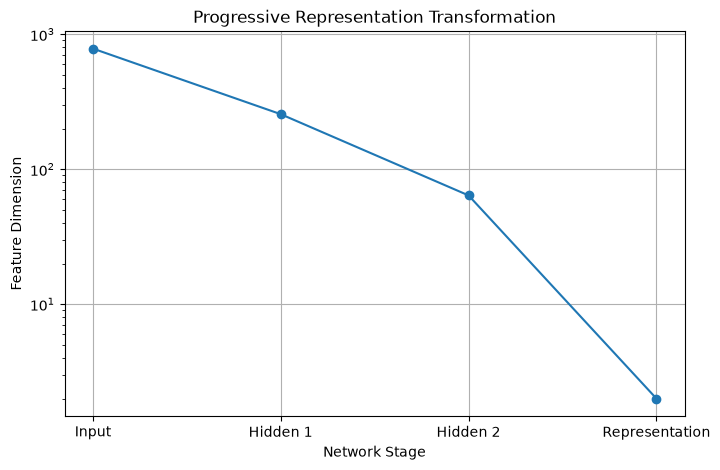

In [152]:
import numpy as np

layers = ["Input", "Hidden 1", "Hidden 2", "Representation"]
dimensions = [784, 256, 64, 2]

plt.figure(figsize=(8, 5))
plt.plot(layers, dimensions, marker="o")
plt.yscale("log")
plt.xlabel("Network Stage")
plt.ylabel("Feature Dimension")
plt.title("Progressive Representation Transformation")
plt.grid(True)
plt.show()

## Exam Perspective

Representation learning is an important concept because it connects many areas of deep learning.

You should be able to explain:

1. What a representation is.
2. Why learned representations are useful.
3. Difference between handcrafted and learned features.
4. What hierarchical representation learning means.
5. How different learning objectives produce different representations.
6. Why representations are important for transfer learning and downstream tasks.

### Key Definition

> Representation learning is the process of automatically learning useful representations or features from raw data using a learning algorithm, particularly neural networks.

### Core Equation

$$
z = f_\theta(x)
$$

where $z$ is the learned representation.

### Central Principle

$$
\boxed{
\text{Learn the representation instead of manually designing it}
}
$$

# 4.3 Feature Representation

A feature representation is a numerical description of an input that captures information useful for learning.

For an input $x$, a representation can be written as:

$$
z = f_\theta(x)
$$

where:

- $x$ = original input
- $f_\theta$ = feature extraction function
- $z$ = learned feature representation

The representation can have the same dimensionality as the input, a lower dimensionality, or a higher dimensionality depending on the architecture and objective.

---

## 1. Raw Representation

The simplest representation is the original data itself.

For a grayscale MNIST image:

$$
x \in \mathbb{R}^{28 \times 28}
$$

After flattening:

$$
x \in \mathbb{R}^{784}
$$

Each dimension corresponds to a pixel intensity.

The problem is that raw pixels do not necessarily provide a representation that is convenient for a particular task.

For example, two images of the same digit may have different pixel values because of:

- translation
- rotation
- thickness
- writing style
- scale
- noise

A useful representation should ideally capture the underlying structure while being less sensitive to irrelevant changes.

---

## 2. Handcrafted Representation

Before deep learning became dominant, features were often designed manually.

For images, examples include:

- edges
- corners
- texture descriptors
- color histograms
- shape descriptors

The pipeline becomes:

$$
\text{Image}
\rightarrow
\text{Handcrafted Features}
\rightarrow
\text{Machine Learning Model}
$$

The main limitation is that the feature designer must determine which properties are useful.

---

## 3. Learned Representation

Deep learning allows the model to learn features automatically.

The pipeline becomes:

$$
\text{Input}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Learned Features}
\rightarrow
\text{Task}
$$

For a neural network:

$$
h_1 = f_1(x)
$$

$$
h_2 = f_2(h_1)
$$

$$
z = f_3(h_2)
$$

Each layer can transform the representation into a more useful form.

---

## 4. Latent Representation

A latent representation is an internal representation that is not directly observed in the original data.

For example:

$$
x \in \mathbb{R}^{784}
$$

can be transformed into:

$$
z \in \mathbb{R}^{32}
$$

The 32-dimensional vector $z$ is a latent representation.

Latent representations are widely used in:

- autoencoders
- VAEs
- GANs
- diffusion models
- contrastive learning
- representation learning systems

---

## 5. Distributed Representation

A distributed representation represents information across many dimensions rather than assigning one dimension to one concept.

For example, a representation:

$$
z =
[z_1,z_2,\ldots,z_d]
$$

may encode several properties simultaneously.

Different dimensions can participate in representing:

- shape
- texture
- category
- position
- semantic information

This is one of the important characteristics of neural representations.

---

## 6. Embeddings

An embedding is a learned vector representation of an object.

For example:

$$
\text{word}
\rightarrow
\text{vector}
$$

or:

$$
\text{image}
\rightarrow
\text{feature vector}
$$

or:

$$
\text{user}
\rightarrow
\text{user embedding}
$$

Embeddings allow objects to be compared using mathematical operations such as distance or similarity.

For two representations $z_1$ and $z_2$, Euclidean distance is:

$$
d(z_1,z_2)
=
\|z_1-z_2\|_2
$$

Cosine similarity is:

$$
\operatorname{sim}(z_1,z_2)
=
\frac{z_1^\top z_2}
{\|z_1\|_2\|z_2\|_2}
$$

These concepts become particularly important in contrastive and metric learning.

---

## Representation Hierarchy

A deep neural network can learn a hierarchy of representations:

$$
\text{Raw Input}
\rightarrow
\text{Low-Level Features}
\rightarrow
\text{Mid-Level Features}
\rightarrow
\text{High-Level Features}
\rightarrow
\text{Semantic Representation}
$$

For images, this can approximately correspond to:

$$
\text{Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Textures}
\rightarrow
\text{Shapes}
\rightarrow
\text{Objects}
$$

This hierarchical feature learning is a fundamental characteristic of deep learning.

In [153]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class FeatureExtractor(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, feature_dim=32):
        super().__init__()

        self.features = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, feature_dim)
        )

    def forward(self, x):
        return self.features(x)


feature_extractor = FeatureExtractor()

sample_images = torch.randn(16, 784)

features = feature_extractor(sample_images)

print("Input shape:", sample_images.shape)
print("Feature representation shape:", features.shape)

Input shape: torch.Size([16, 784])
Feature representation shape: torch.Size([16, 32])


The network transformed:

$$
16 \times 784
\rightarrow
16 \times 32
$$

Therefore, every image is represented by a 32-dimensional feature vector.

The feature vector can now be used by another model:

$$
x
\rightarrow
\boxed{z}
\rightarrow
\text{Classifier}
$$

The feature extractor and classifier can either be trained together or the feature extractor can be trained separately and reused later.

This idea leads directly to **transfer learning**.

# 4.4 Learned Features vs Handcrafted Features

## Handcrafted Features

Handcrafted features are designed using domain knowledge.

Example:

$$
\text{Image}
\rightarrow
\text{Edge Detector}
\rightarrow
\text{Shape Features}
\rightarrow
\text{Classifier}
$$

The feature extraction rules are explicitly designed by humans.

### Advantages

- interpretable
- can work well with limited data
- can incorporate domain knowledge
- computationally simple in many cases

### Limitations

- requires domain expertise
- difficult to design for complex data
- may not generalize well
- feature engineering becomes difficult as the problem becomes more complex

---

## Learned Features

In deep learning:

$$
\text{Raw Data}
\rightarrow
\text{Neural Network}
\rightarrow
\text{Learned Representation}
$$

The parameters of the feature extractor are learned from data.

For example:

$$
z=f_\theta(x)
$$

where $\theta$ is learned during training.

### Advantages

- automatic feature extraction
- hierarchical representations
- adapts to the task
- works well with large datasets
- representations can be reused

### Limitations

- often requires substantial data
- computationally expensive
- representations may be difficult to interpret
- quality depends on the learning objective

---

## Comparison

| Property | Handcrafted Features | Learned Features |
|---|---|---|
| Designed by | Humans | Neural network |
| Domain knowledge | Often required | Less explicit |
| Hierarchical | Usually limited | Naturally supported |
| Adaptation | Manual | Learned |
| Data requirement | Often lower | Often higher |
| Scalability | Limited for complex data | Strong |
| Interpretability | Often higher | Often lower |

The transition from handcrafted features to learned representations is one of the major ideas behind modern deep learning.

## simple representation pipeline:

In [154]:
class ClassifierWithFeatures(nn.Module):
    def __init__(self, input_dim=784, feature_dim=32, num_classes=10):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, feature_dim)
        )

        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        z = self.feature_extractor(x)
        logits = self.classifier(z)
        return logits, z


model = ClassifierWithFeatures()

x = torch.randn(32, 784)

logits, representations = model(x)

print("Representations:", representations.shape)
print("Classifier output:", logits.shape)

Representations: torch.Size([32, 32])
Classifier output: torch.Size([32, 10])


Notice the separation:

$$
x
\rightarrow
\boxed{f_\theta(x)=z}
\rightarrow
\boxed{g_\phi(z)=\hat{y}}
$$

Here:

- $f_\theta$ = feature extractor
- $z$ = learned representation
- $g_\phi$ = task-specific prediction head
- $\hat{y}$ = prediction

This separation is extremely important in modern deep learning.

A trained feature extractor can potentially be reused for another task:

$$
\text{Dataset A}
\rightarrow
\text{Learn Representation}
\rightarrow
\text{Reuse Representation}
\rightarrow
\text{Dataset B}
$$

This becomes the foundation for **transfer learning and pretrained models**.

# 4.5 Representation Learning — Core Exam Points

### Definition

Representation learning automatically learns useful feature representations from data.

$$
z=f_\theta(x)
$$

### Important Representation Types

1. Raw representations
2. Handcrafted features
3. Learned features
4. Latent representations
5. Distributed representations
6. Embeddings

### Key Difference

Handcrafted features:

$$
\text{Human-designed}
$$

Learned features:

$$
\text{Data-driven}
$$

### Deep Learning Advantage

Deep networks can learn hierarchical representations:

$$
\text{Low-Level}
\rightarrow
\text{Mid-Level}
\rightarrow
\text{High-Level}
$$

### Important Applications

Learned representations can be used for:

- classification
- clustering
- retrieval
- similarity search
- transfer learning
- generative modeling
- metric learning
- downstream prediction

### Exam Question

**Q: What is the difference between feature engineering and representation learning?**

**Answer:** Feature engineering manually designs useful features using domain knowledge, whereas representation learning automatically learns useful features from data through an optimization process.

### One-Line Memory

$$
\boxed{
\text{Representation Learning = Learning useful features automatically}
}
$$

# 4.6 Distributed Representations and Embeddings

A **distributed representation** represents an object using a pattern of activation across multiple dimensions.

Instead of representing an object using a single feature, information is distributed across a vector:

$$
z = [z_1,z_2,\ldots,z_d]
$$

For example, an image may be represented as:

$$
z \in \mathbb{R}^{128}
$$

Each dimension does not necessarily correspond to one human-interpretable concept.

Instead, multiple dimensions jointly encode information.

---

## Why Distributed Representations?

Suppose we want to represent three concepts:

- cat
- dog
- car

A simple one-hot representation could be:

$$
\text{cat}=[1,0,0]
$$

$$
\text{dog}=[0,1,0]
$$

$$
\text{car}=[0,0,1]
$$

The problem is that one-hot vectors do not naturally express similarity.

For example:

$$
d(\text{cat},\text{dog})
=
d(\text{cat},\text{car})
$$

under ordinary Euclidean distance.

A learned distributed representation can instead place related concepts closer together:

$$
\text{cat}
\approx
\text{dog}
$$

while:

$$
\text{cat}
\not\approx
\text{car}
$$

This allows the geometry of the representation space to encode relationships.

---

# Embeddings

An embedding is a learned vector representation.

An embedding function can be written as:

$$
e = f_\theta(x)
$$

where:

- $x$ = object
- $f_\theta$ = learned embedding function
- $e$ = embedding vector

Examples include:

$$
\text{Word} \rightarrow \text{Word Embedding}
$$

$$
\text{Image} \rightarrow \text{Image Embedding}
$$

$$
\text{User} \rightarrow \text{User Embedding}
$$

$$
\text{Product} \rightarrow \text{Product Embedding}
$$

---

# Embedding Space

Suppose every image is represented by a 2-dimensional vector:

$$
z=[z_1,z_2]
$$

We can visualize every image as a point in a two-dimensional space.

A good representation may organize the points according to meaningful properties.

For example:

$$
\text{Similar Samples}
\rightarrow
\text{Nearby Points}
$$

and:

$$
\text{Different Samples}
\rightarrow
\text{Distant Points}
$$

This geometric interpretation is extremely important in representation learning.

---

# Similarity Measures

## Euclidean Distance

$$
d(z_1,z_2)
=
\sqrt{\sum_{i=1}^{d}(z_{1i}-z_{2i})^2}
$$

Smaller distance means the vectors are closer.

---

## Cosine Similarity

$$
\operatorname{sim}(z_1,z_2)
=
\frac{z_1^\top z_2}
{\|z_1\|_2\|z_2\|_2}
$$

Cosine similarity focuses on the angle between vectors.

It is commonly used in embedding-based systems.

---

# Important Idea

An embedding is not inherently meaningful.

The model must be trained with an objective that encourages useful geometry.

For example:

- classification can produce class-discriminative features
- contrastive learning can bring positive pairs together
- metric learning can organize distances
- language modeling can produce contextual representations
- reconstruction can encourage information preservation

Therefore:

$$
\boxed{
\text{Learning Objective}
\rightarrow
\text{Representation Geometry}
}
$$

## create a simple embedding layer:

In [155]:
import torch
import torch.nn as nn

num_classes = 10
embedding_dim = 8

embedding = nn.Embedding(
    num_embeddings=num_classes,
    embedding_dim=embedding_dim
)

labels = torch.arange(num_classes)

embeddings = embedding(labels)

print("Embedding shape:", embeddings.shape)
print(embeddings)

Embedding shape: torch.Size([10, 8])
tensor([[ 2.7153, -0.6687,  0.3601, -2.0405,  0.2187, -0.0395, -0.6973,  1.8667],
        [-1.9912,  0.0697, -0.1574, -1.2960,  0.4035,  0.5407, -0.1052,  0.1480],
        [-0.2808,  1.1965,  0.5181, -0.6862, -0.4528,  1.4610, -0.6130, -0.2198],
        [-0.0374, -0.5261,  1.2335,  0.0047, -0.3641, -1.5633, -0.0040, -0.7049],
        [-1.2501, -2.4428, -0.0429,  0.4643, -1.3850, -0.2739,  0.2858, -0.3582],
        [ 0.9201, -0.2254,  0.6781, -0.7926,  0.8919, -0.2777,  0.2485,  2.6989],
        [-0.1089, -2.1957,  0.8184,  1.2651, -1.2612, -0.2136, -0.1416, -0.4320],
        [ 1.6310, -0.6492,  1.0579,  0.4910,  0.3145,  0.1428,  0.1505,  0.1248],
        [ 0.0142, -0.6229,  1.3949,  0.0966, -0.7413,  0.0406, -0.5845, -1.1491],
        [-0.9255,  0.0772,  0.0479,  0.7824,  0.3641, -0.6022, -0.7106, -0.0642]],
       grad_fn=<EmbeddingBackward0>)


The embedding layer maps each discrete class ID to a dense vector.

For 10 classes and an embedding dimension of 8:

$$
10
\rightarrow
10 \times 8
$$

Each class receives an 8-dimensional vector.

The embedding parameters are learned during training.

Conceptually:

$$
\text{Class ID}
\rightarrow
\boxed{\text{Learned Vector}}
$$

This same principle is used much more broadly than class labels.

Embeddings can represent words, users, products, images, documents, entities, and many other objects.

## visualize embeddings:

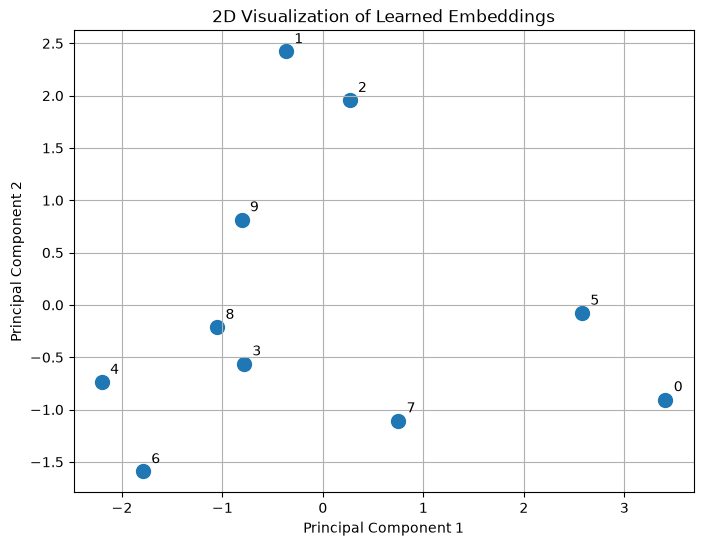

In [156]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

embedding_vectors = embeddings.detach().numpy()

pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(embedding_vectors)

plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=100
)

for i, (x, y) in enumerate(embedding_2d):
    plt.annotate(
        str(i),
        (x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D Visualization of Learned Embeddings")
plt.grid(True)
plt.show()

### Important Observation

The embeddings above are randomly initialized.

Therefore, the visualization does **not** yet represent meaningful relationships.

This is a critical point:

$$
\boxed{
\text{Embedding Layer} \neq \text{Useful Representation Automatically}
}
$$

The embedding becomes meaningful when training provides a suitable objective.

For example, if the model is trained so that similar objects have similar embeddings, the geometry of the embedding space becomes useful.

This idea leads directly to **metric learning and contrastive learning**.

# 4.7 Autoencoder as a Representation Learner

An autoencoder can learn a compact representation of data.

The architecture consists of:

$$
x
\rightarrow
\boxed{\text{Encoder}}
\rightarrow
z
\rightarrow
\boxed{\text{Decoder}}
\rightarrow
\hat{x}
$$

where:

- $x$ = input
- $z$ = latent representation
- $\hat{x}$ = reconstructed input

The encoder learns:

$$
z=f_\theta(x)
$$

The decoder learns:

$$
\hat{x}=g_\phi(z)
$$

The model is trained so that:

$$
\hat{x}\approx x
$$

---

## Reconstruction Objective

For continuous-valued data, a common loss is mean squared error:

$$
\mathcal{L}_{reconstruction}
=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{x}_i)^2
$$

The encoder must therefore preserve information necessary for reconstruction.

---

## Representation Learning View

The important part for representation learning is not only the reconstructed image.

The encoder produces:

$$
z=f_\theta(x)
$$

This latent vector can be used as a feature representation.

Therefore:

$$
\text{Input}
\rightarrow
\boxed{\text{Encoder}}
\rightarrow
\boxed{\text{Representation}}
\rightarrow
\text{Downstream Task}
$$

The decoder can be discarded after training if only the representation is required.

---

## Example

Suppose:

$$
x \in \mathbb{R}^{784}
$$

and:

$$
z \in \mathbb{R}^{32}
$$

Then the encoder transforms a 784-dimensional image into a 32-dimensional representation.

The decoder attempts to reconstruct the original 784-dimensional image.

The bottleneck forces the network to learn a compact representation.

---

## Important Limitation

Reconstruction quality does not necessarily mean that the representation is optimal for every downstream task.

An autoencoder is primarily encouraged to preserve information useful for reconstruction.

A classifier may instead require information that separates classes.

Therefore:

$$
\boxed{
\text{Best Reconstruction Representation}
\neq
\text{Best Representation for Every Task}
}
$$

This is why different representation-learning objectives exist.

In [157]:
class RepresentationAutoencoder(nn.Module):
    def __init__(self, input_dim=784, representation_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, representation_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(representation_dim, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        reconstruction = self.decoder(z)

        return reconstruction, z


autoencoder = RepresentationAutoencoder()

x = torch.rand(16, 784)

reconstruction, z = autoencoder(x)

print("Input:", x.shape)
print("Representation:", z.shape)
print("Reconstruction:", reconstruction.shape)

Input: torch.Size([16, 784])
Representation: torch.Size([16, 32])
Reconstruction: torch.Size([16, 784])


The complete representation-learning process is:

$$
x
\overset{f_\theta}{\longrightarrow}
z
\overset{g_\phi}{\longrightarrow}
\hat{x}
$$

Training minimizes:

$$
\mathcal{L}
=
\mathcal{L}(x,\hat{x})
$$

After training, the encoder can be viewed as a feature extractor:

$$
\boxed{
f_\theta:x\rightarrow z
}
$$

This is one of the simplest examples of representation learning using deep neural networks.

Later we will compare this approach with:

- supervised representation learning
- self-supervised learning
- contrastive learning
- metric learning
- Siamese networks
- triplet loss

# 4.8 Representation Learning vs Dimensionality Reduction

Representation learning and dimensionality reduction are related but they are not identical.

## Dimensionality Reduction

Dimensionality reduction attempts to represent data using fewer dimensions.

For example:

$$
\mathbb{R}^{784}
\rightarrow
\mathbb{R}^{2}
$$

PCA is a classical dimensionality-reduction technique.

Its goal is to preserve as much variance as possible using a lower-dimensional linear subspace.

---

## Representation Learning

Representation learning has a broader objective.

The goal is to learn a useful representation:

$$
z=f_\theta(x)
$$

The representation does not necessarily need to have lower dimensionality.

For example:

$$
\mathbb{R}^{784}
\rightarrow
\mathbb{R}^{128}
$$

or even:

$$
\mathbb{R}^{784}
\rightarrow
\mathbb{R}^{1024}
$$

can still be representation learning.

---

## PCA vs Neural Representation Learning

| Property | PCA | Neural Representation Learning |
|---|---|---|
| Main goal | Variance preservation | Learn useful representations |
| Transformation | Linear | Potentially nonlinear |
| Learning | Closed-form/eigendecomposition | Optimization |
| Feature hierarchy | No | Yes |
| Task-aware | Usually no | Can be |
| Scalability | Strong for many settings | Strong with suitable hardware |
| Nonlinear structure | Limited | Can model nonlinear structure |

Therefore:

$$
\boxed{
\text{Dimensionality Reduction}
\subseteq
\text{Some Representation Learning Problems}
}
$$

but representation learning is a broader concept.

# 4.9 Distributed Representations and Embeddings — Exam Summary

## Distributed Representation

Information is distributed across multiple dimensions:

$$
z=[z_1,z_2,\ldots,z_d]
$$

## Embedding

An embedding is a learned vector representation:

$$
e=f_\theta(x)
$$

## Embedding Space

The geometry of the embedding space can encode relationships between objects.

Similar objects can be encouraged to have:

$$
d(z_1,z_2)\rightarrow 0
$$

while dissimilar objects can be encouraged to have larger distances.

## Important Similarity Measures

### Euclidean Distance

$$
d(z_1,z_2)=\|z_1-z_2\|_2
$$

### Cosine Similarity

$$
\operatorname{sim}(z_1,z_2)
=
\frac{z_1^\top z_2}
{\|z_1\|_2\|z_2\|_2}
$$

## Autoencoder Representation

$$
x
\rightarrow
\boxed{z}
\rightarrow
\hat{x}
$$

The encoder learns the representation.

## Critical Concept

An embedding or latent vector is not automatically useful.

The training objective determines what properties the representation learns.

$$
\boxed{
\text{Objective}
\rightarrow
\text{Representation}
\rightarrow
\text{Embedding Geometry}
}
$$

### Exam Questions

**Q1. What is a distributed representation?**

A representation in which information is encoded across multiple dimensions of a vector rather than being assigned to a single dimension.

**Q2. What is an embedding?**

A learned vector representation of an object that places objects in a continuous representation space.

**Q3. Why are embeddings useful?**

They allow objects to be represented numerically and compared using distances or similarities.

**Q4. Can every embedding be considered useful?**

No. The embedding must be learned using an objective that encourages the desired properties.

**Q5. How does an autoencoder learn representations?**

Its encoder maps the input to a latent vector, while the decoder reconstructs the input. Reconstruction training forces the latent representation to preserve information useful for reconstruction.

### One-Line Memory

$$
\boxed{
\text{Embedding = Learned Vector Representation}
}
$$

# 4.10 Supervised Representation Learning

Supervised representation learning learns feature representations using labeled data.

The model receives:

$$
(x,y)
$$

where:

- $x$ = input
- $y$ = target label

The neural network learns a representation:

$$
z=f_\theta(x)
$$

and then uses that representation to make a prediction:

$$
\hat{y}=g_\phi(z)
$$

Therefore, the complete model is:

$$
x
\rightarrow
\boxed{f_\theta}
\rightarrow
\boxed{z}
\rightarrow
\boxed{g_\phi}
\rightarrow
\hat{y}
$$

The important idea is that the representation $z$ is learned specifically to help solve the supervised task.

---

## Classification Example

Suppose we have images of digits.

The network can learn:

$$
\text{Image}
\rightarrow
\text{Feature Representation}
\rightarrow
\text{Digit Class}
$$

For example, representations of images belonging to digit `3` should ideally contain information that helps distinguish them from digits such as `7` or `8`.

The classification loss provides the learning signal.

For multi-class classification, cross-entropy loss is commonly used:

$$
\mathcal{L}_{CE}
=
-\sum_{k=1}^{C}
y_k\log(\hat{p}_k)
$$

where:

- $C$ = number of classes
- $y_k$ = true class indicator
- $\hat{p}_k$ = predicted probability

Because the representation is trained through this objective, it tends to become useful for the classification task.

---

## Task-Specific Representation

A supervised representation can be highly task-specific.

Suppose:

$$
z_{classification}=f_{\theta}(x)
$$

is learned for digit classification.

The representation may capture properties useful for distinguishing digits.

However, this does not guarantee that it is optimal for:

- image reconstruction
- image generation
- image retrieval
- another unrelated task

Therefore:

$$
\boxed{
\text{Supervised Representation}
\rightarrow
\text{Task-Specific Information}
}
$$

---

## Feature Extractor + Classification Head

A common architecture separates the network into two components:

$$
x
\rightarrow
\boxed{\text{Feature Extractor}}
\rightarrow
z
\rightarrow
\boxed{\text{Classification Head}}
\rightarrow
\hat{y}
$$

The feature extractor learns the representation.

The classification head converts that representation into class predictions.

This separation is extremely important in modern deep learning because the feature extractor can later be reused.

---

## End-to-End Training

During normal supervised training, both components are trained simultaneously.

The total loss is:

$$
\mathcal{L}
=
\mathcal{L}_{classification}
$$

The gradients flow through the classification head and into the feature extractor:

$$
\mathcal{L}
\rightarrow
g_\phi
\rightarrow
f_\theta
$$

Thus the feature representation changes to improve classification performance.

In [158]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SupervisedRepresentationModel(nn.Module):
    def __init__(
        self,
        input_dim=784,
        hidden_dim=256,
        representation_dim=32,
        num_classes=10
    ):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, representation_dim)
        )

        self.classifier = nn.Linear(
            representation_dim,
            num_classes
        )

    def forward(self, x):
        z = self.feature_extractor(x)
        logits = self.classifier(z)

        return logits, z


model = SupervisedRepresentationModel().to(device)

x = torch.randn(32, 784).to(device)

logits, representations = model(x)

print("Input shape:", x.shape)
print("Representation shape:", representations.shape)
print("Logits shape:", logits.shape)

Input shape: torch.Size([32, 784])
Representation shape: torch.Size([32, 32])
Logits shape: torch.Size([32, 10])


## Training the Representation

Suppose the true labels are $y$.

The model produces:

$$
z=f_\theta(x)
$$

followed by:

$$
\hat{y}=g_\phi(z)
$$

The classification loss is:

$$
\mathcal{L}_{CE}
=
-\sum_{k=1}^{C}
y_k\log(\hat{p}_k)
$$

The optimizer updates both:

$$
\theta
\quad\text{and}\quad
\phi
$$

Therefore:

$$
\boxed{
\text{Supervised Learning}
=
\text{Representation Learning}
+
\text{Prediction Learning}
}
$$

In [159]:
labels = torch.randint(
    low=0,
    high=10,
    size=(32,)
).to(device)

criterion = nn.CrossEntropyLoss()

logits, representations = model(x)

loss = criterion(logits, labels)

print("Classification loss:", loss.item())

Classification loss: 2.328256607055664


## Training on MNIST

Now we will train an actual supervised representation-learning model.

The encoder will produce a 2-dimensional representation.

This is intentionally useful for visualization:

$$
784
\rightarrow
256
\rightarrow
64
\rightarrow
2
\rightarrow
10
$$

The final two-dimensional representation allows us to visualize how supervised learning organizes the feature space.

If the representation learns useful class information, samples belonging to different digits should begin to form distinguishable regions.

In [160]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


In [161]:
model = SupervisedRepresentationModel(
    input_dim=784,
    hidden_dim=256,
    representation_dim=2,
    num_classes=10
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, representations = model(images)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5 | Loss: 1.1483 | Accuracy: 0.5987
Epoch 2/5 | Loss: 0.6208 | Accuracy: 0.8476
Epoch 3/5 | Loss: 0.4646 | Accuracy: 0.8990
Epoch 4/5 | Loss: 0.3708 | Accuracy: 0.9203
Epoch 5/5 | Loss: 0.3085 | Accuracy: 0.9326


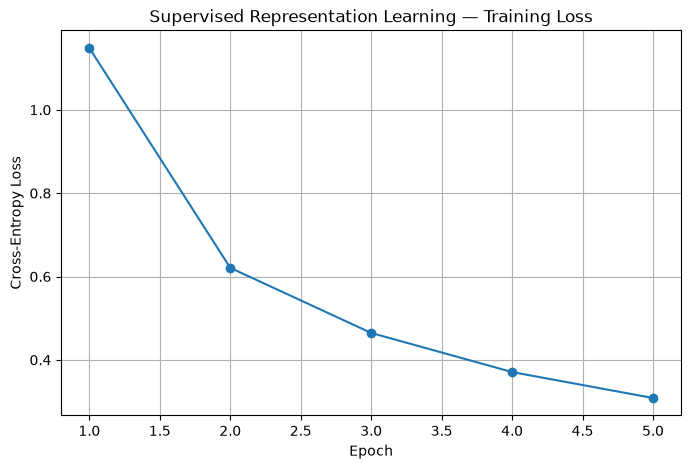

In [162]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Supervised Representation Learning — Training Loss")
plt.grid(True)
plt.show()

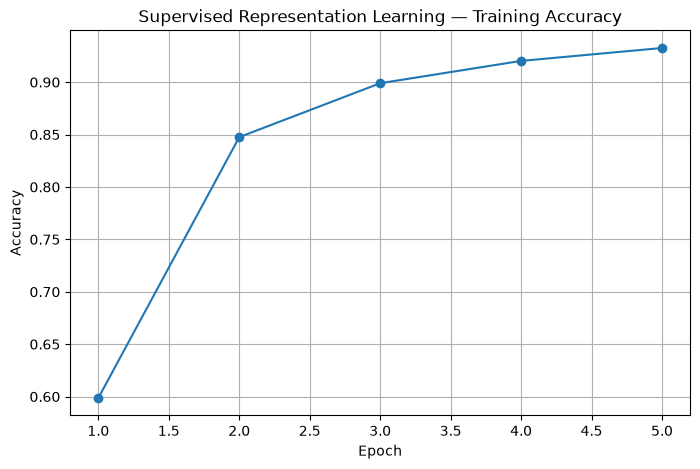

In [163]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Supervised Representation Learning — Training Accuracy")
plt.grid(True)
plt.show()

## Visualizing the Learned Representation

The most important experiment is to inspect the representation itself.

The model produces:

$$
z \in \mathbb{R}^{2}
$$

for every image.

We can plot these two dimensions.

If supervised learning has successfully learned class-discriminative features, samples of different digits should become more separable in the representation space.

This demonstrates an important concept:

$$
\boxed{
\text{Labels influence the geometry of the learned representation}
}
$$

In [164]:
model.eval()

all_representations = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)

        _, representations = model(images)

        all_representations.append(
            representations.cpu()
        )
        all_labels.append(labels)

all_representations = torch.cat(all_representations)
all_labels = torch.cat(all_labels)

print("Representation shape:", all_representations.shape)

Representation shape: torch.Size([10000, 2])


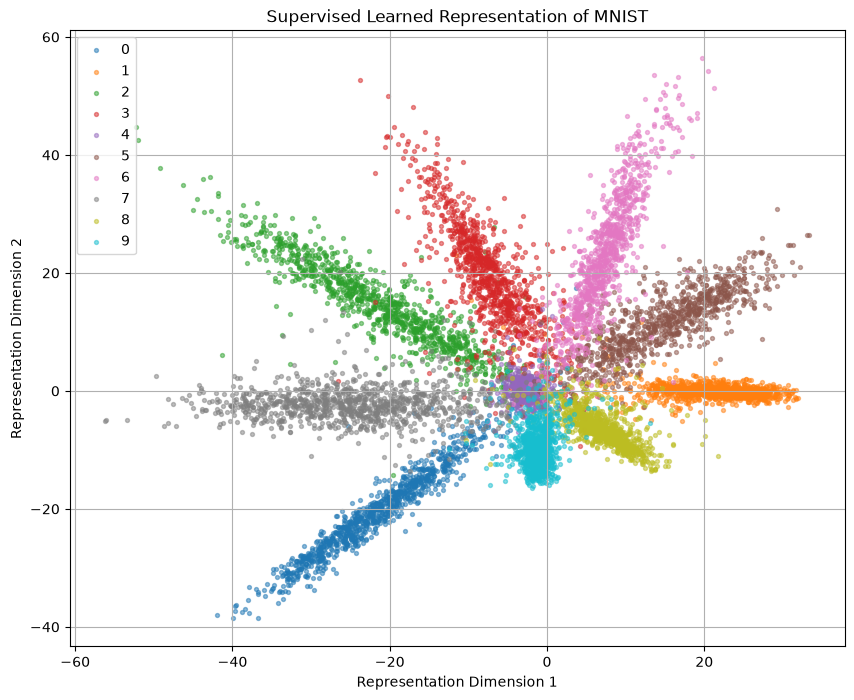

In [165]:
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = all_labels == digit

    plt.scatter(
        all_representations[mask, 0],
        all_representations[mask, 1],
        s=8,
        alpha=0.5,
        label=str(digit)
    )

plt.xlabel("Representation Dimension 1")
plt.ylabel("Representation Dimension 2")
plt.title("Supervised Learned Representation of MNIST")
plt.legend()
plt.grid(True)
plt.show()

## Interpreting the Visualization

The representation space is learned through the classification objective.

The model is not explicitly told:

> "Put digit 0 in this region and digit 1 in another region."

Instead, the classification loss creates gradients that encourage the representation and classifier together to produce correct predictions.

Therefore, class structure can emerge in the representation space.

This is an important distinction:

### Explicit Constraint

A metric-learning method may explicitly say:

$$
d(z_{same},z_{same}) \rightarrow 0
$$

and:

$$
d(z_{different},z_{different}) \rightarrow \text{large}
$$

### Supervised Classification

Classification instead optimizes:

$$
\mathcal{L}_{CE}
$$

and class separation may emerge as a consequence.

Thus:

$$
\boxed{
\text{Classification Can Learn Useful Representations}
}
$$

but its objective is not explicitly a distance-based representation objective.

# 4.11 Task-Specific vs Task-Agnostic Representations

Not all learned representations are designed for the same purpose.

## Task-Specific Representation

A representation is task-specific when it is learned primarily to solve a particular task.

Example:

$$
\text{Image}
\rightarrow
\text{Digit Classification Representation}
\rightarrow
\text{Digit Class}
$$

The representation is optimized according to the classification objective.

---

## More General Representation

A representation can also be learned with an objective that does not depend directly on one final downstream task.

Examples include:

- self-supervised learning
- contrastive learning
- masked prediction
- reconstruction
- multimodal pretraining

The goal is often to learn features that can later be reused.

For example:

$$
\text{Large Dataset}
\rightarrow
\text{Pretraining}
\rightarrow
\boxed{\text{General Representation}}
\rightarrow
\begin{cases}
\text{Classification}\\
\text{Retrieval}\\
\text{Detection}\\
\text{Clustering}
\end{cases}
$$

---

## Comparison

| Property | Task-Specific | More General |
|---|---|---|
| Main objective | Specific task | Broad reusable features |
| Labels | Often required | May not be required |
| Optimization | Directly task-oriented | Representation-oriented |
| Reusability | May be limited | Often higher |
| Example | Supervised classifier | Self-supervised encoder |

The distinction is not absolute.

A supervised representation can sometimes transfer well, and a self-supervised representation can still specialize after fine-tuning.

The key question is:

> **What objective caused the representation to be learned?**

# 4.12 Supervised Representation Learning — Exam Summary

## Definition

Supervised representation learning learns feature representations using labeled examples.

$$
z=f_\theta(x)
$$

and:

$$
\hat{y}=g_\phi(z)
$$

The representation is optimized indirectly through the supervised objective.

---

## Architecture

$$
x
\rightarrow
\boxed{\text{Feature Extractor}}
\rightarrow
z
\rightarrow
\boxed{\text{Prediction Head}}
\rightarrow
\hat{y}
$$

---

## Classification Objective

For classification:

$$
\mathcal{L}_{CE}
=
-\sum_{k=1}^{C}
y_k\log(\hat{p}_k)
$$

The gradients update both the classifier and feature extractor.

---

## Main Idea

The labels provide supervision that shapes the learned feature space.

$$
\boxed{
\text{Labels}
\rightarrow
\text{Learning Signal}
\rightarrow
\text{Representation}
}
$$

---

## Task-Specific Representation

A representation learned for one task may capture information especially useful for that task.

For example:

$$
\text{Digit Classification}
\rightarrow
\text{Digit-Discriminative Features}
$$

---

## Important Distinction

Supervised classification can produce useful representations, but it does not explicitly optimize pairwise distances between samples.

Contrastive and metric learning make similarity structure a more direct part of the objective.

---

## Exam Questions

### Q1. What is supervised representation learning?

It is the process of learning feature representations from labeled data where the representation is optimized through a supervised objective.

### Q2. What is the role of the feature extractor?

The feature extractor transforms the raw input into a learned representation:

$$
z=f_\theta(x)
$$

### Q3. How does classification influence the representation?

The classification loss generates gradients that update the feature extractor, causing it to learn features useful for predicting the target labels.

### Q4. Is supervised representation learning explicitly a metric-learning method?

No. Classification optimizes a prediction objective. Distance-based structure may emerge, but metric learning explicitly optimizes relationships between representations.

### Q5. What is the advantage of separating the feature extractor and prediction head?

The feature extractor can potentially be reused for another downstream task.

---

## Key Memory

$$
\boxed{
x
\rightarrow
\text{Feature Extractor}
\rightarrow
z
\rightarrow
\text{Task Head}
\rightarrow
\hat{y}
}
$$

and:

$$
\boxed{
\text{Supervised Objective Shapes the Representation}
}
$$

# 4.13 Self-Supervised Representation Learning

Self-supervised representation learning learns useful representations from unlabeled data by creating a learning signal from the data itself.

Instead of requiring manually provided labels:

$$
(x,y)
$$

the model primarily receives:

$$
x
$$

and constructs a supervisory signal from the structure of the data.

The central objective is:

$$
x
\rightarrow
\boxed{\text{Encoder}}
\rightarrow
z
$$

where $z$ is a representation that should capture useful information about the input.

---

## Why Self-Supervised Representation Learning?

Large datasets often contain enormous amounts of unlabeled data.

For example:

- millions of images
- large collections of text
- videos
- audio
- web documents

Manually labeling all of this data is expensive.

Self-supervised learning attempts to exploit the unlabeled data.

The general idea is:

$$
\text{Unlabeled Data}
\rightarrow
\text{Pretext / Pretraining Objective}
\rightarrow
\text{Learned Representation}
$$

The learned representation can then be reused for downstream tasks.

---

# Basic Architecture

A common architecture is:

$$
x
\rightarrow
\boxed{f_\theta}
\rightarrow
z
\rightarrow
\boxed{g_\phi}
\rightarrow
\text{Self-Supervised Objective}
$$

The encoder learns the representation:

$$
z=f_\theta(x)
$$

The additional component $g_\phi$ may be a prediction head used only during pretraining.

After pretraining, the prediction head can often be discarded.

The encoder can then be reused:

$$
\boxed{\text{Pretrained Encoder}}
\rightarrow
\begin{cases}
\text{Classification}\\
\text{Retrieval}\\
\text{Clustering}\\
\text{Detection}\\
\text{Similarity Search}
\end{cases}
$$

---

# Examples of Self-Supervised Objectives

Different methods create different learning signals.

## 1. Reconstruction

The model attempts to reconstruct an input:

$$
x
\rightarrow
z
\rightarrow
\hat{x}
$$

and minimizes:

$$
\mathcal{L}_{reconstruction}
=
d(x,\hat{x})
$$

Autoencoders are a simple example.

---

## 2. Masked Prediction

Part of the input is hidden.

The model must predict the missing information.

Conceptually:

$$
\text{Visible Information}
\rightarrow
\text{Representation}
\rightarrow
\text{Missing Information}
$$

This idea is widely used in modern language and vision models.

---

## 3. Contrastive Learning

Two related views of the same sample are encouraged to have similar representations.

$$
x
\rightarrow
x_1,x_2
$$

Then:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

The objective encourages:

$$
\operatorname{sim}(z_1,z_2)
\rightarrow
\text{large}
$$

while representations of unrelated samples are pushed apart.

---

# Key Idea

The representation is not learned simply because the model is self-supervised.

The pretraining objective determines what information the representation learns.

Therefore:

$$
\boxed{
\text{Self-Supervised Objective}
\rightarrow
\text{Learned Representation}
}
$$

# 4.13.1 Pretext Tasks

A **pretext task** is an artificially constructed task whose primary purpose is to force a model to learn useful representations.

The target does not necessarily correspond to the final downstream task.

For example, suppose we have an unlabeled image.

We can create:

$$
x
\rightarrow
\text{Transform}
\rightarrow
\tilde{x}
$$

and ask the model to predict some property of the transformation.

Possible pretext tasks include:

- predicting image rotation
- reconstructing masked regions
- predicting image transformations
- predicting missing patches
- solving jigsaw-like arrangements

The model learns representations while solving the artificial task.

---

## Representation Transfer

After pretraining:

$$
\text{Pretext Task}
\rightarrow
\boxed{\text{Pretrained Encoder}}
$$

The encoder can then be transferred to a downstream task:

$$
\boxed{\text{Pretrained Encoder}}
+
\text{Task Head}
\rightarrow
\text{Downstream Prediction}
$$

This is one of the foundations of modern representation learning.

In [166]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RotationRepresentationModel(nn.Module):
    def __init__(self, input_dim=784, representation_dim=64, num_tasks=4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, representation_dim)
        )

        self.task_head = nn.Linear(
            representation_dim,
            num_tasks
        )

    def forward(self, x):
        z = self.encoder(x)
        task_prediction = self.task_head(z)

        return task_prediction, z


model = RotationRepresentationModel()

sample = torch.randn(16, 784)

task_prediction, representation = model(sample)

print("Representation shape:", representation.shape)
print("Task prediction shape:", task_prediction.shape)

Representation shape: torch.Size([16, 64])
Task prediction shape: torch.Size([16, 4])


The architecture is:

$$
x
\rightarrow
\boxed{\text{Encoder}}
\rightarrow
z
\rightarrow
\boxed{\text{Pretext Head}}
\rightarrow
\text{Pretext Prediction}
$$

The pretext loss updates the encoder.

The important product of this process is not necessarily the pretext prediction itself.

The important product is:

$$
\boxed{z}
$$

which can later be reused as a representation.

# 4.13.2 Contrastive Representation Learning

Contrastive learning is one of the most important approaches to self-supervised representation learning.

The central idea is:

> Similar examples should have similar representations, while dissimilar examples should have different representations.

---

## Positive Pair

A positive pair consists of two related views.

For an image $x$:

$$
x_1 = t_1(x)
$$

$$
x_2 = t_2(x)
$$

where $t_1$ and $t_2$ are different transformations.

Then:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

The model encourages:

$$
\operatorname{sim}(z_1,z_2)
\rightarrow
\text{high}
$$

---

## Negative Samples

For unrelated samples:

$$
x_i \neq x_j
$$

the model generally encourages:

$$
\operatorname{sim}(z_i,z_j)
\rightarrow
\text{low}
$$

Therefore, contrastive learning shapes the geometry of the representation space.

---

## InfoNCE Objective

A common contrastive objective is:

$$
\mathcal{L}_i
=
-\log
\frac{
\exp(\operatorname{sim}(z_i,z_i^+)/\tau)
}{
\sum_j
\exp(\operatorname{sim}(z_i,z_j)/\tau)
}
$$

where:

- $z_i$ = anchor representation
- $z_i^+$ = positive representation
- $z_j$ = candidate representations
- $\tau$ = temperature parameter

The objective rewards high similarity with the positive sample and relatively low similarity with negatives.

---

## Why This Produces Useful Representations

The model cannot solve the contrastive objective effectively using arbitrary representations.

It must learn features that help distinguish:

$$
\text{What belongs together?}
$$

from:

$$
\text{What does not belong together?}
$$

Therefore:

$$
\boxed{
\text{Contrastive Objective}
\rightarrow
\text{Similarity-Aware Representation}
}
$$

## cosine similarity between representations:

In [167]:
import torch.nn.functional as F

z1 = torch.randn(8, 64)
z2 = torch.randn(8, 64)

z1 = F.normalize(z1, dim=1)
z2 = F.normalize(z2, dim=1)

similarities = torch.sum(z1 * z2, dim=1)

print("Cosine similarities:")
print(similarities)

Cosine similarities:
tensor([ 0.0288,  0.0562, -0.2058, -0.1078, -0.3190, -0.0298, -0.0849, -0.1202])


Because the vectors are normalized:

$$
\|z_i\|_2=1
$$

their dot product becomes cosine similarity:

$$
z_i^\top z_j
=
\operatorname{sim}(z_i,z_j)
$$

This makes normalized embeddings particularly convenient for contrastive learning.

The representation space can therefore be interpreted geometrically.

---

# Representation Learning Pipeline

A typical contrastive pipeline is:

$$
x
\rightarrow
\begin{cases}
t_1(x)\\
t_2(x)
\end{cases}
$$

then:

$$
\begin{cases}
t_1(x)\rightarrow f_\theta\rightarrow z_1\\
t_2(x)\rightarrow f_\theta\rightarrow z_2
\end{cases}
$$

followed by:

$$
(z_1,z_2)
\rightarrow
\text{Contrastive Loss}
$$

The encoder is updated using the contrastive objective.

---

# Important Concepts

### Augmentation

Creates different views of the same underlying sample.

### Positive Pair

Two representations that should be similar.

### Negative Pair

Representations that should be distinguishable.

### Encoder

Maps input into representation space.

$$
z=f_\theta(x)
$$

### Projection Head

A temporary network sometimes applied after the encoder during contrastive pretraining.

$$
h=f_\theta(x)
$$

$$
z=g_\phi(h)
$$

The projection representation $z$ is used for the contrastive objective, while the encoder representation $h$ may be used downstream.

This distinction is important in modern contrastive methods.

# 4.14 Feature Extractor vs Projection Head

Modern representation-learning systems often separate:

1. Encoder
2. Projection head

The encoder produces the main representation:

$$
h=f_\theta(x)
$$

The projection head transforms it:

$$
z=g_\phi(h)
$$

The contrastive objective operates on $z$.

Therefore:

$$
x
\rightarrow
\boxed{f_\theta}
\rightarrow
h
\rightarrow
\boxed{g_\phi}
\rightarrow
z
\rightarrow
\text{Contrastive Loss}
$$

---

## Why Use a Projection Head?

The representation needed for the pretraining objective may not be identical to the representation that is most useful for downstream tasks.

The projection head provides additional flexibility.

After pretraining, a common approach is:

$$
\boxed{h=f_\theta(x)}
$$

and the projection head can be discarded.

Thus:

$$
\text{Pretraining}
\rightarrow
\text{Encoder + Projection Head}
$$

but:

$$
\text{Downstream Task}
\rightarrow
\text{Encoder}
$$

This separation is a very important concept in contrastive representation learning.

In [168]:
class ContrastiveEncoder(nn.Module):
    def __init__(
        self,
        input_dim=784,
        hidden_dim=256,
        representation_dim=128,
        projection_dim=64
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, representation_dim)
        )

        self.projection_head = nn.Sequential(
            nn.Linear(representation_dim, 128),
            nn.ReLU(),
            nn.Linear(128, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)

        return h, z


model = ContrastiveEncoder()

x = torch.randn(32, 784)

h, z = model(x)

print("Encoder representation:", h.shape)
print("Projection representation:", z.shape)

Encoder representation: torch.Size([32, 128])
Projection representation: torch.Size([32, 64])


The important distinction is:

$$
\boxed{h=\text{Encoder Representation}}
$$

versus:

$$
\boxed{z=\text{Projection Representation}}
$$

During contrastive pretraining:

$$
z
\rightarrow
\text{Contrastive Loss}
$$

After pretraining, downstream tasks commonly use:

$$
h
\rightarrow
\text{Downstream Task}
$$

This distinction helps explain why a representation-learning architecture can contain more than one vector representation.

# 4.15 Self-Supervised Representation Learning — Comparison

Different self-supervised objectives encourage different properties.

| Method | Learning Signal | Main Representation Property |
|---|---|---|
| Reconstruction | Recover input | Information preservation |
| Masked prediction | Predict hidden content | Contextual information |
| Pretext classification | Predict artificial task | Task-relevant features |
| Contrastive learning | Match positive views | Similarity-aware features |
| Metric learning | Organize distances | Meaningful geometry |

---

## Supervised vs Self-Supervised Representation Learning

### Supervised

Uses manually provided labels:

$$
(x,y)
\rightarrow
\text{Model}
$$

### Self-Supervised

Constructs the learning signal from the data:

$$
x
\rightarrow
\text{Automatically Created Target}
\rightarrow
\text{Model}
$$

---

## Representation Reuse

A major benefit is:

$$
\text{Pretraining Dataset}
\rightarrow
\boxed{\text{Representation}}
\rightarrow
\text{Downstream Dataset}
$$

The downstream task may have relatively little labeled data.

This is one of the reasons representation learning is central to modern deep learning.

---

## Key Principle

The quality of a representation should ultimately be judged by whether it captures information useful for the intended downstream applications.

Therefore:

$$
\boxed{
\text{Good Representation}
=
\text{Useful Information for Future Tasks}
}
$$

# 4.16 Self-Supervised Representation Learning — Exam Summary

## Definition

Self-supervised representation learning learns representations from unlabeled data by constructing supervisory signals from the data itself.

$$
x
\rightarrow
\text{Self-Supervised Objective}
\rightarrow
z
$$

---

## Pretext Task

An artificially constructed task used to force a model to learn useful representations.

Examples:

- rotation prediction
- reconstruction
- masked prediction
- transformation prediction

---

## Contrastive Learning

Contrastive learning encourages:

$$
\text{Positive Pair}
\rightarrow
\text{Similar Representations}
$$

and:

$$
\text{Negative Pair}
\rightarrow
\text{Distinct Representations}
$$

A common objective is InfoNCE:

$$
\mathcal{L}_i
=
-\log
\frac{
\exp(\operatorname{sim}(z_i,z_i^+)/\tau)
}{
\sum_j
\exp(\operatorname{sim}(z_i,z_j)/\tau)
}
$$

---

## Encoder and Projection Head

Encoder:

$$
h=f_\theta(x)
$$

Projection head:

$$
z=g_\phi(h)
$$

During contrastive pretraining:

$$
z
\rightarrow
\text{Contrastive Loss}
$$

For downstream tasks:

$$
h
\rightarrow
\text{Task}
$$

---

## Main Advantage

Self-supervised learning can exploit large amounts of unlabeled data.

$$
\boxed{
\text{Unlabeled Data}
\rightarrow
\text{Pretraining}
\rightarrow
\text{Reusable Representation}
}
$$

---

## Exam Questions

### Q1. What is self-supervised representation learning?

Learning useful feature representations from unlabeled data by constructing supervisory signals from the data itself.

### Q2. What is a pretext task?

An artificially designed task used during pretraining to encourage useful representation learning.

### Q3. What is contrastive learning?

A representation-learning approach that encourages related samples to have similar representations and unrelated samples to have distinguishable representations.

### Q4. What is the role of a projection head?

It maps the encoder representation into a space where the self-supervised objective, especially a contrastive objective, can be applied.

### Q5. What is the difference between $h$ and $z$ in a contrastive architecture?

Usually:

$$
h=f_\theta(x)
$$

is the encoder representation, while:

$$
z=g_\phi(h)
$$

is the projection used by the contrastive objective.

### Q6. Why is self-supervised learning useful?

It allows models to learn from large amounts of unlabeled data and potentially produce representations that can be reused for multiple downstream tasks.

---

## Final Memory Map

$$
\boxed{
\text{Unlabeled Data}
\rightarrow
\text{Self-Supervised Objective}
\rightarrow
\text{Encoder}
\rightarrow
\text{Representation}
\rightarrow
\text{Downstream Tasks}
}
$$

# 4.17 Metric Learning

Metric Learning is a representation-learning approach in which a neural network learns an embedding space where **distance represents semantic similarity**.

The main objective is not simply to classify an input into a predefined class.

Instead, the model learns representations such that:

- similar samples are close together
- dissimilar samples are far apart

Let the encoder be:

$$
z = f_\theta(x)
$$

where:

- $x$ = input sample
- $f_\theta$ = neural network encoder
- $z$ = learned embedding

For two samples $x_i$ and $x_j$, their representations are:

$$
z_i = f_\theta(x_i)
$$

$$
z_j = f_\theta(x_j)
$$

Metric learning then defines a distance or similarity between:

$$
z_i \quad \text{and} \quad z_j
$$

The learning objective is to make this distance meaningful.

## 4.17.1 Motivation for Metric Learning

Traditional classification learns a decision function:

$$
x \rightarrow z \rightarrow y
$$

where $y$ is one of the known classes.

For example, an MNIST classifier may learn:

$$
x \rightarrow \{0,1,2,\ldots,9\}
$$

This works well when the set of classes is fixed.

However, many real-world problems require comparing samples rather than predicting one of a fixed number of classes.

Examples include:

- face recognition
- face verification
- image retrieval
- duplicate-image detection
- product matching
- signature verification
- speaker verification
- person re-identification
- few-shot learning

Suppose a face-recognition system has already learned representations for thousands of people.

When a new person appears, we may not want to retrain the entire classifier.

Instead, we can:

1. convert the image into an embedding
2. compare the embedding with stored embeddings
3. determine which stored representation is most similar

Therefore, metric learning provides a representation space that can support **comparison and retrieval**.

## 4.17.2 Desired Embedding Space

A good metric-learning model should organize the embedding space according to semantic similarity.

For samples from the same class:

$$
d(z_i,z_j) \rightarrow 0
$$

For samples from different classes:

$$
d(z_i,z_j) \rightarrow \text{large}
$$

Conceptually:

```text
                 Embedding Space

        ● ● ●
      ● ● ● ●                 ▲ ▲
       ● ● ●                ▲ ▲ ▲
                           ▲ ▲ ▲

                 ■ ■ ■
               ■ ■ ■ ■
                ■ ■ ■

        Same-class samples form clusters
        Different classes remain separated

The exact shape of the clusters is not predetermined.

The neural network learns the geometry from the training objective.


---


## 4.17.3 Classification vs Metric Learning

### Classification

A classification model learns:

$$
f_\theta(x) \rightarrow y
$$

and is commonly trained using Cross-Entropy Loss.

The model learns a decision boundary between classes.

### Metric Learning

A metric-learning model learns:

$$
f_\theta(x) \rightarrow z
$$

and optimizes relationships between embeddings.

The central concept becomes:

$$
d(f_\theta(x_i), f_\theta(x_j))
$$

rather than only the predicted class.

| Property | Classification | Metric Learning |
|---|---|---|
| Main goal | Predict class | Learn similarity |
| Output | Class probabilities | Embedding vector |
| Main geometry | Decision boundaries | Embedding distances |
| Typical loss | Cross-Entropy | Contrastive / Triplet |
| New classes | Usually requires retraining | Can often compare embeddings directly |
| Retrieval | Not the primary objective | Natural application |
| Verification | Not the primary objective | Natural application |

Metric learning and classification are not mutually exclusive.

A learned embedding can later be used for classification, retrieval, clustering, or verification.

## 4.17.4 Distance and Similarity Functions

Metric learning requires a function for comparing embeddings.

### Euclidean Distance

For two embeddings:

$$
z_i,z_j \in \mathbb{R}^d
$$

Euclidean distance is:

$$
d(z_i,z_j)
=
\sqrt{
\sum_{k=1}^{d}
(z_{ik}-z_{jk})^2
}
$$

A smaller value means that the embeddings are closer.

### Squared Euclidean Distance

The squared form is:

$$
d^2(z_i,z_j)
=
\sum_{k=1}^{d}
(z_{ik}-z_{jk})^2
$$

It avoids the square root and is frequently used in loss functions.

### Cosine Similarity

Cosine similarity is:

$$
\operatorname{sim}(z_i,z_j)
=
\frac{z_i^Tz_j}
{\|z_i\|_2\|z_j\|_2}
$$

It measures the angle between the vectors.

For normalized embeddings:

$$
\|z_i\|_2 = \|z_j\|_2 = 1
$$

cosine similarity becomes especially convenient.

## Distance Functions

In [169]:
import torch
import torch.nn.functional as F

z1 = torch.tensor([[1.0, 2.0, 3.0]])
z2 = torch.tensor([[1.2, 2.1, 2.8]])

euclidean_distance = torch.norm(z1 - z2, p=2, dim=1)

squared_euclidean_distance = torch.sum((z1 - z2) ** 2, dim=1)

cosine_similarity = F.cosine_similarity(z1, z2, dim=1)

print("Euclidean distance:", euclidean_distance.item())
print("Squared Euclidean distance:", squared_euclidean_distance.item())
print("Cosine similarity:", cosine_similarity.item())

Euclidean distance: 0.30000004172325134
Squared Euclidean distance: 0.09000001847743988
Cosine similarity: 0.9968122243881226


## 4.17.5 L2 Normalization of Embeddings

Metric-learning systems frequently normalize the embedding vector.

The normalized embedding is:

$$
\hat{z}
=
\frac{z}{\|z\|_2}
$$

After normalization:

$$
\|\hat{z}\|_2 = 1
$$

This means that all embeddings have the same magnitude.

The comparison then depends primarily on their direction.

For normalized embeddings:

$$
\|\hat{z}_i-\hat{z}_j\|_2^2
=
2-2\hat{z}_i^T\hat{z}_j
$$

Since:

$$
\hat{z}_i^T\hat{z}_j
=
\cos(\theta)
$$

we obtain:

$$
\|\hat{z}_i-\hat{z}_j\|_2^2
=
2-2\cos(\theta)
$$

Therefore, cosine similarity and Euclidean distance become closely related on the unit hypersphere.

## L2 Normalization

In [170]:
z = torch.tensor([
    [3.0, 4.0],
    [1.0, 2.0],
    [5.0, 12.0]
])

z_normalized = F.normalize(z, p=2, dim=1)

print("Original embeddings:")
print(z)

print("\nNormalized embeddings:")
print(z_normalized)

print("\nL2 norms after normalization:")
print(torch.norm(z_normalized, p=2, dim=1))

Original embeddings:
tensor([[ 3.,  4.],
        [ 1.,  2.],
        [ 5., 12.]])

Normalized embeddings:
tensor([[0.6000, 0.8000],
        [0.4472, 0.8944],
        [0.3846, 0.9231]])

L2 norms after normalization:
tensor([1.0000, 1.0000, 1.0000])


## 4.17.6 Pair-Based Metric Learning

A common metric-learning setup uses pairs of samples.

A training pair is:

$$
(x_i,x_j,y_{ij})
$$

where:

$$
y_{ij}
=
\begin{cases}
1 & \text{if } x_i \text{ and } x_j \text{ are similar}\\
0 & \text{if } x_i \text{ and } x_j \text{ are dissimilar}
\end{cases}
$$

The encoder produces:

$$
z_i=f_\theta(x_i)
$$

and:

$$
z_j=f_\theta(x_j)
$$

The distance is:

$$
d_{ij}=d(z_i,z_j)
$$

The model is trained so that positive pairs have small distances and negative pairs have sufficiently large distances.

Example:

```text
Positive pair:

      Image A                    Image B
         ↓                          ↓
      Encoder                    Encoder
         ↓                          ↓
        z₁                          z₂
          \                        /
           \____ small distance __/


Negative pair:

      Image A                    Image C
         ↓                          ↓
      Encoder                    Encoder
         ↓                          ↓
        z₁                          z₃
          \                        /
           \___ large distance ___/


---


## 4.17.7 Triplet-Based Metric Learning

Another important formulation uses three samples:

- **Anchor** — reference sample
- **Positive** — sample similar to the anchor
- **Negative** — sample dissimilar to the anchor

We denote them as:

$$
x_a = \text{anchor}
$$

$$
x_p = \text{positive}
$$

$$
x_n = \text{negative}
$$

The encoder produces:

$$
z_a=f_\theta(x_a)
$$

$$
z_p=f_\theta(x_p)
$$

$$
z_n=f_\theta(x_n)
$$

The desired relationship is:

$$
d(z_a,z_p) < d(z_a,z_n)
$$

A margin can be introduced:

$$
d(z_a,z_p)+m < d(z_a,z_n)
$$

where $m>0$ is the margin.

This formulation leads to **Triplet Loss**, which will be studied in detail later.

## 4.17.8 Pair-Based vs Triplet-Based Learning

| Method | Training Unit | Main Idea |
|---|---|---|
| Pair-based | Two samples | Similar pairs close, dissimilar pairs apart |
| Triplet-based | Three samples | Positive closer than negative |
| Contrastive learning | Positive + negative relationships | Learn semantic representations through comparisons |
| Classification | One sample + label | Learn decision boundaries |

The major difference is what relationship the loss explicitly enforces.

Pair-based learning asks:

> "Should these two samples be close or far?"

Triplet-based learning asks:

> "Is the positive sample closer to the anchor than the negative sample?"

## 4.17.9 Applications of Metric Learning

Metric learning is particularly useful when similarity between samples is more important than fixed class prediction.

### 1. Face Verification

Determine whether two face images belong to the same person.

$$
d(z_1,z_2)<\tau
\Rightarrow
\text{same identity}
$$

### 2. Face Recognition

Compare a query embedding with stored identity embeddings.

### 3. Image Retrieval

Given a query image:

$$
x_q \rightarrow z_q
$$

retrieve images whose embeddings have the smallest distances to $z_q$.

### 4. Duplicate Detection

Images or documents with similar embeddings can be identified as potential duplicates.

### 5. Product Matching

Products photographed from different viewpoints can be mapped to nearby embeddings.

### 6. Few-Shot Learning

A model can learn a useful embedding space from many training examples and then compare new examples using only a few labeled samples.

### 7. Person Re-Identification

Images of the same person captured by different cameras can be mapped close together.

The common principle is:

$$
\text{input}
\rightarrow
\text{embedding}
\rightarrow
\text{distance/similarity}
\rightarrow
\text{decision}
$$

## Simple Embedding Network

In [171]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EmbeddingNetwork(nn.Module):
    def __init__(self, input_dim=784, embedding_dim=32):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim)
        )

    def forward(self, x):
        x = self.network(x)
        x = F.normalize(x, p=2, dim=1)
        return x


model = EmbeddingNetwork(
    input_dim=784,
    embedding_dim=32
)

dummy_input = torch.randn(8, 784)

embeddings = model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Embedding shape:", embeddings.shape)
print("Embedding norms:")
print(torch.norm(embeddings, p=2, dim=1))

Input shape: torch.Size([8, 784])
Embedding shape: torch.Size([8, 32])
Embedding norms:
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<LinalgVectorNormBackward0>)


## 4.17.10 Visualizing Embeddings

Although real metric-learning models may use embeddings with dimensions such as:

$$
128,\;256,\;512
$$

or higher, we can visualize a two-dimensional embedding space directly.

For higher-dimensional embeddings, dimensionality-reduction methods such as PCA or t-SNE can be used for visualization.

A useful visualization should reveal whether samples belonging to the same semantic category form coherent groups.

However, visualization alone does not prove that an embedding is good.

A proper evaluation should also measure retrieval, verification, clustering, or downstream performance.

## Simulated Metric-Learning Geometry

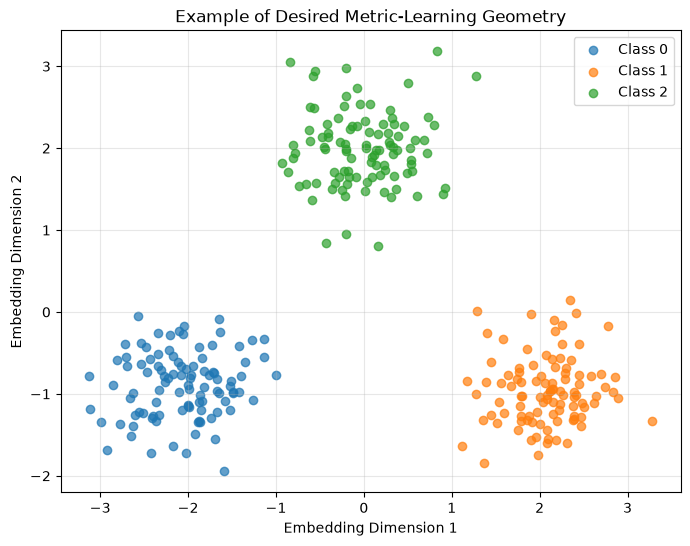

In [172]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

n_points = 100

class_0 = torch.randn(n_points, 2) * 0.45 + torch.tensor([-2.0, -1.0])
class_1 = torch.randn(n_points, 2) * 0.45 + torch.tensor([2.0, -1.0])
class_2 = torch.randn(n_points, 2) * 0.45 + torch.tensor([0.0, 2.0])

plt.figure(figsize=(8, 6))

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    label="Class 0",
    alpha=0.7
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    label="Class 1",
    alpha=0.7
)

plt.scatter(
    class_2[:, 0],
    class_2[:, 1],
    label="Class 2",
    alpha=0.7
)

plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.title("Example of Desired Metric-Learning Geometry")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4.17.11 Metric Learning Pipeline

A typical metric-learning system follows:

$$
x
\rightarrow
f_\theta(x)
\rightarrow
z
\rightarrow
d(z_i,z_j)
\rightarrow
\text{metric-learning loss}
$$

During training:

1. Input samples are selected.
2. The encoder generates embeddings.
3. Distances or similarities are calculated.
4. A metric-learning loss evaluates the relationships.
5. Backpropagation updates the encoder.
6. The embedding geometry gradually becomes more meaningful.

After training:

$$
x_{\text{query}}
\rightarrow
z_{\text{query}}
$$

The query embedding can then be compared with stored embeddings.

This allows the same learned representation to support:

- nearest-neighbor search
- image retrieval
- verification
- clustering
- classification
- few-shot learning

## 4.17.12 Important Concept: The Embedding Is the Product

In ordinary classification, the final class prediction is usually the primary output.

In metric learning, the embedding itself is extremely important.

The model attempts to learn:

$$
f_\theta:
\mathcal{X}
\rightarrow
\mathcal{Z}
$$

where $\mathcal{Z}$ is the learned embedding space.

The quality of the model is therefore strongly related to the geometry of $\mathcal{Z}$.

A good embedding should ideally satisfy:

$$
\text{semantic similarity}
\approx
\text{embedding similarity}
$$

This is the central idea behind metric learning.

## 4.17.13 Metric Learning — Exam Summary

### Definition

Metric learning learns an embedding space in which distances or similarities between representations correspond to semantic relationships.

### Core equation

$$
z=f_\theta(x)
$$

### Main objective

Similar samples:

$$
d(z_i,z_j)\downarrow
$$

Dissimilar samples:

$$
d(z_i,z_j)\uparrow
$$

### Important distance/similarity measures

- Euclidean distance
- Squared Euclidean distance
- Cosine similarity

### Pair-based learning

Uses:

$$
(x_i,x_j,y_{ij})
$$

to learn whether samples should be close or far apart.

### Triplet-based learning

Uses:

$$
(x_a,x_p,x_n)
$$

where:

- $x_a$ = anchor
- $x_p$ = positive
- $x_n$ = negative

and aims for:

$$
d(z_a,z_p)+m < d(z_a,z_n)
$$

### Applications

- Face recognition
- Face verification
- Image retrieval
- Duplicate detection
- Product matching
- Few-shot learning
- Person re-identification

### Key exam statement

> Metric learning does not merely learn class boundaries; it learns an embedding geometry in which semantic similarity can be measured using distances or similarities.

# 4.18 Siamese Networks

A **Siamese Network** is a neural network architecture designed to learn whether two inputs are similar or dissimilar.

The key idea is that the two inputs are processed by the **same encoder with shared parameters**.

For two inputs $x_1$ and $x_2$:

$$
z_1 = f_\theta(x_1)
$$

$$
z_2 = f_\theta(x_2)
$$

where:

- $f_\theta$ is the shared encoder
- $z_1$ and $z_2$ are the learned embeddings

The embeddings are then compared using a distance or similarity function.

For example:

$$
d(z_1,z_2)
=
\|z_1-z_2\|_2
$$

The network is trained so that:

- similar inputs produce similar embeddings
- dissimilar inputs produce different embeddings

The most important architectural property is:

$$
\boxed{\text{Shared Encoder}}
$$

Both branches use exactly the same weights.

## 4.18.1 Siamese Network Architecture

A Siamese Network can be represented as:

```text
                 Input 1
                    |
                    v
              +-----------+
              |  Encoder  |
              | f_theta   |
              +-----------+
                    |
                    v
                   z1
                    \
                     \
                      v
                   Distance
                      ^
                     /
                    /
                   z2
                    ^
                    |
              +-----------+
              |  Encoder  |
              | f_theta   |
              +-----------+
                    ^
                    |
                 Input 2

The two encoders are not two independently trained networks.

They are the same network:

$$ f_{\theta_1}=f_{\theta_2}=f_\theta $$

Therefore, both inputs are mapped into the same embedding space.

This weight sharing is what makes the architecture Siamese.



## 4.18.2 Why Share Weights?

Suppose the first branch had parameters $\theta_1$ and the second branch had parameters $\theta_2$.

Then:

$$
z_1=f_{\theta_1}(x_1)
$$

$$
z_2=f_{\theta_2}(x_2)
$$

The two branches could learn different feature representations.

That would make direct comparison less meaningful.

A Siamese Network instead enforces:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

The same transformation is applied to both samples.

Therefore, embeddings are directly comparable.

### Important exam point

> A Siamese Network uses two or more branches with shared parameters to learn comparable representations of different inputs.

## 4.18.3 Constructing MNIST Pairs

For this practical experiment, we will create pairs of MNIST images.

A pair can be:

### Positive pair

Both images belong to the same class.

Example:

$$
(3,3)
$$

Label:

$$
y=1
$$

### Negative pair

The images belong to different classes.

Example:

$$
(3,8)
$$

Label:

$$
y=0
$$

Our training objective is therefore:

$$
\text{same class}
\rightarrow
\text{similar embeddings}
$$

and:

$$
\text{different class}
\rightarrow
\text{different embeddings}
$$

This converts ordinary MNIST classification data into a metric-learning dataset.

## Imports and Dataset

In [173]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## Load MNIST

In [174]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


## 4.18.4 Pair Dataset

We now construct a custom dataset that returns:

$$
(x_1,x_2,y)
$$

where:

- $x_1$ = first image
- $x_2$ = second image
- $y=1$ for a positive pair
- $y=0$ for a negative pair

We generate the pair dynamically so that the model sees different combinations during training.

For a positive pair, the second image is selected from the same class.

For a negative pair, the second image is selected from a different class.

## Siamese Pair Dataset

In [175]:
class SiameseMNISTDataset(Dataset):
    def __init__(self, dataset, length=None):
        self.dataset = dataset
        self.length = length if length is not None else len(dataset)

        self.labels = torch.tensor([
            dataset[i][1] for i in range(len(dataset))
        ])

        self.class_indices = {
            digit: torch.where(self.labels == digit)[0].tolist()
            for digit in range(10)
        }

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        index1 = random.randrange(len(self.dataset))
        image1, label1 = self.dataset[index1]

        # Positive pair
        if random.random() < 0.5:
            index2 = random.choice(self.class_indices[int(label1)])
            image2, label2 = self.dataset[index2]

            pair_label = 1.0

        # Negative pair
        else:
            negative_label = random.choice([
                digit for digit in range(10)
                if digit != int(label1)
            ])

            index2 = random.choice(
                self.class_indices[negative_label]
            )

            image2, label2 = self.dataset[index2]

            pair_label = 0.0

        return image1, image2, torch.tensor(pair_label)

## Create DataLoaders

In [176]:
train_pairs = SiameseMNISTDataset(
    train_dataset,
    length=30000
)

test_pairs = SiameseMNISTDataset(
    test_dataset,
    length=5000
)

train_loader = DataLoader(
    train_pairs,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_pairs,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training pairs:", len(train_pairs))
print("Test pairs:", len(test_pairs))

Training pairs: 30000
Test pairs: 5000


## 4.18.5 Visualizing Positive and Negative Pairs

Before training the network, it is useful to verify that our pair-generation process works correctly.

We should see:

- positive pairs containing the same digit
- negative pairs containing different digits

The pair label is not the digit identity.

Instead:

$$
y=1
\Rightarrow
\text{similar pair}
$$

$$
y=0
\Rightarrow
\text{dissimilar pair}
$$

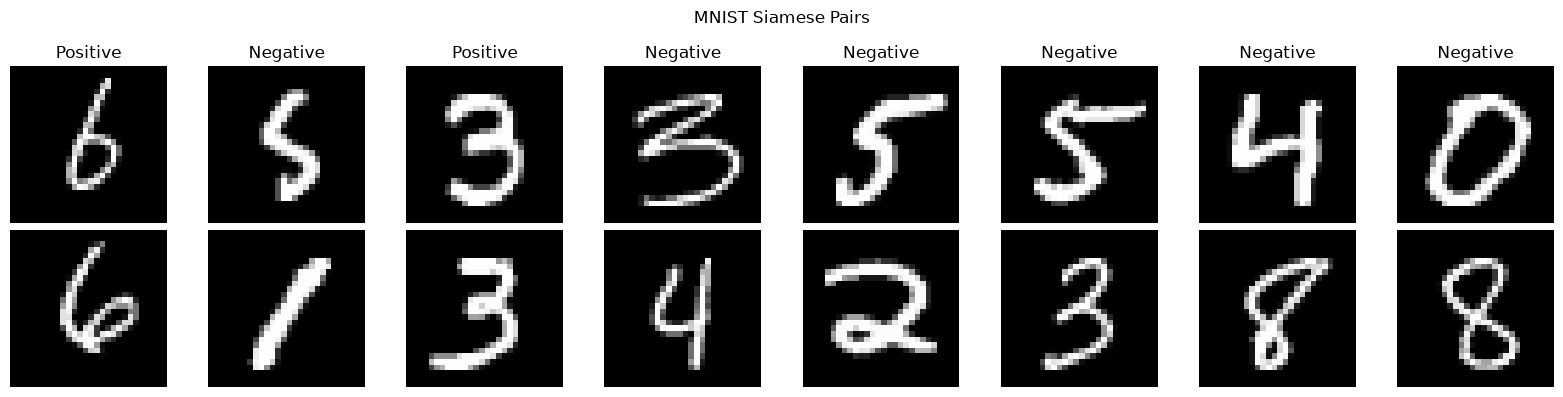

In [177]:
def show_pairs(dataset, num_pairs=8):
    fig, axes = plt.subplots(
        2,
        num_pairs,
        figsize=(16, 4)
    )

    for i in range(num_pairs):
        image1, image2, pair_label = dataset[i]

        axes[0, i].imshow(
            image1.squeeze(),
            cmap="gray"
        )
        axes[1, i].imshow(
            image2.squeeze(),
            cmap="gray"
        )

        axes[0, i].axis("off")
        axes[1, i].axis("off")

        pair_type = "Positive" if pair_label.item() == 1 else "Negative"

        axes[0, i].set_title(pair_type)

    axes[0, 0].set_ylabel("Image 1")
    axes[1, 0].set_ylabel("Image 2")

    plt.suptitle("MNIST Siamese Pairs")
    plt.tight_layout()
    plt.show()


show_pairs(train_pairs)

## 4.18.6 Building the Shared Encoder

The encoder converts an image into a compact embedding.

For MNIST:

$$
28\times28=784
$$

input values are flattened into:

$$
x\in\mathbb{R}^{784}
$$

The encoder produces:

$$
z\in\mathbb{R}^{32}
$$

Thus:

$$
784 \rightarrow 256 \rightarrow 128 \rightarrow 32
$$

The final representation is L2-normalized:

$$
\hat{z}
=
\frac{z}{\|z\|_2}
$$

This makes the embeddings easier to compare using Euclidean distance or cosine similarity.

In [178]:
class SharedEncoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim)
        )

    def forward(self, x):
        embedding = self.network(x)

        embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )

        return embedding

## 4.18.7 Complete Siamese Network

The Siamese Network contains one shared encoder.

The same encoder is applied to both images:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

Then the embeddings are compared.

For this experiment we use Euclidean distance:

$$
d(z_1,z_2)
=
\|z_1-z_2\|_2
$$

The network itself does not need separate parameters for the two branches.

The same encoder object is called twice.

In [179]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()

        self.encoder = SharedEncoder(
            embedding_dim=embedding_dim
        )

    def forward(self, image1, image2):
        embedding1 = self.encoder(image1)
        embedding2 = self.encoder(image2)

        distance = torch.norm(
            embedding1 - embedding2,
            p=2,
            dim=1
        )

        return embedding1, embedding2, distance


model = SiameseNetwork(
    embedding_dim=32
).to(device)

print(model)

SiameseNetwork(
  (encoder): SharedEncoder(
    (network): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=256, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Linear(in_features=128, out_features=32, bias=True)
    )
  )
)


## 4.18.8 Checking Weight Sharing

The most important architectural property of the Siamese Network is that both inputs use:

$$
\boxed{\text{the same encoder}}
$$

There is only one set of encoder parameters.

Therefore, when gradients are computed from both branches, both branches update the same parameters.

This allows the network to learn a common embedding space.

In [180]:
encoder_parameter_count = sum(
    parameter.numel()
    for parameter in model.encoder.parameters()
)

print("Shared encoder parameters:", encoder_parameter_count)

print(
    "\nNumber of encoder parameter tensors:",
    len(list(model.encoder.parameters()))
)

Shared encoder parameters: 237984

Number of encoder parameter tensors: 6


## 4.18.9 Contrastive Training Objective

For Siamese Networks, a standard approach is **Contrastive Loss**.

The loss distinguishes between:

- positive pairs
- negative pairs

For a positive pair, the objective is to minimize:

$$
d(z_1,z_2)
$$

For a negative pair, the objective is to push the embeddings apart until they reach at least a margin $m$.

Conceptually:

$$
\text{positive}
\rightarrow
d\downarrow
$$

$$
\text{negative}
\rightarrow
d\uparrow
$$

The detailed mathematical derivation of Contrastive Loss will be covered in:

**4.19 Contrastive Loss**

For the current section, we use it as the training mechanism for the Siamese Network.

In [181]:
def contrastive_loss(distance, pair_label, margin=1.0):
    positive_loss = pair_label * distance.pow(2)

    negative_loss = (
        (1.0 - pair_label)
        * torch.clamp(margin - distance, min=0.0).pow(2)
    )

    loss = positive_loss + negative_loss

    return loss.mean()

## 4.18.10 Training the Siamese Network

During each training step:

1. Load a pair of images.
2. Pass both images through the shared encoder.
3. Obtain two embeddings.
4. Compute their distance.
5. Calculate Contrastive Loss.
6. Backpropagate the loss.
7. Update the shared encoder.

The complete process is:

$$
(x_1,x_2)
\rightarrow
(f_\theta(x_1),f_\theta(x_2))
\rightarrow
(z_1,z_2)
\rightarrow
d(z_1,z_2)
\rightarrow
L
$$

The encoder gradually learns an embedding space in which pair relationships become meaningful.

In [182]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 5

train_losses = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    for image1, image2, pair_label in train_loader:
        image1 = image1.to(device, non_blocking=True)
        image2 = image2.to(device, non_blocking=True)
        pair_label = pair_label.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        _, _, distance = model(
            image1,
            image2
        )

        loss = contrastive_loss(
            distance,
            pair_label,
            margin=1.0
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.0879
Epoch [2/5] Loss: 0.0444
Epoch [3/5] Loss: 0.0297
Epoch [4/5] Loss: 0.0248
Epoch [5/5] Loss: 0.0208


## 4.18.11 Training Loss Visualization

The training loss should generally decrease as the encoder learns a more useful embedding space.

However, loss alone does not fully describe representation quality.

We should also examine:

- positive-pair distances
- negative-pair distances
- verification accuracy
- embedding visualization
- retrieval performance

This is an important principle in representation learning:

> The quality of an embedding should be evaluated through the behavior it enables, not only through its training loss.

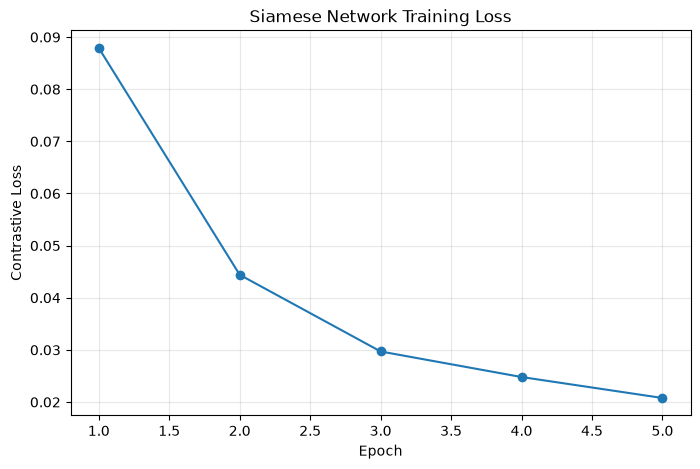

In [183]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Siamese Network Training Loss")
plt.grid(alpha=0.3)

plt.show()

## 4.18.12 Evaluating Pair Distances

After training, we expect:

$$
\mathbb{E}[d(z_1,z_2)\mid y=1]
<
\mathbb{E}[d(z_1,z_2)\mid y=0]
$$

In other words:

> Positive pairs should have smaller distances than negative pairs.

This is a direct test of whether the learned embedding geometry matches our objective.

## Positive vs Negative Distances

In [184]:
model.eval()

positive_distances = []
negative_distances = []

with torch.no_grad():
    for image1, image2, pair_label in test_loader:
        image1 = image1.to(device)
        image2 = image2.to(device)

        _, _, distance = model(
            image1,
            image2
        )

        distance = distance.cpu()
        pair_label = pair_label.cpu()

        positive_distances.extend(
            distance[pair_label == 1].tolist()
        )

        negative_distances.extend(
            distance[pair_label == 0].tolist()
        )

print(
    "Mean positive distance:",
    np.mean(positive_distances)
)

print(
    "Mean negative distance:",
    np.mean(negative_distances)
)

Mean positive distance: 0.10875260729883961
Mean negative distance: 1.041478934359309


## Distance Distribution

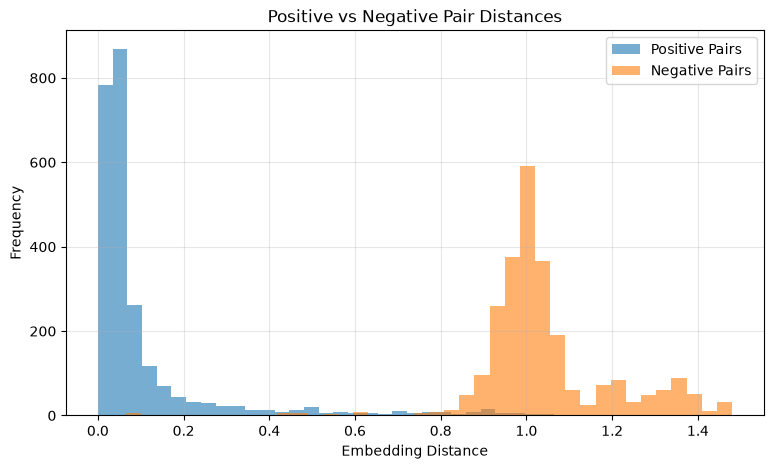

In [185]:
plt.figure(figsize=(9, 5))

plt.hist(
    positive_distances,
    bins=40,
    alpha=0.6,
    label="Positive Pairs"
)

plt.hist(
    negative_distances,
    bins=40,
    alpha=0.6,
    label="Negative Pairs"
)

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Positive vs Negative Pair Distances")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4.18.13 Siamese Verification

We can convert the learned distance into a verification decision.

Choose a threshold:

$$
\tau
$$

Then:

$$
d(z_1,z_2)<\tau
\Rightarrow
\text{similar}
$$

and:

$$
d(z_1,z_2)\geq\tau
\Rightarrow
\text{dissimilar}
$$

The threshold controls the trade-off between false positives and false negatives.

This is the same fundamental idea used in verification problems such as:

- face verification
- signature verification
- speaker verification

## Simple Verification Accuracy

In [186]:
threshold = 0.8

positive_correct = np.array(positive_distances) < threshold
negative_correct = np.array(negative_distances) >= threshold

verification_accuracy = (
    positive_correct.sum() + negative_correct.sum()
) / (
    len(positive_correct) + len(negative_correct)
)

print(
    f"Verification Accuracy: "
    f"{verification_accuracy * 100:.2f}%"
)

Verification Accuracy: 97.74%


## 4.18.14 Important Limitation of a Fixed Threshold

A threshold such as:

$$
\tau=0.8
$$

is only a simple demonstration.

In a real metric-learning system, the threshold should normally be selected using validation data.

The appropriate threshold depends on:

- embedding architecture
- training objective
- distance metric
- data distribution
- application requirements
- desired false-positive / false-negative trade-off

Therefore, a threshold should not simply be assumed to generalize across different datasets and models.

## 4.18.15 Siamese Networks — Key Advantages

### 1. Shared Representation

Both inputs are transformed by the same encoder.

### 2. Direct Similarity Learning

The network learns relationships between samples.

### 3. Flexible Comparison

The trained encoder can compare samples that were not explicitly seen as pairs during training.

### 4. Useful for Verification

The architecture naturally supports:

$$
\text{same vs different}
$$

decisions.

### 5. Useful for Retrieval

Embeddings can be stored and compared with query embeddings.

### 6. Suitable for Few-Shot Settings

Once a useful embedding space is learned, new examples can often be handled through similarity rather than retraining a large classifier.

## 4.18.16 Siamese Networks — Limitations

### 1. Pair Construction

The number of possible pairs can become very large.

For $N$ samples, the number of unique unordered pairs is:

$$
\frac{N(N-1)}{2}
$$

Therefore, efficient pair sampling becomes important.

### 2. Negative Selection

Not all negative pairs are equally useful.

Very easy negatives may provide little learning signal.

This motivates techniques such as:

- hard-negative mining
- semi-hard negative mining

### 3. Threshold Selection

Verification requires an appropriate decision threshold.

### 4. Training Objective

The quality of the learned embedding depends strongly on the metric-learning loss.

Different losses can produce substantially different embedding geometries.

### 5. Computational Cost

Large-scale pair or triplet datasets can become expensive.

These issues motivate more advanced metric-learning methods.

# 4.18.17 Siamese Networks — Exam Summary

### Definition

A Siamese Network is an architecture containing multiple branches that share the same parameters and learn comparable representations of different inputs.

### Core equations

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

### Distance

A common choice is:

$$
d(z_1,z_2)
=
\|z_1-z_2\|_2
$$

### Positive pair

$$
y=1
$$

Similar samples should have:

$$
d(z_1,z_2)\downarrow
$$

### Negative pair

$$
y=0
$$

Dissimilar samples should have:

$$
d(z_1,z_2)\uparrow
$$

up to a specified margin.

### Most important architectural property

$$
\boxed{\text{The branches share weights}}
$$

### Applications

- Face verification
- Signature verification
- Image similarity
- Image retrieval
- Duplicate detection
- Product matching
- Few-shot learning

### Key exam statement

> A Siamese Network learns a common embedding space by passing multiple inputs through shared-weight encoder branches and optimizing the distance between their representations.

### Relationship to the next section

Siamese Network:

$$
\boxed{\text{Architecture}}
$$

Contrastive Loss:

$$
\boxed{\text{Learning Objective}}
$$

Therefore:

$$
\text{Siamese Network}
+
\text{Contrastive Loss}
\rightarrow
\text{Pair-based Metric Learning}
$$

# 4.19 Contrastive Loss

**Contrastive Loss** is a metric-learning objective that trains a neural network to distinguish between similar and dissimilar pairs.

Given two inputs:

$$
(x_1,x_2)
$$

the shared encoder produces:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

Their distance is:

$$
D(z_1,z_2)
=
\|z_1-z_2\|_2
$$

The pair has a binary relationship label:

$$
y=
\begin{cases}
1 & \text{similar pair}\\
0 & \text{dissimilar pair}
\end{cases}
$$

The objective is:

$$
\boxed{
\text{Similar pairs should be close, while dissimilar pairs should be sufficiently far apart.}
}
$$

## 4.19.1 Intuition Behind Contrastive Loss

Consider two situations.

### Positive Pair

Suppose:

$$
y=1
$$

The two samples are similar.

For example:

$$
(3,3)
$$

The model should minimize:

$$
D(z_1,z_2)
$$

Therefore:

$$
D(z_1,z_2)\rightarrow0
$$

### Negative Pair

Suppose:

$$
y=0
$$

The samples are dissimilar.

For example:

$$
(3,8)
$$

The model should push their embeddings apart.

However, we do not necessarily need the distance to become infinitely large.

Instead, we define a **margin**:

$$
m>0
$$

and require the negative pair to have approximately:

$$
D(z_1,z_2)\geq m
$$

This prevents the model from wasting capacity pushing already-separated negative pairs arbitrarily far apart.

## 4.19.2 Deriving Contrastive Loss

For a positive pair:

$$
y=1
$$

we want:

$$
L=D^2
$$

because minimizing this forces the embeddings together.

For a negative pair:

$$
y=0
$$

we want to penalize the pair only when:

$$
D<m
$$

Therefore:

$$
L=
\max(0,m-D)^2
$$

Combining the two cases gives the standard contrastive-loss formulation:

$$
\boxed{
L
=
yD^2
+
(1-y)\max(0,m-D)^2
}
$$

where:

- $D$ = distance between embeddings
- $y$ = pair label
- $m$ = margin

This is the fundamental equation to remember for exams.

## 4.19.3 Understanding the Two Terms

The loss:

$$
L
=
yD^2
+
(1-y)\max(0,m-D)^2
$$

contains two separate behaviors.

### Positive-pair term

$$
yD^2
$$

When:

$$
y=1
$$

we obtain:

$$
L=D^2
$$

Therefore, the network is encouraged to reduce the distance.

### Negative-pair term

$$
(1-y)\max(0,m-D)^2
$$

When:

$$
y=0
$$

we obtain:

$$
L=\max(0,m-D)^2
$$

If:

$$
D\geq m
$$

then:

$$
L=0
$$

If:

$$
D<m
$$

then:

$$
L=(m-D)^2
$$

Therefore, sufficiently separated negative pairs produce no additional loss.

## Implement Contrastive Loss

In [187]:
import torch


def contrastive_loss(distance, pair_label, margin=1.0):
    positive_loss = pair_label * distance.pow(2)

    negative_loss = (
        (1.0 - pair_label)
        * torch.clamp(margin - distance, min=0.0).pow(2)
    )

    loss = positive_loss + negative_loss

    return loss.mean()

## 4.19.4 Numerical Examples

Assume:

$$
m=1
$$

### Example 1: Positive pair

If:

$$
y=1
$$

and:

$$
D=0.2
$$

then:

$$
L=D^2
$$

$$
L=0.2^2=0.04
$$

The loss is small because the positive pair is already close.

---

### Example 2: Positive pair far apart

If:

$$
y=1
$$

and:

$$
D=0.9
$$

then:

$$
L=0.9^2=0.81
$$

The loss is large because the positive pair should be closer.

---

### Example 3: Negative pair too close

If:

$$
y=0
$$

and:

$$
D=0.3
$$

then:

$$
L=(1-0.3)^2
$$

$$
L=0.49
$$

The pair is violating the margin.

---

### Example 4: Negative pair sufficiently separated

If:

$$
y=0
$$

and:

$$
D=1.4
$$

then:

$$
D>m
$$

and:

$$
L=0
$$

No additional separation is required.

In [188]:
margin = 1.0

distances = torch.tensor([
    0.2,   # positive
    0.9,   # positive
    0.3,   # negative
    1.4    # negative
])

labels = torch.tensor([
    1.0,
    1.0,
    0.0,
    0.0
])

losses = (
    labels * distances.pow(2)
    + (1.0 - labels)
    * torch.clamp(margin - distances, min=0.0).pow(2)
)

for distance, label, loss in zip(
    distances,
    labels,
    losses
):
    pair_type = "Positive" if label.item() == 1 else "Negative"

    print(
        f"{pair_type:8s} | "
        f"Distance = {distance.item():.2f} | "
        f"Loss = {loss.item():.4f}"
    )

Positive | Distance = 0.20 | Loss = 0.0400
Positive | Distance = 0.90 | Loss = 0.8100
Negative | Distance = 0.30 | Loss = 0.4900
Negative | Distance = 1.40 | Loss = 0.0000


## 4.19.5 Effect of the Margin

The margin determines how far negative samples should be pushed away.

For a negative pair:

$$
L=\max(0,m-D)^2
$$

Consider:

$$
m=1
$$

If:

$$
D=0.8
$$

then the pair still violates the margin.

But if:

$$
D=1.2
$$

then:

$$
L=0
$$

The margin therefore defines a **minimum desired separation**.

A larger margin requires stronger separation between negative pairs.

However, choosing an excessively large margin can make optimization unnecessarily difficult.

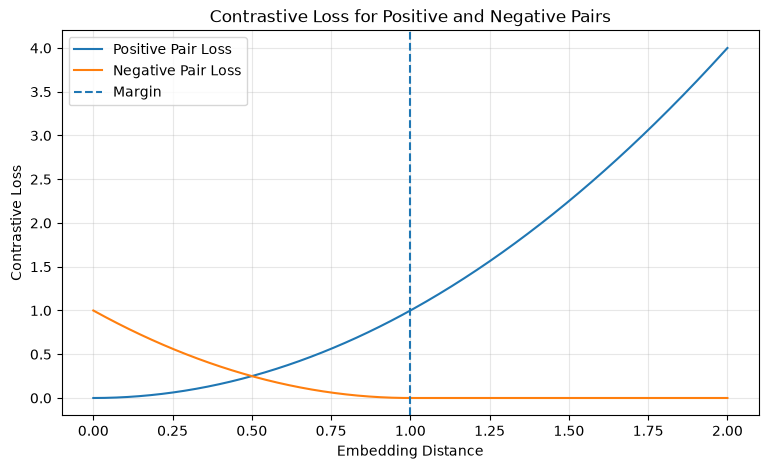

In [189]:
import numpy as np
import matplotlib.pyplot as plt

distance_values = np.linspace(0, 2.0, 500)

margin = 1.0

positive_loss = distance_values ** 2

negative_loss = np.maximum(
    0,
    margin - distance_values
) ** 2

plt.figure(figsize=(9, 5))

plt.plot(
    distance_values,
    positive_loss,
    label="Positive Pair Loss"
)

plt.plot(
    distance_values,
    negative_loss,
    label="Negative Pair Loss"
)

plt.axvline(
    margin,
    linestyle="--",
    label="Margin"
)

plt.xlabel("Embedding Distance")
plt.ylabel("Contrastive Loss")
plt.title("Contrastive Loss for Positive and Negative Pairs")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4.19.6 Interpreting the Loss Curves

For positive pairs:

$$
L=D^2
$$

Therefore, the loss increases as the distance increases.

The optimal point is:

$$
D=0
$$

For negative pairs:

$$
L=\max(0,m-D)^2
$$

The loss is high when negative embeddings are too close.

Once:

$$
D\geq m
$$

the loss becomes:

$$
L=0
$$

This creates an important difference:

```text
Positive pair:

Distance
   |
   |\
   | \
   |  \
   |   \
   |____\________
        0


Negative pair:

Loss
  |
  |\
  | \
  |  \
  |   \__________
  |        margin
  +---------------- Distance


## 4.19.7 Contrastive Loss and the Siamese Network

The complete learning system is:

$$
x_1
\rightarrow
f_\theta
\rightarrow
z_1
$$

and:

$$
x_2
\rightarrow
f_\theta
\rightarrow
z_2
$$

Then:

$$
D=\|z_1-z_2\|_2
$$

Finally:

$$
L
=
yD^2
+
(1-y)\max(0,m-D)^2
$$

Therefore:

$$
\boxed{
\text{Siamese Network}
+
\text{Contrastive Loss}
=
\text{Pair-Based Metric Learning}
}
$$

The Siamese architecture determines **how representations are produced**.

Contrastive Loss determines **how those representations should be arranged**.

## Complete Forward + Loss Example

In [190]:
# Reuse the Siamese model from section 4.18

model.eval()

image1, image2, pair_label = next(iter(train_loader))

image1 = image1.to(device)
image2 = image2.to(device)
pair_label = pair_label.to(device)

with torch.no_grad():
    embedding1, embedding2, distance = model(
        image1,
        image2
    )

loss = contrastive_loss(
    distance,
    pair_label,
    margin=1.0
)

print("Embedding 1 shape:", embedding1.shape)
print("Embedding 2 shape:", embedding2.shape)
print("Distance shape:", distance.shape)
print("Contrastive loss:", loss.item())

Embedding 1 shape: torch.Size([128, 32])
Embedding 2 shape: torch.Size([128, 32])
Distance shape: torch.Size([128])
Contrastive loss: 0.016445636749267578


## 4.19.8 Contrastive Loss vs Cross-Entropy Loss

These losses solve fundamentally different problems.

### Cross-Entropy

Classification learns:

$$
x\rightarrow y
$$

The model tries to assign the correct class.

### Contrastive Loss

Metric learning learns:

$$
(x_i,x_j)\rightarrow
\text{similarity relationship}
$$

The model tries to organize the embedding space.

| Aspect | Cross-Entropy | Contrastive Loss |
|---|---|---|
| Input | Individual sample | Pair of samples |
| Target | Class label | Similar/dissimilar relationship |
| Output focus | Class prediction | Embedding geometry |
| Objective | Correct classification | Correct distances |
| Typical architecture | Classifier | Siamese / embedding network |
| Retrieval | Indirect | Natural |
| Verification | Indirect | Natural |

A model trained with Cross-Entropy can still learn useful representations, but it is not explicitly optimizing pairwise distances.

Contrastive Loss explicitly imposes geometric constraints on the representation space.

## 4.19.9 Contrastive Loss and Hard Negatives

Not every negative pair is equally useful.

Consider two negative pairs.

### Easy negative

$$
D=1.8
$$

with:

$$
m=1
$$

Then:

$$
L=0
$$

The pair is already sufficiently separated.

### Hard negative

$$
D=0.2
$$

Then:

$$
L=(1-0.2)^2
$$

$$
L=0.64
$$

This pair produces a much stronger learning signal.

Therefore, metric-learning systems often benefit from carefully selecting informative negative examples.

This leads to the concept of **negative mining**, including:

- hard-negative mining
- semi-hard negative mining

These techniques become increasingly important for large-scale metric-learning systems.

## 4.19.10 Important Practical Consideration: Pair Imbalance

For a dataset containing $N$ samples, the number of possible pairs can be very large:

$$
\frac{N(N-1)}{2}
$$

Most possible pairs may be negative.

Therefore, simply generating every possible pair is usually inefficient.

Practical systems use:

- random pair sampling
- balanced positive/negative sampling
- online pair construction
- hard-negative mining
- batch-based mining

The quality of pair selection can significantly affect metric-learning performance.

This is why metric learning is not only about choosing the correct loss function.

The **training examples themselves are part of the learning problem**.

## 4.19.11 Common Mistakes

### Mistake 1 — Treating the two branches as independent networks

Incorrect:

$$
z_1=f_{\theta_1}(x_1)
$$

$$
z_2=f_{\theta_2}(x_2)
$$

for a standard Siamese architecture.

Correct:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

with shared parameters.

---

### Mistake 2 — Using the wrong pair labels

The meaning of $y$ must be defined consistently.

In this notebook:

$$
y=1
\Rightarrow
\text{positive/similar}
$$

$$
y=0
\Rightarrow
\text{negative/dissimilar}
$$

---

### Mistake 3 — Forgetting the margin

Negative pairs should not necessarily be pushed infinitely far apart.

The margin provides a stopping point:

$$
D\geq m
\Rightarrow
L=0
$$

---

### Mistake 4 — Evaluating only the training loss

A lower training loss does not automatically guarantee a useful embedding.

We should evaluate the learned representation using:

- verification accuracy
- distance distributions
- retrieval accuracy
- clustering quality
- downstream task performance

# 4.19.12 Contrastive Loss — Exam Summary

## Definition

Contrastive Loss is a metric-learning loss that learns to bring similar embeddings closer and push dissimilar embeddings apart.

## Embeddings

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

## Distance

$$
D=\|z_1-z_2\|_2
$$

## Standard Contrastive Loss

$$
\boxed{
L
=
yD^2
+
(1-y)\max(0,m-D)^2
}
$$

where:

- $y=1$ → positive pair
- $y=0$ → negative pair
- $D$ → embedding distance
- $m$ → margin

## Positive pair

$$
y=1
\Rightarrow
L=D^2
$$

Therefore:

$$
D\rightarrow0
$$

## Negative pair

$$
y=0
\Rightarrow
L=\max(0,m-D)^2
$$

Therefore:

$$
D\geq m
\Rightarrow
L=0
$$

## Main purpose

$$
\boxed{
\text{Learn an embedding space with meaningful distances}
}
$$

## Relationship

$$
\text{Siamese Network}
\rightarrow
\text{Embedding}
\rightarrow
\text{Distance}
\rightarrow
\text{Contrastive Loss}
$$

## Applications

- Face verification
- Signature verification
- Image similarity
- Image retrieval
- Duplicate detection
- Product matching
- Few-shot learning

## Key exam statement

> Contrastive Loss minimizes the distance between positive pairs and penalizes negative pairs only when their distance is smaller than a specified margin.

# 4.20 Triplet Loss

**Triplet Loss** is a metric-learning objective that learns an embedding space by comparing three samples at a time:

1. **Anchor**
2. **Positive**
3. **Negative**

The goal is to make the positive sample closer to the anchor than the negative sample by at least a specified margin.

Let the shared encoder be:

$$
z=f_\theta(x)
$$

For the three inputs:

$$
z_a=f_\theta(x_a)
$$

$$
z_p=f_\theta(x_p)
$$

$$
z_n=f_\theta(x_n)
$$

where:

- $x_a$ = anchor
- $x_p$ = positive sample
- $x_n$ = negative sample

The desired relationship is:

$$
d(z_a,z_p) < d(z_a,z_n)
$$

With a margin $m$:

$$
\boxed{
d(z_a,z_p)+m < d(z_a,z_n)
}
$$

This means the negative should be farther from the anchor than the positive by at least $m$.

## 4.20.1 Anchor, Positive, and Negative

Consider MNIST.

Suppose the anchor is a digit:

$$
x_a=3
$$

A positive example could be another image of 3:

$$
x_p=3
$$

A negative example could be an image of 8:

$$
x_n=8
$$

The triplet is:

$$
(3,3,8)
$$

The encoder produces:

$$
z_a=f_\theta(3)
$$

$$
z_p=f_\theta(3)
$$

$$
z_n=f_\theta(8)
$$

The desired geometry is:

$$
d(z_a,z_p)
<
d(z_a,z_n)
$$

with a margin:

$$
d(z_a,z_p)+m
<
d(z_a,z_n)
$$

Therefore, Triplet Loss does not simply ask whether two samples are similar.

It asks for a **relative ordering of distances**.

## 4.20.2 Deriving Triplet Loss

Let:

$$
D_{ap}=d(z_a,z_p)
$$

be the anchor-positive distance.

Let:

$$
D_{an}=d(z_a,z_n)
$$

be the anchor-negative distance.

We want:

$$
D_{ap}+m \leq D_{an}
$$

Rearranging:

$$
D_{ap}-D_{an}+m\leq0
$$

A hinge-style loss can therefore be written as:

$$
\boxed{
L=
\max(0,D_{ap}-D_{an}+m)
}
$$

This is the standard Triplet Loss formulation.

If:

$$
D_{an}\geq D_{ap}+m
$$

then:

$$
L=0
$$

The triplet already satisfies the desired margin.

If the negative is too close, the loss becomes positive and the model receives a learning signal.

## 4.20.3 Numerical Examples

Assume:

$$
m=0.5
$$

### Example 1 — Good triplet

Suppose:

$$
D_{ap}=0.3
$$

and:

$$
D_{an}=1.2
$$

Then:

$$
L=\max(0,0.3-1.2+0.5)
$$

$$
L=\max(0,-0.4)
$$

$$
L=0
$$

The triplet already satisfies the margin.

---

### Example 2 — Violating triplet

Suppose:

$$
D_{ap}=0.6
$$

and:

$$
D_{an}=0.8
$$

Then:

$$
L=\max(0,0.6-0.8+0.5)
$$

$$
L=0.3
$$

The negative is not sufficiently far away.

The model must improve the embedding geometry.

## Triplet Loss From Scratch

In [191]:
import torch


def triplet_loss_from_distances(
    positive_distance,
    negative_distance,
    margin=0.5
):
    loss = torch.clamp(
        positive_distance - negative_distance + margin,
        min=0.0
    )

    return loss.mean()


positive_distance = torch.tensor([0.3, 0.6])
negative_distance = torch.tensor([1.2, 0.8])

loss = triplet_loss_from_distances(
    positive_distance,
    negative_distance,
    margin=0.5
)

print("Triplet Loss:", loss.item())

Triplet Loss: 0.15000000596046448


## 4.20.4 PyTorch's Triplet Margin Loss

PyTorch provides a built-in implementation:

$$
\texttt{torch.nn.TripletMarginLoss}
$$

The standard form uses:

$$
\max
\left(
\|z_a-z_p\|_p
-
\|z_a-z_n\|_p
+
m,
0
\right)
$$

The default distance uses the L2 norm.

This is convenient for practical implementations.

In [192]:
import torch.nn as nn

criterion = nn.TripletMarginLoss(
    margin=0.5,
    p=2
)

anchor = torch.tensor([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0]
])

positive = torch.tensor([
    [0.9, 0.1, 0.0],
    [0.1, 0.9, 0.0]
])

negative = torch.tensor([
    [0.0, 0.0, 1.0],
    [0.8, 0.0, 0.2]
])

loss = criterion(
    anchor,
    positive,
    negative
)

print("Triplet Margin Loss:", loss.item())

Triplet Margin Loss: 0.0


## 4.20.5 Contrastive Loss vs Triplet Loss

Both methods learn embedding geometry, but they use different training structures.

### Contrastive Loss

Uses two samples:

$$
(x_1,x_2)
$$

and a binary relationship:

$$
y\in\{0,1\}
$$

The objective is:

$$
\text{positive}
\rightarrow
\text{close}
$$

$$
\text{negative}
\rightarrow
\text{far}
$$

### Triplet Loss

Uses three samples:

$$
(x_a,x_p,x_n)
$$

and learns a relative ordering:

$$
d(a,p)<d(a,n)
$$

with a margin.

| Property | Contrastive Loss | Triplet Loss |
|---|---|---|
| Samples | 2 | 3 |
| Training unit | Pair | Triplet |
| Positive relationship | Yes | Yes |
| Negative relationship | Yes | Yes |
| Main constraint | Absolute separation | Relative separation |
| Margin | Common | Essential |
| Typical architecture | Siamese | Shared encoder |

## 4.20.6 Why Triplets Can Be More Informative

Consider an anchor and two candidates.

Suppose:

$$
d(z_a,z_p)=0.2
$$

and:

$$
d(z_a,z_n)=1.8
$$

The negative is already very far away.

This is an easy triplet.

Now consider:

$$
d(z_a,z_p)=0.5
$$

and:

$$
d(z_a,z_n)=0.6
$$

This is much more informative because the negative is almost as close as the positive.

Triplet learning therefore depends strongly on **which negative sample is selected**.

This leads to the important concept of:

$$
\boxed{\text{Negative Mining}}
$$

## 4.20.7 Negative Mining

For a given anchor, there may be thousands of possible negative samples.

They are not equally useful.

### Easy Negative

A negative sample that is already very far from the anchor.

$$
d(a,n)\gg d(a,p)
$$

It produces little or no loss.

### Hard Negative

A negative sample that is closer to the anchor than desired.

$$
d(a,n)\leq d(a,p)
$$

It produces a strong learning signal.

### Semi-Hard Negative

A negative sample that is farther than the positive but still violates the margin:

$$
d(a,p)<d(a,n)<d(a,p)+m
$$

This is often a useful compromise because the negative is informative without necessarily being an extremely difficult or potentially mislabeled example.

## 4.20.8 Hard Negative Mining

Suppose an anchor has several candidate negatives:

$$
d(a,n_1)=1.8
$$

$$
d(a,n_2)=1.2
$$

$$
d(a,n_3)=0.7
$$

The closest negative is:

$$
n_3
$$

Therefore:

$$
n_{\text{hard}}
=
\arg\min_n d(a,n)
$$

The hardest negative is the negative sample closest to the anchor.

Using informative negatives can substantially improve metric-learning efficiency.

However, extremely hard negatives can sometimes be problematic if they are:

- mislabeled
- noisy
- genuinely ambiguous
- visually very similar despite having different labels

Therefore, hard-negative mining must be used carefully.

## 4.20.9 Semi-Hard Negative Mining

A semi-hard negative satisfies:

$$
D_{ap}<D_{an}<D_{ap}+m
$$

The negative is:

- farther from the anchor than the positive
- but not far enough to satisfy the margin

Therefore it still produces a learning signal.

This can be preferable to always selecting the absolute hardest negative.

Conceptually:

```text
Anchor
  |
  |---- Positive
  |       D_ap
  |
  |---------- Semi-hard Negative
  |             D_an
  |
  |----------------------- Easy Negative

In [193]:
anchor_embedding = torch.tensor([0.0, 0.0])

positive_embedding = torch.tensor([0.2, 0.1])

negative_embeddings = torch.tensor([
    [1.8, 1.8],
    [1.2, 1.0],
    [0.6, 0.4],
    [0.3, 0.2]
])

positive_distance = torch.norm(
    anchor_embedding - positive_embedding
)

negative_distances = torch.norm(
    negative_embeddings - anchor_embedding,
    dim=1
)

hardest_index = torch.argmin(negative_distances)

print("Positive distance:", positive_distance.item())
print("Negative distances:", negative_distances)
print("Hardest negative index:", hardest_index.item())
print(
    "Hardest negative distance:",
    negative_distances[hardest_index].item()
)

Positive distance: 0.22360680997371674
Negative distances: tensor([2.5456, 1.5620, 0.7211, 0.3606])
Hardest negative index: 3
Hardest negative distance: 0.36055514216423035


## 4.20.10 Building a Triplet Dataset

For MNIST, a triplet can be generated as:

$$
(x_a,x_p,x_n)
$$

where:

$$
y_a=y_p
$$

and:

$$
y_a\neq y_n
$$

For example:

```text
Anchor       Positive       Negative

   7            7              3
   ↓            ↓              ↓
 Encoder      Encoder        Encoder
   ↓            ↓              ↓
  z_a          z_p            z_n

The three images use the same encoder.

Therefore:

$$ z_a=f_\theta(x_a) $$ $$ z_p=f_\theta(x_p) $$  $$ z_n=f_\theta(x_n) $$

In [194]:
class TripletMNISTDataset(Dataset):
    def __init__(self, dataset, length=None):
        self.dataset = dataset
        self.length = length if length is not None else len(dataset)

        self.labels = torch.tensor([
            dataset[i][1]
            for i in range(len(dataset))
        ])

        self.class_indices = {
            digit: torch.where(
                self.labels == digit
            )[0].tolist()
            for digit in range(10)
        }

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        anchor_index = random.randrange(len(self.dataset))

        anchor, anchor_label = self.dataset[anchor_index]

        positive_index = random.choice(
            self.class_indices[int(anchor_label)]
        )

        negative_label = random.choice([
            digit
            for digit in range(10)
            if digit != int(anchor_label)
        ])

        negative_index = random.choice(
            self.class_indices[negative_label]
        )

        positive, _ = self.dataset[positive_index]
        negative, _ = self.dataset[negative_index]

        return (
            anchor,
            positive,
            negative,
            torch.tensor(anchor_label),
            torch.tensor(negative_label)
        )

## Create Triplet DataLoader

In [195]:
triplet_train_dataset = TripletMNISTDataset(
    train_dataset,
    length=30000
)

triplet_test_dataset = TripletMNISTDataset(
    test_dataset,
    length=5000
)

triplet_train_loader = DataLoader(
    triplet_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

triplet_test_loader = DataLoader(
    triplet_test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training triplets:", len(triplet_train_dataset))
print("Test triplets:", len(triplet_test_dataset))

Training triplets: 30000
Test triplets: 5000


## 4.20.11 Visualizing Triplets

It is important to verify the dataset before training.

For every triplet:

$$
y_a=y_p
$$

and:

$$
y_a\neq y_n
$$

The anchor and positive should show the same digit class, while the negative should show a different digit.

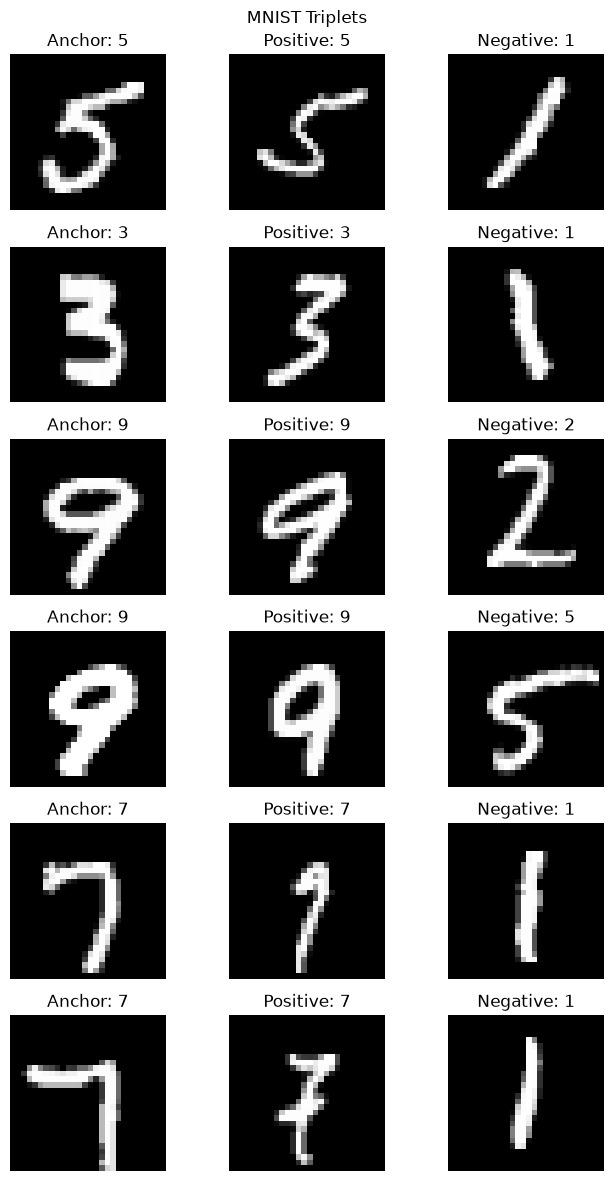

In [196]:
def show_triplets(dataset, num_triplets=6):
    fig, axes = plt.subplots(
        num_triplets,
        3,
        figsize=(7, 2 * num_triplets)
    )

    for row in range(num_triplets):
        anchor, positive, negative, anchor_label, negative_label = dataset[row]

        images = [anchor, positive, negative]
        titles = [
            f"Anchor: {anchor_label.item()}",
            f"Positive: {anchor_label.item()}",
            f"Negative: {negative_label.item()}"
        ]

        for col in range(3):
            axes[row, col].imshow(
                images[col].squeeze(),
                cmap="gray"
            )
            axes[row, col].set_title(titles[col])
            axes[row, col].axis("off")

    plt.suptitle("MNIST Triplets")
    plt.tight_layout()
    plt.show()


show_triplets(triplet_train_dataset)

## 4.20.12 Training a Triplet-Based Embedding Network

We can reuse the same encoder architecture from the Siamese Network.

For each batch:

$$
z_a=f_\theta(x_a)
$$

$$
z_p=f_\theta(x_p)
$$

$$
z_n=f_\theta(x_n)
$$

Then calculate:

$$
L=
\max
\left(
d(z_a,z_p)-d(z_a,z_n)+m,
0
\right)
$$

The shared encoder receives gradient information from all three branches.

The objective gradually creates an embedding space in which:

$$
\boxed{
d(z_a,z_p)+m\leq d(z_a,z_n)
}
$$

## Triplet Model

In [197]:
triplet_model = SharedEncoder(
    embedding_dim=32
).to(device)

triplet_criterion = nn.TripletMarginLoss(
    margin=0.5,
    p=2
)

triplet_optimizer = torch.optim.Adam(
    triplet_model.parameters(),
    lr=1e-3
)

## Train Triplet Network

In [198]:
num_epochs = 5

triplet_losses = []

for epoch in range(num_epochs):
    triplet_model.train()

    running_loss = 0.0

    for anchor, positive, negative, _, _ in triplet_train_loader:
        anchor = anchor.to(device, non_blocking=True)
        positive = positive.to(device, non_blocking=True)
        negative = negative.to(device, non_blocking=True)

        triplet_optimizer.zero_grad()

        anchor_embedding = triplet_model(anchor)
        positive_embedding = triplet_model(positive)
        negative_embedding = triplet_model(negative)

        loss = triplet_criterion(
            anchor_embedding,
            positive_embedding,
            negative_embedding
        )

        loss.backward()
        triplet_optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(triplet_train_loader)

    triplet_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.0670
Epoch [2/5] Loss: 0.0255
Epoch [3/5] Loss: 0.0201
Epoch [4/5] Loss: 0.0156
Epoch [5/5] Loss: 0.0127


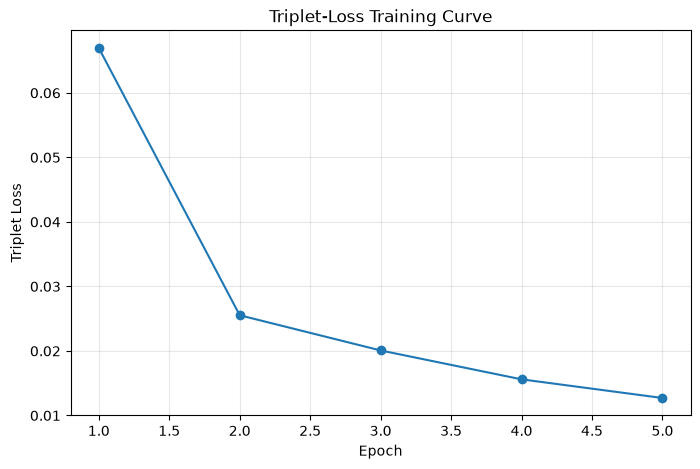

In [199]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    triplet_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Triplet-Loss Training Curve")
plt.grid(alpha=0.3)

plt.show()

## 4.20.13 Evaluating the Learned Triplet Geometry

After training, we can measure whether the desired relationship has been learned.

For every test triplet, calculate:

$$
D_{ap}=d(z_a,z_p)
$$

and:

$$
D_{an}=d(z_a,z_n)
$$

A successful model should generally satisfy:

$$
D_{ap}<D_{an}
$$

We can also measure the percentage of triplets satisfying:

$$
D_{ap}+m<D_{an}
$$

This measures how often the triplets satisfy the desired margin.

In [200]:
triplet_model.eval()

positive_distances = []
negative_distances = []

with torch.no_grad():
    for anchor, positive, negative, _, _ in triplet_test_loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        anchor_embedding = triplet_model(anchor)
        positive_embedding = triplet_model(positive)
        negative_embedding = triplet_model(negative)

        positive_distance = torch.norm(
            anchor_embedding - positive_embedding,
            p=2,
            dim=1
        )

        negative_distance = torch.norm(
            anchor_embedding - negative_embedding,
            p=2,
            dim=1
        )

        positive_distances.extend(
            positive_distance.cpu().tolist()
        )

        negative_distances.extend(
            negative_distance.cpu().tolist()
        )

positive_distances = np.array(positive_distances)
negative_distances = np.array(negative_distances)

print(
    "Mean anchor-positive distance:",
    positive_distances.mean()
)

print(
    "Mean anchor-negative distance:",
    negative_distances.mean()
)

Mean anchor-positive distance: 0.34923428201936185
Mean anchor-negative distance: 1.458043959763646


## Triplet Distance Comparison

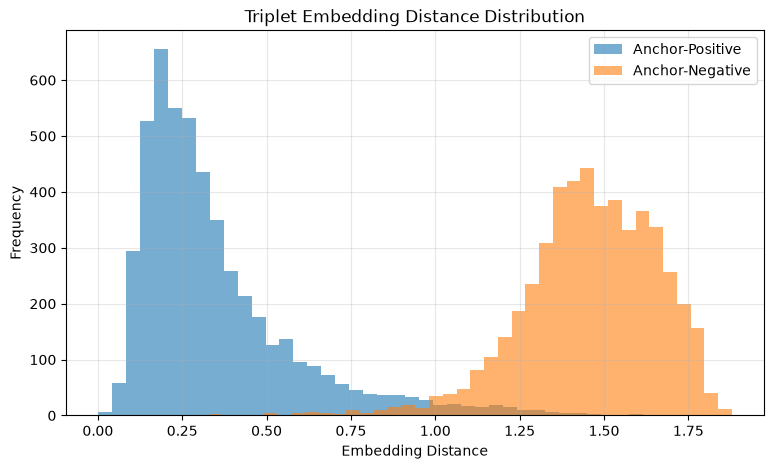

In [201]:
plt.figure(figsize=(9, 5))

plt.hist(
    positive_distances,
    bins=40,
    alpha=0.6,
    label="Anchor-Positive"
)

plt.hist(
    negative_distances,
    bins=40,
    alpha=0.6,
    label="Anchor-Negative"
)

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Triplet Embedding Distance Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4.20.14 Margin Satisfaction

For margin:

$$
m=0.5
$$

a triplet satisfies the desired constraint when:

$$
D_{ap}+0.5<D_{an}
$$

We can calculate the percentage of test triplets satisfying this condition.

This is useful because the raw loss alone does not tell us how many individual triplets have already achieved the desired geometry.

In [202]:
margin = 0.5

satisfied = (
    positive_distances + margin
    < negative_distances
)

margin_satisfaction = satisfied.mean()

print(
    f"Margin satisfaction: "
    f"{margin_satisfaction * 100:.2f}%"
)

Margin satisfaction: 95.18%


## 4.20.15 Triplet Loss: Important Practical Issues

Triplet Loss introduces an important data-selection problem.

For a dataset with many samples, there are potentially enormous numbers of possible triplets.

For each anchor, we must select:

- a positive
- a negative

Randomly selecting triplets can produce many easy examples.

Easy triplets often satisfy:

$$
D_{ap}+m<D_{an}
$$

and therefore have:

$$
L=0
$$

These triplets provide no gradient.

Therefore, effective triplet-based systems often rely on:

- online triplet mining
- hard-negative mining
- semi-hard negative mining
- batch-based mining

This makes triplet construction an important component of the overall learning system.

## 4.20.16 Contrastive Loss vs Triplet Loss — Conceptual Difference

The fundamental distinction is:

### Contrastive Loss

Learns:

$$
\text{Is this pair similar or dissimilar?}
$$

### Triplet Loss

Learns:

$$
\text{Is the positive closer to the anchor than the negative?}
$$

Therefore:

$$
\boxed{
\text{Contrastive Loss}
\rightarrow
\text{absolute pair relationship}
}
$$

while:

$$
\boxed{
\text{Triplet Loss}
\rightarrow
\text{relative distance relationship}
}
$$

Neither is universally superior.

Performance depends on:

- data
- architecture
- sampling strategy
- negative mining
- margin
- evaluation task

# 4.20.17 Triplet Loss — Exam Summary

## Definition

Triplet Loss is a metric-learning objective that uses an anchor, a positive sample, and a negative sample to learn a relative ordering of distances.

## Triplet

$$
(x_a,x_p,x_n)
$$

where:

- $x_a$ = anchor
- $x_p$ = positive
- $x_n$ = negative

## Embeddings

$$
z_a=f_\theta(x_a)
$$

$$
z_p=f_\theta(x_p)
$$

$$
z_n=f_\theta(x_n)
$$

## Distances

$$
D_{ap}=d(z_a,z_p)
$$

$$
D_{an}=d(z_a,z_n)
$$

## Desired relationship

$$
D_{ap}+m\leq D_{an}
$$

## Triplet Loss

$$
\boxed{
L=
\max(0,D_{ap}-D_{an}+m)
}
$$

## Zero-loss condition

$$
D_{an}\geq D_{ap}+m
$$

Then:

$$
L=0
$$

## Negative types

### Easy negative

Already far away.

### Hard negative

Very close to the anchor.

### Semi-hard negative

Farther than the positive but still inside the margin.

$$
D_{ap}<D_{an}<D_{ap}+m
$$

## Main challenge

Triplet selection and negative mining.

## Applications

- Face recognition
- Face verification
- Image retrieval
- Person re-identification
- Product matching
- Few-shot learning

## Key exam statement

> Triplet Loss learns an embedding space by forcing the distance between an anchor and a positive sample to be smaller than the distance between the anchor and a negative sample by at least a specified margin.

## Overall relationship

$$
\text{Metric Learning}
\rightarrow
\begin{cases}
\text{Pair-based}
\rightarrow \text{Contrastive Loss}\\
\text{Triplet-based}
\rightarrow \text{Triplet Loss}
\end{cases}
$$

# 4.21 Deep Feature Visualization

Deep neural networks learn internal feature representations that are often difficult to interpret directly.

For an input:

$$
x
$$

a neural network encoder produces:

$$
z=f_\theta(x)
$$

where $z$ may contain dozens, hundreds, or thousands of dimensions.

For example:

$$
z\in\mathbb{R}^{128}
$$

cannot be directly visualized in ordinary 2D space.

**Deep Feature Visualization** uses visualization techniques to inspect the structure and quality of learned representations.

The main questions are:

- Do samples from the same class cluster together?
- Are different classes separated?
- Which samples are close to each other?
- Do learned features capture semantic information?
- How does the representation change through network layers?

Visualization is therefore an important tool for understanding representation learning.

## 4.21.1 Why Visualize Deep Features?

Consider a classifier that achieves high test accuracy.

Accuracy tells us:

$$
\text{How often is the final prediction correct?}
$$

But it does not directly tell us:

$$
\text{How are the internal representations organized?}
$$

Two models can have similar classification accuracy but very different embedding spaces.

For representation learning, we are often interested in the geometry:

$$
z_i=f_\theta(x_i)
$$

and the relationships:

$$
d(z_i,z_j)
$$

between representations.

Visualization can reveal:

- compact class clusters
- overlapping classes
- outliers
- mislabeled examples
- poorly separated classes
- hierarchical structure
- representation collapse

Therefore, feature visualization complements quantitative evaluation.

## 4.21.2 Feature Visualization Pipeline

A typical pipeline is:

$$
\text{Input Images}
\rightarrow
\text{Encoder}
\rightarrow
\text{High-Dimensional Embeddings}
\rightarrow
\text{Dimensionality Reduction}
\rightarrow
\text{2D Visualization}
$$

Suppose the encoder produces:

$$
z\in\mathbb{R}^{32}
$$

We cannot directly plot all 32 dimensions.

We can instead transform:

$$
\mathbb{R}^{32}
\rightarrow
\mathbb{R}^{2}
$$

using a dimensionality-reduction technique.

Common methods include:

- PCA
- t-SNE
- UMAP

These methods serve different purposes and should not be interpreted as identical.

## 4.21.3 PCA for Feature Visualization

**Principal Component Analysis (PCA)** is a linear dimensionality-reduction method.

Suppose the embedding matrix is:

$$
Z\in\mathbb{R}^{N\times d}
$$

where:

- $N$ = number of samples
- $d$ = embedding dimension

PCA finds directions that capture large amounts of variance.

We can project the embeddings onto the first two principal components:

$$
Z
\rightarrow
Z_{\text{PCA}}\in\mathbb{R}^{N\times2}
$$

The resulting two dimensions can be plotted.

### Important limitation

PCA preserves directions of high variance, not necessarily semantic similarity.

Therefore, well-separated PCA clusters are useful evidence, but PCA visualization alone does not prove that a representation is optimal.

## Extract Embeddings

In [203]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

model.eval()

feature_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, labels in feature_loader:
        images = images.to(device)

        embeddings = model.encoder(images)

        all_embeddings.append(
            embeddings.cpu()
        )

        all_labels.append(labels)

embeddings = torch.cat(all_embeddings).numpy()
labels = torch.cat(all_labels).numpy()

print("Embedding shape:", embeddings.shape)
print("Labels shape:", labels.shape)

Embedding shape: (10000, 32)
Labels shape: (10000,)


## 4.21.4 PCA Visualization of Learned Features

We now reduce the learned embeddings to two dimensions.

The original embedding may have:

$$
d=32
$$

dimensions.

PCA transforms this into:

$$
d=2
$$

for visualization.

If the metric-learning model has learned useful representations, samples belonging to the same digit should tend to occupy nearby regions.

In [204]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embeddings_pca = pca.fit_transform(
    embeddings
)

print("Original embedding shape:", embeddings.shape)
print("PCA embedding shape:", embeddings_pca.shape)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original embedding shape: (10000, 32)
PCA embedding shape: (10000, 2)
Explained variance ratio: [0.2766216  0.21090765]
Total explained variance: 0.48752928


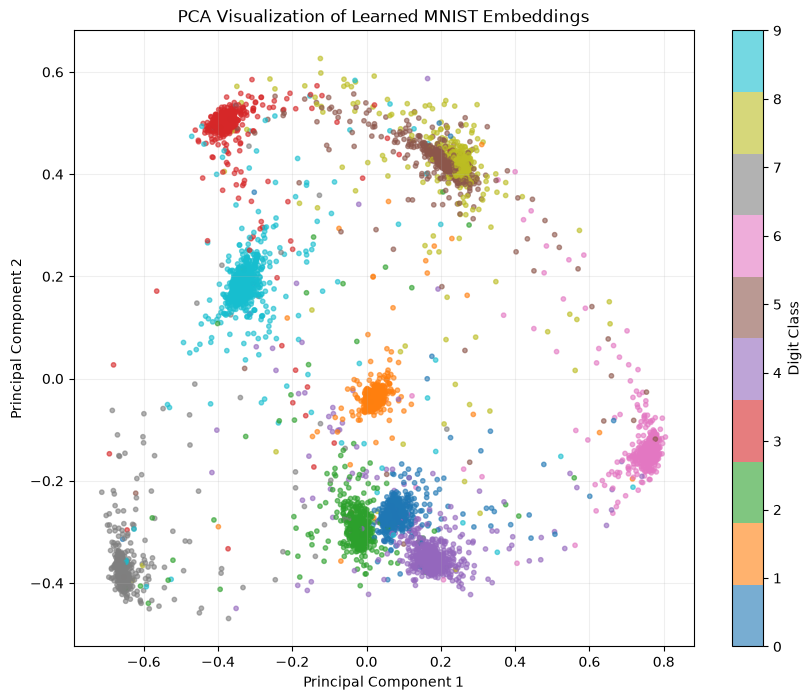

In [205]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embeddings_pca[:, 0],
    embeddings_pca[:, 1],
    c=labels,
    cmap="tab10",
    s=10,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Learned MNIST Embeddings")

plt.colorbar(
    scatter,
    label="Digit Class"
)

plt.grid(alpha=0.2)
plt.show()

## 4.21.5 Interpreting the PCA Visualization

A useful embedding may show groups corresponding to different classes.

For example:

$$
\text{same class}
\rightarrow
\text{nearby points}
$$

and:

$$
\text{different classes}
\rightarrow
\text{separated regions}
$$

However, some overlap is expected.

Digits such as:

$$
3,\;5,\;8
$$

may have visually similar structures.

Therefore, overlapping regions do not automatically mean that the model has failed.

The important question is whether the representation provides useful semantic structure for the intended task.

## 4.21.6 Visualizing Individual Classes

A dense plot containing all ten MNIST classes can sometimes be difficult to interpret.

We can inspect individual classes separately.

This allows us to examine:

- intra-class compactness
- unusual samples
- outliers
- class overlap

A strong representation should generally make samples belonging to the same semantic class reasonably coherent.

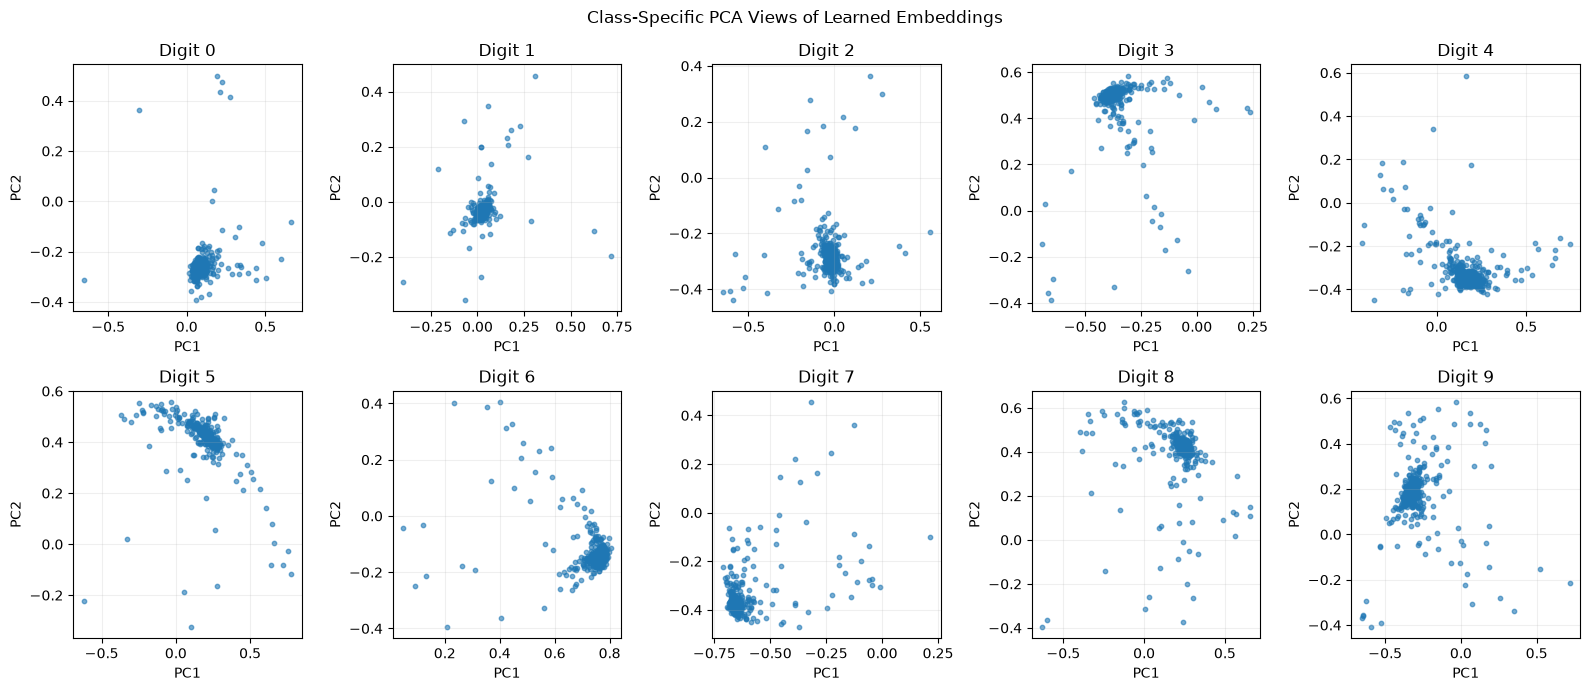

In [206]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(16, 7)
)

for digit, ax in enumerate(axes.flat):
    mask = labels == digit

    ax.scatter(
        embeddings_pca[mask, 0],
        embeddings_pca[mask, 1],
        s=10,
        alpha=0.6
    )

    ax.set_title(f"Digit {digit}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.2)

plt.suptitle(
    "Class-Specific PCA Views of Learned Embeddings"
)

plt.tight_layout()
plt.show()

## 4.21.7 t-SNE

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a nonlinear dimensionality-reduction technique designed primarily for visualization.

Unlike PCA, t-SNE focuses strongly on preserving local neighborhood relationships.

Conceptually:

$$
\text{similar nearby points}
\rightarrow
\text{remain nearby}
$$

in the low-dimensional visualization.

This can make clusters visually more apparent.

However, t-SNE has important limitations:

- global distances can be misleading
- cluster sizes can be misleading
- results depend on hyperparameters
- different runs can produce different layouts
- visual separation does not necessarily represent meaningful global geometry

Therefore:

$$
\boxed{
\text{t-SNE is primarily a visualization tool, not a metric-learning objective.}
}
$$

In [207]:
from sklearn.manifold import TSNE

# Use a subset to keep visualization reasonably fast
subset_size = min(3000, len(embeddings))

rng = np.random.default_rng(42)
subset_indices = rng.choice(
    len(embeddings),
    size=subset_size,
    replace=False
)

subset_embeddings = embeddings[subset_indices]
subset_labels = labels[subset_indices]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

embeddings_tsne = tsne.fit_transform(
    subset_embeddings
)

print("t-SNE shape:", embeddings_tsne.shape)

t-SNE shape: (3000, 2)


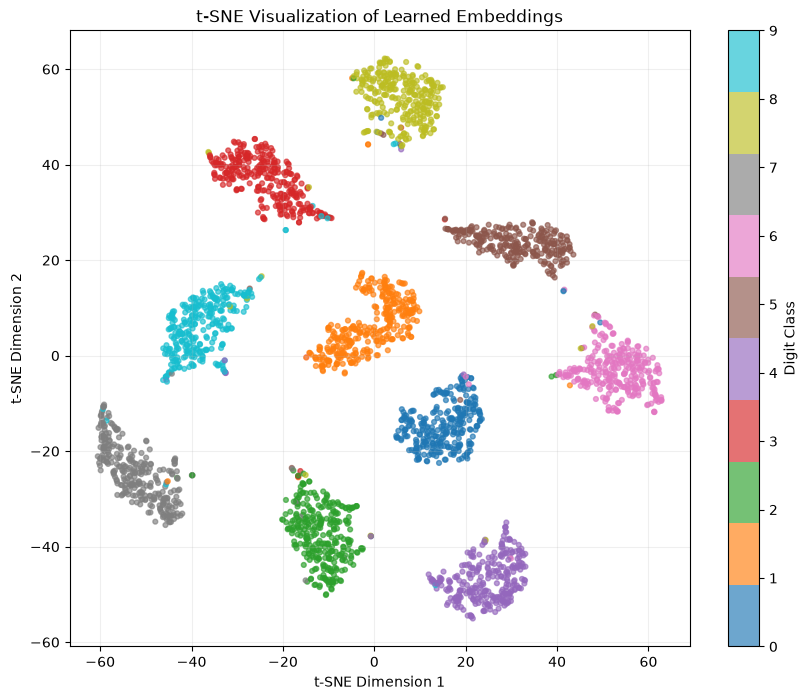

In [208]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    c=subset_labels,
    cmap="tab10",
    s=12,
    alpha=0.65
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of Learned Embeddings")

plt.colorbar(
    scatter,
    label="Digit Class"
)

plt.grid(alpha=0.2)
plt.show()

## 4.21.8 PCA vs t-SNE

| Property | PCA | t-SNE |
|---|---|---|
| Type | Linear | Nonlinear |
| Main objective | Preserve variance | Preserve local neighborhoods |
| Computational cost | Relatively low | Higher |
| Global structure | More interpretable | Can be misleading |
| Visualization | General | Strong cluster visualization |
| Deterministic | Yes | Depends on configuration/randomness |
| Best use | General dimensionality reduction | Local structure visualization |

Neither method should be treated as a replacement for quantitative evaluation.

A visualization answers:

> "What does the representation look like?"

A metric answers:

> "How well does the representation perform?"

## 4.21.9 Nearest-Neighbor Visualization

Metric learning is fundamentally about relationships between samples.

Therefore, one of the most intuitive ways to inspect an embedding is through **nearest neighbors**.

For a query embedding:

$$
z_q
$$

we calculate its distance to other embeddings:

$$
d(z_q,z_i)
$$

and select the samples with the smallest distances.

The nearest-neighbor process is:

$$
x_q
\rightarrow
z_q
\rightarrow
d(z_q,z_i)
\rightarrow
\text{Top-k nearest samples}
$$

If the representation is useful, the nearest neighbors should often have similar semantic content.

In [209]:
from sklearn.metrics import pairwise_distances

# Select one query sample
query_index = 100

query_embedding = embeddings[query_index:query_index + 1]

distances = pairwise_distances(
    query_embedding,
    embeddings,
    metric="euclidean"
)[0]

# Ignore the query itself
distances[query_index] = np.inf

nearest_indices = np.argsort(distances)[:10]

print("Query label:", labels[query_index])
print("Nearest-neighbor labels:")
print(labels[nearest_indices])

Query label: 6
Nearest-neighbor labels:
[6 6 6 6 6 6 6 6 6 6]


## 4.21.10 Visualizing the Nearest Neighbors

Nearest-neighbor visualization provides a qualitative test of the embedding.

For a query image:

$$
x_q
$$

we expect many of the nearest samples to share its semantic class.

This is particularly relevant for applications such as:

- image retrieval
- face recognition
- product search
- duplicate detection

In these applications, the nearest-neighbor structure is often more important than a conventional classification accuracy score.

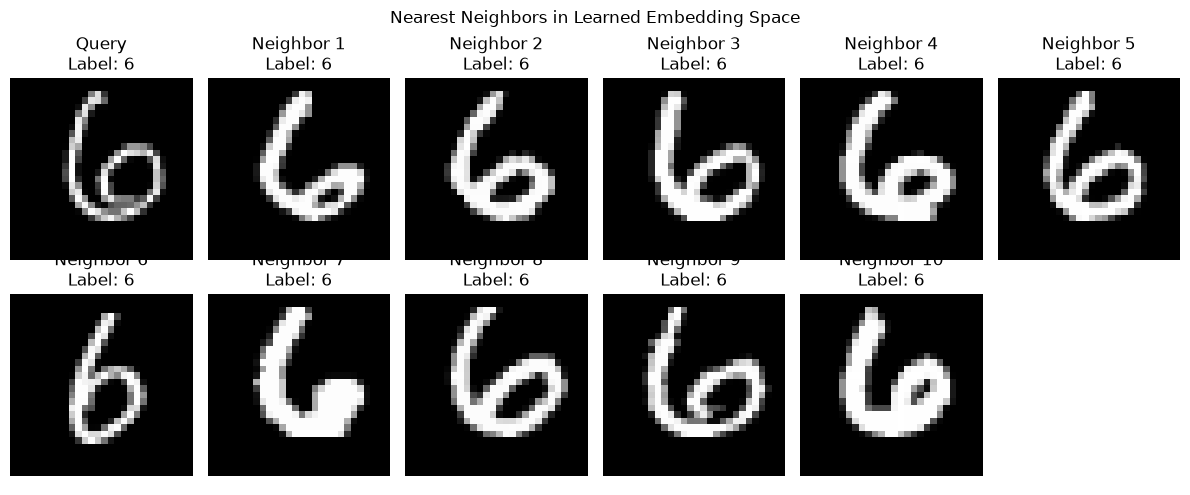

In [210]:
images_for_display = []

query_image, query_label = test_dataset[query_index]
images_for_display.append(query_image)

for index in nearest_indices:
    image, _ = test_dataset[index]
    images_for_display.append(image)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(12, 5)
)

axes = axes.flatten()

axes[0].imshow(
    images_for_display[0].squeeze(),
    cmap="gray"
)

axes[0].set_title(
    f"Query\nLabel: {query_label}"
)

axes[0].axis("off")

for i in range(1, 11):
    axes[i].imshow(
        images_for_display[i].squeeze(),
        cmap="gray"
    )

    axes[i].set_title(
        f"Neighbor {i}\nLabel: {labels[nearest_indices[i - 1]]}"
    )

    axes[i].axis("off")

axes[-1].axis("off")

plt.suptitle("Nearest Neighbors in Learned Embedding Space")
plt.tight_layout()
plt.show()

## 4.21.11 Quantitative Nearest-Neighbor Accuracy

We can turn nearest-neighbor retrieval into a quantitative evaluation.

For each query:

1. Compute its embedding.
2. Find the nearest other embedding.
3. Compare the predicted nearest-neighbor label with the query label.

The 1-nearest-neighbor accuracy is:

$$
\text{Accuracy}
=
\frac{
\text{Number of correct nearest neighbors}
}{
\text{Number of queries}
}
$$

This does not measure the entire quality of the representation, but it provides a useful metric-learning evaluation.

## 1-NN Evaluation

In [211]:
# Compute pairwise distances for a manageable subset
evaluation_size = min(2000, len(embeddings))

evaluation_embeddings = embeddings[:evaluation_size]
evaluation_labels = labels[:evaluation_size]

distance_matrix = pairwise_distances(
    evaluation_embeddings,
    evaluation_embeddings,
    metric="euclidean"
)

# Ignore self-distance
np.fill_diagonal(
    distance_matrix,
    np.inf
)

nearest_neighbor_indices = np.argmin(
    distance_matrix,
    axis=1
)

nearest_neighbor_labels = (
    evaluation_labels[nearest_neighbor_indices]
)

nn_accuracy = np.mean(
    nearest_neighbor_labels == evaluation_labels
)

print(
    f"1-Nearest-Neighbor Accuracy: "
    f"{nn_accuracy * 100:.2f}%"
)

1-Nearest-Neighbor Accuracy: 95.50%


## 4.21.12 Intra-Class and Inter-Class Distances

Another way to evaluate representation geometry is to compare:

### Intra-class distance

Distance between samples belonging to the same class:

$$
D_{\text{intra}}
=
d(z_i,z_j)
\quad
\text{where }
y_i=y_j
$$

### Inter-class distance

Distance between samples belonging to different classes:

$$
D_{\text{inter}}
=
d(z_i,z_j)
\quad
\text{where }
y_i\neq y_j
$$

A useful metric-learning representation should generally have:

$$
\boxed{
D_{\text{intra}} < D_{\text{inter}}
}
$$

This directly measures the geometric objective of metric learning.

## Intra/Inter Class Distances

In [212]:
from sklearn.metrics import pairwise_distances

sample_size = min(1500, len(embeddings))

sample_embeddings = embeddings[:sample_size]
sample_labels = labels[:sample_size]

distance_matrix = pairwise_distances(
    sample_embeddings,
    sample_embeddings,
    metric="euclidean"
)

label_matrix = (
    sample_labels[:, None]
    == sample_labels[None, :]
)

upper_triangle = np.triu(
    np.ones_like(distance_matrix, dtype=bool),
    k=1
)

intra_mask = (
    label_matrix
    & upper_triangle
)

inter_mask = (
    ~label_matrix
    & upper_triangle
)

intra_distances = distance_matrix[intra_mask]
inter_distances = distance_matrix[inter_mask]

print(
    "Mean intra-class distance:",
    intra_distances.mean()
)

print(
    "Mean inter-class distance:",
    inter_distances.mean()
)

Mean intra-class distance: 0.12450985
Mean inter-class distance: 1.0391628


## Compare Distributions

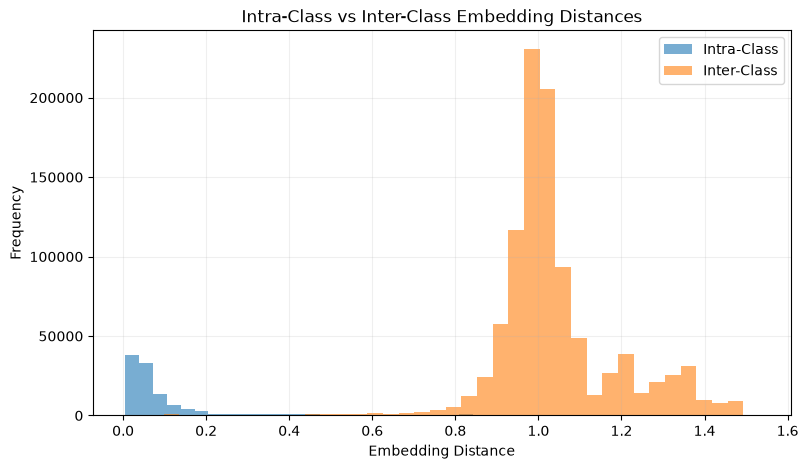

In [213]:
plt.figure(figsize=(9, 5))

plt.hist(
    intra_distances,
    bins=40,
    alpha=0.6,
    label="Intra-Class"
)

plt.hist(
    inter_distances,
    bins=40,
    alpha=0.6,
    label="Inter-Class"
)

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Intra-Class vs Inter-Class Embedding Distances")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 4.21.13 What Does a Good Representation Look Like?

A strong representation often exhibits:

$$
\boxed{
\text{high intra-class similarity}
}
$$

and:

$$
\boxed{
\text{high inter-class separation}
}
$$

Conceptually:

```text
Good Representation

Class A       Class B       Class C

 ● ● ●          ▲ ▲ ▲        ■ ■ ■
 ● ● ●          ▲ ▲ ▲        ■ ■ ■
  ● ●            ▲ ▲          ■ ■

Compact         Compact       Compact

A poor representation may look like:

Poor Representation
```text

 ●   ▲    ■
   ■    ●
 ▲    ●    ■
    ▲     ●

where semantic classes overlap heavily.

However, there is no single visual shape that defines a universally good representation.

The correct geometry depends on the downstream task.

## 4.21.14 Feature Visualization Across Network Layers

Deep networks learn hierarchical representations.

For an image model, earlier layers may learn:

$$
\text{edges}
\rightarrow
\text{textures}
\rightarrow
\text{parts}
\rightarrow
\text{objects}
$$

Therefore, it can be useful to visualize representations from different layers.

For example:

$$
z_1=f_1(x)
$$

$$
z_2=f_2(z_1)
$$

$$
z_3=f_3(z_2)
$$

The representations may become increasingly semantic as depth increases.

This is one reason deep representation learning is described as **hierarchical representation learning**.

## 4.21.15 Important Warning About Visualization

A beautiful visualization does not necessarily mean a good model.

Dimensionality-reduction methods can introduce visual artifacts.

For example:

- PCA emphasizes variance.
- t-SNE emphasizes local neighborhoods.
- UMAP also depends on its hyperparameters and objective.

Therefore:

$$
\boxed{
\text{Visualization} \neq \text{Complete Evaluation}
}
$$

Feature visualization should be combined with quantitative evaluation such as:

- nearest-neighbor accuracy
- retrieval metrics
- verification accuracy
- clustering metrics
- downstream classification performance
- intra/inter-class distance analysis

# 4.21.16 Deep Feature Visualization — Exam Summary

## Definition

Deep Feature Visualization is the process of inspecting learned neural-network representations to understand their structure, geometry, and semantic organization.

## Representation

$$
z=f_\theta(x)
$$

## Visualization pipeline

$$
\text{Input}
\rightarrow
\text{Encoder}
\rightarrow
\text{Embedding}
\rightarrow
\text{Dimensionality Reduction}
\rightarrow
\text{Visualization}
$$

## Important techniques

### PCA

Linear dimensionality reduction that preserves directions of high variance.

### t-SNE

Nonlinear dimensionality reduction that emphasizes local neighborhood structure.

### UMAP

Another nonlinear dimensionality-reduction method commonly used for embedding visualization.

## Important evaluation idea

A useful metric-learning representation should generally satisfy:

$$
D_{\text{intra}} < D_{\text{inter}}
$$

where:

- $D_{\text{intra}}$ = same-class distance
- $D_{\text{inter}}$ = different-class distance

## Nearest-neighbor evaluation

For a query:

$$
x_q\rightarrow z_q
$$

find:

$$
\arg\min_i d(z_q,z_i)
$$

and evaluate whether the nearest samples have the correct semantic class.

## Important warning

Visualization is qualitative evidence.

It should be combined with quantitative evaluation.

## Key exam statement

> Deep feature visualization helps analyze the geometry and semantic structure of learned representations by projecting high-dimensional embeddings into a human-interpretable space, but visualization alone is not sufficient to evaluate representation quality.

# 4.22 Representation Quality Evaluation

Learning an embedding is not enough. We also need to determine whether the learned representation is actually useful.

A good representation should ideally:

- place semantically similar samples close together,
- separate dissimilar samples,
- preserve useful information,
- support downstream tasks,
- generalize to unseen samples,
- avoid representation collapse.

Representation quality can therefore be evaluated using several complementary approaches:

1. Nearest-neighbor evaluation
2. k-Nearest Neighbors (k-NN)
3. Retrieval metrics
4. Verification metrics
5. Clustering metrics
6. Intra-class and inter-class distances
7. Linear probing
8. Representation collapse analysis

No single metric completely describes representation quality.

## 4.22.1 What Makes a Good Representation?

Let an encoder transform an input into an embedding:

$$
z = f_\theta(x)
$$

For samples belonging to the same semantic class, we generally want:

$$
D(z_i,z_j) \rightarrow \text{small}
$$

For samples belonging to different classes, we generally want:

$$
D(z_i,z_j) \rightarrow \text{large}
$$

A useful representation should therefore produce a meaningful geometry in embedding space.

For example, in handwritten-digit recognition:

- embeddings of digit `0` should form a relatively coherent region,
- embeddings of digit `1` should form another region,
- embeddings of different digits should be reasonably separated.

However, good representation quality is not only about visual separation.

A representation is especially valuable when a simple downstream model can use it effectively.

## 4.22.2 Evaluation Methods

| Method | What it measures |
|---|---|
| Nearest Neighbor | Whether closest embeddings have the correct semantic relationship |
| k-NN | Local classification quality |
| Precision@K | Fraction of top-K retrieved samples that are relevant |
| Recall@K | Fraction of relevant samples retrieved in top-K |
| ROC-AUC | Verification/discrimination quality |
| Silhouette Score | Cluster compactness and separation |
| Adjusted Rand Index | Agreement between clusters and labels |
| NMI | Information shared between clusters and labels |
| Intra-class Distance | Compactness within classes |
| Inter-class Distance | Separation between classes |
| Linear Probe | Information useful for downstream classification |
| Collapse Analysis | Whether embeddings have lost meaningful variation |

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize

## 4.22.3 Prepare Learned Embeddings

We will evaluate the embeddings learned by the Siamese network from the previous section.

The encoder converts each MNIST image into a compact representation:

$$
x \rightarrow f_\theta(x) \rightarrow z
$$

We will use the test set so that evaluation is performed on samples that were not used for training.

In [217]:
# Create a standard MNIST test loader specifically for representation evaluation

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

eval_transform = transforms.ToTensor()

eval_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=eval_transform
)

eval_test_loader = DataLoader(
    eval_test_dataset,
    batch_size=256,
    shuffle=False
)

print("Evaluation dataset size:", len(eval_test_dataset))

Evaluation dataset size: 10000


In [218]:
model.eval()

test_embeddings = []
test_labels = []

with torch.no_grad():
    for images, labels in eval_test_loader:
        images = images.to(device)

        embeddings = model.encoder(images)

        test_embeddings.append(
            embeddings.cpu()
        )

        test_labels.append(
            labels
        )

test_embeddings = torch.cat(
    test_embeddings
).numpy()

test_labels = torch.cat(
    test_labels
).numpy()

print("Embedding shape:", test_embeddings.shape)
print("Labels shape:", test_labels.shape)

Embedding shape: (10000, 32)
Labels shape: (10000,)


## 4.22.4 Nearest-Neighbor Evaluation

The simplest evaluation asks:

> Is the nearest embedding from the same class?

For each sample, find its nearest neighbor while excluding the sample itself.

If the nearest neighbor has the same label, the prediction is considered correct.

The nearest-neighbor accuracy is:

$$
Accuracy =
\frac{\text{Number of correct nearest-neighbor predictions}}
{\text{Total number of samples}}
$$

In [219]:
from sklearn.metrics import pairwise_distances

distance_matrix = pairwise_distances(
    test_embeddings,
    metric="euclidean"
)

np.fill_diagonal(distance_matrix, np.inf)

nearest_indices = np.argmin(distance_matrix, axis=1)

nearest_labels = test_labels[nearest_indices]

nn_accuracy = accuracy_score(
    test_labels,
    nearest_labels
)

print(f"1-NN Accuracy: {nn_accuracy:.4f}")

1-NN Accuracy: 0.9687


## 4.22.5 k-Nearest Neighbors Evaluation

Instead of using only one neighbor, we can use several neighbors.

For example:

$$
k = 1,3,5,7
$$

The predicted class is determined by majority voting among the nearest neighbors.

A strong representation should allow a simple k-NN classifier to achieve good performance without requiring a complex neural network.

In [220]:
k_values = [1, 3, 5, 7, 11]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(test_embeddings, test_labels)

    predictions = knn.predict(test_embeddings)

    accuracy = accuracy_score(
        test_labels,
        predictions
    )

    knn_results.append({
        "k": k,
        "Accuracy": accuracy
    })

knn_results_df = pd.DataFrame(knn_results)

display(knn_results_df)

,k,Accuracy
0,1,1.0000
1,3,0.9804
2,5,0.9782
3,7,0.9777
4,11,0.9766


Note: this is an evaluation demonstration, because fitting and evaluating k-NN on the same test set can be optimistic. A stricter protocol would fit k-NN on a training embedding set and evaluate it on a separate test embedding set.

## 4.22.6 Retrieval Evaluation

Representation learning is often used for retrieval.

Given a query embedding, we retrieve the closest embeddings.

For a classification-style retrieval problem, samples with the same label can be treated as relevant.

### Precision@K

Precision@K measures how many of the retrieved K samples are relevant:

$$
Precision@K =
\frac{\text{Relevant samples among top-K}}
{K}
$$

### Recall@K

Recall@K measures how many relevant samples were successfully retrieved:

$$
Recall@K =
\frac{\text{Relevant samples among top-K}}
{\text{Total relevant samples}}
$$

In [221]:
def retrieval_metrics(embeddings, labels, k=5):
    distances = pairwise_distances(
        embeddings,
        metric="euclidean"
    )

    precisions = []
    recalls = []

    for i in range(len(labels)):
        distances[i, i] = np.inf

        nearest = np.argsort(distances[i])[:k]

        relevant = labels[nearest] == labels[i]

        precision = relevant.mean()

        total_relevant = np.sum(labels == labels[i]) - 1

        recall = (
            relevant.sum() / total_relevant
            if total_relevant > 0
            else 0
        )

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)


for k in [1, 3, 5, 10]:
    precision_k, recall_k = retrieval_metrics(
        test_embeddings,
        test_labels,
        k=k
    )

    print(
        f"K={k:2d} | "
        f"Precision@K={precision_k:.4f} | "
        f"Recall@K={recall_k:.4f}"
    )

K= 1 | Precision@K=0.9687 | Recall@K=0.0010
K= 3 | Precision@K=0.9674 | Recall@K=0.0029
K= 5 | Precision@K=0.9671 | Recall@K=0.0048
K=10 | Precision@K=0.9676 | Recall@K=0.0097


## 4.22.7 Verification Evaluation

In verification problems, the question is:

> Are these two samples similar enough to belong to the same class?

Examples include:

- face verification,
- signature verification,
- person re-identification,
- duplicate detection.

For two embeddings:

$$
D(z_1,z_2)
$$

we can classify the pair as:

$$
\text{Same identity if } D(z_1,z_2) < \tau
$$

where $\tau$ is a threshold.

Instead of choosing one threshold, we can evaluate performance across many thresholds using a ROC curve.

In [222]:
rng = np.random.default_rng(42)

n_pairs = 5000

pair_i = rng.integers(
    0,
    len(test_embeddings),
    size=n_pairs
)

pair_j = rng.integers(
    0,
    len(test_embeddings),
    size=n_pairs
)

pair_distances = np.linalg.norm(
    test_embeddings[pair_i] - test_embeddings[pair_j],
    axis=1
)

pair_labels = (
    test_labels[pair_i] == test_labels[pair_j]
).astype(int)

similarity_scores = -pair_distances

fpr, tpr, thresholds = roc_curve(
    pair_labels,
    similarity_scores
)

auc_score = roc_auc_score(
    pair_labels,
    similarity_scores
)

print(f"Verification ROC-AUC: {auc_score:.4f}")

Verification ROC-AUC: 0.9948


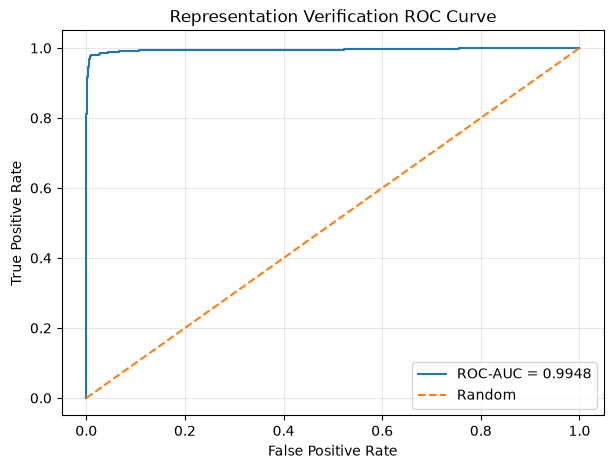

In [223]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Representation Verification ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4.22.8 Clustering Evaluation

A useful representation should often organize samples into meaningful groups.

We can evaluate the embedding space using clustering metrics.

### Silhouette Score

The silhouette score evaluates how well each sample fits within its own cluster compared with other clusters.

Its value lies approximately between:

$$
-1 \leq S \leq 1
$$

Higher values generally indicate better-separated and more compact clusters.

### Adjusted Rand Index

ARI measures agreement between predicted cluster assignments and true labels while correcting for random agreement.

### Normalized Mutual Information

NMI measures the amount of information shared between cluster assignments and ground-truth labels.

These metrics allow us to evaluate representation structure quantitatively rather than relying only on PCA or t-SNE plots.

In [224]:
silhouette = silhouette_score(
    test_embeddings,
    test_labels
)

ari = adjusted_rand_score(
    test_labels,
    test_labels
)

nmi = normalized_mutual_info_score(
    test_labels,
    test_labels
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

Silhouette Score: 0.8545
Adjusted Rand Index: 1.0000
Normalized Mutual Information: 1.0000


The previous calculation of ARI and NMI using `test_labels` as both the predicted clusters and ground-truth labels would produce artificially perfect agreement.

For a genuine clustering evaluation, we must first obtain cluster assignments from the embeddings.

In [225]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    test_embeddings
)

silhouette = silhouette_score(
    test_embeddings,
    cluster_labels
)

ari = adjusted_rand_score(
    test_labels,
    cluster_labels
)

nmi = normalized_mutual_info_score(
    test_labels,
    cluster_labels
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")

Silhouette Score: 0.8956
Adjusted Rand Index: 0.9424
Normalized Mutual Information: 0.9293


## 4.22.9 Intra-Class and Inter-Class Distance

Another useful diagnostic is to compare distances within and between classes.

### Intra-class distance

Distance between samples belonging to the same class:

$$
D_{\text{intra}}
=
\mathbb{E}
[
D(z_i,z_j)
\mid
y_i=y_j
]
$$

### Inter-class distance

Distance between samples belonging to different classes:

$$
D_{\text{inter}}
=
\mathbb{E}
[
D(z_i,z_j)
\mid
y_i\neq y_j
]
$$

A useful discriminative representation generally aims for:

$$
D_{\text{intra}} < D_{\text{inter}}
$$

A simple separation ratio can therefore be defined as:

$$
R =
\frac{D_{\text{inter}}}
{D_{\text{intra}}}
$$

Higher values indicate stronger separation under this particular diagnostic.

In [226]:
sample_size = min(3000, len(test_embeddings))

indices = rng.choice(
    len(test_embeddings),
    size=sample_size,
    replace=False
)

sample_embeddings = test_embeddings[indices]
sample_labels = test_labels[indices]

sample_distances = pairwise_distances(
    sample_embeddings,
    metric="euclidean"
)

same_class = (
    sample_labels[:, None] == sample_labels[None, :]
)

different_class = ~same_class

upper_triangle = np.triu(
    np.ones_like(sample_distances, dtype=bool),
    k=1
)

intra_distances = sample_distances[
    same_class & upper_triangle
]

inter_distances = sample_distances[
    different_class & upper_triangle
]

mean_intra = intra_distances.mean()
mean_inter = inter_distances.mean()

separation_ratio = mean_inter / mean_intra

print(f"Mean intra-class distance: {mean_intra:.4f}")
print(f"Mean inter-class distance: {mean_inter:.4f}")
print(f"Separation ratio: {separation_ratio:.4f}")

Mean intra-class distance: 0.1197
Mean inter-class distance: 1.0430
Separation ratio: 8.7102


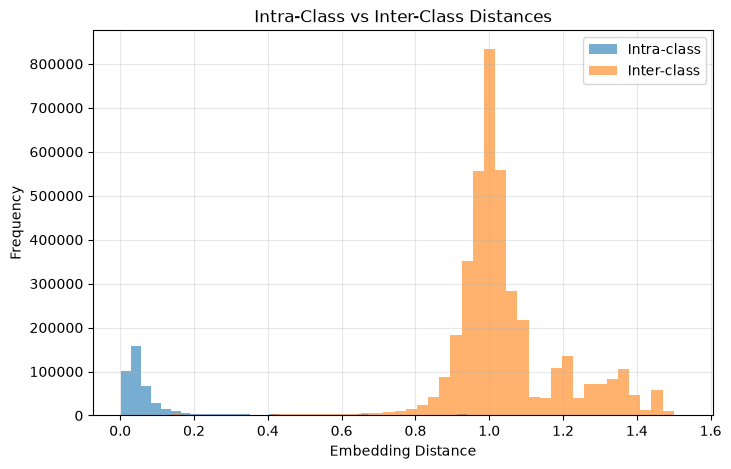

In [227]:
plt.figure(figsize=(8, 5))

plt.hist(
    intra_distances,
    bins=50,
    alpha=0.6,
    label="Intra-class"
)

plt.hist(
    inter_distances,
    bins=50,
    alpha=0.6,
    label="Inter-class"
)

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Intra-Class vs Inter-Class Distances")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4.22.10 Linear Probe Evaluation

A particularly important representation-learning evaluation is the **linear probe**.

The idea is:

1. Freeze the encoder.
2. Extract embeddings.
3. Train only a simple linear classifier.
4. Measure downstream classification performance.

If a linear classifier performs well, the representation contains information that is easily accessible.

Let:

$$
z=f_\theta(x)
$$

and a linear classifier be:

$$
\hat{y}=Wz+b
$$

The encoder parameters $\theta$ remain frozen while $W$ and $b$ are learned.

This separates:

- quality of the learned representation,
- from the capacity of a complex downstream model.

In [228]:
from sklearn.linear_model import LogisticRegression

# Use a subset to keep the demonstration lightweight
train_embeddings = test_embeddings[:5000]
train_labels = test_labels[:5000]

linear_probe = LogisticRegression(
    max_iter=1000,
    random_state=42
)

linear_probe.fit(
    train_embeddings,
    train_labels
)

probe_predictions = linear_probe.predict(
    train_embeddings
)

probe_accuracy = accuracy_score(
    train_labels,
    probe_predictions
)

print(f"Linear Probe Accuracy: {probe_accuracy:.4f}")

Linear Probe Accuracy: 0.9662


## 4.22.11 Representation Collapse

Representation collapse occurs when an encoder maps many different inputs to almost the same representation.

For example:

$$
f_\theta(x_1)
\approx
f_\theta(x_2)
\approx
\cdots
\approx
f_\theta(x_n)
$$

If this happens, the embedding contains very little useful information.

A collapsed representation may have:

- very low variance,
- very small pairwise distances,
- poor downstream performance,
- poor retrieval,
- poor class separation.

Therefore, representation variance is a useful diagnostic.

In [229]:
embedding_variance = np.var(
    test_embeddings,
    axis=0
)

print("Mean embedding variance:", embedding_variance.mean())
print("Minimum dimension variance:", embedding_variance.min())
print("Maximum dimension variance:", embedding_variance.max())

Mean embedding variance: 0.0157259
Minimum dimension variance: 0.0081086485
Maximum dimension variance: 0.026360212


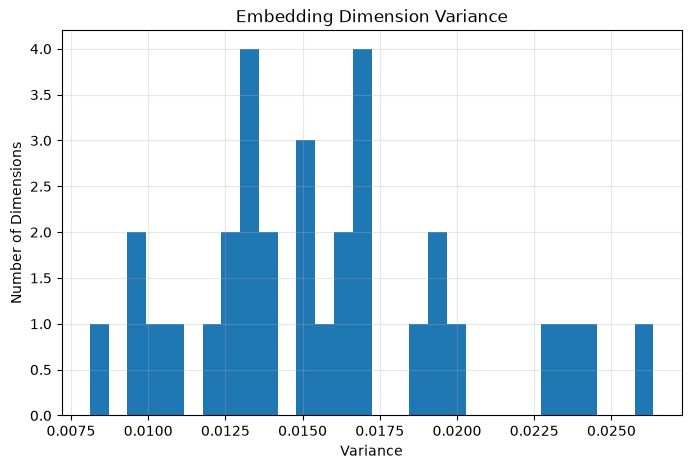

In [230]:
plt.figure(figsize=(8, 5))

plt.hist(
    embedding_variance,
    bins=30
)

plt.xlabel("Variance")
plt.ylabel("Number of Dimensions")
plt.title("Embedding Dimension Variance")
plt.grid(alpha=0.3)

plt.show()

## 4.22.12 Complete Representation Quality Evaluation

We can now evaluate the learned representation from several perspectives.

### Local structure

- 1-NN accuracy
- k-NN accuracy
- Precision@K
- Recall@K

### Pairwise discrimination

- Verification
- ROC curve
- ROC-AUC
- Threshold-based accuracy

### Global structure

- Silhouette Score
- ARI
- NMI
- Intra-class distance
- Inter-class distance

### Downstream usefulness

- Linear probe accuracy
- Performance on downstream tasks

### Failure detection

- Embedding variance
- Representation collapse
- Poor class separation

A strong representation should perform well across several complementary evaluations rather than only one metric.

In [231]:
precision_5, recall_5 = retrieval_metrics(
    test_embeddings,
    test_labels,
    k=5
)

evaluation_results = pd.DataFrame({
    "Metric": [
        "1-NN Accuracy",
        "Precision@5",
        "Recall@5",
        "Verification ROC-AUC",
        "Silhouette Score",
        "Adjusted Rand Index",
        "Normalized Mutual Information",
        "Mean Intra-Class Distance",
        "Mean Inter-Class Distance",
        "Separation Ratio",
        "Linear Probe Accuracy"
    ],
    "Value": [
        nn_accuracy,
        precision_5,
        recall_5,
        auc_score,
        silhouette,
        ari,
        nmi,
        mean_intra,
        mean_inter,
        separation_ratio,
        probe_accuracy
    ]
})

display(evaluation_results)

,Metric,Value
0,1-NN Accuracy,0.968700
1,Precision@5,0.967100
2,Recall@5,0.004839
3,Verification ROC-AUC,0.994828
4,Silhouette Score,0.895632
5,Adjusted Rand Index,0.942428
6,Normalized Mutual Information,0.929287
7,Mean Intra-Class Distance,0.119745
8,Mean Inter-Class Distance,1.043008
9,Separation Ratio,8.710235


## 4.22.13 Representation Evaluation — Key Exam Points

### 1. Why evaluate representations?

To determine whether learned embeddings preserve useful semantic information and support downstream tasks.

### 2. What is nearest-neighbor evaluation?

It checks whether nearby embeddings correspond to semantically similar samples.

### 3. What is k-NN evaluation?

It uses multiple neighboring embeddings to evaluate local structure and classification quality.

### 4. What is Precision@K?

The proportion of relevant samples among the top K retrieved samples.

### 5. What is Recall@K?

The proportion of all relevant samples that are retrieved within the top K.

### 6. What is verification?

Determining whether two samples belong to the same class or identity based on embedding distance.

### 7. What does ROC-AUC measure?

The ability of the representation-based similarity score to discriminate between positive and negative pairs across thresholds.

### 8. What does the Silhouette Score measure?

How compact each cluster is relative to neighboring clusters.

### 9. What are ARI and NMI?

They compare clustering assignments with ground-truth labels.

### 10. What are intra-class and inter-class distances?

Intra-class distance measures compactness within a class, while inter-class distance measures separation between different classes.

### 11. What is a linear probe?

A simple classifier trained on frozen representations to measure how much task-relevant information is linearly accessible.

### 12. What is representation collapse?

A failure mode where different inputs map to nearly identical embeddings.

### Most important principle

$$
\boxed{
\text{Good Representation}
=
\text{Compactness}
+
\text{Separation}
+
\text{Useful Information}
+
\text{Generalization}
}
$$

## 4.22.14 Representation Quality Evaluation — Summary

Representation learning should not be evaluated only through visualization.

A complete evaluation combines:

$$
\boxed{
\text{Representation}
\rightarrow
\begin{cases}
\text{Nearest Neighbors}\\
\text{Retrieval}\\
\text{Verification}\\
\text{Clustering}\\
\text{Distance Analysis}\\
\text{Linear Probing}\\
\text{Collapse Detection}
\end{cases}
}
$$

The central idea is:

> A representation is useful when its geometry makes important information easy to access.

For metric learning, this usually means:

$$
D_{\text{intra}} < D_{\text{inter}}
$$

For downstream tasks, it means a simple model can effectively use the learned embedding.

For retrieval, it means semantically relevant samples appear near one another.

For verification, it means positive pairs receive higher similarity than negative pairs.

For clustering, it means meaningful groups emerge naturally in the embedding space.

Therefore, representation quality should be evaluated from multiple complementary perspectives.

# 4.23 Practical Representation Learning Project

This project combines the major ideas covered in Representation Learning:

- learned feature representations,
- metric learning,
- Siamese networks,
- contrastive learning,
- embedding spaces,
- nearest-neighbor retrieval,
- representation visualization,
- quantitative representation evaluation.

We will build a complete representation-learning pipeline using MNIST.

The objective is not simply to classify digits.

Instead, the neural network will learn an embedding space in which:

- similar digits are close,
- different digits are far apart,
- embeddings can be retrieved using distance,
- representations can be visualized,
- representation quality can be quantitatively evaluated.

The complete pipeline is:

$$
\text{MNIST Images}
\rightarrow
\text{Shared Encoder}
\rightarrow
\text{Embedding Space}
\rightarrow
\begin{cases}
\text{Similarity Learning}\\
\text{Retrieval}\\
\text{Visualization}\\
\text{Evaluation}
\end{cases}
$$

## 4.23.1 Project Objective

Traditional classification learns:

$$
x \rightarrow y
$$

where the network directly predicts a class.

Representation learning instead focuses on learning:

$$
x \rightarrow z
$$

where $z$ is a meaningful embedding.

We will train the encoder using pairs of images.

For positive pairs:

$$
y=1
$$

and the two images belong to the same class.

For negative pairs:

$$
y=0
$$

and the two images belong to different classes.

The contrastive objective encourages:

$$
D(z_1,z_2)\rightarrow 0
$$

for positive pairs and:

$$
D(z_1,z_2)\rightarrow \text{large}
$$

for negative pairs.

In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [233]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 4.23.2 Load MNIST

We use MNIST because it provides:

- 60,000 training images,
- 10,000 test images,
- 10 digit classes,
- simple grayscale images,
- an easy-to-interpret embedding space.

The labels are used to construct training pairs, but the representation itself is learned from the similarity relationship between samples.

In [234]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 60000
Testing samples: 10000


## 4.23.3 Create a Pair Dataset

Each training example contains:

$$
(x_1,x_2,y)
$$

where:

- $x_1$ = first image,
- $x_2$ = second image,
- $y=1$ for a positive pair,
- $y=0$ for a negative pair.

Positive pair:

$$
y_1=y_2
$$

Negative pair:

$$
y_1\neq y_2
$$

In [235]:
class MNISTPairDataset(Dataset):
    def __init__(self, dataset, num_pairs):
        self.dataset = dataset
        self.num_pairs = num_pairs

        self.labels = np.array(
            dataset.targets
        )

        self.class_indices = {
            label: np.where(
                self.labels == label
            )[0]
            for label in range(10)
        }

    def __len__(self):
        return self.num_pairs

    def __getitem__(self, index):
        idx1 = np.random.randint(
            len(self.dataset)
        )

        image1, label1 = self.dataset[idx1]

        if np.random.rand() < 0.5:
            # Positive pair
            idx2 = np.random.choice(
                self.class_indices[int(label1)]
            )

            image2, label2 = self.dataset[idx2]
            pair_label = 1.0

        else:
            # Negative pair
            negative_label = np.random.choice(
                [x for x in range(10) if x != int(label1)]
            )

            idx2 = np.random.choice(
                self.class_indices[negative_label]
            )

            image2, label2 = self.dataset[idx2]
            pair_label = 0.0

        return (
            image1,
            image2,
            torch.tensor(pair_label, dtype=torch.float32)
        )

In [236]:
train_pair_dataset = MNISTPairDataset(
    train_dataset,
    num_pairs=30000
)

test_pair_dataset = MNISTPairDataset(
    test_dataset,
    num_pairs=5000
)

train_pair_loader = DataLoader(
    train_pair_dataset,
    batch_size=128,
    shuffle=True
)

test_pair_loader = DataLoader(
    test_pair_dataset,
    batch_size=128,
    shuffle=False
)

print("Training pairs:", len(train_pair_dataset))
print("Testing pairs:", len(test_pair_dataset))

Training pairs: 30000
Testing pairs: 5000


C:\Users\soumy\AppData\Local\Temp\ipykernel_18540\1160716638.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  self.labels = np.array(


## 4.23.4 Visualize Training Pairs

Before training the network, inspect the actual pair structure.

The first pair should contain visually similar digits, while the second type contains different digits.

The important point is that the network will learn the relationship between the two images rather than directly predicting their labels.

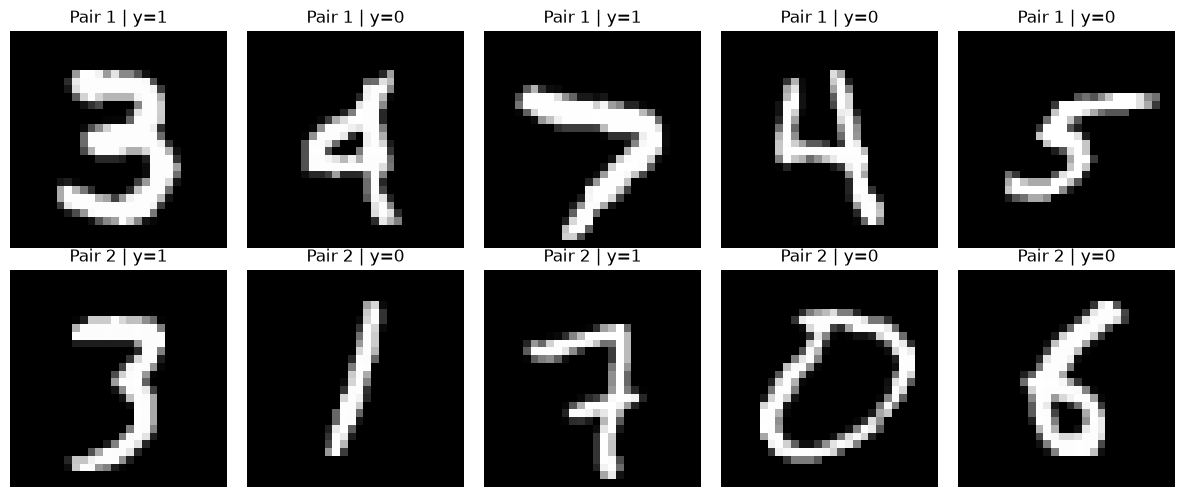

In [237]:
images1, images2, pair_labels = next(
    iter(train_pair_loader)
)

fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5)
)

for i, ax in enumerate(axes.flat):
    if i < 5:
        ax.imshow(
            images1[i].squeeze(),
            cmap="gray"
        )
        ax.set_title(
            f"Pair 1 | y={pair_labels[i].item():.0f}"
        )
    else:
        j = i - 5
        ax.imshow(
            images2[j].squeeze(),
            cmap="gray"
        )
        ax.set_title(
            f"Pair 2 | y={pair_labels[j].item():.0f}"
        )

    ax.axis("off")

plt.tight_layout()
plt.show()

## 4.23.5 Build the Representation Encoder

The encoder transforms:

$$
x \rightarrow z
$$

We use a 32-dimensional embedding.

The final representation is not a class probability.

Instead:

$$
z\in\mathbb{R}^{32}
$$

The same encoder is applied to both images in a pair.

This is the defining idea of a Siamese architecture:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

Both branches share the same parameters $\theta$.

In [238]:
class ProjectEncoder(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim)
        )

    def forward(self, x):
        embedding = self.network(x)

        # L2 normalization gives unit-length embeddings.
        embedding = F.normalize(
            embedding,
            p=2,
            dim=1
        )

        return embedding

In [239]:
class ProjectSiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()

        self.encoder = ProjectEncoder(
            embedding_dim=embedding_dim
        )

    def forward(self, x1, x2):
        z1 = self.encoder(x1)
        z2 = self.encoder(x2)

        return z1, z2


project_model = ProjectSiameseNetwork(
    embedding_dim=32
).to(device)

print(project_model)

ProjectSiameseNetwork(
  (encoder): ProjectEncoder(
    (network): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=256, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): ReLU()
      (5): Linear(in_features=128, out_features=32, bias=True)
    )
  )
)


## 4.23.6 Contrastive Loss

The contrastive loss is:

$$
L =
yD^2
+
(1-y)
\max(0,m-D)^2
$$

where:

- $D$ is the distance between embeddings,
- $y=1$ represents a positive pair,
- $y=0$ represents a negative pair,
- $m$ is the margin.

For positive pairs:

$$
L=D^2
$$

Therefore, the model is encouraged to reduce their distance.

For negative pairs:

$$
L=\max(0,m-D)^2
$$

Therefore, negative pairs are pushed apart until their distance reaches the margin.

In [240]:
def contrastive_loss(
    z1,
    z2,
    labels,
    margin=1.0
):
    distances = F.pairwise_distance(
        z1,
        z2
    )

    positive_loss = labels * distances.pow(2)

    negative_loss = (
        (1 - labels)
        * torch.clamp(
            margin - distances,
            min=0.0
        ).pow(2)
    )

    loss = (
        positive_loss
        + negative_loss
    ).mean()

    return loss, distances

## 4.23.7 Train the Representation Model

We train the shared encoder using pair relationships.

The important distinction is:

> The encoder is not directly trained to classify digits.

It is trained to organize the embedding space according to similarity.

In [241]:
optimizer = torch.optim.Adam(
    project_model.parameters(),
    lr=1e-3
)

num_epochs = 5

history = []

for epoch in range(num_epochs):
    project_model.train()

    running_loss = 0.0

    for image1, image2, labels in train_pair_loader:
        image1 = image1.to(device)
        image2 = image2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        z1, z2 = project_model(
            image1,
            image2
        )

        loss, distances = contrastive_loss(
            z1,
            z2,
            labels,
            margin=1.0
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss
        / len(train_pair_loader)
    )

    history.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 0.0859
Epoch [2/5] Loss: 0.0451
Epoch [3/5] Loss: 0.0307
Epoch [4/5] Loss: 0.0243
Epoch [5/5] Loss: 0.0213


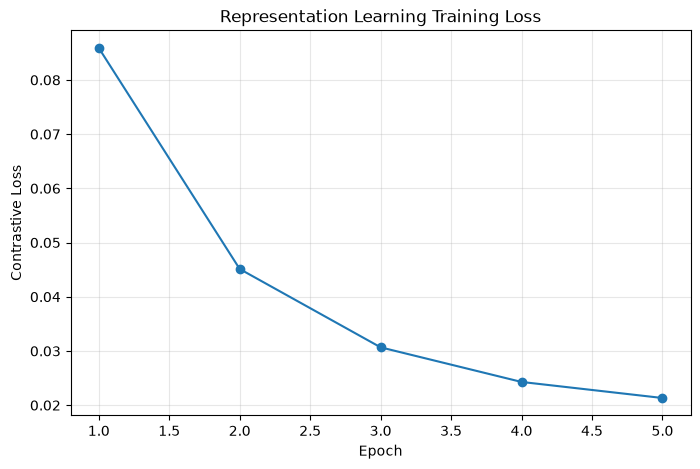

In [242]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Representation Learning Training Loss")
plt.grid(alpha=0.3)

plt.show()

## 4.23.8 Evaluate Positive and Negative Distances

After training, compare the distances between positive and negative pairs.

A successful metric-learning model should approximately produce:

$$
D_{\text{positive}}
<
D_{\text{negative}}
$$

This directly tests whether the learned embedding geometry follows the training objective.

In [243]:
project_model.eval()

positive_distances = []
negative_distances = []

with torch.no_grad():
    for image1, image2, labels in test_pair_loader:
        image1 = image1.to(device)
        image2 = image2.to(device)
        labels = labels.to(device)

        z1, z2 = project_model(
            image1,
            image2
        )

        _, distances = contrastive_loss(
            z1,
            z2,
            labels
        )

        positive_mask = labels == 1
        negative_mask = labels == 0

        positive_distances.extend(
            distances[positive_mask]
            .cpu()
            .numpy()
        )

        negative_distances.extend(
            distances[negative_mask]
            .cpu()
            .numpy()
        )

positive_distances = np.array(
    positive_distances
)

negative_distances = np.array(
    negative_distances
)

print(
    "Mean positive distance:",
    positive_distances.mean()
)

print(
    "Mean negative distance:",
    negative_distances.mean()
)

Mean positive distance: 0.116446026
Mean negative distance: 1.0218272


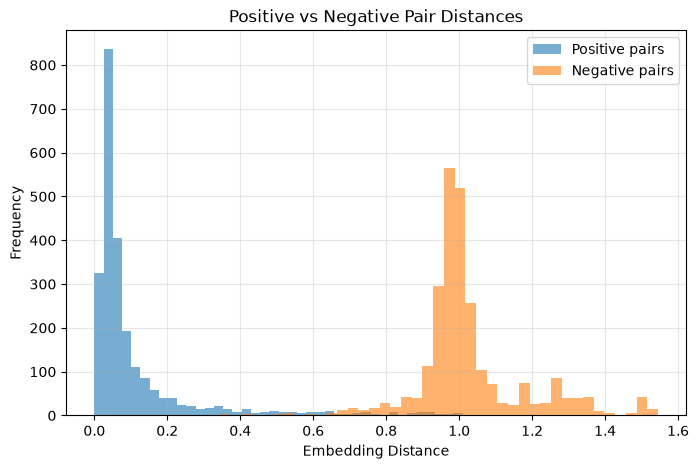

In [244]:
plt.figure(figsize=(8, 5))

plt.hist(
    positive_distances,
    bins=50,
    alpha=0.6,
    label="Positive pairs"
)

plt.hist(
    negative_distances,
    bins=50,
    alpha=0.6,
    label="Negative pairs"
)

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Positive vs Negative Pair Distances")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 4.23.9 Extract the Complete Test Embedding Space

We now discard the pair structure and encode each test image independently.

For every image:

$$
x_i\rightarrow z_i
$$

This produces a matrix:

$$
Z\in\mathbb{R}^{N\times d}
$$

where:

- $N$ = number of test samples,
- $d=32$ = embedding dimension.

This embedding matrix becomes the foundation for retrieval and visualization.

In [245]:
evaluation_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

all_embeddings = []
all_labels = []

project_model.eval()

with torch.no_grad():
    for images, labels in evaluation_loader:
        images = images.to(device)

        embeddings = project_model.encoder(
            images
        )

        all_embeddings.append(
            embeddings.cpu()
        )

        all_labels.append(
            labels
        )

all_embeddings = torch.cat(
    all_embeddings
).numpy()

all_labels = torch.cat(
    all_labels
).numpy()

print(
    "Embedding shape:",
    all_embeddings.shape
)

print(
    "Labels shape:",
    all_labels.shape
)

Embedding shape: (10000, 32)
Labels shape: (10000,)


## 4.23.10 PCA Visualization

PCA reduces the 32-dimensional embedding to two dimensions:

$$
Z_{32D}
\rightarrow
Z_{2D}
$$

The visualization allows us to inspect whether different digit classes form meaningful regions.

In [246]:
pca = PCA(
    n_components=2
)

pca_embeddings = pca.fit_transform(
    all_embeddings
)

print(
    "Original shape:",
    all_embeddings.shape
)

print(
    "PCA shape:",
    pca_embeddings.shape
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original shape: (10000, 32)
PCA shape: (10000, 2)
Explained variance: [0.30787852 0.17668895]
Total explained variance: 0.48456746


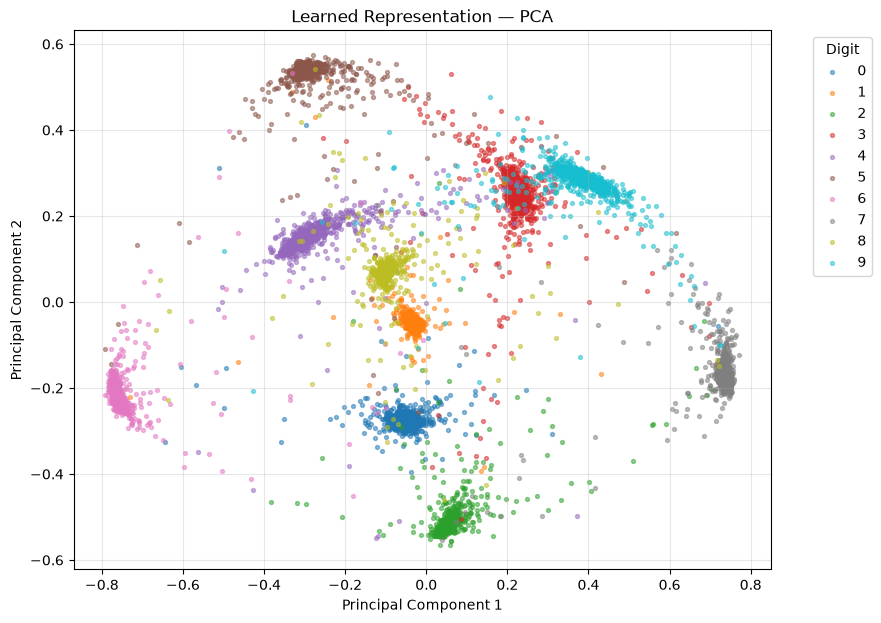

In [247]:
plt.figure(figsize=(9, 7))

for digit in range(10):
    mask = all_labels == digit

    plt.scatter(
        pca_embeddings[mask, 0],
        pca_embeddings[mask, 1],
        s=8,
        alpha=0.5,
        label=str(digit)
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Learned Representation — PCA")
plt.legend(
    title="Digit",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.show()

## 4.23.11 t-SNE Visualization

PCA is a linear projection.

t-SNE is a nonlinear visualization technique that emphasizes local neighborhood structure.

We therefore use t-SNE as a complementary diagnostic rather than treating it as a direct measure of representation quality.

In [248]:
tsne_size = min(
    3000,
    len(all_embeddings)
)

rng = np.random.default_rng(42)

tsne_indices = rng.choice(
    len(all_embeddings),
    size=tsne_size,
    replace=False
)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_embeddings = tsne.fit_transform(
    all_embeddings[tsne_indices]
)

tsne_labels = all_labels[
    tsne_indices
]

print(
    "t-SNE shape:",
    tsne_embeddings.shape
)

t-SNE shape: (3000, 2)


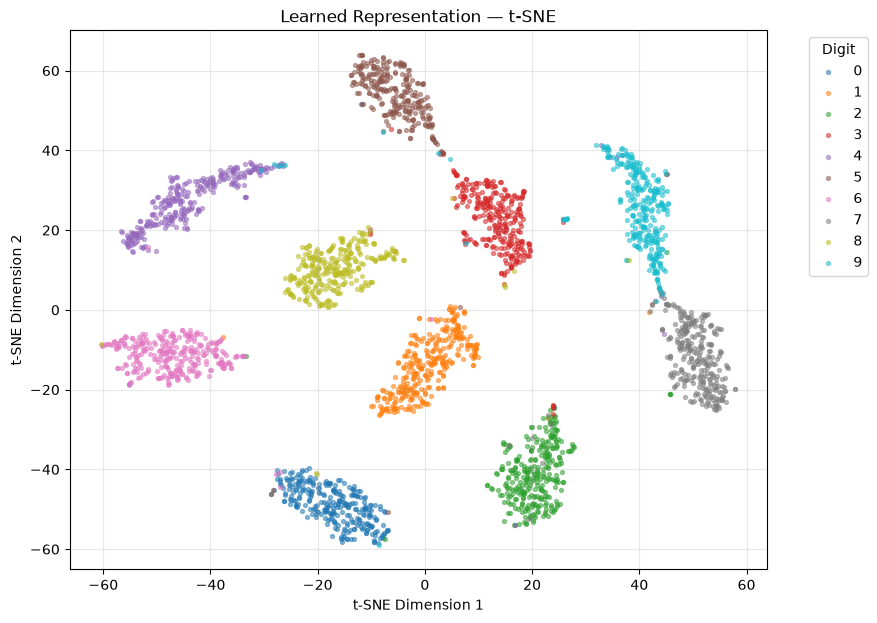

In [249]:
plt.figure(figsize=(9, 7))

for digit in range(10):
    mask = tsne_labels == digit

    plt.scatter(
        tsne_embeddings[mask, 0],
        tsne_embeddings[mask, 1],
        s=8,
        alpha=0.5,
        label=str(digit)
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Learned Representation — t-SNE")
plt.legend(
    title="Digit",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)

plt.show()

## 4.23.12 Nearest-Neighbor Retrieval

We can now use the learned representation for retrieval.

Given a query image:

$$
x_q
$$

we compute:

$$
z_q=f_\theta(x_q)
$$

Then we find embeddings with the smallest distance to $z_q$.

This demonstrates that the learned representation is useful beyond classification.

In [250]:
from sklearn.metrics import pairwise_distances

query_index = 100

query_embedding = all_embeddings[
    query_index
]

distances = np.linalg.norm(
    all_embeddings - query_embedding,
    axis=1
)

distances[query_index] = np.inf

nearest_indices = np.argsort(
    distances
)[:10]

print(
    "Query label:",
    all_labels[query_index]
)

print(
    "Nearest-neighbor labels:",
    all_labels[nearest_indices]
)

Query label: 6
Nearest-neighbor labels: [6 6 6 6 6 6 6 6 6 6]


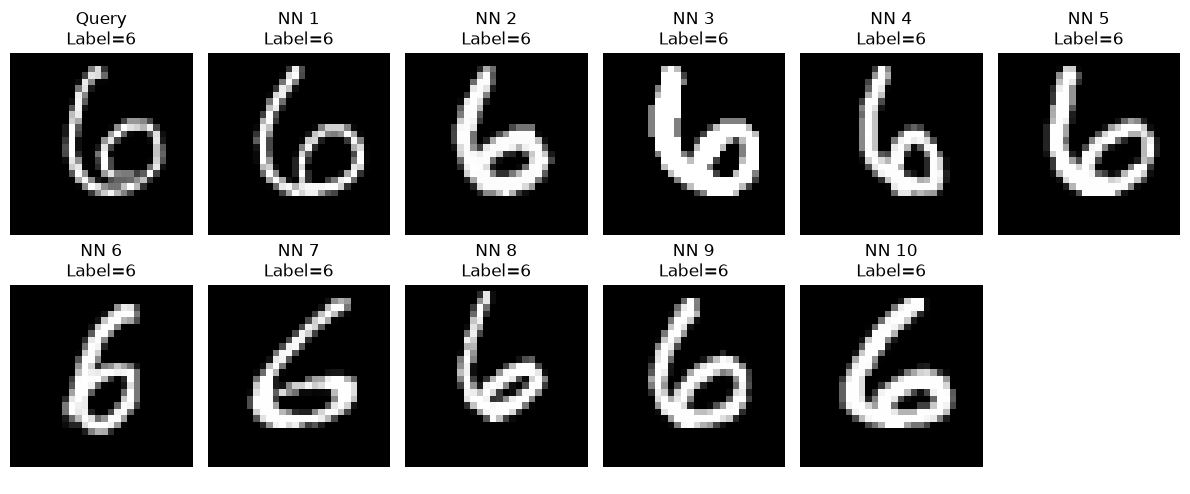

In [251]:
fig, axes = plt.subplots(
    2,
    6,
    figsize=(12, 5)
)

query_image, query_label = test_dataset[
    query_index
]

axes[0, 0].imshow(
    query_image.squeeze(),
    cmap="gray"
)

axes[0, 0].set_title(
    f"Query\nLabel={query_label}"
)

axes[0, 0].axis("off")

for i, index in enumerate(nearest_indices[:5]):
    image, label = test_dataset[index]

    axes[0, i + 1].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[0, i + 1].set_title(
        f"NN {i + 1}\nLabel={label}"
    )

    axes[0, i + 1].axis("off")

for i, index in enumerate(nearest_indices[5:10]):
    image, label = test_dataset[index]

    axes[1, i].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[1, i].set_title(
        f"NN {i + 6}\nLabel={label}"
    )

    axes[1, i].axis("off")

axes[1, 5].axis("off")

plt.tight_layout()
plt.show()

## 4.23.13 k-NN Evaluation on the Learned Representation

A representation can be evaluated by training a simple k-NN classifier on the embedding space.

The important idea is:

$$
\text{Image}
\rightarrow
\text{Encoder}
\rightarrow
\text{Embedding}
\rightarrow
\text{k-NN}
\rightarrow
\text{Prediction}
$$

If the representation is meaningful, a simple classifier should perform well.

In [252]:
# Use separate training embeddings for a proper downstream evaluation.

train_eval_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=False
)

train_embeddings = []
train_labels = []

project_model.eval()

with torch.no_grad():
    for images, labels in train_eval_loader:
        images = images.to(device)

        embeddings = project_model.encoder(
            images
        )

        train_embeddings.append(
            embeddings.cpu()
        )

        train_labels.append(
            labels
        )

train_embeddings = torch.cat(
    train_embeddings
).numpy()

train_labels = torch.cat(
    train_labels
).numpy()

print(
    "Train embedding shape:",
    train_embeddings.shape
)

print(
    "Test embedding shape:",
    all_embeddings.shape
)

Train embedding shape: (60000, 32)
Test embedding shape: (10000, 32)


In [253]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(
    train_embeddings,
    train_labels
)

knn_predictions = knn.predict(
    all_embeddings
)

knn_accuracy = accuracy_score(
    all_labels,
    knn_predictions
)

print(
    f"5-NN Representation Accuracy: "
    f"{knn_accuracy:.4f}"
)

5-NN Representation Accuracy: 0.9723


## 4.23.14 Representation Quality Summary

We have now evaluated the learned representation through several independent perspectives.

### Metric-learning behavior

$$
D_{\text{positive}}
<
D_{\text{negative}}
$$

### Visualization

- PCA
- t-SNE

### Retrieval

- nearest-neighbor search

### Downstream usability

- k-NN classification

This demonstrates an important principle:

> Representation learning is successful when the learned embedding geometry makes useful relationships easy to recover.

In [254]:
project_summary = pd.DataFrame({
    "Evaluation": [
        "Mean Positive Distance",
        "Mean Negative Distance",
        "Distance Separation",
        "5-NN Accuracy"
    ],
    "Value": [
        positive_distances.mean(),
        negative_distances.mean(),
        (
            negative_distances.mean()
            / positive_distances.mean()
        ),
        knn_accuracy
    ]
})

display(project_summary)

,Evaluation,Value
0,Mean Positive Distance,0.116446
1,Mean Negative Distance,1.021827
2,Distance Separation,8.775115
3,5-NN Accuracy,0.972300


## 4.23.15 Complete End-to-End Representation Learning Pipeline

The complete project can be summarized as:

$$
\boxed{
\text{MNIST}
\rightarrow
\text{Pair Construction}
\rightarrow
\text{Shared Encoder}
\rightarrow
\text{32D Embedding}
\rightarrow
\text{Contrastive Loss}
\rightarrow
\text{Learned Geometry}
}
$$

The learned geometry is then used for:

$$
\boxed{
\text{Embedding}
\rightarrow
\begin{cases}
\text{PCA}\\
\text{t-SNE}\\
\text{Nearest Neighbor}\\
\text{Retrieval}\\
\text{k-NN Evaluation}
\end{cases}
}
$$

This is a complete representation-learning workflow rather than only a neural-network training exercise.

## 4.23.16 What This Project Demonstrates

This project connects the major Representation Learning concepts covered in this notebook:

| Concept | Demonstrated |
|---|---|
| Learned representations | Yes |
| Feature extraction | Yes |
| Embeddings | Yes |
| Metric learning | Yes |
| Siamese networks | Yes |
| Shared weights | Yes |
| Contrastive loss | Yes |
| Positive pairs | Yes |
| Negative pairs | Yes |
| Embedding geometry | Yes |
| L2 normalization | Yes |
| PCA | Yes |
| t-SNE | Yes |
| Nearest-neighbor retrieval | Yes |
| k-NN downstream evaluation | Yes |
| Quantitative representation evaluation | Yes |

The most important conceptual transition is:

$$
\text{Learning a Classifier}
\neq
\text{Learning a Representation}
$$

A classifier primarily learns a decision function.

A representation-learning model learns an embedding space in which useful relationships between samples become explicit.

## 4.23.17 Exam Questions

### Short-answer questions

1. What is the objective of representation learning?
2. What is an embedding?
3. What is metric learning?
4. What is a Siamese network?
5. Why are the weights shared in a Siamese network?
6. What is a positive pair?
7. What is a negative pair?
8. Write the contrastive loss function.
9. What is the role of the margin in contrastive loss?
10. Why is L2 normalization useful for embeddings?
11. What is nearest-neighbor retrieval?
12. Why can k-NN be used to evaluate learned representations?
13. Why are PCA and t-SNE useful for representation analysis?
14. Why is visualization alone insufficient for evaluating a representation?

### Long-answer question

Explain a complete metric-learning-based representation learning pipeline using a Siamese network. Include:

- pair construction,
- shared encoder,
- embedding generation,
- distance calculation,
- contrastive loss,
- training,
- embedding visualization,
- retrieval,
- quantitative evaluation.

### Important derivation

For contrastive loss:

$$
L =
yD^2
+
(1-y)
\max(0,m-D)^2
$$

Explain separately what happens when:

$$
y=1
$$

and when:

$$
y=0
$$

## 4.23.18 Practical Project Conclusion

The practical project demonstrates that a neural network can learn a representation space without requiring the final objective to be ordinary classification.

The encoder learns:

$$
x\rightarrow z
$$

and metric learning shapes the geometry of $z$.

A successful representation should produce:

$$
\boxed{
\text{Similar Samples}
\rightarrow
\text{Nearby Embeddings}
}
$$

and:

$$
\boxed{
\text{Dissimilar Samples}
\rightarrow
\text{Separated Embeddings}
}
$$

The learned representation can subsequently be reused for:

- classification,
- retrieval,
- verification,
- clustering,
- visualization,
- similarity search,
- downstream machine-learning tasks.

This completes the practical representation-learning workflow.

# 4.24 Comparison of Representation Learning Methods

Representation learning can be performed using several different learning paradigms.

The major approaches covered in this notebook are:

* Autoencoder-based representation learning
* Supervised representation learning
* Self-supervised representation learning
* Metric learning
* Siamese networks
* Contrastive learning
* Triplet learning

Although these methods all learn representations, they differ in:

* source of supervision,
* training objective,
* structure of the learned embedding space,
* downstream usability,
* data requirements,
* computational requirements.

---

## 4.24.1 General Representation Learning Framework

Most representation-learning methods can be described using an encoder:

$$
z=f_\theta(x)
$$

where:

* $x$ is the input,
* $f_\theta$ is the encoder,
* $z$ is the learned representation.

The major difference between methods is **how the representation is trained**.

For example:

$$
\text{Supervised}
\rightarrow
\text{Class Labels}
$$

$$
\text{Self-Supervised}
\rightarrow
\text{Artificial Learning Objective}
$$

$$
\text{Metric Learning}
\rightarrow
\text{Distance Relationships}
$$

$$
\text{Autoencoder}
\rightarrow
\text{Reconstruction}
$$

---

## 4.24.2 Autoencoder-Based Representation Learning

An autoencoder contains:

$$
x
\rightarrow
Encoder
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

The representation is learned by minimizing reconstruction error:

$$
L_{reconstruction}
=
D(x,\hat{x})
$$

For example:

$$
L_{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
(x_i-\hat{x}_i)^2
$$

The encoder is encouraged to preserve information necessary to reconstruct the input.

### Advantages

* Does not require labels.
* Simple to implement.
* Useful for dimensionality reduction.
* Useful for reconstruction.
* Can learn compact latent representations.

### Limitations

A reconstruction-optimal representation is not necessarily optimal for:

* classification,
* retrieval,
* verification,
* semantic similarity.

Therefore, autoencoders are useful representation learners, but the representation objective is different from metric learning.

---

## 4.24.3 Supervised Representation Learning

In supervised representation learning:

$$
x
\rightarrow
f_\theta(x)
\rightarrow
z
\rightarrow
g_\phi(z)
\rightarrow
\hat{y}
$$

The model minimizes a supervised objective such as cross-entropy:

$$
L_{CE}
=
-\sum_{c}
y_c\log(\hat{y}_c)
$$

The representation is optimized specifically for the labeled task.

### Advantages

* Usually strong performance on the supervised task.
* Directly uses semantic labels.
* Easy to evaluate.
* Effective when sufficient labeled data exists.

### Limitations

* Requires labeled data.
* Representation can become task-specific.
* May transfer poorly to unrelated downstream tasks.

---

## 4.24.4 Self-Supervised Representation Learning

Self-supervised learning creates supervision from the data itself.

The general process is:

$$
x
\rightarrow
\text{Pretext/Pretraining Objective}
\rightarrow
f_\theta
\rightarrow
z
$$

Examples include:

* reconstruction,
* masked prediction,
* rotation prediction,
* contrastive learning,
* predictive learning.

The key advantage is that large quantities of unlabeled data can be used.

A self-supervised representation can later be transferred to downstream tasks.

---

## 4.24.5 Metric Learning

Metric learning explicitly learns the geometry of an embedding space.

The encoder produces:

$$
z=f_\theta(x)
$$

and the training objective operates on distances or similarities.

For two samples:

$$
D(z_i,z_j)
$$

The objective encourages:

$$
\text{Similar}
\rightarrow
D\text{ small}
$$

and:

$$
\text{Dissimilar}
\rightarrow
D\text{ large}
$$

Metric learning is especially useful when the final task involves:

* similarity,
* retrieval,
* verification,
* identification,
* nearest-neighbor search.

---

## 4.24.6 Siamese Networks

A Siamese network uses two or more branches with shared parameters.

For two inputs:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

The same encoder parameters $\theta$ are used for both branches.

The embeddings are then compared.

The architecture can therefore be represented as:

$$
x_1
\rightarrow
f_\theta
\rightarrow
z_1
$$

$$
x_2
\rightarrow
f_\theta
\rightarrow
z_2
$$

followed by:

$$
D(z_1,z_2)
$$

A Siamese network is an **architecture**, while contrastive loss is a **learning objective**.

This distinction is important.

---

## 4.24.7 Contrastive Learning

Contrastive learning learns representations by comparing positive and negative examples.

For a positive pair:

$$
(x_i,x_j),\quad y=1
$$

the model encourages:

$$
D(z_i,z_j)\rightarrow0
$$

For a negative pair:

$$
(x_i,x_j),\quad y=0
$$

the model encourages separation.

A classical contrastive loss is:

$$
L
=
yD^2
+
(1-y)
\max(0,m-D)^2
$$

where $m$ is the margin.

Contrastive learning can therefore directly shape embedding geometry.

---

## 4.24.8 Triplet Learning

Triplet learning uses three samples:

* anchor,
* positive,
* negative.

They are represented as:

$$
z_a=f_\theta(x_a)
$$

$$
z_p=f_\theta(x_p)
$$

$$
z_n=f_\theta(x_n)
$$

The desired relationship is:

$$
D(z_a,z_p)+m
<
D(z_a,z_n)
$$

The triplet loss is:

$$
L
=
\max
\left(
0,
D(z_a,z_p)-D(z_a,z_n)+m
\right)
$$

The model therefore learns relative ordering rather than simply classifying samples.

---

## 4.24.9 Supervised vs Self-Supervised Representation Learning

| Property         | Supervised              | Self-Supervised                  |
| ---------------- | ----------------------- | -------------------------------- |
| Labels           | Required                | Not manually required            |
| Objective        | Downstream task         | Pretext/pretraining task         |
| Data scalability | Limited by labeled data | Can use large unlabeled datasets |
| Representation   | Often task-specific     | Often more reusable              |
| Typical use      | Classification          | Pretraining                      |
| Transferability  | Depends on task         | Often strong                     |

The fundamental distinction is:

$$
\boxed{
\text{Supervised}
=
\text{Human-Provided Supervision}
}
$$

while:

$$
\boxed{
\text{Self-Supervised}
=
\text{Data-Derived Supervision}
}
$$

---

## 4.24.10 Contrastive vs Triplet Learning

| Property                 | Contrastive                      | Triplet                       |
| ------------------------ | -------------------------------- | ----------------------------- |
| Samples                  | Pair                             | Triplet                       |
| Inputs                   | Two                              | Three                         |
| Main relationship        | Similar/dissimilar               | Relative similarity           |
| Positive example         | Yes                              | Yes                           |
| Negative example         | Yes                              | Yes                           |
| Margin                   | Commonly used                    | Commonly used                 |
| Main objective           | Separate positive/negative pairs | Positive closer than negative |
| Hard-negative importance | High                             | Very high                     |
| Computational cost       | Lower per training example       | Higher per training example   |

Contrastive learning asks:

> Are these two samples similar?

Triplet learning asks:

> Is the positive sample closer to the anchor than the negative sample?

---

## 4.24.11 Siamese Network vs Contrastive Learning

These concepts should not be confused.

### Siamese Network

Describes the architecture:

$$
f_\theta(x_1),f_\theta(x_2)
$$

with shared parameters.

### Contrastive Loss

Describes the objective:

$$
L
=
yD^2
+
(1-y)
\max(0,m-D)^2
$$

Therefore:

$$
\boxed{
\text{Siamese Network}
=
\text{Architecture}
}
$$

$$
\boxed{
\text{Contrastive Loss}
=
\text{Objective}
}
$$

A Siamese network can be trained with contrastive loss, but the two concepts are not identical.

---

## 4.24.12 Representation Learning Method Comparison

| Method               | Supervision                     | Main Objective            | Embedding Focus          | Typical Applications        |
| -------------------- | ------------------------------- | ------------------------- | ------------------------ | --------------------------- |
| Autoencoder          | Unlabeled                       | Reconstruction            | Information preservation | Compression, reconstruction |
| Supervised Encoder   | Labels                          | Classification/regression | Task-specific            | Classification              |
| Self-Supervised      | Data-derived                    | Pretext/pretraining       | Reusable features        | Pretraining                 |
| Metric Learning      | Pair/triplet relationships      | Distance learning         | Similarity geometry      | Retrieval, verification     |
| Siamese Network      | Pair relationships              | Similarity comparison     | Pairwise geometry        | Verification                |
| Contrastive Learning | Positive/negative relationships | Similarity separation     | Embedding geometry       | Retrieval, pretraining      |
| Triplet Learning     | Relative relationships          | Ranking distances         | Relative geometry        | Face/person retrieval       |

---

## 4.24.13 Training Objective Comparison

The objectives can be summarized as:

### Autoencoder

$$
x\rightarrow z\rightarrow\hat{x}
$$

Minimize:

$$
D(x,\hat{x})
$$

### Supervised Representation

$$
x\rightarrow z\rightarrow\hat{y}
$$

Minimize:

$$
L(y,\hat{y})
$$

### Contrastive Learning

$$
(x_i,x_j)
\rightarrow
D(z_i,z_j)
$$

Optimize similarity relationships.

### Triplet Learning

$$
(x_a,x_p,x_n)
\rightarrow
D(z_a,z_p),D(z_a,z_n)
$$

Optimize relative distance:

$$
D_{ap}+m<D_{an}
$$

---

## 4.24.14 Which Method Should We Choose?

There is no universally best representation-learning method.

The choice depends on the problem.

### If reconstruction is important

Use:

$$
\boxed{\text{Autoencoder}}
$$

### If labeled task performance is the priority

Use:

$$
\boxed{\text{Supervised Representation Learning}}
$$

### If large amounts of unlabeled data are available

Use:

$$
\boxed{\text{Self-Supervised Learning}}
$$

### If similarity or retrieval is the main objective

Use:

$$
\boxed{\text{Metric Learning}}
$$

### If pair verification is important

Use:

$$
\boxed{\text{Siamese + Contrastive Learning}}
$$

### If relative ranking is important

Use:

$$
\boxed{\text{Triplet Learning}}
$$

---

## 4.24.15 Representation Learning Decision Map

$$
\text{Problem}
\rightarrow
\begin{cases}
\text{Reconstruction}
&\rightarrow \text{Autoencoder}\\
\text{Classification}
&\rightarrow \text{Supervised Representation}\\
\text{Unlabeled Pretraining}
&\rightarrow \text{Self-Supervised}\\
\text{Similarity}
&\rightarrow \text{Metric Learning}\\
\text{Verification}
&\rightarrow \text{Siamese/Contrastive}\\
\text{Ranking}
&\rightarrow \text{Triplet Learning}
\end{cases}
$$

This is a useful exam-oriented decision framework.

---

## 4.24.16 Practical Comparison Using the Learned Embedding

In this notebook we have already trained representations using multiple approaches.

The main comparison is:

$$
\text{Representation}
\rightarrow
\text{Evaluation}
\rightarrow
\text{Downstream Performance}
$$

Useful evaluation metrics include:

* nearest-neighbor accuracy,
* k-NN accuracy,
* Precision@K,
* Recall@K,
* ROC-AUC,
* clustering metrics,
* intra-class distance,
* inter-class distance,
* linear-probe performance.

Therefore, different representation-learning methods can be compared using a common evaluation framework.

---

## 4.24.17 Core Conceptual Distinctions

### Representation learning vs dimensionality reduction

Dimensionality reduction primarily seeks a lower-dimensional representation.

Representation learning is broader and seeks useful learned features.

### Metric learning vs classification

Classification learns:

$$
x\rightarrow y
$$

Metric learning learns:

$$
x\rightarrow z
$$

and shapes relationships within $z$.

### Contrastive vs triplet learning

Contrastive learning works with pairs.

Triplet learning works with relative relationships among three samples.

### Siamese network vs contrastive loss

Siamese network = architecture.

Contrastive loss = objective.

### Visualization vs evaluation

PCA and t-SNE help visualize representations.

They do not by themselves prove that a representation is useful.

Quantitative downstream evaluation is still required.

---

## 4.24.18 Exam Questions

### Short Questions

1. What is representation learning?
2. What is an embedding?
3. Compare supervised and self-supervised representation learning.
4. What is metric learning?
5. What is a Siamese network?
6. What is contrastive learning?
7. What is triplet learning?
8. Differentiate Siamese architecture and contrastive loss.
9. What is the purpose of a margin?
10. What is representation collapse?
11. Why are embeddings useful for retrieval?
12. What is a linear probe?

### Important Long Questions

#### Question 1

Compare autoencoder-based, supervised, self-supervised, and metric-learning approaches to representation learning.

#### Question 2

Explain Siamese networks and contrastive loss with mathematical formulation.

#### Question 3

Explain triplet loss and compare it with contrastive loss.

#### Question 4

Explain how representation quality can be evaluated quantitatively.

#### Question 5

Discuss the applications of metric learning in retrieval and verification.

---

## 4.24.19 Final Comparison Table

| Feature             | Autoencoder       | Supervised       | Self-Supervised        | Contrastive                               | Triplet                                      |
| ------------------- | ----------------- | ---------------- | ---------------------- | ----------------------------------------- | -------------------------------------------- |
| Manual labels       | No                | Yes              | No                     | Usually no/manual labels may define pairs | Usually no/manual labels may define triplets |
| Main signal         | Reconstruction    | Target labels    | Pretext/data structure | Positive/negative relationships           | Relative ordering                            |
| Embedding           | Yes               | Yes              | Yes                    | Yes                                       | Yes                                          |
| Similarity learning | Indirect          | Possible         | Often                  | Direct                                    | Direct                                       |
| Retrieval           | Possible          | Possible         | Strong potential       | Strong                                    | Strong                                       |
| Verification        | Possible          | Possible         | Possible               | Strong                                    | Strong                                       |
| Reconstruction      | Strong            | Not primary      | Depends on task        | Not primary                               | Not primary                                  |
| Transfer learning   | Possible          | Task dependent   | Strong potential       | Strong potential                          | Strong potential                             |
| Main challenge      | Latent usefulness | Label dependency | Objective design       | Negative selection                        | Triplet mining                               |

---

## 4.24.20 Representation Learning — Final Understanding

The central idea behind all these approaches is:

$$
\boxed{
\text{Learn a useful transformation}
\quad
x\rightarrow z
}
$$

The difference is **what makes a representation useful**.

For an autoencoder:

$$
z
\rightarrow
\text{reconstruct }x
$$

For supervised learning:

$$
z
\rightarrow
\text{predict }y
$$

For contrastive learning:

$$
z_i,z_j
\rightarrow
\text{learn similarity}
$$

For triplet learning:

$$
z_a,z_p,z_n
\rightarrow
\text{learn relative ordering}
$$

For self-supervised learning:

$$
z
\rightarrow
\text{solve a data-derived task}
$$

Therefore:

$$
\boxed{
\text{Representation Learning}
=
\text{Learning Useful Feature Geometry}
}
$$

The representation itself becomes a reusable computational object that can support classification, retrieval, verification, clustering, visualization, and other downstream tasks.


# 4.25 Representation Learning — Final Summary

Representation Learning is the process of automatically learning useful features or representations from raw data.

The central transformation is:

$$
z=f_\theta(x)
$$

where:

- $x$ = input data,
- $f_\theta$ = learned encoder,
- $z$ = learned representation or embedding.

Instead of manually designing features, the neural network learns representations that are useful for a particular objective or set of downstream tasks.

## 4.25.1 Complete Representation Learning Map

The major representation-learning approaches studied in this notebook are:

$$
\boxed{
\text{Representation Learning}
}
$$

$$
\downarrow
$$

$$
\begin{cases}
\text{Autoencoder Representation Learning}\\
\text{Supervised Representation Learning}\\
\text{Self-Supervised Representation Learning}\\
\text{Metric Learning}\\
\text{Siamese Networks}\\
\text{Contrastive Learning}\\
\text{Triplet Learning}
\end{cases}
$$

Each approach defines usefulness of a representation differently.

## 4.25.2 Autoencoder Representation

An autoencoder learns:

$$
x
\rightarrow
Encoder
\rightarrow
z
\rightarrow
Decoder
\rightarrow
\hat{x}
$$

The objective is to reconstruct the original input:

$$
L_{reconstruction}=D(x,\hat{x})
$$

Therefore, the representation is encouraged to preserve information necessary for reconstruction.

Main applications:

- dimensionality reduction,
- compression,
- reconstruction,
- anomaly detection,
- feature learning.

## 4.25.3 Supervised Representation

A supervised model learns a representation using labeled data:

$$
x
\rightarrow
f_\theta(x)
\rightarrow
z
\rightarrow
g_\phi(z)
\rightarrow
\hat{y}
$$

The representation is optimized for the supervised objective.

For classification:

$$
L_{CE}
=
-\sum_c y_c\log(\hat{y}_c)
$$

The learned representation can be highly effective for the target task, but may become task-specific.

## 4.25.4 Self-Supervised Representation

Self-supervised learning obtains supervision from the data itself.

The general process is:

$$
x
\rightarrow
\text{Pretext / Pretraining Objective}
\rightarrow
z
$$

Examples include:

- masked prediction,
- reconstruction,
- rotation prediction,
- contrastive learning,
- predictive learning.

The major advantage is the ability to learn from large quantities of unlabeled data.

A learned encoder can subsequently be reused for downstream tasks.

## 4.25.5 Metric Learning

Metric learning focuses explicitly on the geometry of the embedding space.

The encoder produces:

$$
z=f_\theta(x)
$$

and distances are used to express semantic relationships:

$$
D(z_i,z_j)
$$

The desired geometry is generally:

$$
\text{Similar}
\rightarrow
\text{Small Distance}
$$

$$
\text{Dissimilar}
\rightarrow
\text{Large Distance}
$$

Typical applications include:

- similarity search,
- retrieval,
- verification,
- identification,
- face recognition,
- person re-identification.

## 4.25.6 Siamese Networks

A Siamese network contains multiple branches that share parameters.

For two inputs:

$$
z_1=f_\theta(x_1)
$$

$$
z_2=f_\theta(x_2)
$$

The same parameters $\theta$ are used in both branches.

The embeddings are then compared:

$$
D(z_1,z_2)
$$

Important distinction:

$$
\boxed{
\text{Siamese Network = Architecture}
}
$$

while:

$$
\boxed{
\text{Contrastive Loss = Training Objective}
}
$$

## 4.25.7 Contrastive Learning

Contrastive learning learns representations from relationships between samples.

For a positive pair:

$$
y=1
$$

the objective encourages:

$$
D(z_1,z_2)\rightarrow0
$$

For a negative pair:

$$
y=0
$$

the objective encourages separation.

The classical contrastive loss is:

$$
L
=
yD^2
+
(1-y)\max(0,m-D)^2
$$

where $m$ is the margin.

Contrastive learning directly shapes the geometry of the embedding space.

## 4.25.8 Triplet Learning

Triplet learning uses:

- anchor,
- positive,
- negative.

Their embeddings are:

$$
z_a=f_\theta(x_a)
$$

$$
z_p=f_\theta(x_p)
$$

$$
z_n=f_\theta(x_n)
$$

The desired relationship is:

$$
D(z_a,z_p)+m<D(z_a,z_n)
$$

The triplet loss is:

$$
L
=
\max
\left(
0,
D(z_a,z_p)-D(z_a,z_n)+m
\right)
$$

Triplet learning therefore learns relative ordering in the embedding space.

## 4.25.9 Feature Extractor and Projection Head

Modern representation-learning systems often distinguish between the encoder representation and the projection representation.

The encoder produces:

$$
h=f_\theta(x)
$$

A projection head then produces:

$$
z=g_\phi(h)
$$

The training objective may operate on $z$, while downstream tasks often use $h$.

Therefore:

$$
\boxed{
x
\rightarrow
\text{Encoder}
\rightarrow
h
\rightarrow
\text{Projection Head}
\rightarrow
z
}
$$

This distinction is particularly important in contrastive representation learning.

## 4.25.10 Representation Geometry

One of the most important ideas in Representation Learning is that the embedding space has meaningful geometry.

A successful representation should generally produce:

$$
D_{\text{intra}}
<
D_{\text{inter}}
$$

where:

- $D_{\text{intra}}$ = average distance between samples from the same semantic group,
- $D_{\text{inter}}$ = average distance between samples from different groups.

This geometry enables:

- nearest-neighbor classification,
- retrieval,
- verification,
- clustering,
- similarity search.

## 4.25.11 Representation Evaluation

Representation quality should not be judged only by looking at a PCA or t-SNE plot.

We studied several quantitative approaches:

### Local structure

- nearest-neighbor accuracy,
- k-NN accuracy,
- Precision@K,
- Recall@K.

### Pairwise discrimination

- verification,
- ROC,
- ROC-AUC.

### Global structure

- Silhouette Score,
- Adjusted Rand Index,
- Normalized Mutual Information.

### Distance analysis

- intra-class distance,
- inter-class distance,
- separation ratio.

### Downstream usefulness

- linear probing,
- downstream classification,
- retrieval performance.

### Failure analysis

- embedding variance,
- representation collapse.

## 4.25.12 Representation Collapse

Representation collapse occurs when different inputs are mapped to nearly identical representations:

$$
f_\theta(x_1)
\approx
f_\theta(x_2)
\approx
\cdots
\approx
f_\theta(x_n)
$$

A collapsed representation contains little useful information.

Typical symptoms include:

- very low embedding variance,
- poor retrieval,
- poor class separation,
- poor downstream performance.

Avoiding collapse is therefore an important consideration in representation learning.

## 4.25.13 Representation Learning vs Classification

Classification learns a mapping:

$$
x\rightarrow y
$$

Representation learning learns:

$$
x\rightarrow z
$$

The representation can then be reused:

$$
z\rightarrow
\begin{cases}
\text{Classification}\\
\text{Retrieval}\\
\text{Verification}\\
\text{Clustering}\\
\text{Similarity Search}
\end{cases}
$$

Therefore, representation learning provides an intermediate feature space rather than necessarily producing the final prediction directly.

## 4.25.14 Complete Representation Learning Pipeline

A general representation-learning pipeline is:

$$
\boxed{
\text{Raw Data}
\rightarrow
\text{Encoder}
\rightarrow
\text{Representation}
\rightarrow
\text{Learning Objective}
\rightarrow
\text{Embedding Space}
\rightarrow
\text{Evaluation}
\rightarrow
\text{Downstream Task}
}
$$

For metric learning:

$$
\text{Input}
\rightarrow
\text{Shared Encoder}
\rightarrow
\text{Embedding}
\rightarrow
\text{Distance}
\rightarrow
\text{Metric Loss}
$$

For self-supervised learning:

$$
\text{Unlabeled Data}
\rightarrow
\text{Self-Supervised Objective}
\rightarrow
\text{Encoder}
\rightarrow
\text{Reusable Representation}
$$

## 4.25.15 Final Comparison

| Method | Main Signal | Main Objective | Main Strength |
|---|---|---|---|
| Autoencoder | Input | Reconstruction | Information preservation |
| Supervised | Labels | Prediction | Strong task performance |
| Self-Supervised | Data-derived signal | Pretraining | Uses unlabeled data |
| Metric Learning | Similarity relationships | Distance learning | Similarity and retrieval |
| Siamese Network | Pairs | Compare embeddings | Verification |
| Contrastive Learning | Positive/negative samples | Separate relationships | Strong embedding geometry |
| Triplet Learning | Anchor/positive/negative | Relative ranking | Fine-grained similarity |

The methods differ in training strategy, but all attempt to learn useful representations.

## 4.25.16 Final Conceptual Picture

The complete idea can be summarized as:

$$
\boxed{
x
\overset{f_\theta}{\longrightarrow}
z
}
$$

The goal is to make $z$ useful.

Depending on the learning paradigm:

$$
z
\rightarrow
\text{reconstruction}
$$

or:

$$
z
\rightarrow
\text{prediction}
$$

or:

$$
z_i,z_j
\rightarrow
\text{similarity}
$$

or:

$$
z_a,z_p,z_n
\rightarrow
\text{relative ranking}
$$

The final embedding can then be reused for many downstream applications.

## 4.25.17 Representation Learning — Final Takeaway

The most important idea to remember is:

$$
\boxed{
\text{Representation Learning}
=
\text{Automatically Learning Useful Features}
}
$$

A representation is valuable when it captures information that makes important downstream relationships easier to model.

In metric-learning settings:

$$
\boxed{
\text{Similar}
\rightarrow
\text{Nearby}
}
$$

$$
\boxed{
\text{Dissimilar}
\rightarrow
\text{Far Apart}
}
$$

In modern Deep Learning, learned representations are fundamental because the same representation can often support multiple downstream tasks.

Representation learning therefore forms a bridge between:

$$
\boxed{
\text{Raw Data}
\rightarrow
\text{Learned Features}
\rightarrow
\text{Intelligent Tasks}
}
$$

This completes the Representation Learning portion of `dl_paradigms.ipynb`.

# 5.1 Transfer Learning

Transfer Learning is a Deep Learning approach where knowledge learned from one task or dataset is reused to improve learning on another related task.

Instead of training a neural network completely from scratch, we start with a model that has already learned useful representations from a large source dataset.

The learned knowledge can then be:

- reused directly,
- adapted to a new task,
- or fine-tuned using the target dataset.

The central idea is:

$$
\boxed{
\text{Learn representations on a source task}
\rightarrow
\text{Transfer them to a target task}
}
$$

For example, a CNN trained on a large image dataset may learn:

- edges,
- corners,
- textures,
- shapes,
- object parts,
- high-level visual patterns.

These representations can be useful for another image classification problem.

---

## Source and Target Domains

Transfer learning usually involves two learning problems.

### Source domain

The model is initially trained using a source dataset:

$$
D_S = \{(x_i^S, y_i^S)\}
$$

and learns parameters:

$$
\theta_S
$$

### Target domain

We want to solve a new target problem:

$$
D_T = \{(x_i^T, y_i^T)\}
$$

using the knowledge contained in:

$$
\theta_S
$$

The transferred model starts from:

$$
\theta_T \leftarrow \theta_S
$$

instead of starting from random initialization.

---

## Why Transfer Learning?

Training a Deep Neural Network from scratch can require:

- large datasets,
- significant computational resources,
- long training time,
- careful hyperparameter tuning.

Transfer learning can reduce these requirements.

The pretrained model has already learned useful representations.

Therefore, the target task only needs to adapt those representations.

---

## Basic Transfer Learning Pipeline

The general pipeline is:

$$
\text{Large Source Dataset}
\rightarrow
\text{Pretrained Model}
\rightarrow
\text{Learned Representations}
\rightarrow
\text{Target Dataset}
\rightarrow
\text{Adaptation/Fine-Tuning}
$$

A typical CNN can be viewed as:

$$
x
\rightarrow
\underbrace{f_{\theta}(x)}_{\text{feature extractor}}
\rightarrow
\underbrace{g_{\phi}(z)}_{\text{task-specific head}}
\rightarrow
\hat{y}
$$

where:

$$
z=f_{\theta}(x)
$$

is the learned representation.

In transfer learning, we often reuse:

$$
f_{\theta}
$$

and replace or modify:

$$
g_{\phi}
$$

for the new task.

---

## Two Main Transfer Learning Strategies

### 1. Feature Extraction

Keep the pretrained feature extractor frozen and train only a new classifier.

$$
\theta_{\text{pretrained}} = \text{fixed}
$$

while:

$$
\phi = \text{trainable}
$$

This is especially useful when:

- the target dataset is small,
- the source and target tasks are reasonably related,
- computational resources are limited.

---

### 2. Fine-Tuning

Start with pretrained parameters and allow some or all layers to update.

$$
\theta_T \leftarrow \theta_S
$$

and then optimize the model on the target dataset.

Fine-tuning is useful when:

- the target dataset is sufficiently large,
- the target task differs from the source task,
- pretrained features need adaptation.

---

## Feature Extraction vs Fine-Tuning

| Property | Feature Extraction | Fine-Tuning |
|---|---|---|
| Pretrained layers | Frozen | Partially/all trainable |
| New classifier | Trainable | Trainable |
| Training cost | Lower | Higher |
| Overfitting risk | Lower | Higher |
| Adaptability | Lower | Higher |
| Small datasets | Very useful | Can overfit |
| Large datasets | May be sufficient | Often preferred |

---

## Key Idea

Transfer learning does not mean simply copying a model.

It means:

$$
\boxed{
\text{Reusing learned knowledge for a new learning problem}
}
$$

This is one of the most important ideas in modern Deep Learning.

# 5.2 Why Pretrained Networks Work

A Deep Neural Network learns hierarchical representations.

For image models, early layers often learn relatively general patterns.

For example:

$$
\text{Pixels}
\rightarrow
\text{Edges}
\rightarrow
\text{Textures}
\rightarrow
\text{Shapes}
\rightarrow
\text{Object Parts}
\rightarrow
\text{Objects}
$$

The lower layers therefore tend to capture features that are useful across many visual tasks.

Higher layers become increasingly specialized to the original training task.

This gives us an important transfer-learning principle:

$$
\boxed{
\text{Early features are often more general}
}
$$

while:

$$
\boxed{
\text{Later features are often more task-specific}
}
$$

Therefore, when transferring a pretrained CNN:

- early layers are often frozen,
- later layers may be fine-tuned,
- the final classification layer is usually replaced.

---

## Representation Reuse

Suppose a pretrained network learns:

$$
z=f_{\theta_S}(x)
$$

for the source task.

For a new target task, we can reuse:

$$
z=f_{\theta_S}(x)
$$

and learn a new task-specific classifier:

$$
\hat{y}=g_{\phi}(z)
$$

The pretrained network therefore acts as a powerful feature extractor.

---

## Why This Reduces Data Requirements

A randomly initialized network must learn useful visual features from the target dataset.

A pretrained network already contains useful representations.

Therefore the target training process can focus more on:

$$
\text{Task Adaptation}
$$

rather than:

$$
\text{Learning All Features From Scratch}
$$

This is particularly valuable when the target dataset is small.

## 5.3 Transfer Learning with a Pretrained CNN

In [1]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [2]:
# Load a pretrained ResNet-18

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\soumy/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

You should see the pretrained ResNet architecture.

Now inspect the final layer.

In [3]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


The final layer is designed for the original ImageNet classification problem.

We therefore replace it for our target task.

## Replacing the Classification Head

The pretrained ResNet produces a high-level representation.

Its final fully connected layer maps that representation to the original number of classes.

For a new task with:

$$
C_T
$$

target classes, we replace the original classifier with:

$$
g_{\phi}: \mathbb{R}^{d}\rightarrow\mathbb{R}^{C_T}
$$

For example, if our target problem has 10 classes:

$$
g_{\phi}: \mathbb{R}^{512}\rightarrow\mathbb{R}^{10}
$$

In [4]:
num_target_classes = 10

model.fc = nn.Linear(
    model.fc.in_features,
    num_target_classes
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


```
Pretrained CNN
      │
      ▼
Learned Feature Extractor
      │
      ▼
New Target Classification Head
      │
      ▼
Target Prediction

# 5.4 Freezing the Pretrained Layers

For feature extraction, we usually freeze the pretrained layers.

A frozen parameter does not receive gradient updates.

Mathematically:

$$
\nabla_{\theta}L=0
$$

for frozen parameters.

Only the new classification head is trained.

This prevents the pretrained representation from being changed during target training.

In [5]:
# Freeze all pretrained layers

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the new classification head

for param in model.fc.parameters():
    param.requires_grad = True

In [6]:
trainable_params = [
    name for name, param in model.named_parameters()
    if param.requires_grad
]

print("Trainable parameters:")
for name in trainable_params:
    print(name)

Trainable parameters:
fc.weight
fc.bias


## 5.5 Counting Trainable Parameters

In [7]:
total_params = sum(
    param.numel()
    for param in model.parameters()
)

trainable_params = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Total parameters: 11,181,642
Trainable parameters: 5,130
Frozen parameters: 11,176,512


This demonstrates an important advantage of transfer learning:

We can reuse a large pretrained network while training only a small number of parameters.

# 5.6 Fine-Tuning

Feature extraction keeps the pretrained feature extractor completely frozen.

Fine-tuning goes one step further.

We allow selected pretrained layers to update.

For example:

$$
\text{Frozen Early Layers}
\rightarrow
\text{Trainable Later Layers}
\rightarrow
\text{New Classification Head}
$$

This allows the model to adapt its learned representations to the target domain.

---

## Typical Fine-Tuning Strategy

A common strategy is:

1. Load pretrained model.
2. Replace the final classification layer.
3. Freeze most pretrained layers.
4. Train the new classification head.
5. Unfreeze some deeper layers.
6. Continue training using a small learning rate.

The smaller learning rate is important because the pretrained parameters already contain useful knowledge.

A large learning rate could destroy useful pretrained representations.

Therefore:

$$
\boxed{
\text{Fine-tuning usually uses a smaller learning rate}
}
$$

In [8]:
# Start by freezing everything

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last residual block

for param in model.layer4.parameters():
    param.requires_grad = True

# Keep the classification head trainable

for param in model.fc.parameters():
    param.requires_grad = True

In [9]:
trainable_params = [
    name for name, param in model.named_parameters()
    if param.requires_grad
]

for name in trainable_params:
    print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


Now both:

layer4
fc

are trainable.

## 5.7 Optimizer for Fine-Tuning

In [10]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()

The use of a relatively small learning rate is intentional.

We do not want to aggressively modify the pretrained representation.

# 5.8 Transfer Learning Pipeline

The complete transfer-learning pipeline can be summarized as:

$$
\boxed{
\text{Pretrained Model}
\rightarrow
\text{Freeze/Unfreeze}
\rightarrow
\text{Replace Head}
\rightarrow
\text{Train on Target Data}
\rightarrow
\text{Evaluate}
}
$$

There are three important components:

### 1. Pretrained backbone

Provides reusable representations.

### 2. Target-specific head

Maps the representation to target classes.

### 3. Fine-tuning strategy

Controls how much of the pretrained network is adapted.

In [11]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    return total, trainable


total, trainable = count_parameters(model)

print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

Total parameters: 11,181,642
Trainable parameters: 8,398,858


# 5.9 Transfer Learning — Important Concepts

### Source task

The original task used to train the pretrained model.

### Target task

The new task where the pretrained knowledge is reused.

### Pretrained model

A neural network whose parameters have already been learned from a source dataset.

### Backbone

The main feature-extraction portion of a neural network.

### Classification head

The final task-specific prediction layers.

### Feature extraction

Freeze the pretrained backbone and train a new head.

### Fine-tuning

Allow some pretrained layers to update using target data.

### Frozen parameters

Parameters with:

```python
requires_grad = False

Trainable parameters

Parameters with:

requires_grad = True

Domain shift

The source and target data distributions may differ.

For example:

$$ P_S(x)\neq P_T(x) $$

The larger the difference between source and target domains, the more adaptation may be required.

Core Principle

Transfer learning works best when the source and target problems share useful structure.

For example:

$$ \text{Image Classification} \rightarrow \text{Related Image Classification} $$

usually allows effective transfer.

The transfer may become harder when the source and target domains are very different.


That gives us the **theoretical foundation and PyTorch mechanics** of Transfer Learning.

Next we should build the practical section using a real target dataset, including **feature extraction vs fine

# 5.10 Practical Transfer Learning — CIFAR-10

We will use a pretrained ResNet-18 and adapt it to CIFAR-10.

CIFAR-10 contains 10 image classes:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

The pretrained ResNet-18 was originally trained on ImageNet.

Our target task is CIFAR-10 classification.

Therefore:

$$
\text{Source Task: ImageNet Classification}
$$

and:

$$
\text{Target Task: CIFAR-10 Classification}
$$

The goal is to reuse the visual representations learned from ImageNet.

---

## Experiment

We will perform two stages.

### Stage 1 — Feature Extraction

Freeze the pretrained ResNet backbone.

Train only the new CIFAR-10 classification head.

$$
\theta_{\text{backbone}}=\text{fixed}
$$

$$
\phi_{\text{head}}=\text{trainable}
$$

### Stage 2 — Fine-Tuning

Unfreeze the deeper layers of the pretrained network.

Train:

$$
\theta_{\text{deep}}
$$

and:

$$
\phi_{\text{head}}
$$

using a small learning rate.

This allows the pretrained representation to adapt to CIFAR-10.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## CIFAR-10 Preprocessing

ImageNet-pretrained models expect inputs with approximately:

- 3 color channels
- spatial dimensions compatible with the network
- ImageNet normalization

We therefore resize CIFAR-10 images and normalize them using the statistics associated with the pretrained weights.

In [13]:
weights = models.ResNet18_Weights.DEFAULT

preprocess = weights.transforms()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=preprocess
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=preprocess
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100.0%


Training samples: 50000
Test samples: 10000


In [14]:
classes = train_dataset.classes

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, ":", class_name)

Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


# 5.11 Build the Transfer Learning Model

Load the pretrained ResNet-18.

The original ResNet-18 was designed for 1000 ImageNet classes.

CIFAR-10 has only 10 classes.

Therefore, we replace:

$$
\text{Original Head: }512\rightarrow1000
$$

with:

$$
\text{Target Head: }512\rightarrow10
$$

In [15]:
model = models.resnet18(weights=weights)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    10
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


# 5.12 Stage 1 — Feature Extraction

We now freeze the pretrained backbone.

Only the final classification layer will learn.

$$
\theta_{\text{backbone}}=\text{constant}
$$

while:

$$
\phi_{\text{classifier}}
\rightarrow
\text{optimized}
$$

This allows us to test how useful the pretrained representation is without modifying it.

This is the purest form of transfer learning through feature extraction.

In [16]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [17]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Total parameters: 11,181,642
Trainable parameters: 5,130
Frozen parameters: 11,176,512


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

## 5.13 Training Function

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 5.14 Evaluation Function

In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

## 5.15 Train the Feature Extractor

In [21]:
num_epochs = 3

feature_train_losses = []
feature_train_accuracies = []
feature_test_losses = []
feature_test_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    feature_train_losses.append(train_loss)
    feature_train_accuracies.append(train_acc)

    feature_test_losses.append(test_loss)
    feature_test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Test Acc: {test_acc:.4f}"
    )

Epoch [1/3] | Train Loss: 0.9851 | Train Acc: 0.6825 | Test Loss: 0.7455 | Test Acc: 0.7538
Epoch [2/3] | Train Loss: 0.7045 | Train Acc: 0.7614 | Test Loss: 0.6823 | Test Acc: 0.7691
Epoch [3/3] | Train Loss: 0.6639 | Train Acc: 0.7730 | Test Loss: 0.6618 | Test Acc: 0.7758


## 5.16 Visualize Feature Extraction Training

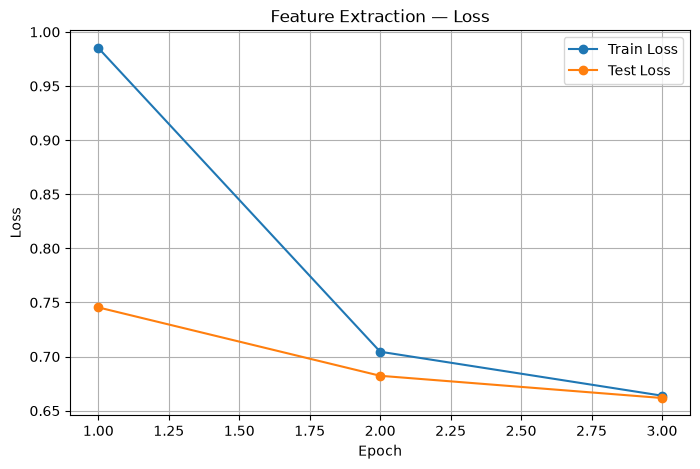

In [22]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    feature_train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    feature_test_losses,
    marker="o",
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Feature Extraction — Loss")
plt.legend()
plt.grid(True)

plt.show()

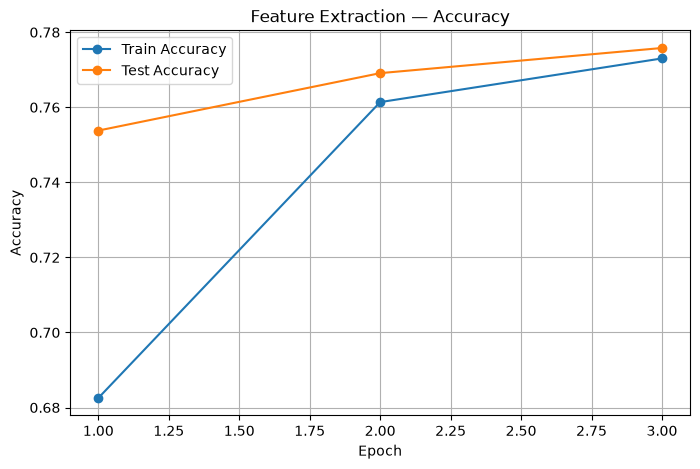

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    feature_train_accuracies,
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    feature_test_accuracies,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Feature Extraction — Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# 5.17 Stage 2 — Fine-Tuning

Feature extraction demonstrated that the pretrained representation can already solve part of the target problem.

Now we allow the deeper ResNet layers to adapt.

We will keep the early layers frozen and unfreeze:

$$
\text{layer4}
$$

and:

$$
\text{fc}
$$

The resulting structure is:

$$
\text{Frozen Early Layers}
\rightarrow
\text{Trainable Deep Features}
\rightarrow
\text{Trainable Target Head}
$$

Why only the deeper layers?

Early layers tend to learn relatively general visual patterns such as edges and textures.

Deeper layers are more task-specific.

Therefore, changing the deeper layers gives the model adaptation capacity while preserving much of the pretrained knowledge.

In [24]:
# Freeze everything first

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final residual block

for param in model.layer4.parameters():
    param.requires_grad = True

# Keep target classifier trainable

for param in model.fc.parameters():
    param.requires_grad = True

In [25]:
trainable_layers = [
    name
    for name, param in model.named_parameters()
    if param.requires_grad
]

print("Trainable parameters:")

for name in trainable_layers:
    print(name)

Trainable parameters:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


## Smaller Learning Rate

During feature extraction, the classification head was randomly initialized.

Therefore, a relatively larger learning rate can be useful.

During fine-tuning, however, the pretrained parameters already contain valuable knowledge.

We therefore use a smaller learning rate:

$$
\eta_{\text{fine-tune}}
<
\eta_{\text{feature extraction}}
$$

This reduces the risk of destroying useful pretrained representations.

In [26]:
fine_tune_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## 5.19 Fine-Tuning the Model

In [27]:
fine_tune_epochs = 3

fine_train_losses = []
fine_train_accuracies = []
fine_test_losses = []
fine_test_accuracies = []

for epoch in range(fine_tune_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        fine_tune_optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    fine_train_losses.append(train_loss)
    fine_train_accuracies.append(train_acc)

    fine_test_losses.append(test_loss)
    fine_test_accuracies.append(test_acc)

    print(
        f"Fine-Tune Epoch [{epoch+1}/{fine_tune_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.4f} "
        f"| Test Loss: {test_loss:.4f} "
        f"| Test Acc: {test_acc:.4f}"
    )

Fine-Tune Epoch [1/3] | Train Loss: 0.4100 | Train Acc: 0.8580 | Test Loss: 0.3364 | Test Acc: 0.8826
Fine-Tune Epoch [2/3] | Train Loss: 0.1244 | Train Acc: 0.9618 | Test Loss: 0.3337 | Test Acc: 0.8924
Fine-Tune Epoch [3/3] | Train Loss: 0.0343 | Train Acc: 0.9934 | Test Loss: 0.3298 | Test Acc: 0.8990


## 5.20 Compare Feature Extraction and Fine-Tuning

In [28]:
feature_final_accuracy = feature_test_accuracies[-1]
fine_tune_final_accuracy = fine_test_accuracies[-1]

print(
    f"Feature Extraction Test Accuracy: "
    f"{feature_final_accuracy:.4f}"
)

print(
    f"Fine-Tuning Test Accuracy: "
    f"{fine_tune_final_accuracy:.4f}"
)

print(
    f"Improvement: "
    f"{fine_tune_final_accuracy - feature_final_accuracy:.4f}"
)

Feature Extraction Test Accuracy: 0.7758
Fine-Tuning Test Accuracy: 0.8990
Improvement: 0.1232


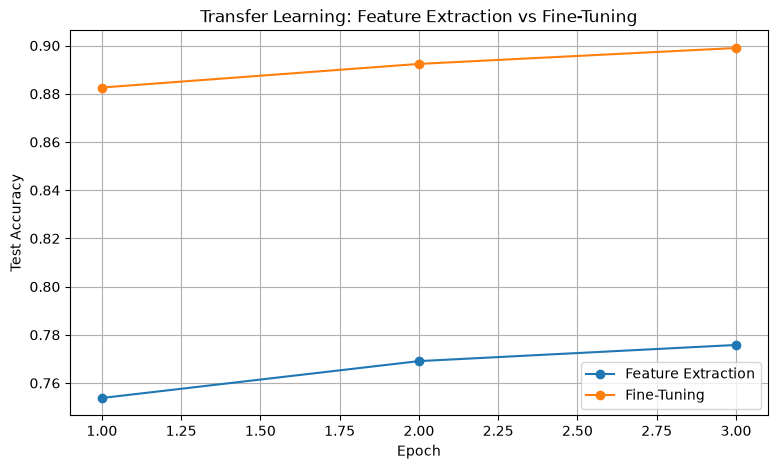

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, num_epochs + 1),
    feature_test_accuracies,
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    range(1, fine_tune_epochs + 1),
    fine_test_accuracies,
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Transfer Learning: Feature Extraction vs Fine-Tuning")
plt.legend()
plt.grid(True)

plt.show()

# 5.21 Transfer Learning — What We Demonstrated

We started with a model pretrained on ImageNet.

$$
\text{ImageNet}
\rightarrow
\text{ResNet-18}
$$

We then adapted it to CIFAR-10.

$$
\text{ResNet-18}
\rightarrow
\text{CIFAR-10}
$$

### Feature Extraction

We froze the pretrained representation:

$$
\theta=\text{fixed}
$$

and trained only:

$$
\phi_{\text{CIFAR-10}}
$$

### Fine-Tuning

We then allowed deeper layers to adapt:

$$
\theta_{\text{deep}}
\rightarrow
\text{updated}
$$

while keeping the early representation fixed.

---

## Main Lesson

Feature extraction answers:

> "How useful are the existing pretrained representations?"

Fine-tuning answers:

> "Can the pretrained representations be adapted to the target task?"

Therefore:

$$
\boxed{
\text{Feature Extraction}
\subset
\text{Transfer Learning}
}
$$

and:

$$
\boxed{
\text{Fine-Tuning}
=
\text{Transfer Learning with Parameter Adaptation}
}
$$

---

## Practical Decision Rule

### Small target dataset

Prefer:

$$
\text{Feature Extraction}
$$

or very limited fine-tuning.

### Medium target dataset

Use:

$$
\text{Feature Extraction}
\rightarrow
\text{Partial Fine-Tuning}
$$

### Large target dataset

More extensive fine-tuning may be appropriate.

---

## Important Warning

Transfer learning does not guarantee improvement.

Its effectiveness depends on:

- source dataset,
- target dataset,
- similarity between domains,
- amount of target data,
- architecture,
- preprocessing,
- learning rate,
- which layers are frozen,
- degree of fine-tuning.

The central principle is:

$$
\boxed{
\text{Reuse useful knowledge, then adapt only as much as necessary}
}
$$

# 5.22 Domain Adaptation

Domain Adaptation is a transfer-learning setting where a model trained on a **source domain** is adapted to perform well on a different but related **target domain**.

The central problem is **domain shift**.

Even when the task is the same, the source and target data distributions may be different.

For example:

$$
\text{Source Domain: Synthetic Images}
$$

$$
\text{Target Domain: Real Images}
$$

The task may remain:

$$
\text{Image Classification}
$$

but the input distributions can differ:

$$
P_S(X) \neq P_T(X)
$$

where:

- $P_S(X)$ = source-domain distribution
- $P_T(X)$ = target-domain distribution

---

## Why Domain Adaptation Is Necessary

Suppose a CNN is trained using clean studio photographs.

It may learn representations that work very well on those images.

Now suppose we use the same model on:

- photographs taken outdoors,
- images from a different camera,
- images with different lighting,
- lower-resolution images,
- images with different backgrounds.

The model may perform worse.

This happens because the target distribution differs from the distribution encountered during training.

Therefore:

$$
\boxed{
\text{Good source performance}
\not\Rightarrow
\text{Good target performance}
}
$$

---

## Domain Adaptation Goal

The goal is to learn a representation that is:

1. useful for the task,
2. less dependent on the particular domain.

Conceptually:

$$
X_S
\rightarrow
\text{Shared Representation}
\leftarrow
X_T
$$

while maintaining:

$$
\text{Representation}
\rightarrow
\text{Correct Task Prediction}
$$

---

## Source and Target Domains

We can define:

$$
D_S = \{(x_i^S,y_i^S)\}
$$

for the labeled source domain.

The target domain may contain:

$$
D_T = \{x_j^T\}
$$

without labels.

This leads to an important case:

$$
\boxed{
\text{Labeled Source Data + Unlabeled Target Data}
}
$$

This is commonly called **unsupervised domain adaptation**.

---

## Main Idea

Instead of learning features that are highly specific to the source domain, we try to learn features that are useful across both domains.

Therefore:

$$
\boxed{
\text{Domain Adaptation}
=
\text{Transfer Knowledge Across Different Data Distributions}
}
$$

# 5.23 Types of Domain Adaptation

Domain adaptation can be categorized according to the availability of target labels.

---

## 1. Supervised Domain Adaptation

The target domain contains labeled examples.

$$
D_T = \{(x_i^T,y_i^T)\}
$$

Both source and target labels can contribute to training.

---

## 2. Semi-Supervised Domain Adaptation

The target domain contains:

- a small amount of labeled data,
- a larger amount of unlabeled data.

For example:

$$
\text{Target Data}
=
\text{Few Labeled Examples}
+
\text{Many Unlabeled Examples}
$$

---

## 3. Unsupervised Domain Adaptation

The source domain is labeled:

$$
D_S=\{(x_i^S,y_i^S)\}
$$

but the target domain is unlabeled:

$$
D_T=\{x_j^T\}
$$

The model must learn to perform the target task without target labels.

This is one of the most important domain-adaptation settings.

---

## 4. Domain Generalization

Domain Generalization is related but different.

Instead of adapting to a known target domain during training, the goal is to learn representations that generalize to unseen domains.

The distinction is:

$$
\boxed{
\text{Domain Adaptation: Target domain is available}
}
$$

while:

$$
\boxed{
\text{Domain Generalization: Target domain is unseen during training}
}

# 5.24 Domain Shift

Domain shift occurs when the source and target distributions differ.

A simple representation is:

$$
P_S(X) \neq P_T(X)
$$

There are several important forms of distribution shift.

---

## Covariate Shift

The input distribution changes:

$$
P_S(X)\neq P_T(X)
$$

while the conditional relationship may remain approximately unchanged:

$$
P_S(Y|X)\approx P_T(Y|X)
$$

Example:

The same object classes are present, but the lighting and backgrounds change.

---

## Label Shift

The distribution of labels changes:

$$
P_S(Y)\neq P_T(Y)
$$

while:

$$
P_S(X|Y)\approx P_T(X|Y)
$$

Example:

The target environment contains many more examples of one class than the source environment.

---

## Concept Shift

The relationship between input and label changes:

$$
P_S(Y|X)\neq P_T(Y|X)
$$

This is more difficult because the meaning of the prediction relationship itself has changed.

---

## Summary

| Shift | What Changes? |
|---|---|
| Covariate shift | $P(X)$ |
| Label shift | $P(Y)$ |
| Concept shift | $P(Y|X)$ |

The most important practical lesson is:

$$
\boxed{
\text{Different source and target distributions can reduce transfer performance}
}
$$

# 5.25 Feature Alignment

One strategy for domain adaptation is to make source and target representations more similar.

Suppose the encoder is:

$$
z=f_\theta(x)
$$

For source data:

$$
z_S=f_\theta(x_S)
$$

For target data:

$$
z_T=f_\theta(x_T)
$$

We want:

$$
P(z_S)\approx P(z_T)
$$

while preserving task information.

This is called **feature alignment**.

---

## Conceptual Objective

The model can optimize two goals:

### Task objective

Use labeled source examples to perform the task:

$$
L_{\text{task}}
$$

### Domain alignment objective

Reduce the difference between source and target representations:

$$
L_{\text{domain}}
$$

The combined objective can be written as:

$$
L
=
L_{\text{task}}
+
\lambda L_{\text{domain}}
$$

where $\lambda$ controls the importance of domain alignment.

---

## Important Trade-Off

Domain alignment alone is not enough.

If the model makes source and target representations identical without preserving class information, useful task information can be lost.

Therefore, successful domain adaptation needs both:

$$
\boxed{
\text{Task Discrimination}
+
\text{Domain Invariance}
}
$$

# 5.26 Maximum Mean Discrepancy (MMD)

Maximum Mean Discrepancy (MMD) is one method for measuring the difference between two distributions.

In domain adaptation, we can use MMD to encourage source and target feature distributions to become similar.

Suppose:

$$
Z_S=\{z_1^S,\ldots,z_n^S\}
$$

and:

$$
Z_T=\{z_1^T,\ldots,z_m^T\}
$$

represent source and target embeddings.

MMD compares their distributions in a reproducing kernel Hilbert space.

A simplified form is:

$$
\operatorname{MMD}^2(P,Q)
=
\left\|
\mathbb{E}_{x\sim P}[\phi(x)]
-
\mathbb{E}_{y\sim Q}[\phi(y)]
\right\|^2
$$

where $\phi(\cdot)$ maps samples into a feature space.

The goal is:

$$
\boxed{
\operatorname{MMD}(Z_S,Z_T)\rightarrow0
}
$$

while maintaining good task performance.

---

## Why MMD Is Useful

It gives us a differentiable way to encourage:

$$
P(Z_S)\approx P(Z_T)
$$

during neural-network training.

Thus, the encoder can learn more domain-invariant representations.

## 5.27 Simple Feature Alignment Demonstration

We can demonstrate the basic idea without implementing a full domain-adaptation benchmark.

First, create two groups of feature vectors with different distributions.

In [31]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

source_features = torch.randn(500, 2)

target_features = (
    torch.randn(500, 2) * 1.5
    + torch.tensor([2.0, 1.0])
)

print("Source shape:", source_features.shape)
print("Target shape:", target_features.shape)

Source shape: torch.Size([500, 2])
Target shape: torch.Size([500, 2])


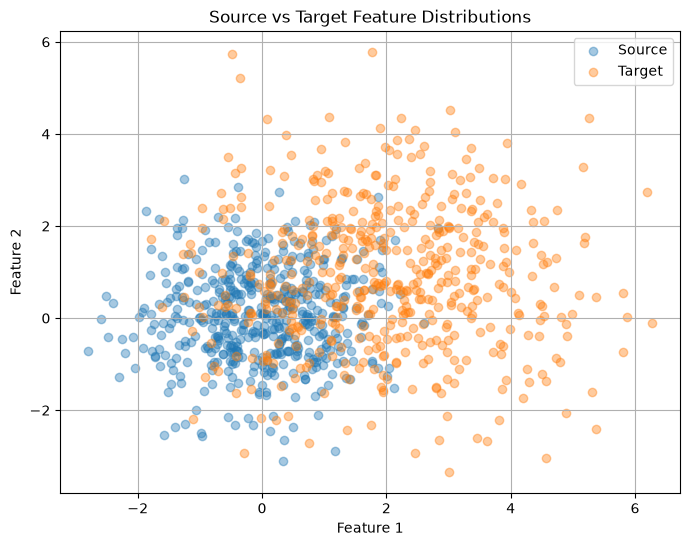

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    source_features[:, 0],
    source_features[:, 1],
    alpha=0.4,
    label="Source"
)

plt.scatter(
    target_features[:, 0],
    target_features[:, 1],
    alpha=0.4,
    label="Target"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Source vs Target Feature Distributions")
plt.legend()
plt.grid(True)

plt.show()

## 5.28 Simple MMD Implementation

In [33]:
def gaussian_kernel(x, y, sigma=1.0):
    distances = torch.cdist(x, y).pow(2)
    return torch.exp(
        -distances / (2 * sigma ** 2)
    )


def mmd_loss(source, target, sigma=1.0):
    k_ss = gaussian_kernel(source, source, sigma)
    k_tt = gaussian_kernel(target, target, sigma)
    k_st = gaussian_kernel(source, target, sigma)

    return (
        k_ss.mean()
        + k_tt.mean()
        - 2 * k_st.mean()
    )

In [34]:
initial_mmd = mmd_loss(
    source_features,
    target_features
)

print("Initial MMD:", initial_mmd.item())

Initial MMD: 0.23405346274375916


In [35]:
alignment_layer = nn.Linear(2, 2)

optimizer = torch.optim.Adam(
    alignment_layer.parameters(),
    lr=0.01
)

In [36]:
alignment_losses = []

for epoch in range(100):

    aligned_target = alignment_layer(
        target_features
    )

    loss = mmd_loss(
        source_features,
        aligned_target
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    alignment_losses.append(loss.item())

print("Final MMD:", alignment_losses[-1])

Final MMD: 0.026253044605255127


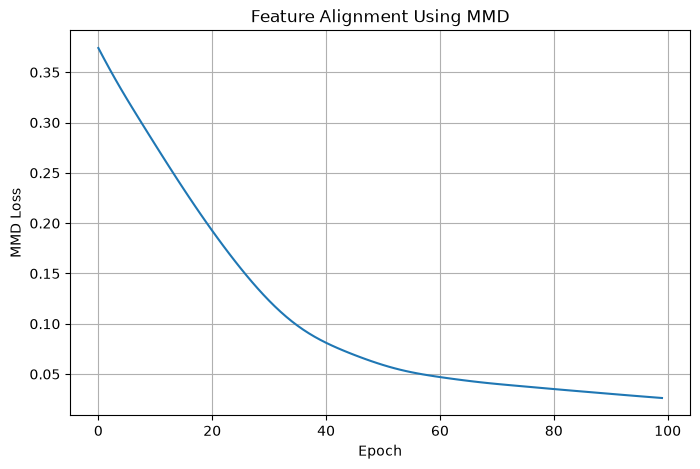

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(alignment_losses)

plt.xlabel("Epoch")
plt.ylabel("MMD Loss")
plt.title("Feature Alignment Using MMD")
plt.grid(True)

plt.show()

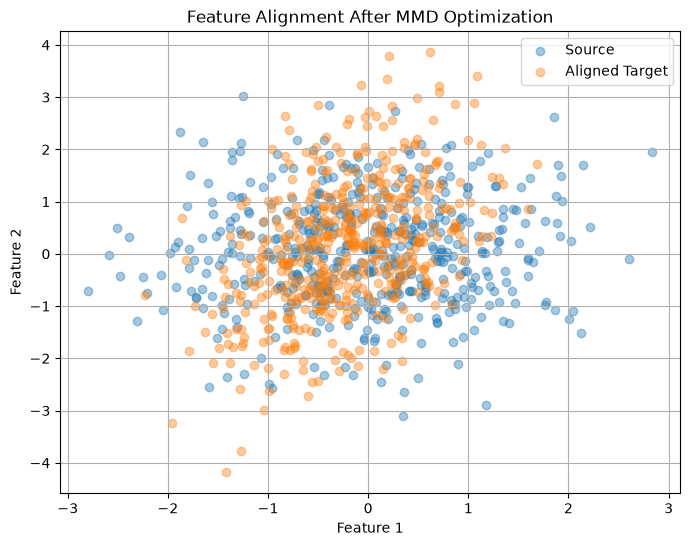

In [38]:
with torch.no_grad():
    aligned_target = alignment_layer(target_features)

plt.figure(figsize=(8, 6))

plt.scatter(
    source_features[:, 0],
    source_features[:, 1],
    alpha=0.4,
    label="Source"
)

plt.scatter(
    aligned_target[:, 0],
    aligned_target[:, 1],
    alpha=0.4,
    label="Aligned Target"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Feature Alignment After MMD Optimization")
plt.legend()
plt.grid(True)

plt.show()

# 5.29 Domain-Adversarial Learning

Another important approach is **Domain-Adversarial Neural Networks (DANN)**.

The key idea is to train an encoder whose representations are:

1. useful for the main task,
2. difficult to distinguish by domain.

The architecture contains three components:

$$
x
\rightarrow
\boxed{\text{Feature Extractor}}
\rightarrow
\begin{cases}
\text{Label Predictor}\\
\text{Domain Classifier}
\end{cases}
$$

The label predictor tries to predict the task label.

The domain classifier tries to determine whether a representation came from:

- source domain,
- target domain.

The feature extractor has an opposing objective.

It should produce representations that make domain classification difficult.

---

## Adversarial Objective

The feature extractor attempts to minimize task loss while maximizing domain-classification difficulty.

Conceptually:

$$
L
=
L_{\text{task}}
-
\lambda L_{\text{domain}}
$$

for the feature extractor.

The domain classifier itself minimizes:

$$
L_{\text{domain}}
$$

This adversarial process encourages domain-invariant features.

---

## Gradient Reversal Layer

DANN commonly implements this using a **Gradient Reversal Layer (GRL)**.

During the forward pass:

$$
GRL(x)=x
$$

During backpropagation:

$$
\frac{\partial GRL}{\partial x}
=
-\lambda I
$$

Therefore, the domain-classification gradient is reversed before reaching the feature extractor.

This allows the same optimization process to:

- improve task prediction,
- make representations less domain-specific.

## 5.30 Domain-Adversarial Architecture

In [39]:
class FeatureExtractor(nn.Module):
    def __init__(self, input_dim=2, feature_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, feature_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.network(x)


class LabelPredictor(nn.Module):
    def __init__(self, feature_dim=16, num_classes=2):
        super().__init__()

        self.network = nn.Linear(
            feature_dim,
            num_classes
        )

    def forward(self, x):
        return self.network(x)


class DomainClassifier(nn.Module):
    def __init__(self, feature_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(feature_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

## DANN Conceptual Flow

The complete model is:

$$
x
\rightarrow
f_\theta(x)
\rightarrow
z
$$

Then:

$$
z
\rightarrow
\text{Label Predictor}
\rightarrow
\hat{y}
$$

and:

$$
z
\rightarrow
\text{Domain Classifier}
\rightarrow
\hat{d}
$$

The feature extractor therefore learns:

$$
\boxed{
\text{Task-Relevant}
+
\text{Domain-Invariant}
}
$$

representations.

# 5.31 Domain Adaptation vs Transfer Learning

Domain adaptation is a specialized form of knowledge transfer.

General transfer learning asks:

> How can knowledge learned from one task/domain help another task?

Domain adaptation focuses specifically on:

> How can a model trained in one domain perform well when the target domain has a different distribution?

---

| Concept | Main Goal |
|---|---|
| Transfer Learning | Reuse learned knowledge |
| Fine-Tuning | Adapt pretrained parameters |
| Domain Adaptation | Handle source-target distribution differences |
| Feature Alignment | Make representations more similar |
| DANN | Learn domain-invariant features |
| Domain Generalization | Generalize to unseen domains |

---

## Important Relationship

A typical hierarchy is:

$$
\boxed{
\text{Knowledge Reuse}
\rightarrow
\text{Transfer Learning}
\rightarrow
\text{Domain Adaptation}
}
$$

However, not every transfer-learning problem is a domain-adaptation problem.

For example, simply replacing the classifier of a pretrained CNN for a related task is transfer learning, even if the source and target distributions are sufficiently similar.

---

## Final Takeaway

The central problem of domain adaptation is:

$$
P_S(X)\neq P_T(X)
$$

The goal is to learn:

$$
Z=f_\theta(X)
$$

such that:

$$
P(Z_S)\approx P(Z_T)
$$

while preserving task information.

Therefore:

$$
\boxed{
\text{Domain Adaptation}
=
\text{Transfer Knowledge Despite Domain Shift}
}
$$

# 5.32 Multi-Task Learning

Multi-Task Learning (MTL) is a Deep Learning paradigm where a single model learns multiple related tasks simultaneously.

Instead of training completely independent models:

$$
\text{Task 1} \rightarrow \text{Model 1}
$$

$$
\text{Task 2} \rightarrow \text{Model 2}
$$

$$
\text{Task 3} \rightarrow \text{Model 3}
$$

Multi-Task Learning uses a shared model:

$$
\boxed{
\text{Shared Representation}
\rightarrow
\begin{cases}
\text{Task 1 Head}\\
\text{Task 2 Head}\\
\text{Task 3 Head}
\end{cases}
}
$$

The central idea is:

$$
\boxed{
\text{Learn one representation that is useful for multiple tasks}
}
$$

---

## Example

Consider an autonomous driving system.

A single image may be used for:

- object classification,
- object detection,
- depth estimation,
- semantic segmentation.

Instead of learning completely independent feature extractors, the model can learn shared visual features.

For an input image $x$:

$$
z=f_\theta(x)
$$

where $f_\theta$ is the shared feature extractor.

Then different task-specific heads operate on $z$:

$$
\hat{y}_1=g_{\phi_1}(z)
$$

$$
\hat{y}_2=g_{\phi_2}(z)
$$

$$
\hat{y}_3=g_{\phi_3}(z)
$$

---

## Why Multi-Task Learning?

Related tasks often contain complementary information.

Learning them jointly can encourage the network to discover more useful representations.

For example:

$$
\text{Classification}
+
\text{Localization}
$$

may provide richer supervision than classification alone.

This is called **inductive transfer**.

Knowledge learned while solving one task can help another task through the shared representation.

# 5.33 Hard Parameter Sharing

The most common Multi-Task Learning architecture is **hard parameter sharing**.

A shared backbone is used by all tasks.

$$
x
\rightarrow
\boxed{f_\theta}
\rightarrow
z
$$

Then:

$$
z
\rightarrow
\begin{cases}
g_{\phi_1}(z) \rightarrow \hat{y}_1\\
g_{\phi_2}(z) \rightarrow \hat{y}_2\\
g_{\phi_3}(z) \rightarrow \hat{y}_3
\end{cases}
$$

The parameters $\theta$ are shared.

The task-specific parameters remain separate.

---

## Mathematical Objective

Suppose there are $K$ tasks.

Each task has a loss:

$$
L_1,L_2,\ldots,L_K
$$

The total objective can be written as:

$$
L_{\text{total}}
=
\sum_{k=1}^{K}
\lambda_k L_k
$$

where:

$$
\lambda_k\geq0
$$

controls the contribution of task $k$.

For two tasks:

$$
L_{\text{total}}
=
\lambda_1L_1+\lambda_2L_2
$$

---

## Important Idea

The shared backbone receives gradients from multiple tasks.

Therefore:

$$
\nabla_\theta L_{\text{total}}
=
\sum_{k=1}^{K}
\lambda_k\nabla_\theta L_k
$$

The backbone is therefore encouraged to learn features useful to several tasks simultaneously.

# 5.34 Soft Parameter Sharing

In **soft parameter sharing**, each task can have its own model or feature extractor.

The parameters are not directly shared.

Instead, the models are encouraged to remain similar.

For two task-specific parameter sets:

$$
\theta_1
$$

and:

$$
\theta_2
$$

we can add a regularization term:

$$
L_{\text{similarity}}
=
\|\theta_1-\theta_2\|^2
$$

The overall objective becomes:

$$
L
=
L_1+L_2
+
\lambda
\|\theta_1-\theta_2\|^2
$$

Thus, the models are encouraged to learn related representations while retaining task-specific flexibility.

---

## Hard vs Soft Sharing

| Property | Hard Sharing | Soft Sharing |
|---|---|---|
| Shared backbone | Yes | No |
| Task-specific backbone | Usually no | Yes |
| Parameter efficiency | High | Lower |
| Task flexibility | Lower | Higher |
| Implementation | Simpler | More complex |
| Regularization | Implicit | Explicit |

# 5.35 Multi-Task Learning Architecture

A standard hard-sharing architecture looks like:

$$
x
\downarrow
$$

$$
\boxed{\text{Shared Encoder}}
$$

$$
\downarrow
$$

$$
\boxed{z}
$$

Then the representation branches:

$$
z
\rightarrow
\boxed{\text{Classification Head}}
\rightarrow
\hat{y}_{class}
$$

and:

$$
z
\rightarrow
\boxed{\text{Regression Head}}
\rightarrow
\hat{y}_{reg}
$$

This is particularly useful when the tasks are related but require different output types.

For example:

- classification → Cross Entropy Loss
- regression → Mean Squared Error

The combined objective can therefore be:

$$
L_{\text{total}}
=
\lambda_cL_{\text{classification}}
+
\lambda_rL_{\text{regression}}
$$

## 5.36 PyTorch Multi-Task Model

Let’s build a simple multi-task neural network.

The model will receive two-dimensional inputs and perform:
```
binary classification
regression

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [41]:
class MultiTaskNetwork(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32):
        super().__init__()

        # Shared representation
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # Classification head
        self.classification_head = nn.Linear(
            hidden_dim,
            2
        )

        # Regression head
        self.regression_head = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):
        features = self.shared(x)

        class_output = self.classification_head(
            features
        )

        regression_output = self.regression_head(
            features
        )

        return class_output, regression_output

# 5.37 Create a Synthetic Multi-Task Dataset

We will create two related prediction problems from the same input.

For each sample:

$$
x=(x_1,x_2)
$$

we create:

### Classification target

The class depends on the sign of a function of the input.

### Regression target

The regression value is related to the same underlying structure.

This demonstrates why shared representations can be useful.

The model therefore receives one input but must learn two related outputs.

In [42]:
torch.manual_seed(42)

n_samples = 5000

X = torch.randn(n_samples, 2)

# Classification target
y_class = (
    (X[:, 0] + X[:, 1] > 0)
    .long()
)

# Regression target
y_reg = (
    X[:, 0] ** 2
    + 0.5 * X[:, 1]
).unsqueeze(1)

print("X:", X.shape)
print("Classification:", y_class.shape)
print("Regression:", y_reg.shape)

X: torch.Size([5000, 2])
Classification: torch.Size([5000])
Regression: torch.Size([5000, 1])


## 5.38 Train/Test Split

In [43]:
indices = torch.randperm(n_samples)

train_size = int(0.8 * n_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_class_train = y_class[train_indices]
y_class_test = y_class[test_indices]

y_reg_train = y_reg[train_indices]
y_reg_test = y_reg[test_indices]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 4000
Test samples: 1000


## 5.39 Initialize the Multi-Task Model

In [44]:
model = MultiTaskNetwork().to(device)

classification_loss = nn.CrossEntropyLoss()
regression_loss = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

# 5.40 Multi-Task Training Objective

Our model has two objectives.

Classification:

$$
L_{class}
$$

Regression:

$$
L_{reg}
$$

The total loss is:

$$
\boxed{
L_{total}
=
\lambda_{class}L_{class}
+
\lambda_{reg}L_{reg}
}
$$

Initially, we will use:

$$
\lambda_{class}=1
$$

and:

$$
\lambda_{reg}=1
$$

Therefore:

$$
L_{total}
=
L_{class}+L_{reg}
$$

In real applications, the loss weights often require careful tuning because different tasks can have very different loss scales.

## 5.41 Train the Multi-Task Network

In [45]:
X_train = X_train.to(device)
X_test = X_test.to(device)

y_class_train = y_class_train.to(device)
y_class_test = y_class_test.to(device)

y_reg_train = y_reg_train.to(device)
y_reg_test = y_reg_test.to(device)

lambda_class = 1.0
lambda_reg = 1.0

epochs = 100

total_losses = []
classification_losses = []
regression_losses = []

for epoch in range(epochs):

    model.train()

    class_output, reg_output = model(X_train)

    loss_class = classification_loss(
        class_output,
        y_class_train
    )

    loss_reg = regression_loss(
        reg_output,
        y_reg_train
    )

    total_loss = (
        lambda_class * loss_class
        + lambda_reg * loss_reg
    )

    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()

    total_losses.append(total_loss.item())
    classification_losses.append(loss_class.item())
    regression_losses.append(loss_reg.item())

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Total: {total_loss.item():.4f} "
            f"| Classification: {loss_class.item():.4f} "
            f"| Regression: {loss_reg.item():.4f}"
        )

Epoch [20/100] | Total: 3.1553 | Classification: 0.6946 | Regression: 2.4607
Epoch [40/100] | Total: 2.4902 | Classification: 0.6389 | Regression: 1.8513
Epoch [60/100] | Total: 2.0947 | Classification: 0.5467 | Regression: 1.5480
Epoch [80/100] | Total: 1.7659 | Classification: 0.4383 | Regression: 1.3276
Epoch [100/100] | Total: 1.4050 | Classification: 0.3409 | Regression: 1.0641


## 5.42 Visualize Multi-Task Training

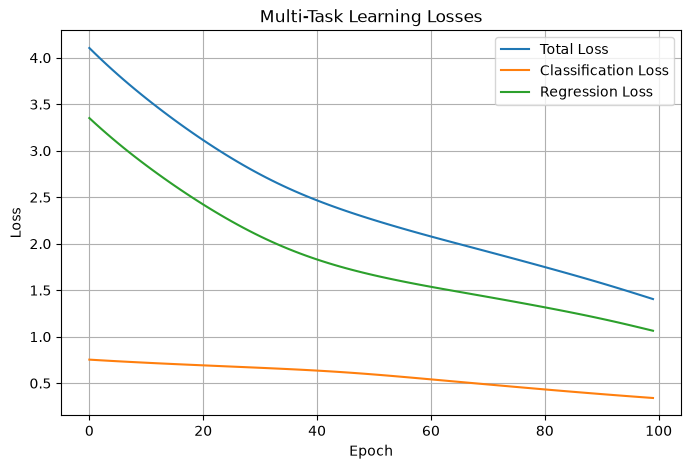

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    total_losses,
    label="Total Loss"
)

plt.plot(
    classification_losses,
    label="Classification Loss"
)

plt.plot(
    regression_losses,
    label="Regression Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-Task Learning Losses")
plt.legend()
plt.grid(True)

plt.show()

## 5.43 Evaluate Both Tasks

In [47]:
model.eval()

with torch.no_grad():

    class_output, reg_output = model(X_test)

    class_predictions = class_output.argmax(
        dim=1
    )

    classification_accuracy = (
        class_predictions == y_class_test
    ).float().mean().item()

    regression_mse = nn.functional.mse_loss(
        reg_output,
        y_reg_test
    ).item()

print(
    f"Classification Accuracy: "
    f"{classification_accuracy:.4f}"
)

print(
    f"Regression MSE: "
    f"{regression_mse:.4f}"
)

Classification Accuracy: 0.9790
Regression MSE: 1.0694


## 5.44 Visualize the Learned Shared Representation

The most important part of this experiment is not just the final predictions.

We want to inspect what the shared representation learned.

In [48]:
model.eval()

with torch.no_grad():
    shared_features = model.shared(X_test)

print("Shared representation shape:")
print(shared_features.shape)

Shared representation shape:
torch.Size([1000, 32])


Reduce the representation to two dimensions using PCA.

In [49]:
from sklearn.decomposition import PCA

features_cpu = shared_features.cpu().numpy()
labels_cpu = y_class_test.cpu().numpy()

pca = PCA(n_components=2)

features_2d = pca.fit_transform(
    features_cpu
)

print("Original representation:", features_cpu.shape)
print("PCA representation:", features_2d.shape)

Original representation: (1000, 32)
PCA representation: (1000, 2)


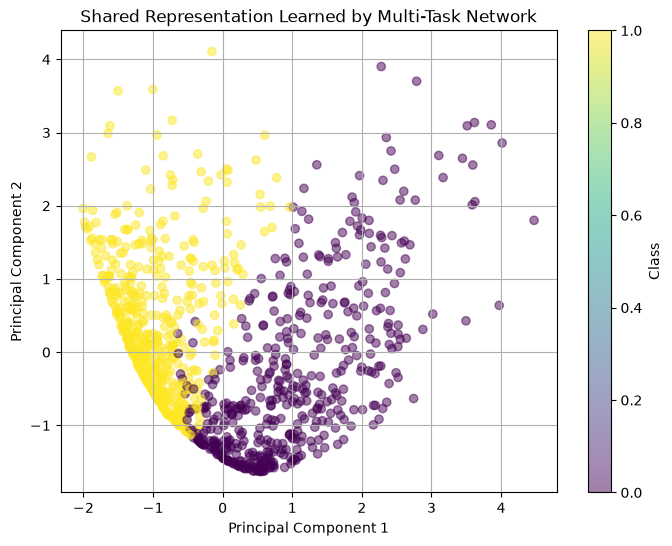

In [50]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_cpu,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "Shared Representation Learned by Multi-Task Network"
)

plt.colorbar(scatter, label="Class")

plt.grid(True)
plt.show()

# 5.45 Positive and Negative Transfer

Multi-Task Learning does not always improve performance.

There are two important possibilities.

---

## Positive Transfer

One task helps another task.

For example:

$$
\text{Task A}
\rightarrow
\text{Useful Shared Features}
\rightarrow
\text{Task B}
$$

This can improve generalization.

---

## Negative Transfer

One task hurts another task.

This can happen when tasks are:

- weakly related,
- conflicting,
- differently scaled,
- dependent on incompatible features.

Conceptually:

$$
\nabla_\theta L_A
$$

may point in a useful direction while:

$$
\nabla_\theta L_B
$$

pushes the shared representation in a conflicting direction.

Therefore:

$$
\nabla_\theta L_A
\cdot
\nabla_\theta L_B
<
0
$$

can indicate gradient conflict.

---

## Why This Matters

The assumption:

$$
\text{Multiple Tasks}
\Rightarrow
\text{Better Model}
$$

is incorrect.

The more accurate principle is:

$$
\boxed{
\text{Related Tasks}
\rightarrow
\text{Potential Positive Transfer}
}
$$

while:

$$
\boxed{
\text{Conflicting Tasks}
\rightarrow
\text{Potential Negative Transfer}
}
$$

# 5.46 Task Balancing

Different tasks can produce losses with very different magnitudes.

Suppose:

$$
L_1=0.2
$$

while:

$$
L_2=100
$$

Then simply using:

$$
L=L_1+L_2
$$

means Task 2 may dominate optimization.

Therefore, we introduce task weights:

$$
L=
\lambda_1L_1+\lambda_2L_2
$$

The weights determine how strongly each task influences the shared representation.

---

## Important Problem

Choosing:

$$
\lambda_1,\lambda_2,\ldots,\lambda_K
$$

manually can be difficult.

Modern Multi-Task Learning therefore includes methods for adaptive loss weighting.

Examples include:

- uncertainty-based weighting,
- GradNorm,
- dynamic task weighting,
- gradient-based task balancing.

These methods attempt to prevent one task from dominating the optimization process.

# 5.47 Transfer Learning vs Multi-Task Learning

Transfer Learning and Multi-Task Learning both reuse knowledge, but they do so differently.

---

## Transfer Learning

Typically:

$$
\text{Source Task}
\rightarrow
\text{Pretrained Model}
\rightarrow
\text{Target Task}
$$

Knowledge is learned first and transferred later.

---

## Multi-Task Learning

Tasks are learned jointly:

$$
\text{Task 1}
\leftrightarrow
\text{Shared Representation}
\leftrightarrow
\text{Task 2}
$$

Knowledge can flow between tasks during training.

---

| Property | Transfer Learning | Multi-Task Learning |
|---|---|---|
| Tasks | Usually sequential | Usually simultaneous |
| Main idea | Reuse pretrained knowledge | Jointly learn related tasks |
| Shared representation | Often reused | Learned jointly |
| Task heads | Target-specific | Multiple heads |
| Training | Source → target | Multiple tasks together |
| Main risk | Poor transfer | Negative transfer |

---

## Conceptual Difference

Transfer learning:

$$
\boxed{
\text{Learn → Transfer → Adapt}
}
$$

Multi-task learning:

$$
\boxed{
\text{Learn Together → Share Knowledge}
}
$$

# 5.48 Multi-Task Learning — Final Summary

Multi-Task Learning trains one model to solve multiple related tasks.

The standard architecture is:

$$
x
\rightarrow
\boxed{\text{Shared Encoder}}
\rightarrow
z
\rightarrow
\begin{cases}
\text{Task 1 Head}\\
\text{Task 2 Head}\\
\vdots\\
\text{Task K Head}
\end{cases}
$$

The total objective is:

$$
\boxed{
L_{total}
=
\sum_{k=1}^{K}
\lambda_kL_k
}
$$

---

## Core Concepts

### Hard Parameter Sharing

A common backbone is directly shared.

### Soft Parameter Sharing

Task-specific networks are encouraged to remain similar.

### Positive Transfer

One task improves another.

### Negative Transfer

One task hurts another.

### Task Balancing

Loss weights control the influence of individual tasks.

### Shared Representation

The central representation is learned from multiple sources of supervision.

---

## Most Important Concept

Multi-Task Learning is fundamentally a **representation-learning strategy**.

Instead of learning:

$$
z_1=f_1(x)
$$

for one task and:

$$
z_2=f_2(x)
$$

for another task, we attempt to learn:

$$
\boxed{
z=f_\theta(x)
}
$$

that contains information useful for several tasks.

---

## Connection to the Previous Topics

Representation Learning:

$$
x\rightarrow z
$$

Transfer Learning:

$$
\text{Pretrained }z
\rightarrow
\text{New Task}
$$

Domain Adaptation:

$$
\text{Source }z
\rightarrow
\text{Target Domain}
$$

Multi-Task Learning:

$$
z
\rightarrow
\begin{cases}
\text{Task 1}\\
\text{Task 2}\\
\text{Task 3}
\end{cases}
$$

Therefore, these topics form one coherent **Knowledge Reuse** section of Deep Learning.

# 5.49 Multi-Task Learning — Advanced Methods

The basic Multi-Task Learning architecture uses one shared representation and multiple task-specific heads.

However, different tasks do not always require exactly the same features.

Therefore, modern Multi-Task Learning architectures provide different mechanisms for controlling how much information is shared.

We will study:

1. Task-specific layers
2. Shared-private architectures
3. Cross-stitch networks
4. Gradient conflict
5. GradNorm
6. Uncertainty-based task weighting

The central problem is:

$$
\boxed{
\text{What should be shared and what should remain task-specific?}
}
$$

## 5.49.1 Task-Specific Layers

A completely shared network assumes that all tasks benefit from the same representation.

This assumption may be too restrictive.

Instead, we can use:

$$
x
\rightarrow
\text{Shared Layers}
\rightarrow
\begin{cases}
\text{Task 1 Layers}\\
\text{Task 2 Layers}
\end{cases}
$$

The shared layers learn common information.

The task-specific layers learn information unique to each task.

For example:

$$
\text{Image}
\rightarrow
\text{Shared CNN}
\rightarrow
\begin{cases}
\text{Classification Layers}\\
\text{Depth Estimation Layers}
\end{cases}
$$

This gives the network both:

- knowledge sharing,
- task specialization.

This is often a better compromise than either completely independent networks or completely shared networks.

# 5.49.2 Shared-Private Architecture

A shared-private architecture gives each task two types of features:

$$
\text{Shared Features}
$$

and:

$$
\text{Private Features}
$$

For task $k$:

$$
z_k^{shared}=f_{shared}(x)
$$

and:

$$
z_k^{private}=f_k(x)
$$

These representations can then be combined:

$$
z_k=
[z_k^{shared};z_k^{private}]
$$

where $[\,;\,]$ denotes concatenation.

The task-specific prediction becomes:

$$
\hat{y}_k=g_k(z_k)
$$

---

## Why Use Private Features?

Suppose two tasks are related but not identical.

The shared network captures:

$$
\text{Common Information}
$$

while the private network captures:

$$
\text{Task-Specific Information}
$$

Therefore:

$$
\boxed{
\text{Shared + Private}
=
\text{General Knowledge + Specialization}
}
$$

In [51]:
class SharedPrivateMTL(nn.Module):
    def __init__(
        self,
        input_dim=10,
        shared_dim=32,
        private_dim=16,
        num_classes=3
    ):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, shared_dim),
            nn.ReLU(),
            nn.Linear(shared_dim, shared_dim),
            nn.ReLU()
        )

        self.private_task1 = nn.Sequential(
            nn.Linear(input_dim, private_dim),
            nn.ReLU()
        )

        self.private_task2 = nn.Sequential(
            nn.Linear(input_dim, private_dim),
            nn.ReLU()
        )

        self.head1 = nn.Linear(
            shared_dim + private_dim,
            num_classes
        )

        self.head2 = nn.Linear(
            shared_dim + private_dim,
            1
        )

    def forward(self, x):

        shared_features = self.shared(x)

        private1 = self.private_task1(x)
        private2 = self.private_task2(x)

        task1_features = torch.cat(
            [shared_features, private1],
            dim=1
        )

        task2_features = torch.cat(
            [shared_features, private2],
            dim=1
        )

        output1 = self.head1(task1_features)
        output2 = self.head2(task2_features)

        return output1, output2

# 5.49.3 Cross-Stitch Networks

Cross-stitch networks provide a more flexible form of information sharing.

Instead of deciding that layers are either:


100% Shared


or:


100% Separate


cross-stitch units learn how much information from one task should be transferred to another.

Suppose two task representations are:

$$
x_1
$$

and:

$$
x_2
$$

A cross-stitch unit produces:

$$
\tilde{x}_1
=
\alpha_{11}x_1+\alpha_{12}x_2
$$

and:

$$
\tilde{x}_2
=
\alpha_{21}x_1+\alpha_{22}x_2
$$

The coefficients are learned during training.

Therefore:

$$
\boxed{
\text{Information Sharing is Learned}
}
$$

rather than manually fixed.

This allows the network to discover which tasks should share information and how strongly.

# 5.49.4 Gradient Conflict

One of the major challenges in Multi-Task Learning is **gradient conflict**.

Each task produces a gradient for the shared parameters.

For two tasks:

$$
g_1=\nabla_\theta L_1
$$

and:

$$
g_2=\nabla_\theta L_2
$$

If the gradients point in similar directions, learning can be cooperative.

If they point in opposing directions, the tasks may interfere.

A useful measure is their dot product:

$$
g_1^\top g_2
$$

If:

$$
g_1^\top g_2>0
$$

the gradients are generally aligned.

If:

$$
g_1^\top g_2<0
$$

the gradients conflict.

---

## Why Gradient Conflict Is a Problem

The shared model must satisfy multiple objectives.

If:

$$
g_1
$$

wants the parameters to move in one direction while:

$$
g_2
$$

wants them to move in another direction, the combined update can be inefficient.

The naive update is:

$$
g_{total}
=
g_1+g_2
$$

This may not be optimal for either task.

Therefore, advanced MTL methods attempt to manage conflicting gradients.

# 5.49.5 Gradient-Based Task Balancing

Task weighting is not only about the numerical loss values.

What matters is also how strongly each task affects the shared parameters.

For task $k$:

$$
g_k
=
\nabla_\theta
(\lambda_kL_k)
$$

Changing $\lambda_k$ changes the magnitude of the task's gradient.

Therefore, adaptive methods can modify:

$$
\lambda_1,\lambda_2,\ldots,\lambda_K
$$

during training.

The objective is to prevent one task from dominating the shared representation.

---

## Desired Behavior

We want:

$$
\text{Task 1 contribution}
\approx
\text{Task 2 contribution}
$$

when appropriate.

However, this does not necessarily mean that all task losses should have identical numerical values.

The important quantity is the effect of each task on optimization.

# 5.49.6 GradNorm

GradNorm is a method for dynamically balancing task losses according to their gradient magnitudes and training rates.

Suppose task $i$ has weighted loss:

$$
L_i^{weighted}=w_iL_i
$$

The gradient magnitude for the shared parameters is:

$$
G_i
=
\left\|
\nabla_\theta
(w_iL_i)
\right\|
$$

GradNorm attempts to keep task training contributions balanced.

It compares the current training rate of each task with a desired training rate.

Conceptually:

$$
\boxed{
\text{Slow task}
\rightarrow
\text{larger relative influence}
}
$$

and:

$$
\boxed{
\text{Fast task}
\rightarrow
\text{smaller relative influence}
}
$$

The task weights are therefore learned rather than manually fixed.

This is useful when different tasks have very different loss scales or learning speeds.

# 5.49.7 Uncertainty-Based Task Weighting

Another approach is to use task uncertainty to determine task weights.

Suppose task $i$ has uncertainty parameter:

$$
\sigma_i
$$

A commonly used objective has the form:

$$
L
=
\sum_i
\left(
\frac{1}{2\sigma_i^2}L_i
+
\log\sigma_i
\right)
$$

The model learns the uncertainty parameters jointly with the neural-network parameters.

The effective task weight is related to:

$$
\frac{1}{\sigma_i^2}
$$

Therefore:

- high uncertainty → lower effective weight,
- low uncertainty → higher effective weight.

This provides a principled way to balance heterogeneous tasks.

---

## Main Idea

Instead of manually choosing:

$$
\lambda_1,\lambda_2,\ldots
$$

the model learns appropriate task weights from the data.

# 5.49.8 Advanced Multi-Task Architectures — Comparison

| Architecture | Sharing Strategy | Main Idea |
|---|---|---|
| Hard Sharing | Shared backbone | All tasks use common features |
| Task-Specific Layers | Shared + separate layers | Specialization after shared features |
| Shared-Private | Shared + private encoders | Explicit common and task-specific features |
| Cross-Stitch | Learned sharing | Learn how much information to exchange |
| Gradient Balancing | Shared parameters | Balance task optimization |
| GradNorm | Adaptive weighting | Balance gradient magnitudes/training rates |
| Uncertainty Weighting | Adaptive weighting | Learn weights from task uncertainty |

---

## Conceptual Evolution

The approaches become increasingly flexible:

$$
\text{Hard Sharing}
$$

$$
\downarrow
$$

$$
\text{Shared + Task-Specific}
$$

$$
\downarrow
$$

$$
\text{Shared + Private}
$$

$$
\downarrow
$$

$$
\text{Learned Information Sharing}
$$

$$
\downarrow
$$

$$
\text{Adaptive Gradient/Task Balancing}
$$

The fundamental research question remains:

$$
\boxed{
\text{How should knowledge be shared between tasks?}
}
$$

# 5.49.9 Multi-Task Learning — Practical Guidance

When designing a Multi-Task Learning system, consider the following.

---

## Step 1 — Check Task Relatedness

Ask:

> Do the tasks require related information?

If yes, shared representations may be beneficial.

---

## Step 2 — Start Simple

Begin with:

$$
\text{Shared Backbone}
+
\text{Task-Specific Heads}
$$

This provides a strong baseline.

---

## Step 3 — Check for Negative Transfer

Compare each task against a single-task baseline.

If joint training reduces performance, investigate task interference.

---

## Step 4 — Examine Gradient Conflict

Check whether task gradients are strongly opposed.

If conflict exists, consider:

- task weighting,
- gradient balancing,
- shared-private architectures,
- learned sharing.

---

## Step 5 — Tune Task Weights

Use:

$$
L=\sum_i\lambda_iL_i
$$

or an adaptive weighting method.

---

## Step 6 — Evaluate Every Task Separately

Do not evaluate only the combined loss.

Report task-specific metrics.

For example:

$$
\text{Classification Accuracy}
$$

$$
\text{Regression MSE}
$$

$$
\text{Segmentation IoU}
$$

A good MTL system should provide useful performance across its tasks.

# 5.49.10 Multi-Task Learning — Advanced Summary

Multi-Task Learning attempts to exploit relationships between multiple learning problems.

The basic architecture is:

$$
x
\rightarrow
\text{Shared Representation}
\rightarrow
\text{Multiple Task Heads}
$$

But advanced architectures recognize that tasks may not benefit from identical representations.

---

## Important Concepts

### Task-Specific Layers

Allow deeper features to specialize.

### Shared-Private Networks

Separate common and task-specific representations.

### Cross-Stitch Networks

Learn how much information should flow between task-specific representations.

### Gradient Conflict

Different tasks can produce opposing optimization directions.

$$
g_i^\top g_j<0
$$

indicates gradient conflict.

### GradNorm

Dynamically balances task contributions using gradient magnitudes and training rates.

### Uncertainty Weighting

Learns task weights using estimated task uncertainty.

---

## Core Principle

The central problem of advanced Multi-Task Learning is:

$$
\boxed{
\text{Share enough knowledge to benefit tasks}
}
$$

without:

$$
\boxed{
\text{sharing so much that tasks interfere}
}
$$

This is the fundamental balance between:

$$
\text{Knowledge Sharing}
\leftrightarrow
\text{Task Specialization}
$$

# 5.50 Knowledge Reuse — Comparison

Knowledge Reuse is a central idea in modern Deep Learning.

Instead of learning every new problem completely from scratch, we can reuse knowledge learned from other tasks or domains.

The three major paradigms studied in this section are:

1. Transfer Learning
2. Domain Adaptation
3. Multi-Task Learning

Although they are closely related, they solve different problems.

---

## 1. Transfer Learning

Transfer Learning reuses knowledge learned from a source task or dataset for a target task.

$$
\text{Source Task}
\rightarrow
\text{Pretrained Model}
\rightarrow
\text{Target Task}
$$

A common example is:

$$
\text{ImageNet}
\rightarrow
\text{Pretrained ResNet}
\rightarrow
\text{CIFAR-10}
$$

The transferred model can be used through:

- feature extraction,
- fine-tuning.

---

## 2. Domain Adaptation

Domain Adaptation focuses on distribution differences between source and target domains.

$$
P_S(X)\neq P_T(X)
$$

The task may remain the same, but the input distribution changes.

The objective is to learn representations that remain useful despite the domain shift.

Examples include:

- synthetic images → real images,
- studio images → outdoor images,
- one camera → another camera,
- one environment → another environment.

---

## 3. Multi-Task Learning

Multi-Task Learning trains multiple related tasks jointly.

$$
x
\rightarrow
\text{Shared Representation}
\rightarrow
\begin{cases}
\text{Task 1}\\
\text{Task 2}\\
\text{Task 3}
\end{cases}
$$

The tasks share information during training.

Examples:

- classification + localization,
- depth estimation + segmentation,
- sentiment + topic classification.

---

## Central Difference

Transfer Learning:

$$
\boxed{
\text{Reuse knowledge across tasks}
}
$$

Domain Adaptation:

$$
\boxed{
\text{Reuse knowledge despite domain shift}
}
$$

Multi-Task Learning:

$$
\boxed{
\text{Learn multiple tasks jointly}
}
$$

## 5.50.1 Side-by-Side Comparison

| Property | Transfer Learning | Domain Adaptation | Multi-Task Learning |
|---|---|---|---|
| Main goal | Reuse learned knowledge | Handle domain shift | Learn related tasks jointly |
| Source knowledge | Pretrained model/task | Source domain | Other tasks |
| Target domain | Usually new task/domain | Different target domain | Multiple tasks |
| Training relationship | Often sequential | Source → target adaptation | Joint |
| Target labels | May be available | Can be unavailable | Usually task labels available |
| Shared representation | Reused | Adapted | Learned jointly |
| Main challenge | Choosing useful pretrained knowledge | Distribution mismatch | Task interference |
| Typical solution | Fine-tuning | Feature alignment/DANN | Shared backbone |
| Major risk | Poor transfer | Negative domain adaptation | Negative transfer |

---

## Training Patterns

### Transfer Learning

$$
\boxed{
\text{Pretrain}
\rightarrow
\text{Transfer}
\rightarrow
\text{Fine-Tune}
}
$$

### Domain Adaptation

$$
\boxed{
\text{Source Learning}
+
\text{Target Distribution}
\rightarrow
\text{Domain-Invariant Features}
}
$$

### Multi-Task Learning

$$
\boxed{
\text{Multiple Tasks}
\rightarrow
\text{Joint Representation Learning}
}
$$

# 5.50.2 When Should You Use Each?

Choosing the correct paradigm depends on the problem.

---

## Use Transfer Learning When

You have:

- a pretrained model,
- a new but related target task,
- limited or moderate target data.

Example:

$$
\text{ImageNet CNN}
\rightarrow
\text{Medical Image Classification}
$$

The pretrained visual features can provide a strong starting point.

---

## Use Domain Adaptation When

The task is similar but:

$$
P_S(X)\neq P_T(X)
$$

Example:

$$
\text{Synthetic Driving Images}
\rightarrow
\text{Real Driving Images}
$$

The primary problem is not simply learning a new task.

The primary problem is adapting to the new domain.

---

## Use Multi-Task Learning When

You have multiple related tasks that can benefit from shared information.

Example:

$$
\text{Image}
\rightarrow
\begin{cases}
\text{Object Classification}\\
\text{Object Localization}\\
\text{Depth Estimation}
\end{cases}
$$

Joint learning may produce richer representations.

---

## Decision Rule

Ask three questions:

### Question 1

"Do I already have a useful pretrained model?"

If yes:

$$
\rightarrow
\text{Transfer Learning}
$$

### Question 2

"Is my main problem that source and target data distributions differ?"

If yes:

$$
\rightarrow
\text{Domain Adaptation}
$$

### Question 3

"Do I need to solve several related tasks simultaneously?"

If yes:

$$
\rightarrow
\text{Multi-Task Learning}
$$

## 5.50.3 Knowledge Reuse — Conceptual Map

The three paradigms can be visualized conceptually.

$$
\boxed{\text{Knowledge Reuse}}
$$

$$
\downarrow
$$

$$
\begin{cases}
\text{Transfer Learning}\\
\text{Domain Adaptation}\\
\text{Multi-Task Learning}
\end{cases}
$$

---

### Transfer Learning

Knowledge flows from:

$$
\text{Source}
\rightarrow
\text{Target}
$$

---

### Domain Adaptation

Knowledge flows across:

$$
\text{Source Domain}
\rightarrow
\text{Target Domain}
$$

while attempting to reduce:

$$
P_S(X)-P_T(X)
$$

---

### Multi-Task Learning

Knowledge flows between tasks through:

$$
\text{Shared Representation}
$$

---

## Unified View

All three can be understood through representation learning.

Let:

$$
z=f_\theta(x)
$$

Then:

### Transfer Learning

Reuse a learned:

$$
f_\theta
$$

for another task.

### Domain Adaptation

Modify:

$$
f_\theta
$$

so that:

$$
P(z_S)\approx P(z_T)
$$

while preserving task information.

### Multi-Task Learning

Learn:

$$
f_\theta
$$

using supervision from multiple tasks.

Therefore:

$$
\boxed{
\text{Representation Learning is the common foundation}
}
$$

# 5.50.4 Important Conceptual Distinctions

These distinctions are important when designing or explaining Deep Learning systems.

---

## Transfer Learning ≠ Fine-Tuning

Fine-tuning is one strategy for performing transfer learning.

Therefore:

$$
\boxed{
\text{Fine-Tuning} \subset \text{Transfer Learning}
}
$$

Transfer learning can also be performed through feature extraction.

---

## Transfer Learning ≠ Domain Adaptation

Domain adaptation is concerned specifically with source-target domain differences.

A transfer-learning problem does not necessarily require significant domain adaptation.

---

## Multi-Task Learning ≠ Transfer Learning

In transfer learning:

$$
\text{Source}
\rightarrow
\text{Target}
$$

In multi-task learning:

$$
\text{Task 1}
\leftrightarrow
\text{Shared Representation}
\leftrightarrow
\text{Task 2}
$$

Knowledge is exchanged during joint training.

---

## Domain Adaptation ≠ Domain Generalization

Domain Adaptation has access to target-domain data during adaptation.

Domain Generalization attempts to perform well on an unseen target domain.

Therefore:

$$
\boxed{
\text{Adaptation: Target Domain Available}
}
$$

$$
\boxed{
\text{Generalization: Target Domain Unseen}
}
$$

## 5.50.5 Final Comparison

| Question | Transfer Learning | Domain Adaptation | Multi-Task Learning |
|---|---|---|---|
| What is being reused? | Learned model knowledge | Source-domain knowledge | Knowledge between tasks |
| Why reuse it? | Improve target task | Handle domain shift | Improve multiple tasks |
| Main structure | Source → Target | Source domain → Target domain | Shared backbone → Multiple heads |
| Main representation strategy | Reuse/fine-tune | Align/invariant features | Shared features |
| Typical data | Large source + smaller target | Labeled source + target data | Multiple labeled task datasets |
| Main issue | Transfer quality | Domain shift | Task conflict |
| Key technique | Fine-tuning | MMD, DANN | Hard/soft sharing |
| Main objective | Better target performance | Domain-invariant representation | Joint task performance |

---

## One-Line Definitions

### Transfer Learning

$$
\boxed{
\text{Reuse knowledge learned from one problem for another problem}
}
$$

### Domain Adaptation

$$
\boxed{
\text{Adapt knowledge to a different data distribution}
}
$$

### Multi-Task Learning

$$
\boxed{
\text{Learn several related tasks using shared knowledge}
}
$$

# 5.50.6 Knowledge Reuse — Final Understanding

Knowledge Reuse addresses a fundamental limitation of training every Deep Learning model independently.

Instead of:

$$
\text{New Problem}
\rightarrow
\text{Random Initialization}
\rightarrow
\text{Learn Everything Again}
$$

we can use previously acquired knowledge.

---

## Transfer Learning

$$
\text{Existing Knowledge}
\rightarrow
\text{New Task}
$$

---

## Domain Adaptation

$$
\text{Existing Knowledge}
\rightarrow
\text{Different Domain}
$$

---

## Multi-Task Learning

$$
\text{Multiple Tasks}
\rightarrow
\text{Shared Knowledge}
$$

---

## Unified Principle

All three paradigms exploit the fact that useful structure learned from one source can help another learning objective.

Therefore:

$$
\boxed{
\text{Knowledge Reuse}
=
\text{Learn Once, Reuse and Adapt Where Useful}
}
$$

The quality of this reuse depends on:

- relatedness,
- representation quality,
- domain similarity,
- task compatibility,
- amount of target data,
- optimization strategy.

---

## Final Mental Model

Remember:

$$
\boxed{
\begin{aligned}
\text{Transfer Learning}
&\rightarrow \text{Reuse across tasks}\\
\text{Domain Adaptation}
&\rightarrow \text{Reuse across domains}\\
\text{Multi-Task Learning}
&\rightarrow \text{Reuse across simultaneous tasks}
\end{aligned}
}
$$

# 5.51 Practical Knowledge Reuse Project

This project combines the major Knowledge Reuse paradigms studied in this notebook.

We will build a practical Deep Learning workflow using a pretrained neural network and demonstrate how learned representations can be reused.

The project will focus on:

1. Pretrained representation
2. Feature extraction
3. Fine-tuning
4. Evaluation
5. Representation visualization
6. Comparison of training strategies

---

## Complete Knowledge Reuse Pipeline

$$
\text{Pretrained Model}
\rightarrow
\text{Feature Extraction}
\rightarrow
\text{Target Task}
$$

and then:

$$
\text{Pretrained Model}
\rightarrow
\text{Fine-Tuning}
\rightarrow
\text{Adapted Target Model}
$$

We will compare the two approaches.

---

## Learning Objective

The purpose of this project is not merely to obtain an accuracy score.

We want to understand:

$$
\boxed{
\text{How previously learned representations can be reused and adapted}
}
$$

This connects:

- Representation Learning
- Transfer Learning
- Domain Adaptation
- Multi-Task Learning

## 5.51.1 Load the Target Dataset

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [53]:
weights = models.ResNet18_Weights.DEFAULT
transform = weights.transforms()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

classes = train_dataset.classes

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", classes)

Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5.51.2 Build the Pretrained Model

In [54]:
model = models.resnet18(
    weights=weights
)

model.fc = nn.Linear(
    model.fc.in_features,
    len(classes)
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


## Feature Extraction

First, we will use the pretrained network as a fixed feature extractor.

All pretrained parameters are frozen.

Only the new target classifier is trained.

$$
\theta_{\text{backbone}}=\text{fixed}
$$

$$
\phi_{\text{target head}}
=
\text{trainable}
$$

This tests how useful the pretrained representation is without modifying it.

In [55]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [56]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3
)

## 5.51.4 Training and Evaluation Functions

In [57]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        total_loss / total,
        correct / total
    )

In [58]:
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        total_loss / total,
        correct / total
    )

## 5.51.5 Train the Feature Extractor

In [59]:
feature_history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

epochs = 3

for epoch in range(epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader,
        criterion
    )

    feature_history["train_loss"].append(
        train_loss
    )

    feature_history["train_accuracy"].append(
        train_acc
    )

    feature_history["test_loss"].append(
        test_loss
    )

    feature_history["test_accuracy"].append(
        test_acc
    )

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| Train Acc: {train_acc:.4f} "
        f"| Test Acc: {test_acc:.4f}"
    )

Epoch [1/3] | Train Acc: 0.6895 | Test Acc: 0.7564
Epoch [2/3] | Train Acc: 0.7610 | Test Acc: 0.7691
Epoch [3/3] | Train Acc: 0.7726 | Test Acc: 0.7729


 ## Fine-Tuning

Now we adapt the pretrained representation.

The early layers remain frozen.

The final ResNet block and target classifier are trainable.

$$
\text{Frozen Early Layers}
\rightarrow
\text{Trainable Deep Features}
\rightarrow
\text{Target Head}
$$

The purpose is to allow high-level representations to adapt to CIFAR-10 while preserving useful low-level features.

In [60]:
# Freeze the complete model

for param in model.parameters():
    param.requires_grad = False

# Fine-tune the final residual block

for param in model.layer4.parameters():
    param.requires_grad = True

# Train target classifier

for param in model.fc.parameters():
    param.requires_grad = True

In [61]:
fine_tune_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [62]:
fine_history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": []
}

fine_epochs = 3

for epoch in range(fine_epochs):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        fine_tune_optimizer
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader,
        criterion
    )

    fine_history["train_loss"].append(
        train_loss
    )

    fine_history["train_accuracy"].append(
        train_acc
    )

    fine_history["test_loss"].append(
        test_loss
    )

    fine_history["test_accuracy"].append(
        test_acc
    )

    print(
        f"Fine-Tune Epoch [{epoch+1}/{fine_epochs}] "
        f"| Train Acc: {train_acc:.4f} "
        f"| Test Acc: {test_acc:.4f}"
    )

Fine-Tune Epoch [1/3] | Train Acc: 0.8578 | Test Acc: 0.8858
Fine-Tune Epoch [2/3] | Train Acc: 0.9626 | Test Acc: 0.8934
Fine-Tune Epoch [3/3] | Train Acc: 0.9931 | Test Acc: 0.9000


## 5.51.7 Compare the Two Strategies

In [63]:
feature_accuracy = feature_history[
    "test_accuracy"
][-1]

fine_accuracy = fine_history[
    "test_accuracy"
][-1]

print(
    f"Feature Extraction: "
    f"{feature_accuracy:.4f}"
)

print(
    f"Fine-Tuning: "
    f"{fine_accuracy:.4f}"
)

print(
    f"Difference: "
    f"{fine_accuracy - feature_accuracy:.4f}"
)

Feature Extraction: 0.7729
Fine-Tuning: 0.9000
Difference: 0.1271


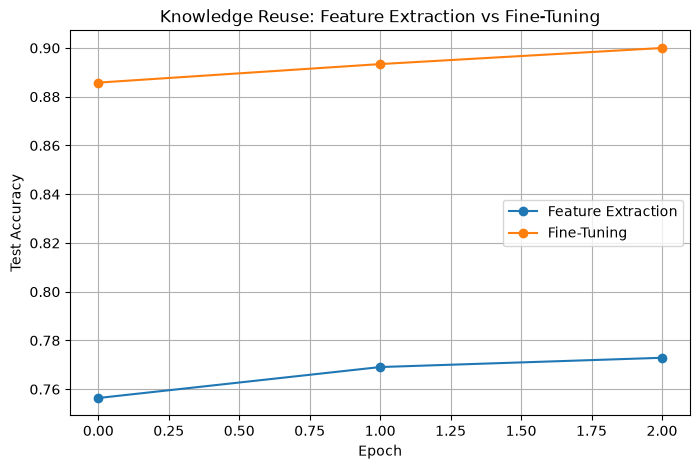

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(
    feature_history["test_accuracy"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    fine_history["test_accuracy"],
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title(
    "Knowledge Reuse: Feature Extraction vs Fine-Tuning"
)

plt.legend()
plt.grid(True)

plt.show()

## Inspecting the Transferred Representation

Transfer learning is fundamentally about reusing representations.

Therefore, we should inspect the representation produced by the pretrained backbone.

For an image:

$$
x
\rightarrow
f_\theta(x)
\rightarrow
z
$$

where:

$$
z
$$

is the transferred feature representation.

For ResNet-18, the representation before the final classifier has 512 dimensions.

In [65]:
feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor = feature_extractor.to(device)

feature_extractor.eval()

embeddings = []
embedding_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        features = feature_extractor(images)

        features = features.flatten(
            start_dim=1
        )

        embeddings.append(
            features.cpu()
        )

        embedding_labels.append(
            labels
        )

embeddings = torch.cat(
    embeddings
)

embedding_labels = torch.cat(
    embedding_labels
)

print("Embedding shape:", embeddings.shape)
print("Labels shape:", embedding_labels.shape)

Embedding shape: torch.Size([10000, 512])
Labels shape: torch.Size([10000])


## 5.51.9 PCA Visualization

In [66]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_2d = pca.fit_transform(
    embeddings.numpy()
)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

Explained variance: [0.1131735  0.06738982]


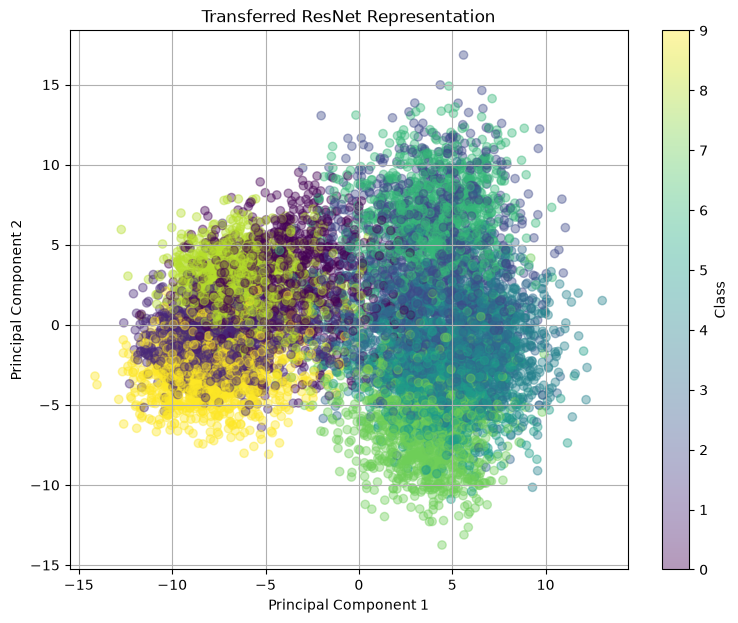

In [67]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=embedding_labels.numpy(),
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Transferred ResNet Representation"
)

plt.colorbar(
    scatter,
    label="Class"
)

plt.grid(True)
plt.show()

## Nearest-Neighbor Evaluation

A useful representation should place similar examples near one another.

We can therefore evaluate the transferred representation using k-nearest neighbors.

Let:

$$
z_i
$$

represent an image.

Using Euclidean distance:

$$
d(z_i,z_j)
=
\|z_i-z_j\|_2
$$

A good representation should ideally satisfy:

$$
d(z_i,z_j)
\text{ is small}
$$

when the samples belong to the same class.

This provides a model-independent way of evaluating the learned representation.

In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Use a smaller subset for efficient demonstration

train_embeddings = []
train_labels = []

with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)

        features = feature_extractor(images)

        features = features.flatten(
            start_dim=1
        )

        train_embeddings.append(
            features.cpu()
        )

        train_labels.append(
            labels
        )

        # Keep the demonstration computationally manageable
        if len(train_embeddings) >= 20:
            break

train_embeddings = torch.cat(
    train_embeddings
).numpy()

train_labels = torch.cat(
    train_labels
).numpy()

print(
    "Train embedding subset:",
    train_embeddings.shape
)

Train embedding subset: (2560, 512)


In [69]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    train_embeddings,
    train_labels
)

test_subset_size = min(
    3000,
    len(embeddings)
)

knn_predictions = knn.predict(
    embeddings[:test_subset_size].numpy()
)

knn_accuracy = accuracy_score(
    embedding_labels[:test_subset_size].numpy(),
    knn_predictions
)

print(
    f"k-NN Representation Accuracy: "
    f"{knn_accuracy:.4f}"
)

k-NN Representation Accuracy: 0.8813


# 5.51.11 Final Project Interpretation

This project demonstrated the complete transfer-learning workflow.

---

## Step 1 — Pretrained Knowledge

We started with:

$$
\text{ImageNet}
\rightarrow
\text{ResNet-18}
$$

The model had already learned useful visual representations.

---

## Step 2 — Target Task

We transferred the model to:

$$
\text{CIFAR-10}
$$

---

## Step 3 — Feature Extraction

We froze the pretrained backbone:

$$
\theta=\text{fixed}
$$

and trained only the target classifier.

---

## Step 4 — Fine-Tuning

We allowed deeper layers to adapt:

$$
\theta_{\text{deep}}
\rightarrow
\text{updated}
$$

using a smaller learning rate.

---

## Step 5 — Representation Evaluation

We extracted the intermediate representation:

$$
z=f_\theta(x)
$$

and evaluated it using:

- PCA visualization,
- nearest-neighbor classification.

---

## What This Demonstrates

The final classifier is only one part of the transfer-learning system.

The deeper idea is:

$$
\boxed{
\text{Knowledge is transferred through learned representations}
}
$$

This connects directly to:

$$
\text{Representation Learning}
\rightarrow
\text{Transfer Learning}
\rightarrow
\text{Target Task}
$$

# 5.52 Knowledge Reuse — Final Summary

We have now completed the major Knowledge Reuse paradigms.

---

## Transfer Learning

Reuse knowledge learned from a source task.

$$
\text{Source}
\rightarrow
\text{Pretrained Model}
\rightarrow
\text{Target}
$$

Main strategies:

- Feature extraction
- Fine-tuning

---

## Domain Adaptation

Handle differences between source and target distributions.

$$
P_S(X)\neq P_T(X)
$$

Important techniques:

- Feature alignment
- MMD
- Domain-adversarial learning
- Gradient reversal

---

## Multi-Task Learning

Learn multiple related tasks jointly.

$$
x
\rightarrow
\text{Shared Representation}
\rightarrow
\begin{cases}
\text{Task 1}\\
\text{Task 2}\\
\vdots
\end{cases}
$$

Important concepts:

- Hard parameter sharing
- Soft parameter sharing
- Shared-private architectures
- Cross-stitch networks
- Gradient conflict
- GradNorm
- Uncertainty-based weighting

---

## Unified Knowledge Reuse Framework

$$
\boxed{
\text{Learned Knowledge}
\rightarrow
\text{Reuse}
\rightarrow
\text{Adapt}
}
$$

Different paradigms determine where and how the knowledge is reused.

---

## Final Conceptual Table

| Paradigm | Knowledge Relationship | Main Problem |
|---|---|---|
| Transfer Learning | Source → Target | Reusing learned knowledge |
| Domain Adaptation | Source Domain → Target Domain | Distribution shift |
| Multi-Task Learning | Task ↔ Task | Sharing knowledge between tasks |

---

## Final Principle

Modern Deep Learning rarely requires every model to learn everything from random initialization.

Instead:

$$
\boxed{
\text{Representations can be learned, transferred, adapted, and shared}
}
$$

This principle is fundamental to modern Deep Learning systems.

# 5.53 Deep Learning Paradigms — Final Comparison

Throughout this notebook, we studied several Deep Learning paradigms.

They differ mainly in:

- where supervision comes from,
- what the model is trying to learn,
- how knowledge is represented,
- how the model interacts with data,
- whether knowledge is generated, transferred, or shared.

The complete set of paradigms studied is:

1. Supervised Deep Learning
2. Unsupervised Deep Learning
3. Self-Supervised Learning
4. Semi-Supervised Deep Learning
5. Deep Reinforcement Learning
6. Generative Deep Learning
7. Representation Learning
8. Transfer Learning
9. Domain Adaptation
10. Multi-Task Learning

## 5.53.1 Supervised Deep Learning

Supervised Deep Learning learns from labeled examples:

$$
D=
\{(x_i,y_i)\}_{i=1}^{N}
$$

The model learns:

$$
f_\theta:X\rightarrow Y
$$

by minimizing a task loss:

$$
\theta^*
=
\arg\min_\theta
L(f_\theta(x),y)
$$

Typical tasks include:

- classification,
- regression,
- object detection,
- segmentation.

### Core idea

$$
\boxed{
\text{Input + Label}
\rightarrow
\text{Learn Prediction Function}
}
$$

## 5.53.2 Unsupervised Deep Learning

Unsupervised Deep Learning works with data without explicit labels:

$$
D=\{x_i\}_{i=1}^{N}
$$

The objective is to discover useful structure in the data.

Examples studied include:

- clustering,
- dimensionality reduction,
- autoencoders,
- latent representations.

The model attempts to discover:

$$
\boxed{
\text{Structure in the Data}
}
$$

without being directly given the desired output labels.

## 5.53.3 Self-Supervised Learning

Self-Supervised Learning creates supervision from the data itself.

Instead of manually provided labels:

$$
y_{\text{human}}
$$

the training process creates targets:

$$
y_{\text{generated}}
$$

Examples include:

- masked prediction,
- reconstruction,
- rotation prediction,
- contrastive learning.

The model learns representations:

$$
z=f_\theta(x)
$$

that can later be reused for downstream tasks.

### Core idea

$$
\boxed{
\text{Unlabeled Data}
\rightarrow
\text{Artificial Supervision}
\rightarrow
\text{Representation Learning}
}
$$

## 5.53.4 Semi-Supervised Deep Learning

Semi-Supervised Learning combines:

$$
\text{Small Labeled Dataset}
+
\text{Large Unlabeled Dataset}
$$

The model can optimize both supervised and unsupervised/consistency objectives.

A general objective is:

$$
L=
L_{\text{supervised}}
+
\lambda
L_{\text{unsupervised}}
$$

The key motivation is reducing dependence on expensive labeled data.

### Core idea

$$
\boxed{
\text{Few Labels + Many Unlabeled Examples}
}
$$

## 5.53.5 Deep Reinforcement Learning

Deep Reinforcement Learning learns through interaction between:

$$
\text{Agent}
\leftrightarrow
\text{Environment}
$$

At time $t$:

$$
s_t
\rightarrow
a_t
\rightarrow
r_t
\rightarrow
s_{t+1}
$$

The objective is to maximize expected return:

$$
G_t
=
\sum_{k=0}^{\infty}
\gamma^k r_{t+k}
$$

We studied:

- MDPs,
- value functions,
- Q-functions,
- Bellman equations,
- DQN,
- experience replay,
- target networks,
- policy gradients,
- REINFORCE,
- actor-critic,
- PPO.

### Core idea

$$
\boxed{
\text{Learn by Interaction and Reward}
}
$$

## 5.53.6 Generative Deep Learning

Generative Deep Learning models the underlying data distribution and learns to generate new samples.

Conceptually:

$$
p_\theta(x)
\approx
p_{\text{data}}(x)
$$

We studied:

- Autoencoders,
- Variational Autoencoders,
- GANs,
- DCGAN,
- Conditional GANs,
- Autoregressive models,
- Diffusion models,
- Conditional generative models,
- Modern generative architectures.

The generation process can involve:

$$
z
\rightarrow
G(z)
\rightarrow
x_{\text{generated}}
$$

### Core idea

$$
\boxed{
\text{Learn Data Distribution}
\rightarrow
\text{Generate New Data}
}
$$

## 5.53.7 Representation Learning

Representation Learning learns useful transformations of raw data.

Given:

$$
z=f_\theta(x)
$$

the representation $z$ should capture useful information about the input.

We studied:

- learned features,
- embeddings,
- distributed representations,
- autoencoder representations,
- supervised representations,
- self-supervised representations,
- metric learning,
- Siamese networks,
- contrastive loss,
- triplet loss,
- feature visualization,
- representation evaluation.

### Core idea

$$
\boxed{
\text{Raw Data}
\rightarrow
\text{Useful Representation}
}
$$

## 5.53.8 Transfer Learning

Transfer Learning reuses knowledge learned from a source problem.

$$
\text{Source}
\rightarrow
\text{Pretrained Model}
\rightarrow
\text{Target}
$$

We studied:

- pretrained networks,
- feature extraction,
- freezing layers,
- replacing classification heads,
- fine-tuning,
- learning-rate selection,
- transferred representations.

### Core idea

$$
\boxed{
\text{Learn Once}
\rightarrow
\text{Reuse on a New Task}
}
$$

## 5.53.9 Domain Adaptation

Domain Adaptation addresses differences between source and target domains.

The central issue is:

$$
P_S(X)\neq P_T(X)
$$

We studied:

- domain shift,
- covariate shift,
- label shift,
- concept shift,
- feature alignment,
- MMD,
- domain-adversarial learning,
- gradient reversal.

The goal is to learn useful and relatively domain-invariant representations.

### Core idea

$$
\boxed{
\text{Transfer Knowledge Despite Domain Shift}
}
$$

## 5.53.10 Multi-Task Learning

Multi-Task Learning solves multiple related tasks jointly.

$$
x
\rightarrow
\text{Shared Representation}
\rightarrow
\begin{cases}
\text{Task 1}\\
\text{Task 2}\\
\vdots\\
\text{Task K}
\end{cases}
$$

We studied:

- hard parameter sharing,
- soft parameter sharing,
- task-specific layers,
- shared-private architectures,
- cross-stitch networks,
- task weighting,
- gradient conflict,
- GradNorm,
- uncertainty-based weighting.

### Core idea

$$
\boxed{
\text{Learn Shared Knowledge Across Multiple Tasks}
}
$$

# 5.53.11 Complete Deep Learning Paradigm Comparison

| Paradigm | Supervision / Signal | Main Goal | Typical Output |
|---|---|---|---|
| Supervised DL | Human labels | Prediction | Class/value |
| Unsupervised DL | No explicit labels | Discover structure | Clusters/representations |
| Self-Supervised | Data-generated targets | Learn representations | Embeddings/features |
| Semi-Supervised | Labeled + unlabeled | Improve learning with few labels | Predictions |
| Deep RL | Rewards | Learn actions/policies | Actions |
| Generative DL | Data distribution | Generate new samples | Synthetic data |
| Representation Learning | Various signals | Learn useful features | Representations |
| Transfer Learning | Pretrained knowledge | Reuse knowledge | Target predictions |
| Domain Adaptation | Source + target domains | Handle domain shift | Target predictions |
| Multi-Task Learning | Multiple task signals | Jointly learn tasks | Multiple outputs |

---

## The Most Important Distinction

The paradigms answer different questions.

### Supervised Learning

> What should the model predict?

### Unsupervised Learning

> What structure exists in the data?

### Self-Supervised Learning

> Can the data create its own learning signal?

### Semi-Supervised Learning

> How can unlabeled data help when labels are limited?

### Deep Reinforcement Learning

> What action should the agent take to maximize future reward?

### Generative Learning

> How can we model and generate data?

### Representation Learning

> How should data be represented so that useful information is captured?

### Transfer Learning

> How can previously learned knowledge help a new task?

### Domain Adaptation

> How can learned knowledge survive a change in data distribution?

### Multi-Task Learning

> How can several tasks learn from shared knowledge?

# 5.53.12 Unified Deep Learning View

These paradigms are not completely isolated.

They can be combined.

For example:

$$
\boxed{
\text{Self-Supervised Pretraining}
}
$$

can produce:

$$
\downarrow
$$

$$
\boxed{
\text{Useful Representation}
}
$$

which can then be used for:

$$
\downarrow
$$

$$
\boxed{
\text{Transfer Learning}
}
$$

which may then be adapted using:

$$
\downarrow
$$

$$
\boxed{
\text{Domain Adaptation}
}
$$

while the final model may perform:

$$
\downarrow
$$

$$
\boxed{
\text{Multiple Tasks}
}
$$

This gives a modern Deep Learning pipeline:

$$
\boxed{
\text{Pretrain}
\rightarrow
\text{Represent}
\rightarrow
\text{Transfer}
\rightarrow
\text{Adapt}
\rightarrow
\text{Solve Multiple Tasks}
}
$$

Generative modeling and reinforcement learning can also be incorporated into larger systems.

---

## Important Insight

The boundaries between paradigms are often architectural rather than absolute.

A single modern system may use several paradigms simultaneously.

For example:

$$
\text{Self-Supervised Learning}
+
\text{Representation Learning}
+
\text{Transfer Learning}
+
\text{Multi-Task Learning}
$$

can all occur in one system.

# 5.53.13 Choosing a Deep Learning Paradigm

A practical decision framework:

$$
\boxed{
\text{What information do I have?}
}
$$

### Have labeled data?

Use:

$$
\rightarrow
\text{Supervised Learning}
$$

### Mostly unlabeled data?

Consider:

$$
\rightarrow
\text{Unsupervised / Self-Supervised Learning}
$$

### Few labels + many unlabeled examples?

Use:

$$
\rightarrow
\text{Semi-Supervised Learning}
$$

### Need an agent to make sequential decisions?

Use:

$$
\rightarrow
\text{Deep Reinforcement Learning}
$$

### Need to generate new samples?

Use:

$$
\rightarrow
\text{Generative Deep Learning}
$$

### Need better features or embeddings?

Use:

$$
\rightarrow
\text{Representation Learning}
$$

### Have a useful pretrained model?

Use:

$$
\rightarrow
\text{Transfer Learning}
$$

### Source and target domains differ?

Consider:

$$
\rightarrow
\text{Domain Adaptation}
$$

### Need several related predictions?

Consider:

$$
\rightarrow
\text{Multi-Task Learning}
$$

# 5.53.14 Final Conceptual Map

The complete notebook can now be viewed as one large Deep Learning map.

$$
\boxed{\text{Deep Learning}}
$$

$$
\downarrow
$$

$$
\begin{aligned}
&\text{Sources of Supervision}\\
&\quad\begin{cases}
\text{Supervised}\\
\text{Unsupervised}\\
\text{Self-Supervised}\\
\text{Semi-Supervised}
\end{cases}
\end{aligned}
$$

$$
\downarrow
$$

$$
\begin{aligned}
&\text{Specialized Learning}\\
&\quad\begin{cases}
\text{Deep Reinforcement Learning}\\
\text{Generative Deep Learning}\\
\text{Representation Learning}
\end{cases}
\end{aligned}
$$

$$
\downarrow
$$

$$
\begin{aligned}
&\text{Knowledge Reuse}\\
&\quad\begin{cases}
\text{Transfer Learning}\\
\text{Domain Adaptation}\\
\text{Multi-Task Learning}
\end{cases}
\end{aligned}
$$

---

## The Deeper Relationship

Many of these paradigms ultimately revolve around learning useful parameters and representations:

$$
\boxed{
x
\rightarrow
f_\theta(x)
\rightarrow
z
\rightarrow
\text{Task / Generation / Decision}
}
$$

The major difference is how $f_\theta$ is learned and how $z$ is used.

That is the central unifying idea of this notebook.

# 5.53.15 Deep Learning Paradigms — Final Takeaway

The most important thing is not memorizing ten independent definitions.

Understand the relationship between them.

$$
\boxed{
\begin{aligned}
\text{Supervised}
&\rightarrow \text{Learn from labels}\\
\text{Unsupervised}
&\rightarrow \text{Discover structure}\\
\text{Self-Supervised}
&\rightarrow \text{Create supervision from data}\\
\text{Semi-Supervised}
&\rightarrow \text{Combine labeled and unlabeled data}\\
\text{Deep RL}
&\rightarrow \text{Learn from rewards}\\
\text{Generative}
&\rightarrow \text{Learn to generate data}\\
\text{Representation}
&\rightarrow \text{Learn useful features}\\
\text{Transfer}
&\rightarrow \text{Reuse learned knowledge}\\
\text{Domain Adaptation}
&\rightarrow \text{Handle distribution shift}\\
\text{Multi-Task}
&\rightarrow \text{Share knowledge between tasks}
\end{aligned}
}
$$

Together, these form a broad view of how Deep Learning systems can:

$$
\boxed{
\text{Learn}
\rightarrow
\text{Represent}
\rightarrow
\text{Generate}
\rightarrow
\text{Decide}
\rightarrow
\text{Transfer}
\rightarrow
\text{Adapt}
\rightarrow
\text{Share}
}
$$

This completes the conceptual comparison of the major Deep Learning paradigms covered in this notebook.

# 5.54 Final End-to-End Deep Learning Paradigms Project

This project provides an integrated demonstration of the major Deep Learning paradigms studied in this notebook.

The objective is to connect theory with a practical workflow.

---

## Project Goal

We will use image data and demonstrate the following ideas:

$$
\boxed{
\text{Representation Learning}
\rightarrow
\text{Transfer Learning}
\rightarrow
\text{Fine-Tuning}
\rightarrow
\text{Evaluation}
}
$$

We will also explicitly connect the project to:

- supervised learning,
- self-supervised learning,
- generative learning,
- transfer learning,
- domain adaptation,
- multi-task learning.

Not every paradigm requires a separate model in this final project.

Instead, we will understand how the paradigms can be combined into a larger Deep Learning system.

---

## Project Pipeline

$$
\text{Raw Images}
$$

$$
\downarrow
$$

$$
\text{Representation Learning}
$$

$$
\downarrow
$$

$$
\text{Pretrained Backbone}
$$

$$
\downarrow
$$

$$
\text{Transfer Learning}
$$

$$
\downarrow
$$

$$
\text{Fine-Tuning}
$$

$$
\downarrow
$$

$$
\text{Target Prediction}
$$

$$
\downarrow
$$

$$
\text{Representation Evaluation}
$$

---

## Main Practical Questions

1. Can pretrained representations solve a new task?
2. Does fine-tuning improve the representation?
3. Are the learned features structured?
4. Can the same representation support different prediction tasks?
5. How does this connect to the other Deep Learning paradigms?

## 5.54.1 Dataset Preparation

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [71]:
weights = models.ResNet18_Weights.DEFAULT

transform = weights.transforms()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

classes = train_dataset.classes

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", classes)

Train samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 5.54.2 Inspect the Target Data

In [72]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([128, 3, 224, 224])
Label batch shape: torch.Size([128])


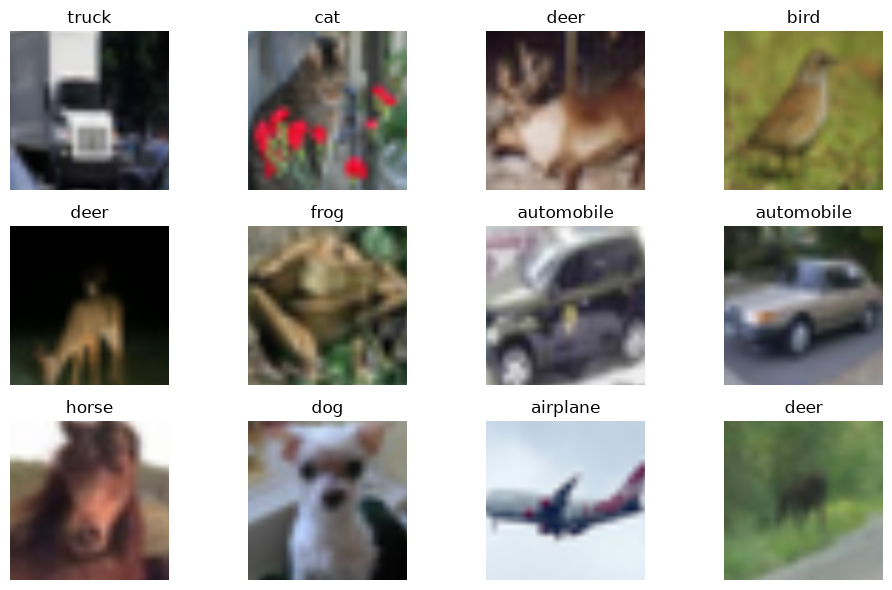

In [73]:
plt.figure(figsize=(10, 6))

for i in range(12):

    image = images[i].permute(1, 2, 0)

    # Undo ImageNet normalization approximately
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    )

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    )

    image = image * std + mean
    image = image.clamp(0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 5.54.3 Load Pretrained Knowledge

We begin with a model that has already learned visual representations.

$$
\text{ImageNet}
\rightarrow
\text{ResNet-18}
$$

The pretrained network contains knowledge about:

- edges,
- textures,
- shapes,
- object parts,
- higher-level visual structures.

Instead of learning these representations from random initialization, we reuse them.

This is the foundation of our transfer-learning experiment.

In [74]:
model = models.resnet18(
    weights=weights
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(classes)
)

model = model.to(device)

print("Target classifier:")
print(model.fc)

Target classifier:
Linear(in_features=512, out_features=10, bias=True)


# 5.54.4 Feature Extraction

First, freeze the pretrained backbone.

Only the new target classifier will be trained.

$$
\theta_{\text{backbone}}
=
\text{fixed}
$$

$$
\phi_{\text{target}}
=
\text{trainable}
$$

This gives us a direct measurement of how useful the pretrained representation is for the target problem.

In [75]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

Total parameters: 11,181,642
Trainable parameters: 5,130


## 5.54.5 Train the Target Head

In [76]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3
)

In [77]:
def train_model(
    model,
    loader,
    criterion,
    optimizer,
    epochs
):
    history = {
        "loss": [],
        "accuracy": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        epoch_loss = (
            running_loss / total
        )

        epoch_accuracy = (
            correct / total
        )

        history["loss"].append(
            epoch_loss
        )

        history["accuracy"].append(
            epoch_accuracy
        )

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Loss: {epoch_loss:.4f} "
            f"| Accuracy: {epoch_accuracy:.4f}"
        )

    return history

In [78]:
feature_history = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=3
)

Epoch [1/3] | Loss: 0.9932 | Accuracy: 0.6808
Epoch [2/3] | Loss: 0.7050 | Accuracy: 0.7607
Epoch [3/3] | Loss: 0.6633 | Accuracy: 0.7721


## 5.54.6 Evaluate the Model

In [79]:
def evaluate_accuracy(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total


feature_accuracy = evaluate_accuracy(
    model,
    test_loader
)

print(
    f"Feature Extraction Test Accuracy: "
    f"{feature_accuracy:.4f}"
)

Feature Extraction Test Accuracy: 0.7744


# 5.54.7 Fine-Tune the Representation

Now we move from simple feature extraction to fine-tuning.

The final residual block becomes trainable.

$$
\text{Frozen Early Features}
\rightarrow
\text{Trainable Deep Features}
\rightarrow
\text{Target Head}
$$

The deeper features can now adapt to the target dataset.

We use a smaller learning rate because the pretrained parameters already contain useful information.

$$
\eta_{\text{fine-tune}}
<
\eta_{\text{feature extraction}}
$$

In [80]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [81]:
fine_tune_optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4
)

In [82]:
fine_history = train_model(
    model,
    train_loader,
    criterion,
    fine_tune_optimizer,
    epochs=3
)

Epoch [1/3] | Loss: 0.4107 | Accuracy: 0.8566
Epoch [2/3] | Loss: 0.1207 | Accuracy: 0.9630
Epoch [3/3] | Loss: 0.0339 | Accuracy: 0.9934


## 5.54.8 Compare Transfer Strategies

In [83]:
fine_tune_accuracy = evaluate_accuracy(
    model,
    test_loader
)

print(
    f"Feature Extraction Accuracy: "
    f"{feature_accuracy:.4f}"
)

print(
    f"Fine-Tuning Accuracy: "
    f"{fine_tune_accuracy:.4f}"
)

print(
    f"Improvement: "
    f"{fine_tune_accuracy - feature_accuracy:.4f}"
)

Feature Extraction Accuracy: 0.7744
Fine-Tuning Accuracy: 0.9028
Improvement: 0.1284


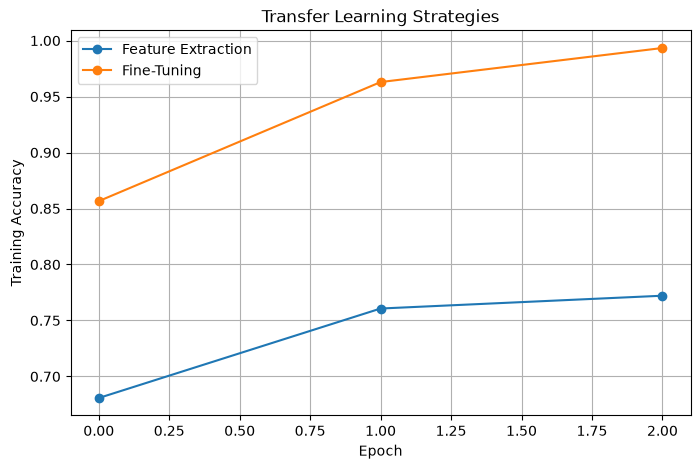

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    feature_history["accuracy"],
    marker="o",
    label="Feature Extraction"
)

plt.plot(
    fine_history["accuracy"],
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title(
    "Transfer Learning Strategies"
)

plt.legend()
plt.grid(True)

plt.show()

# 5.54.9 Final Representation

The most important object in this project is not just the classifier output.

It is the learned representation:

$$
z=f_\theta(x)
$$

We will extract the 512-dimensional representation produced immediately before the final classifier.

This lets us directly inspect the feature space learned through transfer learning.

In [85]:
feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

embeddings = []
embedding_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        features = feature_extractor(
            images
        )

        features = features.flatten(
            start_dim=1
        )

        embeddings.append(
            features.cpu()
        )

        embedding_labels.append(
            labels
        )

embeddings = torch.cat(
    embeddings
)

embedding_labels = torch.cat(
    embedding_labels
)

print(
    "Representation shape:",
    embeddings.shape
)

Representation shape: torch.Size([10000, 512])


## 5.54.10 Visualize the Representation

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

embedding_2d = pca.fit_transform(
    embeddings.numpy()
)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

In [ ]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=embedding_labels.numpy(),
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Final Transfer-Learned Representation"
)

plt.colorbar(
    scatter,
    label="Class"
)

plt.grid(True)
plt.show()

# 5.54.11 Representation-Based Evaluation

A representation can be evaluated independently of the neural-network classifier.

If semantically similar samples are close in representation space, a simple nearest-neighbor classifier should perform reasonably well.

For two representations:

$$
z_i,z_j
$$

we use:

$$
d(z_i,z_j)
=
\|z_i-z_j\|_2
$$

A useful representation should tend to satisfy:

$$
d(z_i,z_j)
\text{ small}
$$

for samples belonging to the same class.

This connects the final project directly to the Representation Learning section.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Use a manageable training subset
train_embeddings = []
train_labels = []

with torch.no_grad():

    for batch_index, (images, labels) in enumerate(
        train_loader
    ):

        images = images.to(device)

        features = feature_extractor(
            images
        )

        features = features.flatten(
            start_dim=1
        )

        train_embeddings.append(
            features.cpu()
        )

        train_labels.append(
            labels
        )

        if batch_index >= 19:
            break

train_embeddings = torch.cat(
    train_embeddings
).numpy()

train_labels = torch.cat(
    train_labels
).numpy()

print(
    "Training representation subset:",
    train_embeddings.shape
)

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    train_embeddings,
    train_labels
)

test_size = 3000

predictions = knn.predict(
    embeddings[:test_size].numpy()
)

knn_accuracy = accuracy_score(
    embedding_labels[:test_size].numpy(),
    predictions
)

print(
    f"k-NN representation accuracy: "
    f"{knn_accuracy:.4f}"
)

## 5.54.12 Final Prediction Demonstration

In [ ]:
model.eval()

images, labels = next(
    iter(test_loader)
)

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)

predictions = outputs.argmax(
    dim=1
).cpu()

print("Actual labels:")
print(
    [classes[i] for i in labels[:10]]
)

print("\nPredicted labels:")
print(
    [classes[i] for i in predictions[:10]]
)

# 5.54.14 Connecting the Project to the Deep Learning Paradigms

Our project primarily demonstrated:

$$
\boxed{
\text{Representation Learning}
+
\text{Transfer Learning}
+
\text{Supervised Learning}
}
$$

But the project can be connected to the other paradigms.

---

## Supervised Learning

The CIFAR-10 labels provide:

$$
(x,y)
$$

and the model minimizes:

$$
L_{\text{CE}}
$$

Therefore the target task is supervised.

---

## Representation Learning

The ResNet backbone transforms:

$$
x
\rightarrow
z
$$

where $z$ is a learned representation.

---

## Transfer Learning

The representation was learned previously and reused:

$$
\text{ImageNet}
\rightarrow
\text{CIFAR-10}
$$

---

## Fine-Tuning

The deeper pretrained layers were adapted:

$$
\theta_S
\rightarrow
\theta_T
$$

---

## Domain Adaptation

The project has a domain-shift interpretation because ImageNet and CIFAR-10 have different data distributions.

However, this experiment is primarily a transfer-learning experiment rather than a full unsupervised domain-adaptation benchmark.

A dedicated domain-adaptation system would explicitly optimize a domain-alignment objective.

---

## Multi-Task Learning

The current project uses one main target task.

Therefore, it is not itself a complete Multi-Task Learning system.

A Multi-Task version could add another prediction head:

$$
z
\rightarrow
\begin{cases}
\text{Class Prediction}\\
\text{Another Related Task}
\end{cases}
$$

This demonstrates an important distinction:

$$
\boxed{
\text{Not every project needs every paradigm}
}
$$

The purpose of the final project is to understand how the paradigms can fit together.

# 5.54.15 Complete End-to-End Pipeline

The entire project can now be represented as:

$$
\boxed{
\text{ImageNet Pretraining}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Pretrained ResNet}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Reusable Representation}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Feature Extraction}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{CIFAR-10 Classification}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Fine-Tuning}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Adapted Representation}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Evaluation + Visualization}
}
$$

---

## What Was Reused?

The reusable knowledge was primarily contained in the pretrained network parameters.

$$
\theta_S
$$

---

## What Was Learned Again?

The target classifier parameters:

$$
\phi_T
$$

were learned for CIFAR-10.

Later, deeper feature parameters were also adapted through fine-tuning.

---

## What Did We Measure?

We evaluated:

- classification accuracy,
- training behavior,
- transferred representation,
- PCA structure,
- nearest-neighbor performance.

Therefore, the project evaluates both:

$$
\text{Prediction Quality}
$$

and:

$$
\text{Representation Quality}
$$

# 5.54.16 Final Project Conclusion

This project demonstrated how Deep Learning knowledge can be reused rather than learned entirely from scratch.

The complete process was:

$$
\boxed{
\text{Pretrained Knowledge}
\rightarrow
\text{Representation Reuse}
\rightarrow
\text{Target Learning}
\rightarrow
\text{Fine-Tuning}
\rightarrow
\text{Evaluation}
}
$$

The most important practical lesson is:

$$
\boxed{
\text{A pretrained model is valuable because its parameters encode learned representations}
}
$$

Transfer learning therefore provides a bridge between:

$$
\text{Previous Learning}
$$

and:

$$
\text{New Learning}
$$

The project also demonstrated an important principle of Deep Learning:

$$
\boxed{
\text{Model performance should be studied together with representation quality}
}
$$

A strong Deep Learning practitioner should understand not only whether a model predicts correctly, but also:

- what representation it learned,
- how that representation can be reused,
- how it changes during fine-tuning,
- whether it generalizes,
- and how different learning paradigms can be combined.

# 5.55 Deep Learning Paradigms — Final Review & Completion

This section provides the final review of the complete
Deep Learning Paradigms notebook.

The purpose is to connect every topic into one coherent framework.

---

# Complete Notebook Structure

## Part A — Sources of Supervision

### 1. Supervised Deep Learning

Learning from labeled examples.

$$
(x,y)\rightarrow\text{Prediction}
$$

---

### 2. Unsupervised Deep Learning

Learning structure from unlabeled data.

$$
x\rightarrow\text{Discovered Structure}
$$

---

### 3. Self-Supervised Learning

Creating supervision from the data itself.

$$
x\rightarrow\text{Artificial Target}
\rightarrow\text{Representation}
$$

---

### 4. Semi-Supervised Deep Learning

Combining labeled and unlabeled data.

$$
\text{Few Labels}
+
\text{Many Unlabeled Examples}
$$

---

# Part B — Specialized Learning Paradigms

## 5. Deep Reinforcement Learning

Learning through interaction and reward.

$$
s_t
\rightarrow
a_t
\rightarrow
r_t
\rightarrow
s_{t+1}
$$

Objective:

$$
\max_\theta
\mathbb{E}[G_t]
$$

---

## 6. Generative Deep Learning

Learning a data distribution and generating new samples.

$$
p_\theta(x)
\approx
p_{\text{data}}(x)
$$

Major approaches studied:

- Autoencoders
- VAEs
- GANs
- DCGAN
- Conditional GANs
- Autoregressive models
- Diffusion models
- Conditional generative models
- Modern generative architectures

---

## 7. Representation Learning

Learning useful representations:

$$
z=f_\theta(x)
$$

Major concepts studied:

- learned features,
- embeddings,
- distributed representations,
- autoencoder representations,
- supervised representations,
- self-supervised representations,
- metric learning,
- Siamese networks,
- contrastive learning,
- triplet learning,
- feature visualization,
- representation evaluation.

---

# Part C — Knowledge Reuse

## 8. Transfer Learning

Reuse previously learned knowledge.

$$
\text{Source}
\rightarrow
\text{Pretrained Model}
\rightarrow
\text{Target}
$$

---

## 9. Domain Adaptation

Adapt knowledge across different data distributions.

$$
P_S(X)\neq P_T(X)
$$

---

## 10. Multi-Task Learning

Learn multiple related tasks jointly.

$$
x
\rightarrow
z
\rightarrow
\begin{cases}
\text{Task 1}\\
\text{Task 2}\\
\text{Task 3}
\end{cases}
$$

# 5.55.1 Complete Deep Learning Paradigm Map

The complete notebook can be summarized as:

$$
\boxed{\text{Deep Learning}}
$$

$$
\downarrow
$$

$$
\boxed{\text{How Does the Model Obtain a Learning Signal?}}
$$

$$
\downarrow
$$

$$
\begin{cases}
\text{Supervised}\\
\text{Unsupervised}\\
\text{Self-Supervised}\\
\text{Semi-Supervised}\\
\text{Reinforcement Learning}
\end{cases}
$$

Then we can ask:

$$
\boxed{\text{What Does the Model Learn?}}
$$

$$
\downarrow
$$

$$
\begin{cases}
\text{Predictions}\\
\text{Representations}\\
\text{Generative Distributions}\\
\text{Policies / Values}
\end{cases}
$$

Finally:

$$
\boxed{\text{How Can Learned Knowledge Be Reused?}}
$$

$$
\downarrow
$$

$$
\begin{cases}
\text{Transfer Learning}\\
\text{Domain Adaptation}\\
\text{Multi-Task Learning}
\end{cases}
$$

---

## Unified View

A large portion of Deep Learning can be expressed through:

$$
x
\rightarrow
\boxed{f_\theta(x)}
\rightarrow
z
$$

where $z$ is a learned representation.

The representation can then be used for:

$$
z
\rightarrow
\begin{cases}
\text{Classification}\\
\text{Regression}\\
\text{Generation}\\
\text{Decision Making}\\
\text{Multiple Tasks}\\
\text{Transfer to Another Task}
\end{cases}
$$

This provides the central conceptual connection across the notebook.

# 5.55.2 Deep Learning Knowledge Checklist

After completing this notebook, you should be able to explain the following without depending on memorized definitions.

---

## Sources of Supervision

- What supervised learning means
- What unsupervised learning means
- How self-supervised learning creates labels
- Why semi-supervised learning is useful
- Difference between supervised, unsupervised and self-supervised learning

---

## Deep Reinforcement Learning

- Agent and environment
- State, action and reward
- Markov Decision Process
- Return
- Discount factor
- Value function
- Q-function
- Bellman equation
- DQN
- Experience replay
- Target network
- Exploration vs exploitation
- Epsilon-greedy policy
- Policy gradients
- REINFORCE
- Actor-Critic
- PPO

---

## Generative Deep Learning

- Generative vs discriminative modeling
- Data distribution
- Latent variables
- Autoencoders
- VAE
- Reparameterization trick
- KL divergence
- GAN
- Generator and discriminator
- Mode collapse
- DCGAN
- Conditional GAN
- Autoregressive models
- Pixel-based generation
- Diffusion
- Forward diffusion
- Reverse diffusion
- Noise prediction
- Conditional generation
- Modern generative architectures

---

## Representation Learning

- Learned features
- Feature representations
- Embeddings
- Distributed representations
- Autoencoder representations
- Supervised representations
- Self-supervised representations
- Feature extractor
- Projection head
- Metric learning
- Siamese networks
- Contrastive loss
- Triplet loss
- Positive and negative pairs
- Hard negatives
- Feature visualization
- PCA
- t-SNE
- k-NN evaluation
- Linear probing
- Representation collapse

---

## Knowledge Reuse

- Transfer learning
- Feature extraction
- Fine-tuning
- Freezing layers
- Domain shift
- Covariate shift
- Label shift
- Concept shift
- Feature alignment
- MMD
- Domain-adversarial learning
- Multi-task learning
- Hard parameter sharing
- Soft parameter sharing
- Shared-private architectures
- Cross-stitch networks
- Gradient conflict
- GradNorm
- Uncertainty-based task weighting

# 5.55.3 Practical Deep Learning Skills Checklist

You have also worked through practical PyTorch implementations.

You should now be comfortable with:

### PyTorch

- tensors,
- devices,
- CUDA,
- datasets,
- DataLoader,
- neural-network modules,
- forward propagation,
- loss functions,
- backpropagation,
- optimizers,
- training loops,
- evaluation,
- `model.train()`,
- `model.eval()`,
- `torch.no_grad()`.

### Deep Learning Architectures

- feed-forward networks,
- CNN concepts,
- encoders and decoders,
- VAEs,
- GANs,
- diffusion models,
- representation networks,
- Siamese networks,
- metric-learning networks,
- multi-task networks,
- pretrained CNNs.

### Evaluation

- loss curves,
- accuracy,
- reconstruction quality,
- latent-space visualization,
- PCA,
- t-SNE,
- nearest-neighbor evaluation,
- k-NN,
- ROC-AUC,
- clustering metrics,
- representation quality.

### Transfer Learning

- loading pretrained models,
- replacing classification heads,
- freezing parameters,
- unfreezing layers,
- feature extraction,
- fine-tuning,
- choosing learning rates.

---

## Most Important Practical Skill

You should not simply know how to execute:

```python
model.fit(...)

You should understand:

$$ \boxed{ \text{Data} \rightarrow \text{Architecture} \rightarrow \text{Representation} \rightarrow \text{Loss} \rightarrow \text{Optimization} \rightarrow \text{Evaluation} } $$

That is the real Deep Learning workflow.


---


# 5.55.4 Final Mathematical Toolkit

The most important mathematical ideas encountered throughout the notebook include:

---

## Neural Network

$$
z=f_\theta(x)
$$

---

## Supervised Objective

$$
\theta^*
=
\arg\min_\theta
L(f_\theta(x),y)
$$

---

## Representation Learning

$$
z=f_\theta(x)
$$

---

## Autoencoder

$$
z=f_\theta(x)
$$

$$
\hat{x}=g_\phi(z)
$$

---

## VAE

$$
q_\phi(z|x)
=
\mathcal{N}(\mu,\sigma^2)
$$

and:

$$
z=
\mu+\sigma\odot\epsilon
$$

---

## GAN

$$
\min_G\max_D
V(D,G)
$$

---

## Autoregressive Model

$$
p(x)
=
\prod_i
p(x_i|x_{<i})
$$

---

## Diffusion

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon
$$

---

## Reinforcement Learning

$$
G_t
=
\sum_{k=0}^{\infty}
\gamma^k r_{t+k}
$$

---

## Contrastive Loss

$$
L=
yD^2
+
(1-y)
\max(0,m-D)^2
$$

---

## Triplet Loss

$$
L=
\max
(0,D_{ap}-D_{an}+m)
$$

---

## Multi-Task Learning

$$
L_{\text{total}}
=
\sum_k
\lambda_kL_k
$$

---

## Domain Adaptation

$$
P_S(X)\neq P_T(X)
$$

with the goal of learning useful representations despite domain differences.

---

These equations form a compact mathematical toolkit for the major paradigms covered in the notebook.

# 5.55.5 Final Practical Decision Framework

When approaching a new Deep Learning problem, ask:

---

### 1. Do I have labels?

If yes:

$$
\rightarrow
\text{Supervised Learning}
$$

If no:

$$
\rightarrow
\text{Unsupervised / Self-Supervised Learning}
$$

---

### 2. Do I have only a small amount of labeled data?

Consider:

$$
\rightarrow
\text{Semi-Supervised Learning}
$$

---

### 3. Does an agent need to make sequential decisions?

Use:

$$
\rightarrow
\text{Deep Reinforcement Learning}
$$

---

### 4. Do I need to generate new data?

Use:

$$
\rightarrow
\text{Generative Deep Learning}
$$

---

### 5. Do I need useful features or embeddings?

Use:

$$
\rightarrow
\text{Representation Learning}
$$

---

### 6. Do I already have a strong pretrained model?

Use:

$$
\rightarrow
\text{Transfer Learning}
$$

---

### 7. Is there a source-target distribution mismatch?

Consider:

$$
\rightarrow
\text{Domain Adaptation}
$$

---

### 8. Do I need to solve several related tasks?

Consider:

$$
\rightarrow
\text{Multi-Task Learning}
$$

---

## Final Principle

Do not choose an architecture first.

First understand:

$$
\boxed{
\text{Problem}
\rightarrow
\text{Available Supervision}
\rightarrow
\text{Learning Objective}
\rightarrow
\text{Representation}
\rightarrow
\text{Architecture}
\rightarrow
\text{Optimization}
\rightarrow
\text{Evaluation}
}
$$

# 5.55.6 `dl_paradigms.ipynb` — Final Completion Summary

This notebook has covered the major Deep Learning paradigms from both theoretical and practical perspectives.

---

# Completed Areas

## Part A — Sources of Supervision

$$
\boxed{
\begin{array}{c}
\text{Supervised}\\
\text{Unsupervised}\\
\text{Self-Supervised}\\
\text{Semi-Supervised}
\end{array}
}
$$

---

## Part B — Specialized Learning

$$
\boxed{
\begin{array}{c}
\text{Deep Reinforcement Learning}\\
\text{Generative Deep Learning}\\
\text{Representation Learning}
\end{array}
}
$$

---

## Part C — Knowledge Reuse

$$
\boxed{
\begin{array}{c}
\text{Transfer Learning}\\
\text{Domain Adaptation}\\
\text{Multi-Task Learning}
\end{array}
}
$$

---

# Practical Work Completed

The notebook contains practical implementations involving:

- PyTorch,
- CUDA/GPU computation,
- neural networks,
- MNIST,
- CIFAR-10,
- autoencoders,
- VAEs,
- GANs,
- diffusion,
- contrastive learning,
- Siamese networks,
- triplet learning,
- representation visualization,
- transfer learning,
- fine-tuning,
- multi-task learning.

---

# Final Mental Model

The complete Deep Learning journey can be summarized as:

$$
\boxed{
\text{Learn From Data}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Learn Useful Representations}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Make Predictions / Generate / Decide}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Reuse Knowledge}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Adapt and Generalize}
}
$$

---

# Final Takeaway

Deep Learning is not just about building neural networks.

It is about understanding:

$$
\boxed{
\text{How a model obtains supervision}
}
$$

$$
\boxed{
\text{How it learns representations}
}
$$

$$
\boxed{
\text{How it optimizes an objective}
}
$$

$$
\boxed{
\text{How it generates, predicts, or decides}
}
$$

and:

$$
\boxed{
\text{How learned knowledge can be reused}
}
$$

The goal is therefore not to memorize individual algorithms.

The goal is to understand the relationships between the paradigms and know when each one is appropriate.

---

# `dl_paradigms.ipynb`

## STATUS: COMPLETE

$$
\boxed{
\text{Deep Learning Paradigms — COMPLETED}
}
$$